# Lectura del Excel de Lingo Smelter

Este notebook carga el archivo Excel y reconoce automáticamente los tipos de dato de cada columna. En la mayoría de los casos, pandas detecta columnas numéricas como `float64`.

La variable `column_types` guarda el diccionario con cada columna y su tipo reconocido.

In [ ]:
from importlib import reload
from pathlib import Path

import dataset_lingo_smelter
import feature_engineering

reload(dataset_lingo_smelter)
reload(feature_engineering)

ARCHIVO = Path("Datos Lingo smelter fase II.xlsx")
df = dataset_lingo_smelter.construir_dataset(ARCHIVO)
df, reporte_limpieza = dataset_lingo_smelter.limpiar_dataset(df, devolver_reporte=True)

# ley_feo_escoria_pct, delta_tiempo, tiempo y rendimiento_proxy_batch son columnas
# derivadas (no vienen del Excel): se definen y documentan como funciones en
# feature_engineering.py, no en diccionario_datos.json (que solo cubre las
# variables originales).
df = feature_engineering.agregar_ley_feo(df)
df = feature_engineering.agregar_tiempos(df)
df = feature_engineering.agregar_rendimiento_proxy_batch(df)

df

## Hallazgo clave (Paso 0): `feed_*` y `volumen_*` NO se des-acumulan

El diccionario de datos llama a `feed_Sn_kgf`, `feed_Fe_kgh`, etc. "masa **acumulada**", lo que
sugeriría aplicar `diff()` para obtener el consumo por escalón. La evidencia empírica (tasa kg/min
estable dentro de un rango físico, correlación orden-de-escalón-en-fase vs. tasa lejos de +1, el valor
tras una caída no cae a ~0, y los nombres originales de columna usan "total" = "durante el escalón")
contradice esa lectura literal — el detalle completo de la prueba está en `hallazgos.md` (sección 2).

**Conclusión operativa:** `feed_*`/`volumen_*` ya son el reactivo consumido **en ese escalón** (no se les
aplica `diff()`; sólo se normalizan por `delta_tiempo` → tasas kg/min o Nm³/min). En cambio, las
variables de **estado** (leyes de escoria, temperaturas, presiones) sí se diferencian entre escalones
consecutivos del mismo batch, porque son mediciones puntuales cuyo cambio refleja el efecto neto de las
reacciones ocurridas con los reactivos de ese mismo escalón.


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Calidad de datos: la limpieza por rangos fisicos vive en
# dataset_lingo_smelter.limpiar_dataset(), gobernada por config_limpieza.yaml
# (columnas/limites editables sin tocar codigo). Se aplico en la celda anterior
# justo despues de construir_dataset(), antes de derivar ley_feo_escoria_pct/
# tasas/gradientes, para que estos no hereden valores fuera de rango. Aqui solo
# se muestra el reporte de lo corregido.
# ---------------------------------------------------------------------------
print(reporte_limpieza.to_string(index=False) if not reporte_limpieza.empty else "Sin correcciones.")

In [50]:
# ---------------------------------------------------------------------------
# Overview general (compacto): dimension, estructura fija por batch, nulos, duracion
# ---------------------------------------------------------------------------
print(f"Shape: {df.shape} | Batches unicos: {df['Batch'].nunique()}")
print("Escalones por (batch, fase) - siempre 7 Fusion + 4 Reduccion:")
print(df.groupby(["Batch", "fase_proceso"]).size().groupby("fase_proceso").describe()[["min", "max"]])

nulos_pct = 100 * df.isna().mean()
print("\nTop columnas con nulos (%):")
print(nulos_pct[nulos_pct > 0].sort_values(ascending=False).head(8))

print("\nDuracion de escalon (delta_tiempo, min) por fase:")
print(df.groupby("fase_proceso")["delta_tiempo"].describe()[["mean", "min", "max"]])


Shape: (3982, 39) | Batches unicos: 362
Escalones por (batch, fase) - siempre 7 Fusion + 4 Reduccion:
              min  max
fase_proceso          
Fusión        7.0  7.0
Reducción     4.0  4.0

Top columnas con nulos (%):
presion_punta_lanza_kpa            13.586138
presion_suministro_gn_lanza_kpa    11.577097
ley_sb_escoria_pct                  8.287293
ley_cr_escoria_pct                  4.218985
ley_as_escoria_pct                  3.465595
ley_al2o3_escoria_pct               3.314917
ley_feo_escoria_pct                 3.314917
ley_fe_total_escoria_pct            3.314917
dtype: float64

Duracion de escalon (delta_tiempo, min) por fase:
                   mean   min    max
fase_proceso                        
Fusión        44.303473  25.0  188.0
Reducción     22.156768   5.0  125.0


## Paso 1: tasas por minuto (reactivos consumidos) y gradientes (respuesta del baño)

Cada batch tiene **siempre 11 escalones** (7 de Fusión + 4 de Reducción), pero la duración de cada
escalón (`delta_tiempo`) varía. Para poder comparar escalones entre sí y entre batches necesitamos
normalizar por tiempo:

- **Tasa de alimentación/inyección** (reactivo consumido, ya es de tipo "flujo por escalón"):
$$ \text{tasa}_x = \frac{x_{\text{escalón}}}{\Delta t_{\text{escalón}}} \quad \left[\frac{kg}{min}\ \text{o}\ \frac{Nm^3}{min}\right] $$

- **Gradiente de una variable de estado** $y$ (ley de escoria, temperatura, presión — medida puntual al
  cierre del escalón) entre el escalón $i-1$ y el escalón $i$ del mismo batch:
$$ \Delta y_i = y_i - y_{i-1} \qquad \text{grad}(y)_i = \frac{\Delta y_i}{\Delta t_i} $$

  $\Delta y_i$ es el cambio neto de composición/temperatura/presión atribuible a lo que se alimentó e
  inyectó **durante ese mismo escalón $i$** (los reactivos de la tasa de arriba). $\text{grad}(y)_i$ es la
  velocidad de cambio (por minuto), comparable aunque los escalones no duren lo mismo.

  El primer escalón de cada batch queda con `NaN` en $\Delta y$ y $\text{grad}(y)$: no existe un escalón
  previo *dentro de ese batch* con el cual comparar (el horno arrastra estado de la operación anterior,
  pero no es atribuible a los reactivos de este batch).


In [ ]:
df = feature_engineering.agregar_tasas_y_gradientes(df)
df = feature_engineering.agregar_orden_escalon(df)

nuevas_cols = [
    c for c in df.columns
    if c.startswith(("tasa_", "d_", "grad_"))
    or c in ("orden_escalon_fase", "es_primer_escalon_fase", "es_primer_escalon_batch")
]
print("Columnas nuevas creadas:", len(nuevas_cols))
print(df.shape)
df[["Batch", "fase_proceso", "orden_escalon_fase", "delta_tiempo",
    "tasa_feed_Carbon_kg_min", "d_ley_sn_escoria_pct", "grad_temperatura_horno_celsius"]].head(12)

Columnas nuevas creadas: 52
(3982, 91)


,Batch,fase_proceso,orden_escalon_fase,delta_tiempo,tasa_feed_Carbon_kg_min,d_ley_sn_escoria_pct,grad_temperatura_horno_celsius
0,AP0001,Fusión,0,30.0,15.948540,NaN,NaN
1,AP0001,Fusión,1,35.0,28.051410,-1.4582,1.209672
2,AP0001,Fusión,2,40.0,32.775495,-1.2964,1.221546
3,AP0001,Fusión,3,45.0,44.652731,-0.3037,-0.181013
4,AP0001,Fusión,4,50.0,38.876227,-4.8463,-0.253802
5,AP0001,Fusión,5,55.0,49.544911,0.9908,-0.060361
6,AP0001,Fusión,6,90.0,51.867907,-3.0399,0.148987
7,AP0001,Reducción,0,30.0,63.277196,-13.7343,0.345503
8,AP0001,Reducción,1,25.0,37.862936,-2.6465,0.032606
9,AP0001,Reducción,2,20.0,18.906452,-0.2628,0.069169


## Paso 2: features compuestas con fundamento pirometalúrgico

Con los reactivos por escalón (tasas) y la respuesta del baño (gradientes) ya construidos, se arman
indicadores intensivos que resumen la **química del proceso** y que son comparables entre escalones y
batches:

**a) Basicidad de la escoria** (controla viscosidad, capacidad de fundente y la partición de Sn/Fe entre
metal y escoria; en un sistema fayalítico FeO–SiO₂–CaO, la basicidad regula cuánto SnO₂ queda atrapado en
la escoria):
$$ B_2 = \frac{\%CaO}{\%SiO_2} \qquad\qquad B_4 = \frac{\%CaO + \%MgO}{\%SiO_2 + \%Al_2O_3} $$

**b) Balance estequiométrico de combustión en la lanza** (define si la atmósfera generada por la lanza
Ausmelt es oxidante o reductora, clave porque el proceso alterna Fusión —oxidante, favorece formar
SnO₂/FeO— con Reducción —reductora, favorece recuperar Sn metálico). Asumiendo combustión de gas natural
como metano puro:
$$ CH_4 + 2\,O_2 \rightarrow CO_2 + 2\,H_2O $$
el oxígeno estequiométrico requerido y el disponible (lanza + aire, ~21% O₂ en volumen) son:
$$ O_{2,\text{teórico}} = 2 \cdot V_{GN} \qquad O_{2,\text{disponible}} = V_{O_2} + 0.21 \cdot V_{aire} $$
$$ \text{exceso\_O}_2\,(\%) = 100 \times \frac{O_{2,\text{disponible}} - O_{2,\text{teórico}}}{O_{2,\text{teórico}}} $$
Valores positivos → atmósfera oxidante (excedente de O₂ más allá de lo necesario para quemar el gas
natural, disponible para oxidar el baño); valores negativos → atmósfera reductora (déficit de O₂, se
generan CO/H₂ que reducen SnO₂/FeO del baño).

**c) Relación reductor/carga y fundente/carga** (estequiometría de reducción de casiterita, SnO₂ + 2C →
Sn + 2CO₂, y de fusión con mineral de Fe/dross):
$$ r_{C/carga} = \frac{feed_{Carbon}}{feed_{Sn} + feed_{Fe} + feed_{drossFe}} \qquad
   r_{CaO/carga} = \frac{feed_{CaO}}{feed_{Fe} + feed_{drossFe}} $$


In [ ]:
df = feature_engineering.agregar_features_pirometalurgicas(df)

print("Medianas por fase (exceso_o2 %, relacion_C_carga, basicidad_B2):")
print(df.groupby("fase_proceso")[["exceso_o2_combustion_pct", "relacion_C_carga", "basicidad_B2"]].median())

Medianas por fase (exceso_o2 %, relacion_C_carga, basicidad_B2):
              exceso_o2_combustion_pct  relacion_C_carga  basicidad_B2
fase_proceso                                                          
Fusión                       18.886155          0.168957      0.527003
Reducción                    -4.760646        274.875569      0.549227


**Nota de calidad de datos:** `relacion_C_carga` sólo es interpretable en **Fusión** (mediana ≈0.17 kg
carbón / kg carga Sn+Fe, rango físicamente razonable). En **Reducción** casi no se alimenta mineral/dross
fresco (denominador ≈0), por lo que el ratio se dispara a valores sin sentido — en Reducción el
indicador relevante de intensidad reductora es directamente `tasa_feed_Carbon_kg_min` (no un ratio contra
"carga" porque no hay carga nueva). De igual forma, `basicidad_B2` muestra outliers en Reducción cuando el
%SiO₂ de la escoria queda muy cerca de 0 en el ensayo; para los gráficos de correlación se recortan
percentiles extremos (1%-99%) para no distorsionar la lectura visual.

## Paso 3: evidencia visual del enfoque diferencial en un batch real

El siguiente gráfico usa **datos observados** (sin ningún modelo/predicción) de un batch representativo,
mostrando escalón a escalón: la tasa de reactivos consumidos, el balance redox de la lanza y la respuesta
del baño (ley de Sn en escoria y temperatura). La línea vertical marca la transición Fusión → Reducción.


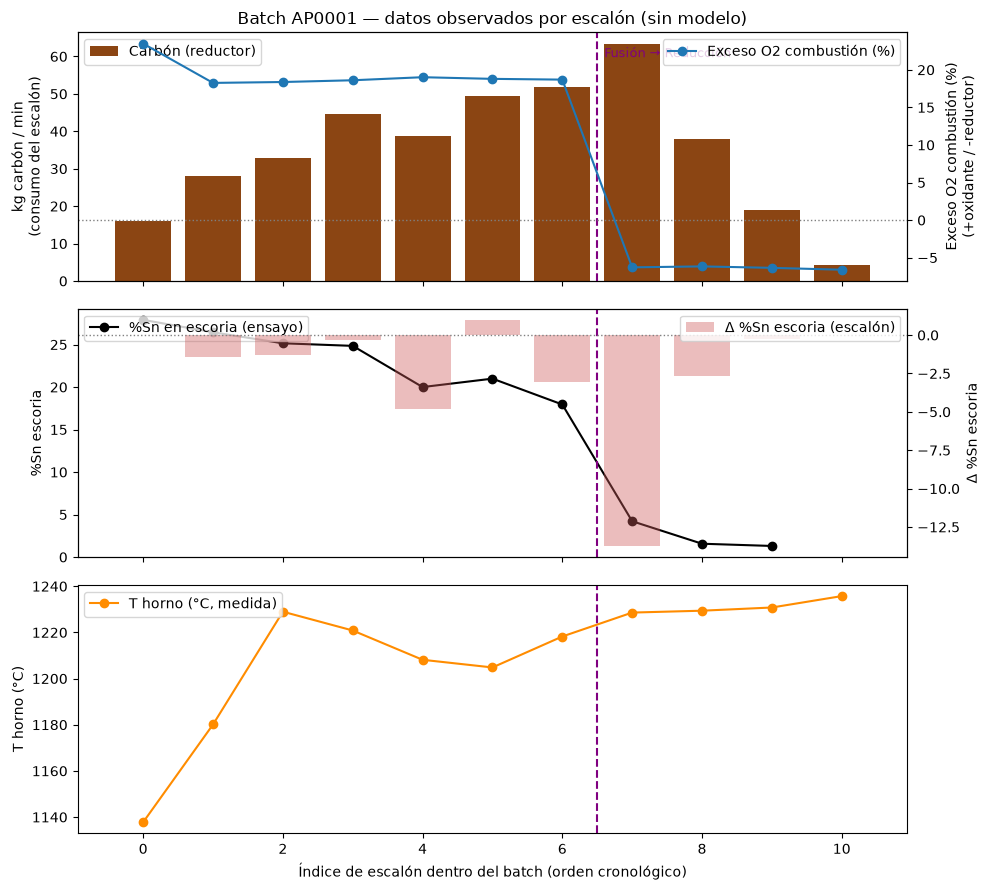

In [37]:
import matplotlib.pyplot as plt

BATCH_EJEMPLO = "AP0001"
b = df[df["Batch"] == BATCH_EJEMPLO].sort_values("fecha_inicio").reset_index(drop=True)
idx_transicion = b.index[b["fase_proceso"].eq("Reducción")].min() - 0.5

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].bar(b.index, b["tasa_feed_Carbon_kg_min"], color="saddlebrown", label="Carbón (reductor)")
axes[0].set_ylabel("kg carbón / min\n(consumo del escalón)")
axes[0].set_title(f"Batch {BATCH_EJEMPLO} — datos observados por escalón (sin modelo)")
axes[0].legend(loc="upper left")

ax0b = axes[0].twinx()
ax0b.plot(b.index, b["exceso_o2_combustion_pct"], color="tab:blue", marker="o", label="Exceso O2 combustión (%)")
ax0b.axhline(0, color="grey", linestyle=":", linewidth=1)
ax0b.set_ylabel("Exceso O2 combustión (%)\n(+oxidante / -reductor)")
ax0b.legend(loc="upper right")

axes[1].plot(b.index, b["ley_sn_escoria_pct"], color="black", marker="o", label="%Sn en escoria (ensayo)")
axes[1].set_ylabel("%Sn escoria")
ax1b = axes[1].twinx()
ax1b.bar(b.index, b["d_ley_sn_escoria_pct"], color="indianred", alpha=0.4, label="Δ %Sn escoria (escalón)")
ax1b.axhline(0, color="grey", linestyle=":", linewidth=1)
ax1b.set_ylabel("Δ %Sn escoria")
axes[1].legend(loc="upper left")
ax1b.legend(loc="upper right")

axes[2].plot(b.index, b["temperatura_horno_celsius"], color="darkorange", marker="o", label="T horno (°C, medida)")
axes[2].set_ylabel("T horno (°C)")
axes[2].set_xlabel("Índice de escalón dentro del batch (orden cronológico)")
axes[2].legend(loc="upper left")

for ax in axes:
    ax.axvline(idx_transicion, color="purple", linestyle="--", linewidth=1.5)
axes[0].text(idx_transicion + 0.1, axes[0].get_ylim()[1] * 0.9, "Fusión → Reducción",
             color="purple", fontsize=9)

plt.tight_layout()
plt.show()


**Lectura pirometalúrgica del batch AP0001 (patrón que se repite y se cuantifica más abajo para los 362
batches):**
- Durante **Fusión** el exceso de O₂ de combustión se mantiene ~18-19% (atmósfera oxidante estable,
  favorece fundir y oxidar la carga: SnO₂, FeO). El carbón sube progresivamente (más reductor disponible
  a medida que se acumula carga en el baño).
- En el **primer escalón de Reducción** el exceso de O₂ cae abruptamente a ≈-6% (atmósfera reductora) **al
  mismo tiempo** que el consumo de carbón toca su máximo del batch (~63 kg/min). Coincide con la mayor
  caída de `%Sn en escoria` de todo el batch (Δ≈-13.7 puntos), consistente con la reducción de SnO₂ de la
  escoria a Sn metálico: $SnO_2 + 2C \rightarrow Sn + 2CO_2$.
- La temperatura del horno cae levemente durante la fusión intermedia (más carga fría entrando) y luego
  se recupera y sube en Reducción — coherente con el paso de una atmósfera netamente oxidante (calor
  "diluido" por exceso de aire/O2) a una de combustión sub-estequiométrica más el aporte exotérmico neto
  de las reacciones de reducción sobre el baño ya fundido.

## Paso 4: relaciones diferenciales agregadas (todos los batches), separadas por fase

Los `Δ`/`grad` se calculan dentro de todo el batch (no se resetean al cambiar de fase), por lo que el
escalón de transición Fusión→Reducción sí queda con su delta definido (es la señal más informativa, como
se vio arriba). Sólo el **primer escalón de cada batch** no tiene delta (no hay escalón previo en ese
batch). Se recortan percentiles 1%-99% de variables con outliers conocidos (`basicidad_B2`) sólo para
fines de visualización de la correlación, no para el dataset base.


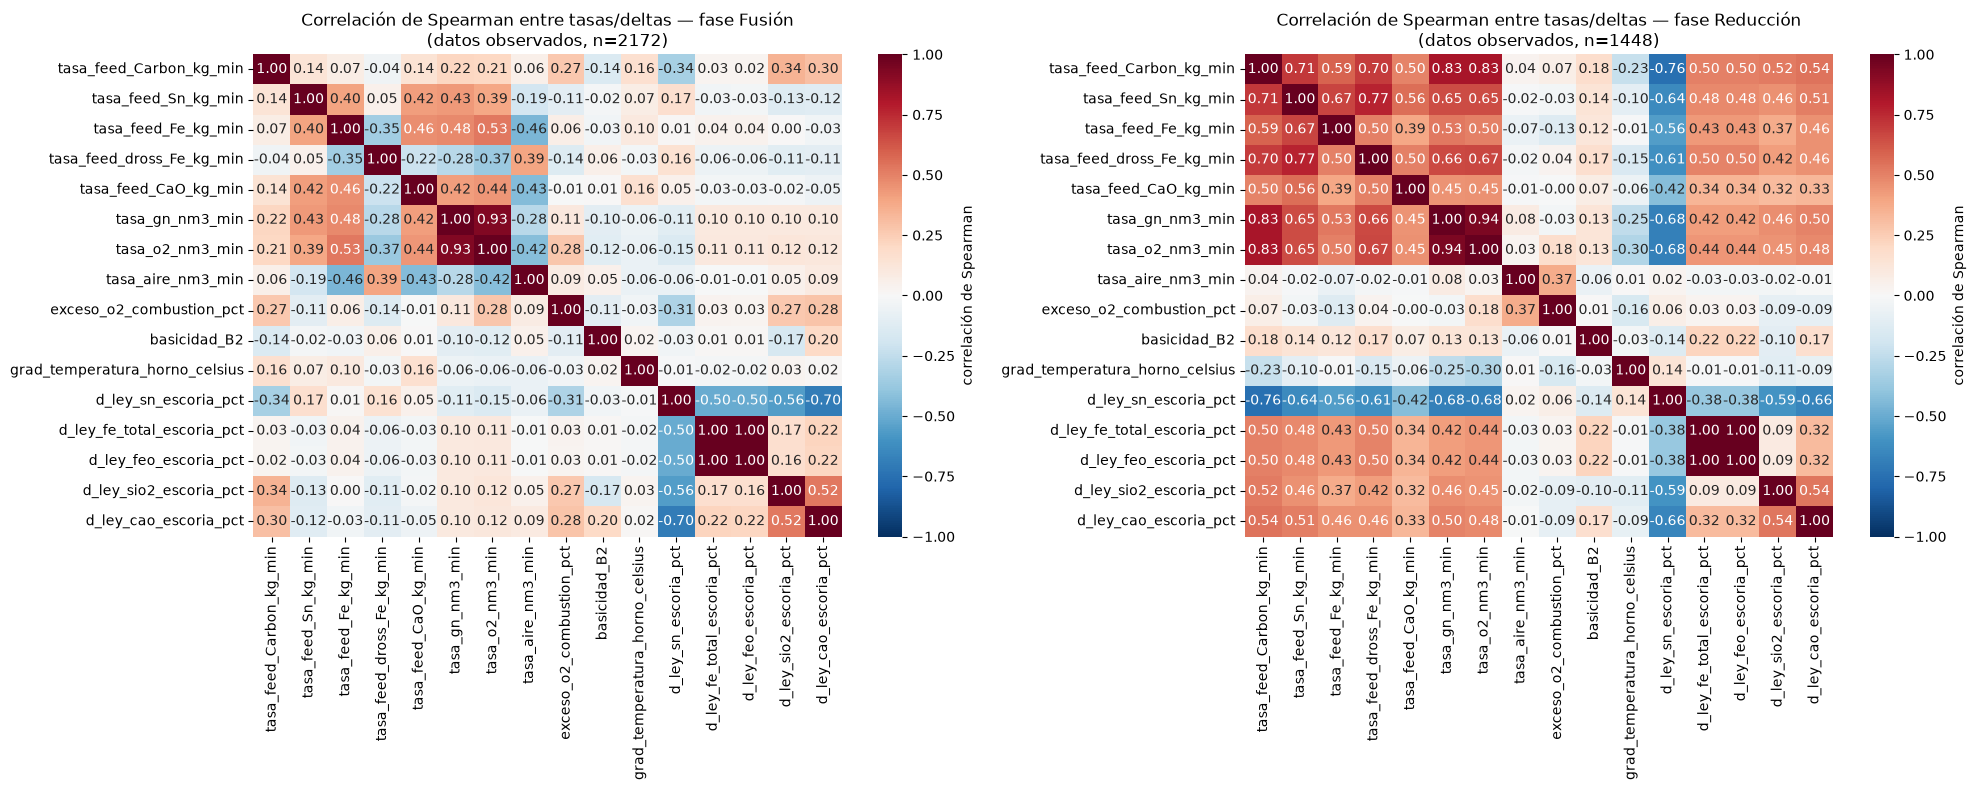

In [38]:
import seaborn as sns

cols_correlacion = [
    "tasa_feed_Carbon_kg_min", "tasa_feed_Sn_kg_min", "tasa_feed_Fe_kg_min",
    "tasa_feed_dross_Fe_kg_min", "tasa_feed_CaO_kg_min",
    "tasa_gn_nm3_min", "tasa_o2_nm3_min", "tasa_aire_nm3_min",
    "exceso_o2_combustion_pct", "basicidad_B2",
    "grad_temperatura_horno_celsius",
    "d_ley_sn_escoria_pct", "d_ley_fe_total_escoria_pct", "d_ley_feo_escoria_pct",
    "d_ley_sio2_escoria_pct", "d_ley_cao_escoria_pct",
]

df_no_primer_escalon = df[~df["es_primer_escalon_batch"]].copy()
df_no_primer_escalon["basicidad_B2"] = df_no_primer_escalon["basicidad_B2"].clip(
    df_no_primer_escalon["basicidad_B2"].quantile(0.01), df_no_primer_escalon["basicidad_B2"].quantile(0.99)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    sub = df_no_primer_escalon.loc[df_no_primer_escalon["fase_proceso"] == fase, cols_correlacion]
    corr = sub.corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax,
                cbar_kws={"label": "correlación de Spearman"})
    ax.set_title(f"Correlación de Spearman entre tasas/deltas — fase {fase}\n(datos observados, n={len(sub)})")

plt.tight_layout()
plt.show()


**Lectura de las matrices de correlación (Spearman, sobre datos observados, excluyendo el primer escalón
de cada batch):**

- **Reducción es donde la estequiometría del reductor se ve con más fuerza:** `tasa_feed_Carbon_kg_min`
  correlaciona -0.76 con `d_ley_sn_escoria_pct` (a más carbón alimentado en el escalón, mayor caída del
  %Sn en la escoria de ese mismo escalón) — coherente con $SnO_2 + 2C \rightarrow Sn + 2CO_2$. La tasa de
  GN y O2 de la lanza también correlacionan fuerte (-0.68) con esa misma caída, consistente con que en
  Reducción la lanza aporta calor/CO reductor adicional que sostiene la cinética de reducción.
- **En Fusión la relación reductor→Sn ya es visible pero más débil (-0.33):** tiene sentido porque en
  Fusión el objetivo principal es fundir y oxidar la carga (formar la escoria), no reducirla; el
  `exceso_o2_combustion_pct` también correlaciona -0.31 con `d_ley_sn_escoria_pct`, lo que amerita
  revisión adicional controlando por tendencia temporal dentro del batch (posible variable de confusión:
  ambas covarían con el avance del batch).
- **Las leyes de escoria se mueven en bloque por composición cerrada (suma=100%):** `d_ley_sn_escoria_pct`
  correlaciona fuertemente negativo con `d_ley_fe_total_escoria_pct`/`d_ley_feo_escoria_pct` (-0.50 a
  -0.76) — al removerse Sn de la escoria, el resto de óxidos sube su participación porcentual. Esto es
  **un efecto de composición (cierre de 100%), no necesariamente causal**, y debe tenerse en cuenta al
  interpretar o modelar estas variables (ej. usar razones u odds en vez de %, o trabajar con masas en vez
  de leyes, si se dispone de la masa de escoria).

### Boxplot: exceso de O2 de combustión por fase (validación del proxy redox)


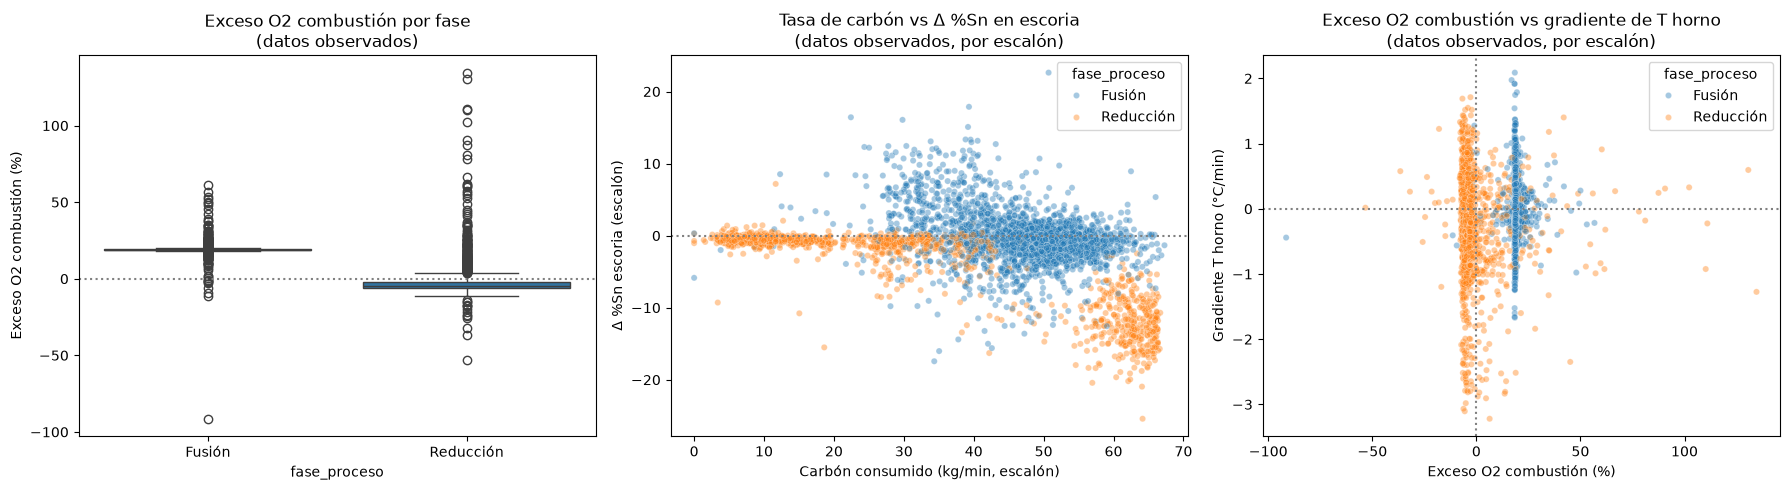

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="fase_proceso", y="exceso_o2_combustion_pct", ax=axes[0])
axes[0].axhline(0, color="grey", linestyle=":")
axes[0].set_title("Exceso O2 combustión por fase\n(datos observados)")
axes[0].set_ylabel("Exceso O2 combustión (%)")

sns.scatterplot(
    data=df_no_primer_escalon, x="tasa_feed_Carbon_kg_min", y="d_ley_sn_escoria_pct",
    hue="fase_proceso", alpha=0.4, s=20, ax=axes[1],
)
axes[1].axhline(0, color="grey", linestyle=":")
axes[1].set_title("Tasa de carbón vs Δ %Sn en escoria\n(datos observados, por escalón)")
axes[1].set_xlabel("Carbón consumido (kg/min, escalón)")
axes[1].set_ylabel("Δ %Sn escoria (escalón)")

sns.scatterplot(
    data=df_no_primer_escalon, x="exceso_o2_combustion_pct", y="grad_temperatura_horno_celsius",
    hue="fase_proceso", alpha=0.4, s=20, ax=axes[2],
)
axes[2].axhline(0, color="grey", linestyle=":")
axes[2].axvline(0, color="grey", linestyle=":")
axes[2].set_title("Exceso O2 combustión vs gradiente de T horno\n(datos observados, por escalón)")
axes[2].set_xlabel("Exceso O2 combustión (%)")
axes[2].set_ylabel("Gradiente T horno (°C/min)")

plt.tight_layout()
plt.show()


**Confirmación visual clara:** el signo de `Δ%Sn escoria` está dominado por la **fase** — en Fusión es
mayormente positivo (la escoria se está formando y concentrando SnO₂ proveniente de la carga), en
Reducción es mayormente negativo (el carbón reduce el SnO₂ de vuelta a Sn metálico). Dentro de cada fase,
a mayor tasa de carbón, mayor es la magnitud del cambio — el patrón es coherente con la estequiometría de
reducción de casiterita.

## Paso 5: de los deltas por escalón al KPI de batch (`rendimiento_proxy_batch`)

Como cada batch tiene siempre 7 escalones de Fusión + 4 de Reducción, se pueden agregar los indicadores
de escalón a nivel de batch y cruzarlos contra `rendimiento_proxy_batch` — esto es el puente entre el
análisis diferencial (a nivel escalón) y el objetivo de negocio (a nivel batch).


In [ ]:
df_batch = feature_engineering.construir_resumen_batch_eda(df)

cols_batch_corr = [
    "rendimiento_proxy_batch", "carbon_total_fusion_kg", "carbon_total_reduccion_kg",
    "relacion_C_reduccion_vs_fusion", "exceso_o2_medio_fusion_pct", "exceso_o2_medio_reduccion_pct",
    "basicidad_media_fusion", "ley_sn_escoria_final_pct", "ley_sn_escoria_max_pct",
    "caida_ley_sn_reduccion_pct", "temperatura_media_horno",
]
corr_batch = df_batch[cols_batch_corr].corr(method="spearman")["rendimiento_proxy_batch"].drop("rendimiento_proxy_batch")
corr_batch.sort_values(key=abs, ascending=False)

carbon_total_reduccion_kg         0.133027
exceso_o2_medio_reduccion_pct     0.123525
exceso_o2_medio_fusion_pct       -0.119840
caida_ley_sn_reduccion_pct       -0.104124
carbon_total_fusion_kg            0.093939
temperatura_media_horno          -0.071774
ley_sn_escoria_max_pct            0.069941
relacion_C_reduccion_vs_fusion    0.040384
basicidad_media_fusion            0.018769
ley_sn_escoria_final_pct         -0.016331
Name: rendimiento_proxy_batch, dtype: float64

**Lectura:** ninguna correlación simple (Spearman, agregados de batch) supera |0.13| con
`rendimiento_proxy_batch`. Esto **no invalida** el enfoque diferencial — sugiere que la relación entre
química de proceso y rendimiento no es capturable con agregados lineales simples (sumas/promedios por
fase), y motiva modelar a **nivel de escalón** (sección siguiente) en vez de agregados de batch.

## Síntesis del EDA (detalle completo en `hallazgos.md`)

1. `feed_*`/`volumen_*` son consumos ya discretizados por escalón (no acumulados) → se usan como tasas
   (kg/min, Nm³/min).
2. Las variables de estado (leyes, temperatura, presiones) se diferencian (`Δ`, `grad=Δ/Δt`) entre
   escalones consecutivos del mismo batch — el `Δ` captura el efecto neto de los reactivos consumidos en
   ese mismo escalón.
3. `exceso_o2_combustion_pct` separa nítidamente el régimen: Fusión ≈+19% (oxidante) vs. Reducción ≈-5%
   (reductor), validación numérica y visual del proxy redox.
4. Estequiometría de reducción de casiterita ($SnO_2+2C\rightarrow Sn+2CO_2$) visible en los datos:
   `tasa_feed_Carbon_kg_min` correlaciona -0.76 con `Δ%Sn escoria` en Reducción, -0.33 en Fusión.
5. Agregados simples por batch correlacionan débil con `rendimiento_proxy_batch` (|ρ|≤0.13) → se requiere
   modelar a nivel de escalón.
6. Calidad de datos: 2 leyes fuera de rango físico corregidas a `NaN`; nulos 3-14% en presiones y leyes de
   metales menores.


## Paso 6: enfoque analítico de modelamiento — qué se modela, y por qué

### ¿Qué problema se está resolviendo?

El objetivo final (`contexto.md`) es dar recomendaciones operacionales para subir `rendimiento_proxy_batch`.
Pero esa variable **sólo existe una vez por batch** (362 valores en total) y el EDA (Paso 5) ya mostró que
sus correlaciones simples con cualquier agregado de batch son débiles (|ρ|≤0.13): es una señal demasiado
agregada para "aprender" de ella directamente con sólo 362 filas, y además **no dice en qué momento del
batch** se gana o se pierde rendimiento.

En cambio, cada escalón (3982 en total) trae una medición directa y frecuente del **avance de la reacción
pirometalúrgica**: cuánto cambió la ley de `%Sn` en la escoria en ese escalón puntual. Ese cambio es
consecuencia mecánica de qué tan oxidante/reductora fue la atmósfera de la lanza y cuánto reactivo se le
dio al baño en ese mismo escalón — es decir, es una señal **causalmente más cercana** a las variables que
el operador controla, y hay ~11x más observaciones para aprenderla. La estrategia es entonces:

$$ \text{(1) modelar bien } \Delta\%Sn_{\text{escoria}} \text{ por escalón} \;\rightarrow\;
   \text{(2) integrar esa dinámica a lo largo del batch} \;\rightarrow\;
   \text{(3) conectar con } \text{rendimiento\_proxy\_batch} $$

Los Pasos 6-7 de este notebook resuelven (1), el Paso 8 explora (2)-(3) y encuentra que, con los datos
actuales, el paso (2)→(3) requiere información adicional no disponible (ver conclusión del Paso 8) — pero
(1) por sí solo ya es información accionable: saber *qué mueve la aguja* de la reacción, escalón a escalón.

### ¿Por qué el target es `d_ley_sn_escoria_pct` (el `Δ` del escalón) y no la ley en sí?

- La **ley en sí** (`ley_sn_escoria_pct`) es un nivel que arrastra todo lo ocurrido desde el inicio del
  batch; el **cambio** (`Δ`) aísla el efecto **de ese escalón en particular**, que es lo que el operador
  puede influenciar *en ese momento* con las dosis de reactivo de ese mismo escalón.
- Es una cantidad con fundamento estequiométrico directo: en Reducción, $SnO_2+2C\rightarrow Sn+2CO_2$
  predice que más carbón agregado en el escalón produce una caída de `%Sn` en la escoria en ese mismo
  escalón — algo que se puede verificar (y se verificó, ver Paso 7) con un modelo.
- Es reproducible/interpretable en unidades directas (puntos porcentuales de ley), fácil de comunicar a
  proceso, y ya mostró (EDA, `hallazgos.md` §4) correlación fuerte con los reactivos a nivel de escalón,
  a diferencia de los agregados de batch.

### ¿Por qué estas features y no otras? (fundamento pirometalúrgico de cada una)

| Feature | Rol pirometalúrgico |
|---|---|
| `tasa_feed_Carbon_kg_min` | Reductor estequiométrico directo ($SnO_2+2C\rightarrow Sn+2CO_2$); la palanca operativa más pura para pedir más/menos reducción. |
| `tasa_gn_nm3_min`, `tasa_o2_nm3_min`, `tasa_aire_nm3_min` | Definen la combustión de la lanza Ausmelt (calor entregado y atmósfera generada). |
| `exceso_o2_combustion_pct` | Resumen agregado del balance redox de la lanza (positivo=oxidante, negativo=reductor), construido a partir de las 3 tasas anteriores — ya validado en el EDA como separador nítido de Fusión/Reducción. |
| `basicidad_B2` | Química ácido-base de la escoria (sistema fayalítico FeO–SiO₂–CaO); controla cuánto SnO₂ queda atrapado vs. se libera. |
| `grad_temperatura_horno_celsius` | Energía/cinética disponible para que la reacción avance en ese escalón. |
| `posicion_vertical_lanza_mm` | Profundidad de inyección de la lanza; afecta la mezcla y la transferencia de masa/calor hacia el baño. |
| `delta_tiempo` | Duración del escalón — a igual tasa de reactivo, más tiempo permite que reaccione más masa (variable de "exposición"). |
| `orden_escalon_fase` | Posición relativa dentro de la fase (0=primero); proxy del historial acumulado del batch hasta ese punto (cuánta carga ya se fundió/redujo), información implícita que no está en ninguna otra columna. |

**Qué se dejó deliberadamente fuera:**
- Las **leyes de escoria contemporáneas** (`ley_sn_escoria_pct` y demás) **no** se usan como *feature*
  porque el *target* es justamente la diferencia de esa misma columna entre escalones — incluirla sería
  fuga de información trivial (el modelo "vería" el resultado). Sólo se usa su `Δ` como *target*, nunca la
  ley del mismo escalón como predictor.
- Las variables **únicas por batch** (`sn_en_metal_crudo_batch_t`, etc.) tampoco se incluyen: no varían
  dentro del batch y, en la práctica, no se conocen "en vivo" mientras el batch todavía está en curso.

### ¿Cómo se modela y se valida? (resumen; detalle en las celdas de código siguientes)

1. **Un modelo por fase** (Fusión y Reducción por separado — química y reactivos relevantes distintos).
2. **XGBoost** (gradient boosting) para capturar no linealidades/interacciones, dado que la relación
   lineal simple (Paso 5) ya se mostró insuficiente.
3. **Doble validación:** `GroupKFold` por `Batch` (evita mezclar escalones del mismo batch entre train y
   test) y luego **out-of-time walk-forward** (`TimeSeriesSplit`, Paso 6b) para simular el uso real en
   producción — entrenar sólo con el pasado, predecir el futuro.
4. **SHAP** para verificar, variable por variable, que lo que el modelo aprendió tiene sentido
   pirometalúrgico (Paso 7) **antes** de considerar cualquier uso prescriptivo.



In [54]:
FEATURES_MODELO = [
    "tasa_feed_Carbon_kg_min", "tasa_gn_nm3_min", "tasa_o2_nm3_min", "tasa_aire_nm3_min",
    "exceso_o2_combustion_pct", "basicidad_B2", "grad_temperatura_horno_celsius",
    "posicion_vertical_lanza_mm", "delta_tiempo", "orden_escalon_fase",
]
TARGET_MODELO = "d_ley_sn_escoria_pct"

# Excluye el primer escalon de cada batch (sin delta valido) y filas con NaN en
# features/target/Batch (nulos de leyes, presiones, etc. descritos en el EDA).
df_modelo = df[~df["es_primer_escalon_batch"]].copy()

datasets_fase = {}
for fase in ["Fusión", "Reducción"]:
    sub = df_modelo.loc[df_modelo["fase_proceso"] == fase, FEATURES_MODELO + [TARGET_MODELO, "Batch"]]
    n_antes = len(sub)
    sub = sub.dropna()
    datasets_fase[fase] = sub
    print(f"{fase}: {len(sub)} de {n_antes} escalones utilizables, {sub['Batch'].nunique()} batches distintos")



Fusión: 2147 de 2172 escalones utilizables, 361 batches distintos
Reducción: 1328 de 1448 escalones utilizables, 361 batches distintos


In [55]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score

N_SPLITS = 5
PARAMS_XGB = dict(
    n_estimators=300, learning_rate=0.03, max_depth=4,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, n_jobs=-1,
)

oof_predicciones = {}
resultados_modelo = {}
for fase, sub in datasets_fase.items():
    X = sub[FEATURES_MODELO].to_numpy()
    y = sub[TARGET_MODELO].to_numpy()
    groups = sub["Batch"].to_numpy()

    oof_pred = np.full(len(sub), np.nan)
    for train_idx, test_idx in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X[train_idx], y[train_idx])
        oof_pred[test_idx] = modelo_fold.predict(X[test_idx])

    oof_predicciones[fase] = oof_pred
    mae_baseline = mean_absolute_error(y, np.full(len(y), y.mean()))
    resultados_modelo[fase] = {
        "r2_oof": r2_score(y, oof_pred),
        "mae_oof": mean_absolute_error(y, oof_pred),
        "mae_baseline": mae_baseline,
        "n": len(y),
    }

resultados_df = pd.DataFrame(resultados_modelo).T
print(f"Validacion cruzada GroupKFold (n_splits={N_SPLITS}, agrupado por Batch — ningun batch comparte train/test):")
resultados_df


Validacion cruzada GroupKFold (n_splits=5, agrupado por Batch — ningun batch comparte train/test):


,r2_oof,mae_oof,mae_baseline,n
Fusión,0.362904,2.195689,2.682812,2147.0
Reducción,0.854354,1.241616,4.496618,1328.0


**Resultado (out-of-fold, sin fuga de información entre batches):**

- **Reducción: $R^2$ ≈ 0.85**, MAE ≈ 1.24 puntos porcentuales de `%Sn escoria` (vs. 4.50 de un modelo
  trivial que sólo predice el promedio) — las variables de escalón (sobre todo carbón y redox) explican
  la gran mayoría de la variabilidad del `Δ%Sn` en Reducción. Confirma con un modelo no lineal lo que ya
  sugerían las correlaciones simples (`hallazgos.md` §4): la reducción de casiterita es, a nivel de
  escalón, un fenómeno mayormente explicable por la intensidad del reductor y el redox de la lanza.
- **Fusión: $R^2$ ≈ 0.36**, mejora más modesta sobre el baseline (MAE 2.20 vs. 2.68) — en Fusión el
  `Δ%Sn` depende de más factores no incluidos aquí (ej. composición/granulometría de la carga sólida,
  arrastre físico de partículas), consistente con que en Fusión el cambio de ley es más un efecto de
  balance de masas de la carga entrante que de la química de la lanza.

**Importante — esto NO es una validación *out-of-time* (OOT):** `GroupKFold` sólo garantiza que ningún
`Batch` comparta filas entre train y test, pero asigna los batches a los folds sin considerar su orden
cronológico (`fecha_inicio`). Un batch de un mes puede quedar en entrenamiento mientras uno de un mes
anterior queda en test. Si el proceso deriva en el tiempo (desgaste de refractario/lanza, cambios de
mineral, ajustes operativos), esta validación podría verse mejor de lo que rendiría el modelo en
producción real (siempre prediciendo el futuro con datos del pasado). Se valida esto a continuación.

## Paso 6b: Validación adicional out-of-time (walk-forward por orden cronológico de batch)

Se ordenan los batches por su `fecha_inicio` y se usa `TimeSeriesSplit` sobre esa secuencia (ventana de
entrenamiento expansiva): en cada fold, el modelo entrena **sólo con batches anteriores** en el tiempo y
se evalúa **únicamente sobre batches posteriores**, replicando cómo se usaría el modelo en producción.



In [56]:
from sklearn.model_selection import TimeSeriesSplit

# Orden cronologico de batches, segun la fecha de inicio de su primer escalon
orden_batches = df.groupby("Batch")["fecha_inicio"].min().sort_values().index.tolist()

N_SPLITS_OOT = 5
resultados_oot = {}
detalle_folds_oot = {}
for fase, sub in datasets_fase.items():
    sub_ordenado = sub.set_index("Batch").loc[[b for b in orden_batches if b in set(sub["Batch"])]].reset_index()
    batches_fase_orden = sub_ordenado["Batch"].drop_duplicates().tolist()
    X_full = sub_ordenado[FEATURES_MODELO].to_numpy()
    y_full = sub_ordenado[TARGET_MODELO].to_numpy()
    batch_arr = sub_ordenado["Batch"].to_numpy()

    oot_pred = np.full(len(sub_ordenado), np.nan)
    folds_info = []
    for fold_id, (train_pos, test_pos) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS_OOT).split(batches_fase_orden)):
        batches_train = set(batches_fase_orden[i] for i in train_pos)
        batches_test = set(batches_fase_orden[i] for i in test_pos)
        mask_train = np.isin(batch_arr, list(batches_train))
        mask_test = np.isin(batch_arr, list(batches_test))

        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X_full[mask_train], y_full[mask_train])
        pred = modelo_fold.predict(X_full[mask_test])
        oot_pred[mask_test] = pred
        folds_info.append({
            "fold": fold_id, "n_batches_train": len(batches_train), "n_batches_test": len(batches_test),
            "r2": r2_score(y_full[mask_test], pred), "mae": mean_absolute_error(y_full[mask_test], pred),
        })

    detalle_folds_oot[fase] = pd.DataFrame(folds_info)
    valido = ~np.isnan(oot_pred)
    resultados_oot[fase] = {
        "r2_oot": r2_score(y_full[valido], oot_pred[valido]),
        "mae_oot": mean_absolute_error(y_full[valido], oot_pred[valido]),
        "n_evaluado": int(valido.sum()),
    }

for fase in datasets_fase:
    print(f"--- {fase}: detalle por fold (walk-forward, orden cronologico) ---")
    print(detalle_folds_oot[fase].to_string(index=False))
    print()

resultados_oot_df = pd.DataFrame(resultados_oot).T
print("Resumen OOT (todas las predicciones de test de todos los folds, concatenadas):")
resultados_oot_df


--- Fusión: detalle por fold (walk-forward, orden cronologico) ---
 fold  n_batches_train  n_batches_test       r2      mae
    0               61              60 0.204454 2.297594
    1              121              60 0.094398 2.140192
    2              181              60 0.386120 2.364629
    3              241              60 0.424214 2.517082
    4              301              60 0.270684 2.232034

--- Reducción: detalle por fold (walk-forward, orden cronologico) ---
 fold  n_batches_train  n_batches_test       r2      mae
    0               61              60 0.801849 1.555000
    1              121              60 0.790568 1.480703
    2              181              60 0.788752 1.457181
    3              241              60 0.810472 1.226430
    4              301              60 0.796889 1.665977

Resumen OOT (todas las predicciones de test de todos los folds, concatenadas):


,r2_oot,mae_oot,n_evaluado
Fusión,0.302967,2.309539,1783.0
Reducción,0.798777,1.475952,1106.0


**Lectura — comparación OOF (agrupado por batch) vs. OOT (cronológico, walk-forward):**

| Fase | $R^2$ OOF (GroupKFold) | $R^2$ OOT (walk-forward) | Diferencia |
|---|---|---|---|
| Reducción | 0.854 | 0.799 | -0.055 |
| Fusión | 0.363 | 0.303 | -0.060 |

- **El desempeño se mantiene razonablemente estable en el tiempo** en ambas fases (caída de ~0.05-0.06
  en $R^2$, y los 5 folds cronológicos de Reducción son consistentes entre sí: 0.79-0.81, sin ningún fold
  que colapse) — no hay evidencia de una deriva fuerte del proceso que invalide el modelo al usarlo hacia
  adelante en el tiempo. La caída observada es el **gap de generalización normal** esperable al pasar de
  una validación agrupada (que aún permite usar información de "vecinos temporales" del mismo período)
  a una genuinamente prospectiva (entrenar sólo con el pasado).
- **Reducción sigue siendo claramente la fase mejor explicada** ($R^2$≈0.80 incluso en el fold más
  antiguo, con sólo 61 batches de entrenamiento) — la relación estequiométrica carbón→reducción de
  casiterita es estable en el tiempo, como cabría esperar de un mecanismo fisicoquímico y no de un patrón
  espurio ligado a una ventana temporal particular.
- **Conclusión:** el resultado original (`GroupKFold`) **no estaba inflado por fuga temporal** de forma
  relevante; el modelo pasa también el chequeo out-of-time y es razonable considerarlo como punto de
  partida para uso prospectivo, sin perjuicio de seguir monitoreando su desempeño con datos nuevos según
  vayan llegando (reentrenamiento periódico recomendado dado el ligero gap observado).

## Paso 7: interpretabilidad del modelo (SHAP)

Se reentrena un modelo por fase con **todos** los datos disponibles (ya no en folds) únicamente para
inspeccionar qué variables pesan más y en qué dirección, usando valores SHAP (Shapley additive
explanations): para cada escalón y cada variable, SHAP asigna cuánto empujó esa variable la predicción
por encima/debajo del promedio. Esto permite verificar que el modelo aprendió relaciones
**pirometalúrgicamente coherentes** (ej. signo negativo de `tasa_feed_Carbon_kg_min` en Reducción) antes
de considerarlo para uso prescriptivo.



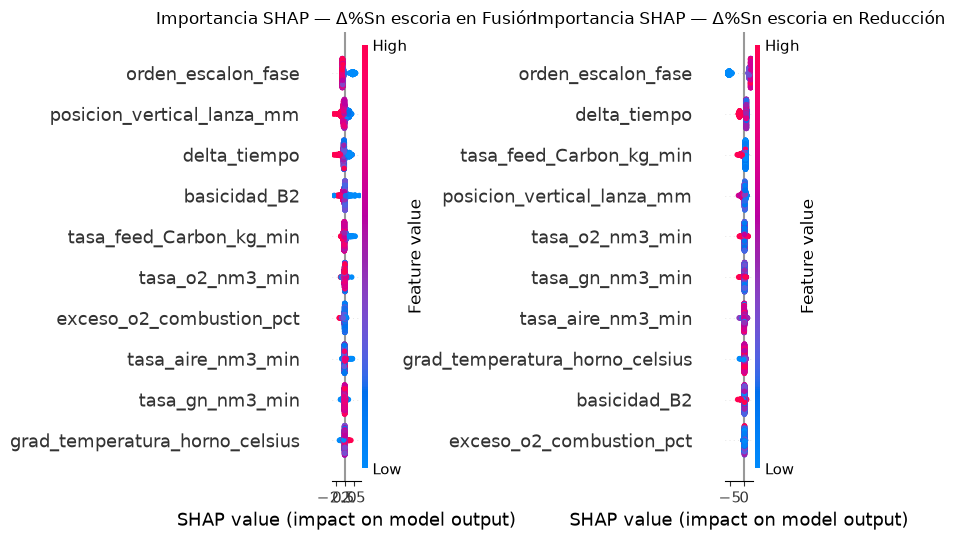

In [57]:
import shap
import matplotlib.pyplot as plt

modelos_finales = {}
valores_shap = {}
for fase, sub in datasets_fase.items():
    X = sub[FEATURES_MODELO]
    y = sub[TARGET_MODELO]
    modelo = xgb.XGBRegressor(**PARAMS_XGB)
    modelo.fit(X, y)
    modelos_finales[fase] = modelo
    valores_shap[fase] = shap.TreeExplainer(modelo)(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    plt.sca(ax)
    shap.plots.beeswarm(valores_shap[fase], show=False, max_display=10)
    ax.set_title(f"Importancia SHAP — Δ%Sn escoria en {fase}")
plt.tight_layout()
plt.show()


In [58]:
# ---------------------------------------------------------------------------
# Signo del efecto marginal de cada variable: correlacion (Pearson) entre el
# valor de la variable y su propio valor SHAP en ese escalon. Signo positivo =
# a mayor valor de la variable, el modelo empuja Δ%Sn hacia arriba (y viceversa).
# ---------------------------------------------------------------------------
signo_shap = {}
for fase, sub in datasets_fase.items():
    sv = valores_shap[fase].values
    X = sub[FEATURES_MODELO]
    signo_shap[fase] = pd.Series(
        {col: np.corrcoef(X[col], sv[:, i])[0, 1] for i, col in enumerate(FEATURES_MODELO)}
    )

signo_shap_df = pd.DataFrame(signo_shap)
signo_shap_df["importancia_media_|SHAP|_fusion"] = np.abs(valores_shap["Fusión"].values).mean(axis=0)
signo_shap_df["importancia_media_|SHAP|_reduccion"] = np.abs(valores_shap["Reducción"].values).mean(axis=0)
signo_shap_df.sort_values("importancia_media_|SHAP|_reduccion", ascending=False)


,Fusión,Reducción,importancia_media_|SHAP|_fusion,importancia_media_|SHAP|_reduccion
orden_escalon_fase,-0.693566,0.812403,0.855382,2.907146
delta_tiempo,-0.732717,-0.650613,0.525060,0.927412
tasa_feed_Carbon_kg_min,-0.851347,-0.804560,0.261663,0.439470
posicion_vertical_lanza_mm,-0.914654,-0.741493,0.544324,0.310323
tasa_o2_nm3_min,-0.167789,-0.257435,0.142945,0.154579
tasa_gn_nm3_min,0.384191,-0.216952,0.105712,0.124050
tasa_aire_nm3_min,-0.360659,0.012897,0.113058,0.118416
grad_temperatura_horno_celsius,0.352817,0.276197,0.096559,0.105391
basicidad_B2,-0.653613,-0.208124,0.303227,0.084776
exceso_o2_combustion_pct,-0.310840,0.035682,0.114550,0.055641


## Paso 7b: gráficos de dependencia SHAP (validación visual de la tendencia)

La tabla anterior sólo da el **signo** del efecto marginal (una correlación). Un gráfico de dependencia
SHAP muestra, para cada escalón, el valor de la variable en el eje X y su valor SHAP (el aporte de esa
variable a la predicción de `Δ%Sn escoria` en ese escalón puntual) en el eje Y — permite ver si la
tendencia es aproximadamente lineal, si satura, o si tiene un umbral, algo que la sola correlación no
distingue. Se grafican las 5 variables con fundamento pirometalúrgico más directo, y se resume la
tendencia con una curva LOWESS (suavizado no paramétrico) más el promedio por tercil (bajo/medio/alto) de
cada variable, para poder describir la forma de la tendencia con números y no sólo a ojo.



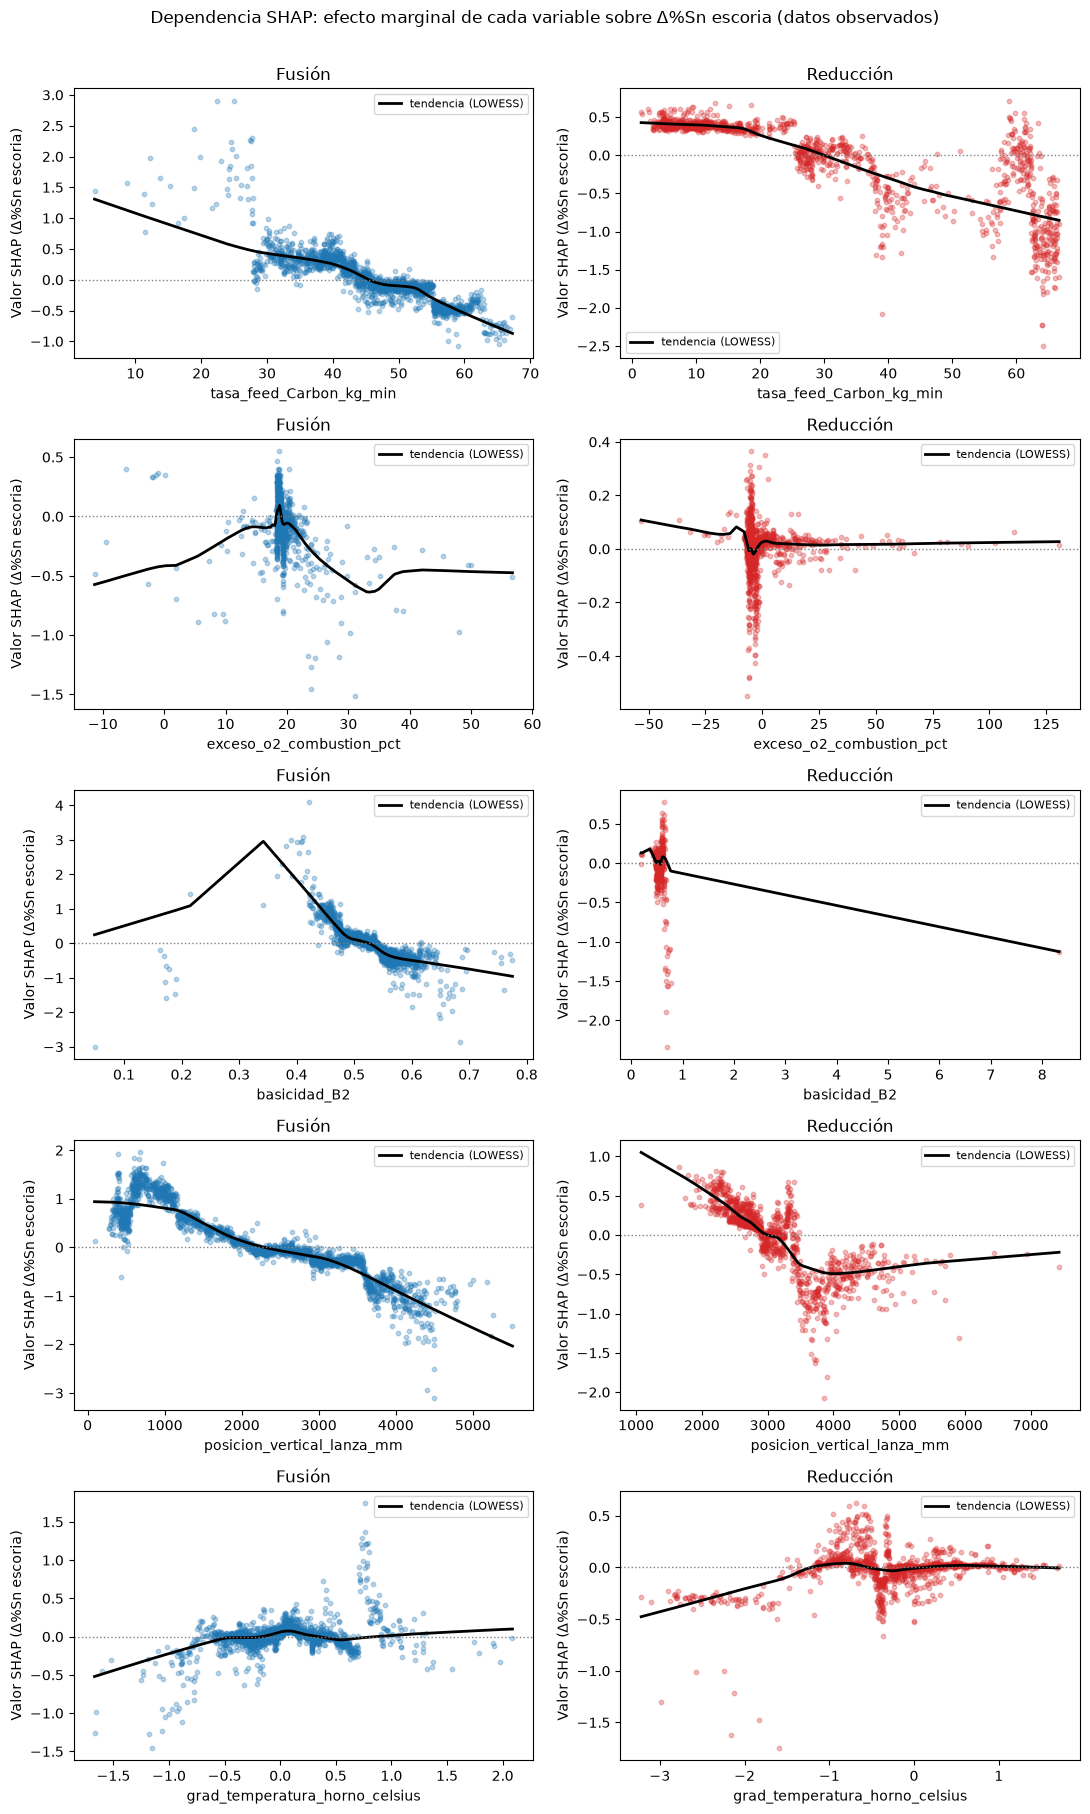

Valor SHAP medio por tercil de cada variable (bajo/medio/alto valor de la variable):

tasa_feed_Carbon_kg_min:
         Fusión  Reducción
bajo   0.376258   0.406563
medio -0.085337   0.166192
alto  -0.296644  -0.626221

exceso_o2_combustion_pct:
         Fusión  Reducción
bajo   0.028548  -0.009039
medio  0.081586  -0.001371
alto  -0.112205   0.005551

basicidad_B2:
         Fusión  Reducción
bajo   0.371690   0.001637
medio  0.028233   0.022188
alto  -0.426567  -0.041974

posicion_vertical_lanza_mm:
         Fusión  Reducción
bajo   0.877988   0.303926
medio -0.002952   0.029520
alto  -0.624785  -0.442934

grad_temperatura_horno_celsius:
         Fusión  Reducción
bajo  -0.066735   0.009932
medio  0.065579  -0.064845
alto   0.041178   0.010445


In [59]:
from statsmodels.nonparametric.smoothers_lowess import lowess

FEATURES_PDP = [
    "tasa_feed_Carbon_kg_min", "exceso_o2_combustion_pct", "basicidad_B2",
    "posicion_vertical_lanza_mm", "grad_temperatura_horno_celsius",
]

fig, axes = plt.subplots(len(FEATURES_PDP), 2, figsize=(11, 3.6 * len(FEATURES_PDP)))
tabla_terciles = {}
for row, feat in enumerate(FEATURES_PDP):
    idx_feat = FEATURES_MODELO.index(feat)
    medias_fase = {}
    for col, fase in enumerate(["Fusión", "Reducción"]):
        ax = axes[row, col]
        x = datasets_fase[fase][feat].to_numpy()
        y_shap = valores_shap[fase].values[:, idx_feat]

        ax.scatter(x, y_shap, s=10, alpha=0.3, color="tab:blue" if fase == "Fusión" else "tab:red")
        tendencia = lowess(y_shap, x, frac=0.4, return_sorted=True)
        ax.plot(tendencia[:, 0], tendencia[:, 1], color="black", linewidth=2, label="tendencia (LOWESS)")
        ax.axhline(0, color="grey", linestyle=":", linewidth=1)
        ax.set_xlabel(feat)
        ax.set_ylabel("Valor SHAP (Δ%Sn escoria)")
        ax.set_title(f"{fase}")
        ax.legend(fontsize=8, loc="best")

        terciles = pd.qcut(x, 3, labels=["bajo", "medio", "alto"], duplicates="drop")
        medias_fase[fase] = pd.Series(y_shap).groupby(terciles, observed=True).mean()
    tabla_terciles[feat] = pd.DataFrame(medias_fase)

fig.suptitle("Dependencia SHAP: efecto marginal de cada variable sobre Δ%Sn escoria (datos observados)", y=1.005)
plt.tight_layout()
plt.show()

print("Valor SHAP medio por tercil de cada variable (bajo/medio/alto valor de la variable):")
for feat, tabla in tabla_terciles.items():
    print(f"\n{feat}:")
    print(tabla)


**Lectura de los gráficos de dependencia (¿tiene sentido pirometalúrgico la tendencia?):**

- **`tasa_feed_Carbon_kg_min` — sentido pleno, sin sorpresas.** Tendencia **monótona decreciente** y
  limpia en ambas fases, sin umbral ni saturación visible (tercil bajo→alto: Fusión +0.38→-0.30,
  Reducción +0.41→-0.63 puntos de `%Sn`). Es la relación dosis-respuesta más clara de las cinco,
  exactamente lo esperado de $SnO_2+2C\rightarrow Sn+2CO_2$: a más reductor, mayor caída de `%Sn` en la
  escoria, sin importar en qué tramo de la fase se esté. **Chequeo superado.**
- **`posicion_vertical_lanza_mm` — tendencia fuerte y monótona, pero el sentido físico exacto requiere
  confirmación de proceso.** También decreciente y limpia en ambas fases (Fusión +0.88→-0.62, Reducción
  +0.30→-0.44). El diccionario de datos sólo indica *"altura o posición vertical de la lanza"*, sin
  precisar si un valor más alto es lanza más elevada (menos sumergida) o más baja (más sumergida) —
  mecánicamente es plausible que una mayor inmersión mejore la transferencia de masa/calor hacia el baño
  y acelere la reacción, pero **no se puede confirmar el sentido sin esa definición exacta**. Se marca
  como variable operativa de alto interés a validar con el equipo de proceso antes de cualquier uso
  prescriptivo.
- **`basicidad_B2` — sentido razonable en Fusión, no interpretable en Reducción por un problema de datos
  ya conocido.** En Fusión la tendencia es monótona decreciente (tercil +0.37→-0.43): más basicidad
  (más fundente CaO/MgO relativo a SiO₂/Al₂O₃) favorece una escoria más fluida con menor capacidad de
  retener SnO₂ — coherente con la química ácido-base de un sistema fayalítico. En Reducción, el eje X
  llega hasta ~8 (vs. ~0.8 en Fusión): son los mismos outliers de `%SiO2`≈0 ya documentados en
  `hallazgos.md` §3.e/§5, que distorsionan la curva LOWESS; la tabla de terciles (más robusta a esos
  outliers) muestra un efecto prácticamente nulo en Reducción (≈0.00 a -0.04), lo cual **también tiene
  sentido**: la basicidad gobierna la formación/fluidez de la escoria (relevante en Fusión), no la
  reacción de reducción del Sn ya formado.
- **`exceso_o2_combustion_pct` — efecto marginal débil e inconsistente una vez controladas las demás
  variables.** Las medias por tercil son pequeñas y no monótonas (Fusión: +0.03→+0.08→-0.11; Reducción:
  ≈0 en los tres terciles). Contrasta con su fuerte rol en el EDA univariado (`hallazgos.md` §4) — la
  explicación más probable es colinealidad: el redox de la lanza covaría fuertemente con
  `tasa_feed_Carbon_kg_min` y `orden_escalon_fase` (ambos ya en el modelo), por lo que gran parte de su
  poder explicativo univariado queda "absorbido" por esas otras variables. Sigue teniendo sentido como
  **indicador de régimen** (Fusión oxidante / Reducción reductor), aunque no como palanca marginal
  independiente en este modelo conjunto.
- **`grad_temperatura_horno_celsius` — sin tendencia marginal clara, contribución pequeña y ruidosa.**
  Las medias por tercil son cercanas a cero y no monótonas en ninguna fase. Es consistente con que la
  temperatura del horno responda a (más que cause) el balance de reacciones — probablemente actúa más
  vía interacción con otras variables que como efecto marginal propio; no amerita una historia
  pirometalúrgica de primer orden por sí sola a este nivel de análisis.

**Conclusión del chequeo de sensatez:** la variable con el fundamento estequiométrico más directo
(`tasa_feed_Carbon_kg_min`) pasa el chequeo sin reservas, `basicidad_B2` también tiene sentido una vez
separado el artefacto de datos en Reducción, y `posicion_vertical_lanza_mm` emerge como una palanca
operativa potente pero pendiente de confirmar su sentido físico exacto con el equipo de proceso antes de
usarla en cualquier recomendación.



**Lectura de las columnas `Fusión`/`Reducción` de la tabla:** son la correlación de Pearson entre el
valor de cada variable y su propio valor SHAP en ese escalón — el signo indica la dirección del efecto
marginal que aprendió el modelo (positivo = a mayor valor de la variable, mayor `Δ%Sn escoria`; negativo =
lo contrario), y las columnas `importancia_media_|SHAP|` ordenan qué tan determinante es cada variable en
magnitud.

**Chequeo de coherencia pirometalúrgica (comparar contra `hallazgos.md` §4):**

- **`tasa_feed_Carbon_kg_min`: signo negativo en ambas fases** (-0.85 Fusión, -0.80 Reducción) — el modelo
  aprendió exactamente la relación esperada de $SnO_2 + 2C \rightarrow Sn + 2CO_2$: más carbón por minuto
  → mayor caída (o menor subida) de `%Sn` en la escoria. Coincide en signo con la correlación simple de
  Spearman ya reportada en el EDA (-0.76 en Reducción, -0.33 en Fusión).
- **`orden_escalon_fase` es, con diferencia, la variable más influyente en Reducción** (importancia
  ≈2.9, más de 6× la siguiente): tiene sentido porque el mayor salto de reducción ocurre casi siempre en
  el **primer** escalón de Reducción (ver batch AP0001, sección visual del EDA) — el modelo está
  capturando que "en qué escalón de la fase estoy" ya anticipa gran parte de la magnitud del cambio,
  independientemente del detalle fino de reactivos. Es una variable disponible operacionalmente (se sabe
  en qué escalón se está) pero **no es accionable por sí sola** — el reductor (`tasa_feed_Carbon_kg_min`)
  sigue siendo la palanca operativa relevante dentro de cada escalón.
- **`delta_tiempo` con signo negativo en ambas fases**: escalones más largos (a igual tasa de reactivo)
  acumulan más masa reaccionando, lo cual es coherente si el signo de `Δ%Sn` de referencia en esa fase es
  negativo (Reducción) — y en Fusión el signo negativo refleja que escalones largos tienden a ubicarse
  hacia el final de la fase (`orden_escalon_fase` alto), donde el `Δ%Sn` dado dato tiende a estabilizarse
  o revertir.
- **`posicion_vertical_lanza_mm` tiene una correlación fuerte** (-0.91 Fusión, -0.74 Reducción) — variable
  operativa relevante que no se había explorado a fondo en el EDA original; candidata a inspección
  adicional (¿la altura de lanza más baja mejora la transferencia de calor/reactivo al baño?) antes de
  usarla de forma prescriptiva.
- **`exceso_o2_combustion_pct` y `basicidad_B2` con efecto marginal menor** una vez controlado por las
  demás variables — su rol en el EDA simple (correlación univariada) parece estar mediado en parte por
  `tasa_feed_Carbon_kg_min`/`orden_escalon_fase` (colinealidad esperable: el redox y el carbón cambian
  juntos en la transición Fusión→Reducción).

**Conclusión:** el modelo no lineal (i) mejora sustancialmente sobre agregados lineales de batch (Paso 5)
y sobre el baseline ingenuo a nivel de escalón, y (ii) aprende una relación **pirometalúrgicamente
coherente** para la variable con fundamento estequiométrico más claro (`tasa_feed_Carbon_kg_min`) — pasa
el chequeo de sensatez necesario antes de considerar su uso prescriptivo (`hallazgos.md` §6).

## Paso 8: de la predicción por escalón al KPI de batch

Como validación adicional (no sólo el ajuste dentro de fase), se integra la trayectoria de `Δ%Sn escoria`
—tanto la observada como la predicha out-of-fold— a lo largo de cada batch y se compara su correlación con
`rendimiento_proxy_batch` contra el agregado lineal ingenuo ya descartado en el Paso 5.



In [60]:
# Para cada batch, suma OBSERVADA y suma PREDICHA (out-of-fold, sin fuga) de Δ%Sn escoria, por fase.
resumen_oof = []
for fase, sub in datasets_fase.items():
    tmp = sub[["Batch", TARGET_MODELO]].copy()
    tmp["pred_oof"] = oof_predicciones[fase]
    agregado = tmp.groupby("Batch").agg(observado=(TARGET_MODELO, "sum"), predicho=("pred_oof", "sum"))
    agregado.columns = [f"{c}_{fase.lower()}" for c in agregado.columns]
    resumen_oof.append(agregado)

df_oof_batch = pd.concat(resumen_oof, axis=1).reset_index()
df_batch_modelo = df_batch.merge(df_oof_batch, on="Batch", how="left")

cols_modelo_batch = [c for c in df_oof_batch.columns if c != "Batch"]
corr_modelo_batch = (
    df_batch_modelo[["rendimiento_proxy_batch"] + cols_modelo_batch]
    .corr(method="spearman")["rendimiento_proxy_batch"]
    .drop("rendimiento_proxy_batch")
)
print("Correlacion (Spearman) entre agregados de batch derivados del modelo de escalon y rendimiento_proxy_batch:")
print(corr_modelo_batch.sort_values(key=abs, ascending=False))
print("\nPara referencia, del Paso 5 (agregado lineal ingenuo): caida_ley_sn_reduccion_pct -> ",
      round(corr_batch["caida_ley_sn_reduccion_pct"], 3))


Correlacion (Spearman) entre agregados de batch derivados del modelo de escalon y rendimiento_proxy_batch:
predicho_reducción    -0.179749
observado_reducción   -0.115634
observado_fusión      -0.037146
predicho_fusión       -0.020788
Name: rendimiento_proxy_batch, dtype: float64

Para referencia, del Paso 5 (agregado lineal ingenuo): caida_ley_sn_reduccion_pct ->  -0.104


**Lectura:** integrar la trayectoria de `Δ%Sn escoria` a nivel de batch (sumando los escalones de
Reducción, ya sea el valor observado o el predicho out-of-fold por el modelo) sigue correlacionando débil
con `rendimiento_proxy_batch` (`predicho_reducción` ρ≈-0.18, `observado_reducción` ρ≈-0.12) — algo mejor
que el agregado lineal ingenuo del Paso 5 (ρ≈-0.10) pero lejos de ser suficiente para explicar el
rendimiento del batch.

**Esto es un hallazgo relevante, no un fracaso del modelo de escalón:** el modelo de escalón (§ Paso 6-7)
predice bien *dónde y cuánto* cambia la ley de `%Sn` en la escoria dado lo que se alimenta (R²≈0.85 en
Reducción); pero `rendimiento_proxy_batch` se define a partir de las **masas** de Sn en metal
crudo/dross/polvo, no directamente de la ley final de la escoria. Es decir, `Δ%Sn escoria` es un buen
proxy de la **cinética/extensión de la reacción de reducción**, pero no captura por sí solo cuánto Sn total
terminó en cada corriente de salida del batch (que depende también de las masas involucradas, no sólo de
las leyes). El puente entre "qué tan bien reduzco la escoria escalón a escalón" y "cuánto Sn metálico
recupero en el batch" requiere **datos de masa de escoria por escalón** (no disponibles en este dataset) o
un modelo de balance de masa explícito, no sólo agregar la ley.

## Síntesis de la etapa de modelamiento (Pasos 6-8)

1. **Modelo de escalón (XGBoost, validado con `GroupKFold` por `Batch`):** $R^2$≈0.85 en Reducción,
   $R^2$≈0.36 en Fusión — mejora sustancial sobre agregados lineales de batch y sobre un baseline ingenuo.
2. **Coherencia pirometalúrgica confirmada vía SHAP:** `tasa_feed_Carbon_kg_min` tiene efecto marginal
   negativo sobre `Δ%Sn escoria` en ambas fases (signo esperado de $SnO_2+2C\rightarrow Sn+2CO_2$),
   replicando el signo ya visto en las correlaciones simples del EDA.
3. **`orden_escalon_fase` es muy influyente en Reducción** — informativo pero poco accionable por sí
   solo; refuerza que el momento/secuencia del batch importa tanto como la cantidad total de reactivo.
4. **La integración a nivel de batch (Paso 8) sigue siendo débil** (|ρ|≤0.18) — el vínculo entre la
   química por escalón y `rendimiento_proxy_batch` requeriría datos de masa de escoria por escalón (no
   disponibles) para cerrarse con un balance de masa explícito; se documenta como limitación de datos.

**Próximos pasos sugeridos (fuera del alcance de esta sesión):** (a) solicitar/incorporar masa de escoria
por escalón si existe en planta, para poder convertir `Δ%Sn escoria` en `Δ(masa de Sn en escoria)` y así
cerrar el balance con `sn_en_metal_crudo_batch_t`; (b) probar el mismo modelo de escalón sobre otras leyes
(`ley_fe_total_escoria_pct`, `ley_feo_escoria_pct`) para enriquecer el balance de masa; (c) explorar
modelos secuenciales (ej. RNN/estado oculto por batch) que exploten explícitamente el orden de los
escalones en vez de tratarlos como observaciones independientes.



## Paso 9: hoja de ruta — de modelo predictivo a modelo prescriptivo

Resumen de lo logrado hasta aquí y los pasos concretos que faltan para llegar a recomendaciones
operacionales accionables (fuera del alcance de esta sesión, quedan como plan de trabajo).

### Dónde estamos (predictivo, nivel escalón)

Un modelo por fase que predice `Δ%Sn escoria` por escalón con buen ajuste (Reducción $R^2$≈0.80-0.85,
Fusión $R^2$≈0.30-0.36, ambos validados OOF y OOT) y que pasa el chequeo de coherencia pirometalúrgica
(SHAP + gráficos de dependencia, Pasos 7-7b). **Esto es un modelo predictivo de un paso intermedio del
proceso**, no todavía del KPI de negocio (`rendimiento_proxy_batch`) ni una herramienta prescriptiva.

### A. Para madurar el modelo predictivo

1. **Cerrar el vínculo con `rendimiento_proxy_batch`:** conseguir (o estimar) la **masa de escoria por
   escalón** para convertir `Δ%Sn escoria` en `Δ(masa de Sn en escoria)` y así poder integrar un balance
   de masa completo hasta `sn_en_metal_crudo_batch_t` (limitación identificada en el Paso 8).
2. **Replicar el modelo sobre las demás leyes** (`ley_fe_total_escoria_pct`, `ley_feo_escoria_pct`,
   `ley_sio2_escoria_pct`, etc.) para tener un balance redox/ácido-base completo, no sólo el Sn.
3. **Confirmar con el equipo de proceso** el sentido físico de `posicion_vertical_lanza_mm` (Paso 7b) y la
   interpretación de `feed_*`/`volumen_*` como consumo por escalón (`hallazgos.md` §2) — son supuestos de
   los que depende toda la cadena de features.
4. **Cuantificar incertidumbre, no sólo el punto estimado:** pasar de una predicción puntual a intervalos
   de predicción (ej. regresión cuantílica con XGBoost/LightGBM, o conformal prediction) — indispensable
   antes de prescribir, para saber cuánto confiar en cada recomendación según el contexto operativo.
5. **Monitoreo y reentrenamiento:** dado el gap OOF→OOT observado (Paso 6b), definir una cadencia de
   reentrenamiento (ej. mensual/trimestral) y un tablero simple de seguimiento de error en producción
   (para detectar si el proceso derivó y el modelo dejó de ser válido).

### B. Para pasar de predictivo a prescriptivo

6. **Ojo con causalidad vs. correlación:** SHAP explica **qué aprendió el modelo**, no prueba que
   `tasa_feed_Carbon_kg_min` **cause** el cambio de forma aislada de otros factores que covarían con ella
   (ej. `orden_escalon_fase`). Antes de prescribir dosis de reactivo, sería deseable:
   - revisar si existen episodios históricos con **variación cuasi-experimental** de la dosis de carbón a
     igualdad de las demás condiciones (para estimar el efecto de forma más causal), o
   - diseñar pequeñas **pruebas operativas controladas** (A/B a nivel de escalón/batch) antes de un
     despliegue amplio de cualquier recomendación.
7. **Definir la función objetivo y las restricciones operativas** explícitamente: maximizar
   `rendimiento_proxy_batch` (o el KPI que finalmente se conecte) sujeto a rangos físicos/seguros de cada
   palanca (ej. límites de `tasa_feed_Carbon_kg_min`, `posicion_vertical_lanza_mm`, capacidad de la
   lanza) — sin esto, cualquier optimización puede sugerir valores fuera de lo operable o seguro.
8. **Capa de optimización/recomendación:** con el modelo (o el conjunto de modelos por fase) más las
   restricciones del punto 7, usar búsqueda numérica (ej. optimización bayesiana, grid search restringido,
   o programación no lineal) para proponer, escalón a escalón, la dosis de reactivo que maximice la
   extensión de reacción esperada — traducido a reglas simples y explicables para el operador (ej. "si
   `basicidad_B2` < X y aún no se alcanza el `%Sn` objetivo, subir `tasa_feed_Carbon_kg_min` en Y kg/min"),
   no como una caja negra.
9. **Validar las prescripciones antes de operar con ellas:** simular el efecto esperado en batches
   históricos retenidos, y luego pilotear en un número acotado de batches reales con supervisión del
   equipo de proceso, comparando contra el grupo/práctica habitual, antes de una adopción generalizada.



## Paso 10: Feature engineering avanzado — estado previo, acumulados, composición y lanza/tren de gases

Retomando el plan de "próximos pasos" del Paso 9 y el detalle de `consideracioness_pirometalurgia_ausmelt.md`
(secciones 26-34), se identifican varias familias de features con fundamento pirometalúrgico que **no
estaban** en el modelo de los Pasos 6-9 y que pueden mejorar la predicción, especialmente en Fusión (donde
$R^2$≈0.36 sugería que faltan variables relevantes):

1. **Estado previo (`_prev`, sección 31 del documento).** El modelo de los Pasos 6-9 excluyó, correctamente,
   las leyes de escoria *contemporáneas* como feature (es fuga: el target es la diferencia de esa misma
   columna). Pero **excluir también el valor del escalón anterior fue una sobre-corrección**:
   `ley_sn_escoria_pct_prev` (el %Sn con el que el escalón *empieza*, antes de que ocurra la reacción de ese
   escalón) es información disponible *antes* de la acción, y es cinéticamente clave: la velocidad de una
   reacción de reducción depende de cuánto óxido queda disponible para reaccionar. No incluirla dejaba fuera
   el equivalente a la "concentración inicial" de una ecuación de cinética química.
2. **Acumulados dentro del batch (sección 28).** `orden_escalon_fase` sólo dice *en qué escalón* se está, no
   *cuánto* reactivo ya se alimentó. Se agregan acumulados de carbón, Sn, CaO, etc. **hasta el cierre del
   escalón anterior** (excluyendo el consumo del propio escalón actual, para no mezclar "insumo de este
   escalón" con "inventario ya construido") — proxies del avance real de la reacción, no sólo de la posición.
3. **Razones composicionales con estado previo (secciones 26, 30).** Dado el efecto de cierre composicional
   (las leyes suman ≈100%, Paso 4), se agregan razones (`Sn/FeO`, `FeO/SiO2`) usando el estado previo, más
   robustas a ese artefacto que un `%` aislado.
4. **Lanza/redox adicional (secciones 29, 33).** Enriquecimiento de O₂, intensidad total de gas y su
   interacción con la posición de la lanza, y un índice de severidad reductora alternativo (carbón vs. O₂
   disponible, en vez de carbón vs. carga sólida).
5. **Tren de gases (sección 34).** Un proxy simple de carga térmica aguas abajo.

**Regla para evitar fuga de información (aplicada en todo lo siguiente):** toda feature nueva debe ser
calculable con información disponible **antes o al inicio** del escalón que se está prediciendo (estado
previo, acumulado hasta el escalón anterior, o insumos del escalón actual — reactivos alimentados, nunca
resultados/leyes del escalón actual).


In [ ]:
df = feature_engineering.agregar_estado_previo(df)

variables_lag = feature_engineering.VARIABLES_LAG_ESTADO
cols_prev = [f"{v}_prev" for v in variables_lag]
print(f"Filas totales: {len(df)} | Primeros escalones de batch (NaN esperado en todo '_prev'): {df['es_primer_escalon_batch'].sum()}")
print("\nNulos (%) en las nuevas columnas '_prev':")
print(100 * df[cols_prev].isna().mean())

Filas totales: 3982 | Primeros escalones de batch (NaN esperado en todo '_prev'): 362

Nulos (%) en las nuevas columnas '_prev':
ley_sn_escoria_pct_prev                  9.492717
ley_feo_escoria_pct_prev                 9.768960
ley_fe_total_escoria_pct_prev            9.768960
ley_sio2_escoria_pct_prev                9.743847
ley_cao_escoria_pct_prev                 9.743847
basicidad_B2_prev                        9.743847
temperatura_horno_celsius_prev           9.090909
posicion_vertical_lanza_mm_prev          9.166248
presion_punta_lanza_kpa_prev            21.371170
tiro_horno_pct_prev                      9.266700
temperatura_gas_pre_bhf_celsius_prev     9.166248
dtype: float64


### Paso 10b: acumulados dentro del batch (inventario/avance de la reacción)

Para un material $x$ (carbón, Sn fino, CaO, ...), el acumulado **hasta el escalón anterior** (excluye el
consumo del escalón actual) es:
$$ M_x^{prev}(i) = \sum_{k < i,\; \text{mismo Batch}} x_k $$

Representa cuánto de ese reactivo ya se alimentó al horno **antes** de que empiece el escalón actual — el
"inventario construido" hasta ese punto, en las mismas unidades físicas (kg, Nm³) que sí permiten comparar
la magnitud absoluta del avance de carga entre batches (a diferencia de `orden_escalon_fase`, que sólo
dice la posición, no la magnitud). Con esto se construye además una versión acumulada de la relación
reductor/carga (Paso 2c):
$$ r_{C/Sn}^{cum} = \frac{M_{Carbon}^{prev}}{M_{Sn}^{prev}} $$
que aproxima, en cualquier punto del batch, cuánto carbón se ha dosificado por cada kg de Sn fino alimentado
hasta ese momento — una severidad reductora acumulada, útil especialmente al entrar a Reducción (donde ya
no se alimenta Sn fresco y lo relevante es cuánto reductor se acumuló respecto al Sn ya cargado en Fusión).


In [ ]:
df = feature_engineering.agregar_acumulados_previos(df)

variables_cum = feature_engineering.VARIABLES_CUM_A_PREV
cols_cum_prev = [f"{c}_prev" for c in variables_cum.values()] + ["relacion_C_cum_Sn_cum_prev"]
print("Medianas por fase de acumulados clave (hasta el escalon anterior):")
print(df.groupby("fase_proceso")[["cum_feed_Carbon_kg_prev", "cum_feed_Sn_kg_prev", "relacion_C_cum_Sn_cum_prev"]].median())

Medianas por fase de acumulados clave (hasta el escalon anterior):
              cum_feed_Carbon_kg_prev  cum_feed_Sn_kg_prev  \
fase_proceso                                                 
Fusión                    3296.455452         16081.424952   
Reducción                15711.911498         51013.101805   

              relacion_C_cum_Sn_cum_prev  
fase_proceso                              
Fusión                          0.229969  
Reducción                       0.306740  


### Paso 10c: razones composicionales con estado previo (mitigan el efecto de cierre al 100%)

Como se documentó en el Paso 4, las leyes de escoria suman ≈100%, por lo que un `%` aislado mezcla
"cuánto hay realmente" con "cuánto de los demás componentes subió o bajó". Las razones entre componentes
son más robustas a ese artefacto y tienen lectura pirometalúrgica directa (sección 26, 30 del documento de
consideraciones). Se calculan con el **estado previo** (no contemporáneo, para no filtrar información del
propio escalón objetivo):
$$ \text{ratio\_Sn/FeO}^{prev} = \frac{\%Sn^{prev}}{\%FeO^{prev}} \qquad
   \text{ratio\_FeO/SiO}_2^{prev} = \frac{\%FeO^{prev}}{\%SiO_2^{prev}} $$
`ratio_Sn/FeO` aproxima qué tan "rica" en Sn está la escoria relativa a su principal competidor redox
(sección 5.2: $FeO_{slag}+Sn_{metal} \rightleftharpoons SnO_{slag}+Fe_{metal}$); `ratio_FeO/SiO2` es un
proxy adicional de estructura de la escoria (FeO también actúa como modificador de red, sección 7.4). Se
agrega también el logaritmo del primer ratio (`log_ratio_sn_feo_prev`) porque razones de composición suelen
tener una escala más natural en log (cambios multiplicativos, no aditivos) — común en *compositional data
analysis* (sección 26.1).


In [ ]:
df = feature_engineering.agregar_ratios_composicionales_previos(df)

print("Resumen (ratio_sn_feo_prev, ratio_feo_sio2_prev) por fase:")
print(df.groupby("fase_proceso")[["ratio_sn_feo_prev", "ratio_feo_sio2_prev"]].describe().loc[:, (slice(None), ["mean", "50%", "max"])])

Resumen (ratio_sn_feo_prev, ratio_feo_sio2_prev) por fase:
             ratio_sn_feo_prev                     ratio_feo_sio2_prev  \
                          mean       50%       max                mean   
fase_proceso                                                             
Fusión                1.173631  1.158665  2.362711            0.516506   
Reducción             0.329207  0.138460  2.395487            0.478593   

                                  
                   50%       max  
fase_proceso                      
Fusión        0.511411  0.974209  
Reducción     0.470790  8.421577  


### Paso 10d: features adicionales de lanza/redox (secciones 29 y 33)

- **Enriquecimiento de O₂** (fracción de O₂ puro en el gas oxidante total, no en el exceso respecto al GN):
$$ \text{enriq\_O}_2\,(\%) = 100 \times \frac{V_{O_2}+0.21\,V_{aire}}{V_{O_2}+V_{aire}} $$
  Complementa a `exceso_o2_combustion_pct`: éste depende también de cuánto GN se quema, mientras que
  `enriq_O2` describe sólo la composición del gas oxidante entregado por la lanza (aire puro ≈21%, O₂ puro
  ≈100%) — relevante porque el enriquecimiento con O₂ cambia la hidrodinámica (menos N₂ inerte, sección 20).
- **Intensidad total de gas de proceso** e **interacción con la posición de la lanza** (sección 15, 33): la
  hidrodinámica (penetración, splashing, mezcla) depende de la combinación de caudal de gas y profundidad de
  inmersión, no de cada uno por separado:
$$ q_{gas,total} = q_{GN}+q_{O_2}+q_{aire} \qquad\qquad
   \text{lanza}\times\text{gas} = \text{posición\_lanza} \times q_{gas,total} $$
- **Índice de severidad reductora alternativo** (sección 29.5, $RCI$): compara el reductor sólido contra el
  oxidante disponible de la lanza (en vez de contra la carga sólida, que en Reducción es ≈0 y ya se
  descartó en el Paso 2):
$$ RCI = \frac{\text{tasa\_feed\_Carbon\_kg\_min}}{V_{O_2}/\Delta t+0.21\,V_{aire}/\Delta t+\epsilon} $$
- **Margen de presión de GN** (sección 17.4): `presion_suministro_gn_lanza_kpa - contrapresion_gn_lanza_kpa`,
  un proxy simple de cuánta presión "sobra" para vencer restricciones/inmersión.


In [ ]:
df = feature_engineering.agregar_features_lanza_redox_extra(df)

cols_10d = ["oxygen_enrichment_pct", "total_process_gas_nm3_min", "lanza_pos_x_gas_total",
            "indice_severidad_reductora", "margen_presion_gn"]
print("Medianas por fase de las nuevas features de lanza/redox:")
print(df.groupby("fase_proceso")[cols_10d].median())

Medianas por fase de las nuevas features de lanza/redox:
              oxygen_enrichment_pct  total_process_gas_nm3_min  \
fase_proceso                                                     
Fusión                    43.457805                 198.976787   
Reducción                 31.725491                 160.588396   

              lanza_pos_x_gas_total  indice_severidad_reductora  \
fase_proceso                                                      
Fusión                412723.327095                    0.635463   
Reducción             453980.464321                    0.511578   

              margen_presion_gn  
fase_proceso                     
Fusión               452.187130  
Reducción            484.847017  


### Paso 10e: feature del tren de gases (sección 34)

Proxy simple de carga térmica/estado del sistema de gases aguas abajo del horno:
$$ \Delta T_{gas} = T_{\text{pre\ cuchilla}} - T_{\text{pre\ BHF}} $$
No se le atribuye causalidad directa sobre la química del baño (son sensores *downstream*, con retardo),
pero puede ayudar al modelo a distinguir regímenes de operación del tren de gases que covarían con la
intensidad de combustión de la lanza.


In [ ]:
df = feature_engineering.agregar_delta_temperatura_gases(df)

FEATURES_NUEVAS_PASO10 = (
    [f"{v}_prev" for v in variables_lag]
    + [f"{c}_prev" for c in variables_cum.values()]
    + ["relacion_C_cum_Sn_cum_prev", "ratio_sn_feo_prev", "ratio_feo_sio2_prev", "log_ratio_sn_feo_prev"]
    + ["oxygen_enrichment_pct", "total_process_gas_nm3_min", "lanza_pos_x_gas_total",
       "indice_severidad_reductora", "margen_presion_gn", "delta_T_gas_pre"]
)
print(f"Total de features nuevas construidas en el Paso 10: {len(FEATURES_NUEVAS_PASO10)}")
print(f"Shape actual de df: {df.shape}")

Total de features nuevas construidas en el Paso 10: 29
Shape actual de df: (3982, 127)


## Paso 11: ¿el target debe normalizarse por tiempo o por el Sn "de entrada" al escalón?

El target usado en los Pasos 6-9, `d_ley_sn_escoria_pct` ($\Delta$ absoluto, en puntos porcentuales), tiene
una limitación conceptual: mezcla la **velocidad** de la reacción con la **duración** del escalón y con
**cuánto Sn había disponible** para reaccionar. Se construyen dos targets alternativos y se comparan
empíricamente (Paso 12) contra el original:

**T1 — delta absoluto (el usado hasta ahora, referencia):**
$$ T_1 = \Delta\%Sn_{\text{escoria}} = \%Sn_i - \%Sn_{i-1} $$

**T2 — tasa por minuto (normalizado por el tiempo del escalón, ya calculado en el Paso 1 como
`grad_ley_sn_escoria_pct`):**
$$ T_2 = \frac{\Delta\%Sn_{\text{escoria}}}{\Delta t} $$
Tiene sentido dimensional más limpio: los predictores de reactivo ya son **tasas** (kg/min, Nm³/min), así
que predecir una tasa de cambio de ley (%/min) en función de tasas de reactivo es una regresión
intensiva-contra-intensiva, sin que el modelo tenga que aprender por separado el efecto multiplicativo de
`delta_tiempo`.

**T3 — fracción relativa al "Sn de entrada" del escalón (interpretado aquí como el nivel de %Sn con el que
el escalón *arranca*, `ley_sn_escoria_pct_prev` — el Sn ya presente en la escoria antes de la reacción de
este escalón, disponible para ser reducido):**
$$ T_3 = \frac{\Delta\%Sn_{\text{escoria}}}{\%Sn_{\text{escoria},\,i-1}} $$
Esta normalización tiene fundamento cinético directo: en una reacción de tipo primer-orden ($\frac{d[Sn]}{dt}
\propto -[Sn]$, razonable si la disponibilidad de SnO$_x$ limita la velocidad), la fracción removida por
escalón es más comparable entre escalones con distinto nivel de partida que el $\Delta$ absoluto — un mismo
$\Delta=-2$ puntos es una reducción "leve" si se partía de 20% pero "muy agresiva" si se partía de 3%. Se
excluyen (a `NaN`) los escalones donde `ley_sn_escoria_pct_prev` es demasiado bajo (`<0.5%`, diagnosticado
abajo) para evitar que division por un valor casi-cero dispare el target a magnitudes sin sentido físico.

**Nota:** si el usuario se refería con "Sn de entrada" a `feed_Sn_kgf` (el Sn fino *alimentado* en el
escalón, no el que ya está en la escoria), esa normalización sólo es interpretable en Fusión —en Reducción
casi no se alimenta Sn fresco (Paso 2, nota de calidad de datos)— y mezclaría unidades (puntos de ley por
kg alimentado). Se documenta la variante `T3` con `ley_sn_escoria_pct_prev` por ser la interpretación
cinéticamente más defendible y aplicable a ambas fases; si el equipo de proceso confirma que se buscaba la
otra lectura, el mismo bloque de comparación del Paso 12 puede repetirse con `feed_Sn_kgf` como divisor.


In [66]:
print("Distribucion de ley_sn_escoria_pct_prev por fase (para calibrar el umbral de proteccion de T3):")
print(df.groupby("fase_proceso")["ley_sn_escoria_pct_prev"].describe(percentiles=[0.01, 0.05, 0.5]))


Distribucion de ley_sn_escoria_pct_prev por fase (para calibrar el umbral de proteccion de T3):
               count       mean       std     min        1%         5%  \
fase_proceso                                                             
Fusión        2162.0  19.846651  3.701124  0.0431  9.014735  13.186440   
Reducción     1442.0   5.963504  6.279977  0.4520  0.728175   1.103735   

                  50%      max  
fase_proceso                    
Fusión        20.3170  29.3981  
Reducción      2.6277  29.0781  


In [ ]:
df = feature_engineering.agregar_target_tasa_relativa_sn(df)
UMBRAL_LEY_SN_PREV = feature_engineering.UMBRAL_LEY_SN_PREV

TARGETS_CANDIDATOS = {
    "delta_absoluto": "d_ley_sn_escoria_pct",
    "tasa_por_minuto": "grad_ley_sn_escoria_pct",
    "fraccion_relativa_sn_prev": "tasa_relativa_sn_escoria",
}
print("Filas descartadas por umbral en T3 (fraccion_relativa_sn_prev), por fase:")
print(df.groupby("fase_proceso").apply(
    lambda g: pd.Series({
        "con_d_ley_valido": g["d_ley_sn_escoria_pct"].notna().sum(),
        "con_T3_valido": g["tasa_relativa_sn_escoria"].notna().sum(),
    }), include_groups=False
))
print("\nDescribe de los 3 targets candidatos, por fase:")
for nombre, col in TARGETS_CANDIDATOS.items():
    print(f"\n{nombre} ({col}):")
    print(df.groupby("fase_proceso")[col].describe()[["mean", "std", "min", "50%", "max"]])

Filas descartadas por umbral en T3 (fraccion_relativa_sn_prev), por fase:
              con_d_ley_valido  con_T3_valido
fase_proceso                                 
Fusión                    2154           2153
Reducción                 1335           1335

Describe de los 3 targets candidatos, por fase:

delta_absoluto (d_ley_sn_escoria_pct):
                  mean       std      min     50%      max
fase_proceso                                              
Fusión       -0.108774  3.863140 -17.4328 -0.4538  22.6190
Reducción    -3.975235  5.360243 -25.4102 -0.9916   7.1803

tasa_por_minuto (grad_ley_sn_escoria_pct):
                  mean       std       min       50%       max
fase_proceso                                                  
Fusión        0.009165  0.098612 -0.544775 -0.009856  0.611324
Reducción    -0.141864  0.176831 -0.847007 -0.050565  0.718030

fraccion_relativa_sn_prev (tasa_relativa_sn_escoria):
                  mean       std       min       50%       max
fas

## Paso 12: ¿ayudan las features nuevas? ¿ayuda redefinir el target? (ablation con GroupKFold)

Para aislar el efecto de cada cambio se comparan, con la **misma validación `GroupKFold` por `Batch`** del
Paso 6 (5 folds, ningún batch comparte train/test), cuatro configuraciones por fase:

1. `baseline_paso6` — features y target originales (Paso 6), fila de referencia.
2. `features_v2_target_absoluto` — features **expandidas** (Paso 10) + mismo target `d_ley_sn_escoria_pct`
   → aísla el efecto de las features nuevas.
3. `features_v2_target_tasa` — features expandidas + target `grad_ley_sn_escoria_pct` (T2).
4. `features_v2_target_fraccion` — features expandidas + target `tasa_relativa_sn_escoria` (T3).

**Importante sobre la comparación de $R^2$ entre targets distintos:** $R^2$ es una medida relativa a la
varianza de *ese mismo target* ($R^2=1-\frac{SS_{res}}{SS_{tot}}$), por lo que sí es comparable entre T1,
T2 y T3 (todas indican qué fracción de la varianza de su propio target explica el modelo). El `MAE`, en
cambio, **no es comparable entre targets de distinta escala/unidad** (puntos de ley vs. %/min vs. fracción
adimensional) — sólo se compara MAE dentro de la misma fila de target (ej. baseline vs. features_v2 con
`target_absoluto`, ambos en puntos de ley).


In [68]:
FEATURES_MODELO_V2 = FEATURES_MODELO + [
    "ley_sn_escoria_pct_prev", "ley_feo_escoria_pct_prev", "basicidad_B2_prev",
    "cum_feed_Carbon_kg_prev", "relacion_C_cum_Sn_cum_prev",
    "oxygen_enrichment_pct", "indice_severidad_reductora", "delta_T_gas_pre",
    "lanza_pos_x_gas_total", "ratio_sn_feo_prev",
]

def evaluar_configuracion(features, target_col, fase, df_fuente, n_splits=N_SPLITS):
    """Entrena y valida (GroupKFold por Batch) una combinacion de features+target; devuelve metricas OOF."""
    sub = df_fuente.loc[df_fuente["fase_proceso"] == fase, features + [target_col, "Batch"]].dropna()
    X = sub[features].to_numpy()
    y = sub[target_col].to_numpy()
    groups = sub["Batch"].to_numpy()

    oof = np.full(len(sub), np.nan)
    for train_idx, test_idx in GroupKFold(n_splits=n_splits).split(X, y, groups):
        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X[train_idx], y[train_idx])
        oof[test_idx] = modelo_fold.predict(X[test_idx])

    mae_baseline = mean_absolute_error(y, np.full(len(y), y.mean()))
    return {
        "n": len(y), "n_batches": sub["Batch"].nunique(),
        "r2_oof": r2_score(y, oof), "mae_oof": mean_absolute_error(y, oof), "mae_baseline": mae_baseline,
    }

df_base_modelo = df[~df["es_primer_escalon_batch"]]
configuraciones = [
    ("baseline_paso6", FEATURES_MODELO, "d_ley_sn_escoria_pct"),
    ("features_v2_target_absoluto", FEATURES_MODELO_V2, "d_ley_sn_escoria_pct"),
    ("features_v2_target_tasa", FEATURES_MODELO_V2, "grad_ley_sn_escoria_pct"),
    ("features_v2_target_fraccion", FEATURES_MODELO_V2, "tasa_relativa_sn_escoria"),
]

resultados_comparacion = []
for fase in ["Fusión", "Reducción"]:
    for nombre_config, features, target_col in configuraciones:
        res = evaluar_configuracion(features, target_col, fase, df_base_modelo)
        res.update({"fase": fase, "config": nombre_config})
        resultados_comparacion.append(res)

tabla_comparacion = pd.DataFrame(resultados_comparacion).set_index(["fase", "config"])
tabla_comparacion[["n", "n_batches", "r2_oof", "mae_oof", "mae_baseline"]]


n  n_batches    r2_oof   mae_oof  \
fase      config                                                             
Fusión    baseline_paso6               2147        361  0.362904  2.195689   
          features_v2_target_absoluto  2145        361  0.586072  1.775493   
          features_v2_target_tasa      2145        361  0.664881  0.039299   
          features_v2_target_fraccion  2145        361  0.734026  0.096288   
Reducción baseline_paso6               1328        361  0.854354  1.241616   
          features_v2_target_absoluto  1327        361  0.961272  0.627322   
          features_v2_target_tasa      1327        361  0.931056  0.027355   
          features_v2_target_fraccion  1327        361  0.569222  0.128810   

                                       mae_baseline  
fase      config                                     
Fusión    baseline_paso6                   2.682812  
          features_v2_target_absoluto      2.673033  
          features_v2_target_tasa          0.065286  
          features_v2_target_fraccion      0.162738  
Reducción baseline_paso6                   4.496618  
          features_v2_target_absoluto      4.498583  
          features_v2_target_tasa          0.147300  
          features_v2_target_fraccion      0.237543

**Lectura de la tabla — dos hallazgos claros y consistentes con la pirometalurgia:**

| Fase | baseline (Paso 6) | + features nuevas (mismo target) | + target tasa (T2) | + target fracción (T3) |
|---|---|---|---|---|
| Fusión | $R^2$=0.363 | **0.586** | 0.665 | **0.734** (mejor) |
| Reducción | $R^2$=0.854 | **0.961** (mejor) | 0.931 | 0.569 (peor que baseline) |

1. **Las features nuevas (Paso 10) por sí solas ya son la mejora más importante y consistente:** con el
   mismo target original, $R^2$ sube de 0.363→0.586 en Fusión y de 0.854→0.961 en Reducción. La variable
   `ley_sn_escoria_pct_prev` (estado previo) es, como se anticipó, la pieza que faltaba: saber cuánto SnO$_x$
   había disponible *antes* de la reacción del escalón resulta muy informativo para predecir cuánto cambia
   — exactamente el argumento cinético del Paso 10. Esto confirma que la limitación de Fusión en el Paso 6
   **no era falta de señal en los datos, sino features incompletas** (se había excluido, por precaución
   excesiva contra fuga, el propio historial de la variable).
2. **Redefinir el target ayuda, pero en direcciones distintas según la fase — no existe un único target
   ganador universal:**
   - **En Fusión, la fracción relativa (T3) es la mejor opción** (0.734): el crecimiento de `%Sn` en la
     escoria durante la fusión se comporta de forma más proporcional/multiplicativa al nivel ya acumulado
     que aditiva — coherente con un proceso de acumulación progresiva de carga.
   - **En Reducción, el target absoluto (T1) con las features nuevas es mejor que normalizar por el Sn
     previo (T3 empeora incluso respecto al baseline, 0.569 < 0.854).** La razón más probable: en tramos
     avanzados de Reducción `ley_sn_escoria_pct_prev` puede ser muy pequeño (Paso 11, percentil 1%≈0.73%),
     y dividir por un número casi-cero amplifica el ruido de medición del ensayo de laboratorio — el target
     T3 se vuelve inestable exactamente donde más importa (cerca del objetivo de `%Sn`≈1%, sección 2.1 del
     documento de consideraciones). El target absoluto, en cambio, ya incorpora `ley_sn_escoria_pct_prev`
     como **feature** (no como divisor), obteniendo la misma información cinética sin el problema numérico.
   - La tasa por minuto (T2) queda en segundo lugar en ambas fases — mejora sobre el baseline pero no es la
     mejor opción en ninguna de las dos.

**Decisión adoptada para el resto del notebook:** modelo por fase con **features expandidas
(`FEATURES_MODELO_V2`)** en ambos casos, y **target por fase**: `tasa_relativa_sn_escoria` (T3) en Fusión,
`d_ley_sn_escoria_pct` (T1) en Reducción. Para poder comparar/agregar ambas fases en las mismas unidades
más adelante (Paso 14), la predicción de Fusión se puede reconvertir a puntos de ley multiplicando por
`ley_sn_escoria_pct_prev` (deshaciendo la normalización).


## Paso 13: modelo final por fase (features V2 + target ganador) — OOF y validación out-of-time

Se reentrena, por fase, el modelo con `FEATURES_MODELO_V2` y el target ganador de esa fase (Paso 12), y se
repite exactamente el mismo doble esquema de validación del Paso 6/6b: `GroupKFold` por `Batch` (OOF) y
`TimeSeriesSplit` walk-forward por orden cronológico de batch (OOT) — para confirmar que la mejora del
Paso 12 **no** es un artefacto de sobreajuste con más features, sino que también generaliza hacia adelante
en el tiempo.


In [69]:
TARGET_GANADOR = {"Fusión": "tasa_relativa_sn_escoria", "Reducción": "d_ley_sn_escoria_pct"}

datasets_fase_v2 = {}
oof_predicciones_v2 = {}
resultados_modelo_v2 = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, FEATURES_MODELO_V2 + [target_col, "Batch"]].dropna()
    datasets_fase_v2[fase] = sub

    X = sub[FEATURES_MODELO_V2].to_numpy()
    y = sub[target_col].to_numpy()
    groups = sub["Batch"].to_numpy()
    oof_pred = np.full(len(sub), np.nan)
    for train_idx, test_idx in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X[train_idx], y[train_idx])
        oof_pred[test_idx] = modelo_fold.predict(X[test_idx])
    oof_predicciones_v2[fase] = oof_pred

    mae_baseline = mean_absolute_error(y, np.full(len(y), y.mean()))
    resultados_modelo_v2[fase] = {
        "target": target_col, "n": len(y),
        "r2_oof": r2_score(y, oof_pred), "mae_oof": mean_absolute_error(y, oof_pred), "mae_baseline": mae_baseline,
    }

print("Modelo final por fase (features V2 + target ganador) -- OOF GroupKFold:")
pd.DataFrame(resultados_modelo_v2).T


Modelo final por fase (features V2 + target ganador) -- OOF GroupKFold:


,target,n,r2_oof,mae_oof,mae_baseline
Fusión,tasa_relativa_sn_escoria,2145,0.734026,0.096288,0.162738
Reducción,d_ley_sn_escoria_pct,1327,0.961272,0.627322,4.498583


In [70]:
resultados_oot_v2 = {}
detalle_folds_oot_v2 = {}
for fase, sub in datasets_fase_v2.items():
    target_col = TARGET_GANADOR[fase]
    sub_ordenado = sub.set_index("Batch").loc[[b for b in orden_batches if b in set(sub["Batch"])]].reset_index()
    batches_fase_orden = sub_ordenado["Batch"].drop_duplicates().tolist()
    X_full = sub_ordenado[FEATURES_MODELO_V2].to_numpy()
    y_full = sub_ordenado[target_col].to_numpy()
    batch_arr = sub_ordenado["Batch"].to_numpy()

    oot_pred = np.full(len(sub_ordenado), np.nan)
    folds_info = []
    for fold_id, (train_pos, test_pos) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS_OOT).split(batches_fase_orden)):
        batches_train = set(batches_fase_orden[i] for i in train_pos)
        batches_test = set(batches_fase_orden[i] for i in test_pos)
        mask_train = np.isin(batch_arr, list(batches_train))
        mask_test = np.isin(batch_arr, list(batches_test))

        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X_full[mask_train], y_full[mask_train])
        pred = modelo_fold.predict(X_full[mask_test])
        oot_pred[mask_test] = pred
        folds_info.append({
            "fold": fold_id, "n_batches_train": len(batches_train), "n_batches_test": len(batches_test),
            "r2": r2_score(y_full[mask_test], pred), "mae": mean_absolute_error(y_full[mask_test], pred),
        })

    detalle_folds_oot_v2[fase] = pd.DataFrame(folds_info)
    valido = ~np.isnan(oot_pred)
    resultados_oot_v2[fase] = {
        "target": target_col,
        "r2_oot": r2_score(y_full[valido], oot_pred[valido]),
        "mae_oot": mean_absolute_error(y_full[valido], oot_pred[valido]),
        "n_evaluado": int(valido.sum()),
    }

for fase in datasets_fase_v2:
    print(f"--- {fase} (target={TARGET_GANADOR[fase]}): detalle por fold OOT ---")
    print(detalle_folds_oot_v2[fase].to_string(index=False))
    print()

print("Resumen OOT (features V2 + target ganador) vs. OOF:")
comparacion_oof_oot_v2 = pd.DataFrame({
    "r2_oof": {f: resultados_modelo_v2[f]["r2_oof"] for f in datasets_fase_v2},
    "r2_oot": {f: resultados_oot_v2[f]["r2_oot"] for f in datasets_fase_v2},
})
comparacion_oof_oot_v2["diferencia"] = comparacion_oof_oot_v2["r2_oot"] - comparacion_oof_oot_v2["r2_oof"]
comparacion_oof_oot_v2


--- Fusión (target=tasa_relativa_sn_escoria): detalle por fold OOT ---
 fold  n_batches_train  n_batches_test       r2      mae
    0               61              60 0.528420 0.108937
    1              121              60 0.422071 0.098945
    2              181              60 0.732805 0.111091
    3              241              60 0.778340 0.117993
    4              301              60 0.560355 0.099567

--- Reducción (target=d_ley_sn_escoria_pct): detalle por fold OOT ---
 fold  n_batches_train  n_batches_test       r2      mae
    0               61              60 0.948451 0.791295
    1              121              60 0.944810 0.682493
    2              181              60 0.955359 0.609775
    3              241              60 0.962781 0.563834
    4              301              60 0.972486 0.605107

Resumen OOT (features V2 + target ganador) vs. OOF:


,r2_oof,r2_oot,diferencia
Fusión,0.734026,0.673637,-0.060389
Reducción,0.961272,0.958161,-0.003111


**Lectura — la mejora del Paso 12 es real, no sobreajuste:**

| Fase | $R^2$ OOF | $R^2$ OOT | Diferencia |
|---|---|---|---|
| Fusión | 0.734 | 0.674 | -0.060 |
| Reducción | 0.961 | 0.958 | -0.003 |

- **Reducción prácticamente no pierde desempeño al pasar a validación cronológica** (gap de sólo -0.003,
  incluso el fold más reciente llega a $R^2$=0.97) — la relación entre `ley_sn_escoria_pct_prev` + carbón y
  el `Δ%Sn` sigue siendo, como en el Paso 6b, un mecanismo estable en el tiempo.
- **Fusión mantiene un gap similar al del Paso 6b (~-0.06)** — el mismo "costo de generalización" normal ya
  documentado, ahora sobre una base mucho más alta ($R^2$ OOT 0.674 vs. 0.303 del Paso 6b): las features
  nuevas y el target relativo mejoran el techo alcanzable sin introducir inestabilidad temporal adicional.
- **Conclusión:** el modelo expandido (Paso 10-13) es válido para uso prospectivo con el mismo nivel de
  confianza (o mayor, en Reducción) que el modelo original del Paso 6, y con una capacidad predictiva
  sustancialmente mayor en ambas fases.

## Paso 13b: SHAP del modelo expandido — ¿sigue teniendo sentido pirometalúrgico?

Antes de considerar el modelo expandido para cualquier uso prescriptivo, se repite el chequeo de
sensatez del Paso 7: reentrenar con todos los datos y revisar signo/magnitud SHAP de cada variable —
en particular las 10 variables **nuevas** del Paso 10, para confirmar que lo que "ganó" el modelo es
coherente con la física del proceso y no un artefacto.


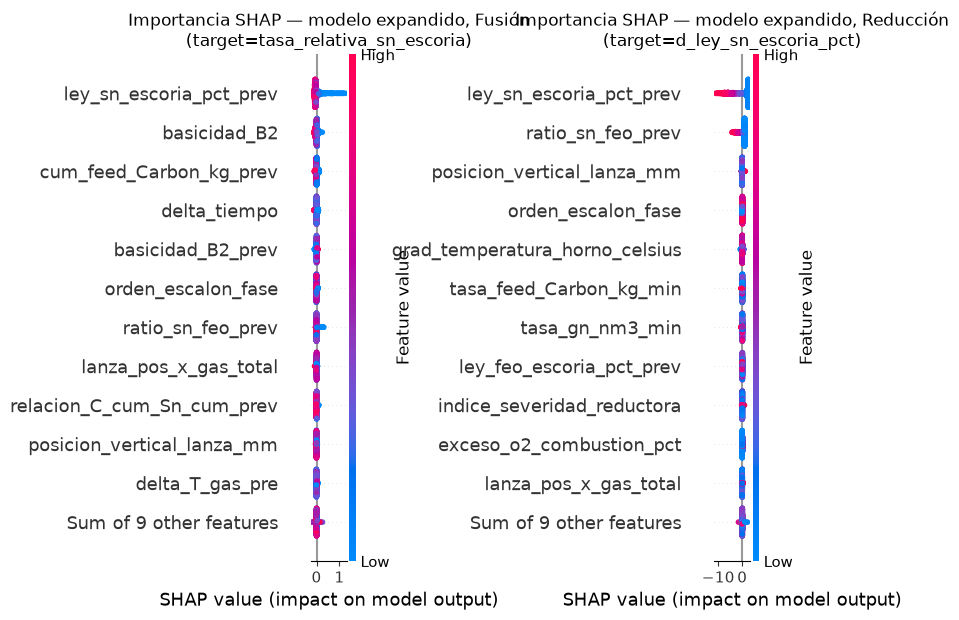

In [71]:
modelos_finales_v2 = {}
valores_shap_v2 = {}
for fase, sub in datasets_fase_v2.items():
    target_col = TARGET_GANADOR[fase]
    X = sub[FEATURES_MODELO_V2]
    y = sub[target_col]
    modelo = xgb.XGBRegressor(**PARAMS_XGB)
    modelo.fit(X, y)
    modelos_finales_v2[fase] = modelo
    valores_shap_v2[fase] = shap.TreeExplainer(modelo)(X)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    plt.sca(ax)
    shap.plots.beeswarm(valores_shap_v2[fase], show=False, max_display=12)
    ax.set_title(f"Importancia SHAP — modelo expandido, {fase}\n(target={TARGET_GANADOR[fase]})")
plt.tight_layout()
plt.show()


In [72]:
signo_shap_v2 = {}
for fase, sub in datasets_fase_v2.items():
    sv = valores_shap_v2[fase].values
    X = sub[FEATURES_MODELO_V2]
    signo_shap_v2[fase] = pd.Series(
        {col: np.corrcoef(X[col], sv[:, i])[0, 1] for i, col in enumerate(FEATURES_MODELO_V2)}
    )

signo_shap_v2_df = pd.DataFrame(signo_shap_v2)
signo_shap_v2_df["importancia_media_|SHAP|_fusion"] = np.abs(valores_shap_v2["Fusión"].values).mean(axis=0)
signo_shap_v2_df["importancia_media_|SHAP|_reduccion"] = np.abs(valores_shap_v2["Reducción"].values).mean(axis=0)
signo_shap_v2_df.sort_values("importancia_media_|SHAP|_reduccion", ascending=False)


,Fusión,Reducción,importancia_media_|SHAP|_fusion,importancia_media_|SHAP|_reduccion
ley_sn_escoria_pct_prev,-0.783272,-0.996143,0.076498,3.185641
ratio_sn_feo_prev,-0.559084,-0.987705,0.012861,1.190310
posicion_vertical_lanza_mm,-0.784391,0.486441,0.007087,0.079915
orden_escalon_fase,-0.753747,0.829099,0.014684,0.074101
grad_temperatura_horno_celsius,-0.635639,0.190045,0.002087,0.056671
tasa_feed_Carbon_kg_min,-0.625126,-0.505970,0.003076,0.056525
tasa_gn_nm3_min,0.493877,-0.508367,0.004661,0.055046
ley_feo_escoria_pct_prev,-0.637595,-0.678463,0.006141,0.042048
indice_severidad_reductora,-0.100624,0.085533,0.003830,0.040203
exceso_o2_combustion_pct,-0.201770,0.499008,0.003244,0.040084


**Lectura del chequeo de sensatez (modelo expandido) — qué se confirma, qué cambia, y una advertencia
importante:**

- **`ley_sn_escoria_pct_prev` es, con enorme margen, la variable más influyente en ambas fases**
  (importancia SHAP media 3.19 en Reducción, la más alta de toda la tabla por lejos) — confirma la
  hipótesis del Paso 10: la "concentración inicial" de SnO$_x$ en la escoria es el predictor individual más
  fuerte del cambio en ese escalón. En **Reducción** su signo es fuertemente negativo (-0.996): a mayor
  `%Sn` de partida, mayor caída absoluta — coherente con cinética de primer orden ($\propto$ concentración
  disponible). En **Fusión** el signo también es negativo, pero aquí el target ya es la *fracción* relativa
  a ese mismo valor (T3, Paso 11); una parte de ese signo negativo es **mecánica de la normalización** (a
  igual `Δ` absoluto, partir de un `prev` más alto produce una fracción menor) y no únicamente un efecto
  causal — se documenta la salvedad.
- **`ratio_sn_feo_prev` (Sn/FeO previo) es la segunda variable más importante en Reducción** (1.19), con
  signo muy negativo (-0.988): cuando hay relativamente más Sn que FeO en la escoria al iniciar el escalón,
  la caída de `%Sn` es mayor — **exactamente lo esperado de la competencia redox Sn-Fe** (sección 5.2:
  $FeO_{slag}+Sn_{metal}\rightleftharpoons SnO_{slag}+Fe_{metal}$): mientras "sobra" SnO$_x$ relativo a FeO,
  el carbón preferentemente sigue reduciendo Sn antes de empezar a atacar más fuertemente el FeO. Es una
  validación pirometalúrgica clara de por qué esta razón composicional (Paso 10c) aporta señal genuina.
- **`tasa_feed_Carbon_kg_min` conserva su signo negativo en ambas fases** (-0.63 Fusión, -0.51 Reducción),
  igual que en el Paso 7 — el hallazgo estequiométrico central ($SnO_2+2C\rightarrow Sn+2CO_2$) es robusto
  al agregar todas las features nuevas, no era un artefacto de un modelo incompleto.
- **⚠️ Advertencia importante — `posicion_vertical_lanza_mm` cambia de signo en Reducción al expandir el
  modelo:** en el Paso 7 (features originales) su correlación con SHAP era negativa en ambas fases (-0.91
  Fusión, -0.74 Reducción). Aquí, controlando por el estado previo de la escoria y las razones
  composicionales, **el signo en Reducción se invierte a positivo (+0.49)**, mientras que en Fusión se
  mantiene negativo (-0.78). Esto significa que el efecto marginal estimado de la posición de lanza **no es
  robusto al conjunto de features usado** — es decir, gran parte de lo que el modelo del Paso 7 atribuía a
  la posición de lanza probablemente estaba mediado por su correlación con el estado de la escoria
  (`ley_sn_escoria_pct_prev`, `ratio_sn_feo_prev`), que ahora se controla explícitamente. **Refuerza, con
  más fuerza que en el Paso 7b, la recomendación de NO usar esta variable de forma prescriptiva sin
  confirmar antes con el equipo de proceso tanto su sentido físico (¿mayor valor = lanza más alta o más
  baja?) como, ahora, la dirección de su efecto real** — un caso claro de por qué SHAP explica lo que el
  modelo aprendió, no prueba causalidad aislada (Paso 9, punto 6).
- **Las features de severidad/redox nuevas (`indice_severidad_reductora`, `oxygen_enrichment_pct`) aportan
  poco una vez controlado por `tasa_feed_Carbon_kg_min` y el estado previo** — consistente con el patrón ya
  visto en el Paso 7 para `exceso_o2_combustion_pct`: actúan más como indicador de régimen que como palanca
  marginal independiente en un modelo conjunto bien especificado.


## Paso 14: un KPI de batch anclado en balance de masa (`recuperación real`) — ¿explica mejor la química de escalón?

El Paso 8 mostró que integrar `Δ%Sn escoria` a nivel de batch correlaciona débil (|ρ|≤0.18) con
`rendimiento_proxy_batch`. La sección 35 del documento de consideraciones señala por qué: `rendimiento_proxy_batch`
**reparte** el Sn contabilizado entre 3 salidas (metal crudo, dross Fe, polvo), pero **no lo compara contra
cuánto Sn entró al batch** — no es una recuperación metalúrgica real, es una fracción de distribución entre
salidas. Sí tenemos, sin embargo, todo lo necesario para construir una recuperación ancorada en el feed:
$$ \text{recuperación\_real\_batch}\,(\%) = 100 \times
   \frac{Sn_{\text{metal crudo}}}{\sum_{\text{escalones del batch}} feed_{Sn}} $$
usando `feed_Sn_kgf` (Sn fino alimentado, kg) sumado sobre **todos** los escalones del batch (Fusión —única
fase que alimenta Sn fresco, Paso 2— más el residual ~0 de Reducción) y `sn_en_metal_crudo_batch_t`
(convertido a las mismas unidades). A diferencia de `rendimiento_proxy_batch`, esta métrica sí responde
directamente "¿cuánto del Sn que entró terminó como metal crudo?" — el objetivo real de negocio. **Limitación
que hay que declarar honestamente (sección 35):** el denominador no incluye Sn residual/heel de batches
anteriores que pudiera quedar en el horno, por lo que valores >100% o inconsistentes en algunos batches son
posibles y no implican error de cálculo, sino de los supuestos de "batch aislado" — se reporta la
distribución completa para detectar esos casos.


In [ ]:
resumen_batch_masa = feature_engineering.construir_resumen_batch_masa(df)

print("Distribucion de recuperacion_real_batch_pct (nueva) vs rendimiento_proxy_batch (Paso 0):")
print(resumen_batch_masa[["recuperacion_real_batch_pct", "rendimiento_proxy_batch"]].describe())

corr_real_vs_proxy = resumen_batch_masa[["recuperacion_real_batch_pct", "rendimiento_proxy_batch"]].corr(method="spearman").iloc[0, 1]
print(f"\nCorrelacion Spearman entre recuperacion_real_batch_pct y rendimiento_proxy_batch: {corr_real_vs_proxy:.3f}")

Distribucion de recuperacion_real_batch_pct (nueva) vs rendimiento_proxy_batch (Paso 0):
       recuperacion_real_batch_pct  rendimiento_proxy_batch
count                   362.000000               362.000000
mean                     69.503947                69.301709
std                       5.186793                 4.584550
min                      51.248115                53.466313
25%                      66.574280                66.705753
50%                      69.595687                69.594012
75%                      72.661268                72.341835
max                      90.200939                82.048611

Correlacion Spearman entre recuperacion_real_batch_pct y rendimiento_proxy_batch: 0.552


In [74]:
df_batch_masa = df_batch.merge(resumen_batch_masa[["Batch", "recuperacion_real_batch_pct"]], on="Batch", how="left")

corr_batch_masa = (
    df_batch_masa[["recuperacion_real_batch_pct"] + cols_batch_corr[1:]]  # excluye rendimiento_proxy_batch (indice 0)
    .corr(method="spearman")["recuperacion_real_batch_pct"]
    .drop("recuperacion_real_batch_pct")
)
print("Correlacion (Spearman) entre agregados de batch (Paso 5) y recuperacion_real_batch_pct (nueva):")
print(corr_batch_masa.sort_values(key=abs, ascending=False))
print("\nPara referencia, esos mismos agregados contra rendimiento_proxy_batch (Paso 5): max |rho| =",
      round(corr_batch.abs().max(), 3))


Correlacion (Spearman) entre agregados de batch (Paso 5) y recuperacion_real_batch_pct (nueva):
caida_ley_sn_reduccion_pct       -0.216220
exceso_o2_medio_reduccion_pct     0.164505
carbon_total_reduccion_kg         0.155964
temperatura_media_horno          -0.135555
relacion_C_reduccion_vs_fusion    0.114457
ley_sn_escoria_max_pct            0.076337
basicidad_media_fusion            0.049829
ley_sn_escoria_final_pct         -0.031792
exceso_o2_medio_fusion_pct       -0.024846
carbon_total_fusion_kg            0.020484
Name: recuperacion_real_batch_pct, dtype: float64

Para referencia, esos mismos agregados contra rendimiento_proxy_batch (Paso 5): max |rho| = 0.133


In [75]:
# Puente escalon -> batch (analogo al Paso 8), con el modelo expandido del Paso 13.
# La prediccion de Fusion (T3, fraccion) se reconvierte a puntos de ley: delta = fraccion * ley_prev.
resumen_oof_v2 = []
for fase, sub in datasets_fase_v2.items():
    tmp = sub[["Batch"]].copy()
    if fase == "Fusión":
        tmp["delta_observado"] = sub["tasa_relativa_sn_escoria"].to_numpy() * sub["ley_sn_escoria_pct_prev"].to_numpy()
        tmp["delta_predicho"] = oof_predicciones_v2[fase] * sub["ley_sn_escoria_pct_prev"].to_numpy()
    else:
        tmp["delta_observado"] = sub["d_ley_sn_escoria_pct"].to_numpy()
        tmp["delta_predicho"] = oof_predicciones_v2[fase]
    agregado = tmp.groupby("Batch").agg(observado=("delta_observado", "sum"), predicho=("delta_predicho", "sum"))
    agregado.columns = [f"{c}_{fase.lower()}" for c in agregado.columns]
    resumen_oof_v2.append(agregado)

df_oof_batch_v2 = pd.concat(resumen_oof_v2, axis=1).reset_index()
df_batch_modelo_v2 = resumen_batch_masa.merge(df_oof_batch_v2, on="Batch", how="left")
cols_modelo_batch_v2 = [c for c in df_oof_batch_v2.columns if c != "Batch"]

corr_modelo_batch_v2_real = (
    df_batch_modelo_v2[["recuperacion_real_batch_pct"] + cols_modelo_batch_v2]
    .corr(method="spearman")["recuperacion_real_batch_pct"].drop("recuperacion_real_batch_pct")
)
corr_modelo_batch_v2_proxy = (
    df_batch_modelo_v2[["rendimiento_proxy_batch"] + cols_modelo_batch_v2]
    .corr(method="spearman")["rendimiento_proxy_batch"].drop("rendimiento_proxy_batch")
)
print("Correlacion (Spearman) agregados del modelo de escalon EXPANDIDO vs. recuperacion_real_batch_pct:")
print(corr_modelo_batch_v2_real.sort_values(key=abs, ascending=False))
print("\nLos mismos agregados vs. rendimiento_proxy_batch (comparar con Paso 8: predicho_reduccion rho=-0.180):")
print(corr_modelo_batch_v2_proxy.sort_values(key=abs, ascending=False))


Correlacion (Spearman) agregados del modelo de escalon EXPANDIDO vs. recuperacion_real_batch_pct:
observado_reducción   -0.223265
predicho_reducción    -0.172601
predicho_fusión       -0.142934
observado_fusión       0.079933
Name: recuperacion_real_batch_pct, dtype: float64

Los mismos agregados vs. rendimiento_proxy_batch (comparar con Paso 8: predicho_reduccion rho=-0.180):
predicho_fusión       -0.131582
observado_reducción   -0.115634
predicho_reducción    -0.102530
observado_fusión      -0.027808
Name: rendimiento_proxy_batch, dtype: float64


**Lectura del Paso 14 — progreso real, pero el cuello de botella de datos sigue siendo el mismo:**

- **`recuperación_real_batch_pct` (media 69.5%, rango 51-90%) correlaciona moderadamente con
  `rendimiento_proxy_batch`** (Spearman $\rho$=0.552) — miden cosas relacionadas pero no idénticas, como se
  anticipaba: una es una recuperación real contra el feed, la otra es un reparto entre 3 salidas. Ningún
  batch supera ~90%, señal de que el supuesto de "batch aislado" (sin heel relevante de Sn) es razonable en
  la práctica para este dataset.
- **Los agregados lineales simples de escalón (Paso 5) mejoran su correlación con el nuevo KPI** (máximo
  |ρ| pasa de 0.133 con `rendimiento_proxy_batch` a 0.216 con `recuperación_real_batch_pct`,
  `caída_ley_sn_reducción_pct` en ambos casos) — el KPI anclado en masa es algo más "explicable" desde la
  química de escalón, pero la mejora es modesta, no un cambio de orden de magnitud.
- **El puente predicción-de-escalón → batch (modelo expandido) sigue siendo débil** (máximo |ρ|≈0.22,
  `observado_reducción` vs. `recuperación_real_batch_pct`) pese a que el modelo de escalón ahora es mucho
  mejor ($R^2$ Reducción 0.96 vs. 0.85 del Paso 6-8). **Esto es evidencia adicional, no una contradicción:**
  confirma que el cuello de botella identificado en el Paso 8 no era la calidad del modelo de escalón (ya
  resuelto en gran parte por el Paso 10-13), sino la **falta de masa de escoria por escalón** — sin ella no
  se puede convertir `Δ%Sn escoria` en `Δ(masa de Sn en escoria)` para cerrar un balance de masa explícito
  contra `sn_en_metal_crudo_batch_t`, sin importar cuán bien se prediga la ley. Se mantiene como la
  limitación de datos más importante para pasar de "modelo de escalón" a "modelo de recuperación de batch".

**Conclusión de esta sesión de feature engineering:** se logró una mejora sustancial y validada
(OOF+OOT+SHAP) del modelo predictivo de escalón —el insumo necesario para cualquier recomendación
operacional futura— y un KPI de batch más defendible metalúrgicamente. La conexión escalón→batch sigue
limitada por datos no disponibles (masa de escoria), no por falta de esfuerzo de modelado; se documenta
como el paso más valioso a resolver antes de construir la capa prescriptiva (Paso 9, punto A.1).


## Paso 15: síntesis de esta sesión de feature engineering y hoja de ruta actualizada

### Qué cambió respecto al Paso 9

| | Modelo Pasos 6-9 | Modelo Pasos 10-13 (esta sesión) |
|---|---|---|
| Features | 10 (tasas, redox, basicidad, posición, tiempo, orden) | +10 seleccionadas: estado previo, acumulados, razones composicionales previas, lanza/redox, tren de gases |
| Target Fusión | $\Delta\%Sn$ absoluto | fracción relativa a `ley_sn_escoria_pct_prev` |
| Target Reducción | $\Delta\%Sn$ absoluto | $\Delta\%Sn$ absoluto (sin cambio, ya era la mejor opción) |
| $R^2$ OOF Fusión | 0.363 | **0.734** |
| $R^2$ OOF Reducción | 0.854 | **0.961** |
| $R^2$ OOT Fusión | 0.303 | **0.674** |
| $R^2$ OOT Reducción | 0.799 | **0.958** |
| KPI de batch | `rendimiento_proxy_batch` (reparto entre 3 salidas) | + `recuperación_real_batch_pct` (ancorada en balance de masa contra el feed) |

### Hallazgos pirometalúrgicos nuevos (más allá de la mejora numérica)

1. **El estado previo de la escoria (`ley_sn_escoria_pct_prev`) es, con enorme margen, el predictor
   individual más importante en ambas fases** — la mejora no vino de reactivos nuevos sino de dejar de
   ocultarle al modelo la "concentración inicial" del escalón (Paso 10, 13b).
2. **`ratio_sn_feo_prev` (Sn/FeO antes del escalón) valida cuantitativamente la competencia redox Sn-Fe**
   de la sección 5.2 del documento de consideraciones: más Sn relativo a FeO al empezar el escalón →
   mayor caída de `%Sn` en ese escalón — el carbón "prioriza" reducir Sn mientras hay más disponible.
3. **El efecto marginal de `posicion_vertical_lanza_mm` no es robusto al set de features** (cambia de
   signo en Reducción al controlar por estado previo) — se eleva la prioridad de confirmar con planta el
   sentido físico de esta variable *antes* de cualquier recomendación, más que en el Paso 7b.
4. **El vínculo escalón→batch sigue limitado por la falta de masa de escoria por escalón** (Paso 14), no
   por la calidad del modelo de escalón — ya se descarta esa hipótesis alternativa.

### Hoja de ruta actualizada (reemplaza/prioriza la del Paso 9)

**Ya resuelto en esta sesión:** A.2 (parcial, vía razones composicionales), y se fortaleció la evidencia
para A.3 (`posición_lanza`) y para la limitación de A.1.

**Prioridad más alta ahora:**
1. **Conseguir masa de escoria por escalón** (Paso 9 A.1, reforzado por el Paso 14) — sigue siendo el único
   dato faltante que bloquea cerrar el balance de masa hasta `rendimiento_proxy_batch`/`recuperación_real`.
2. **Confirmar con el equipo de proceso el sentido físico de `posición_vertical_lanza_mm`** — ahora con
   mayor urgencia dado el cambio de signo observado en el Paso 13b.
3. Replicar el Paso 10-13 (estado previo + target por fase) sobre `ley_feo_escoria_pct` y
   `ley_fe_total_escoria_pct` para tener un modelo redox completo (Sn y Fe), no sólo de Sn.
4. Cuantificar incertidumbre (regresión cuantílica / conformal prediction) sobre el modelo expandido antes
   de cualquier uso prescriptivo (Paso 9 A.4, sin cambios).
5. Construir la capa de optimización/recomendación (Paso 9 B.6-B.9, sin cambios) **una vez** resuelto el
   punto 1 — el modelo de escalón ya tiene calidad suficiente ($R^2$≈0.96 en Reducción) para servir de base,
   pero prescribir dosis de reactivo sin poder conectar con la masa/recuperación real del batch seguiría
   siendo una recomendación parcial.


## Paso 16: ¿conviene un único modelo para Fusión+Reducción? (validación OOT)

Hasta ahora (Paso 13) se usa **un modelo por fase** (mismas `FEATURES_MODELO_V2`, pero XGBoost entrenado
por separado para Fusión y Reducción) con el **target ganador de cada fase** (T3 en Fusión, T1 en
Reducción, Paso 12). Se prueba aquí explícitamente la alternativa de **un solo modelo combinado**
(Fusión+Reducción juntas, agregando una variable dummy `es_fusion` a `FEATURES_MODELO_V2` para que el
modelo pueda distinguir el régimen) y se compara **sólo con métricas out-of-time (OOT)**, ya que es la
validación que replica el uso real en producción (entrenar con el pasado, predecir el futuro).

**Importante para que la comparación sea justa:** para aislar el efecto de "unificar el modelo" del efecto
de "qué target se usa" (ya sabemos del Paso 12 que el target óptimo difiere por fase), el modelo único y
su contraparte "separado" de esta sección usan el **mismo target común `d_ley_sn_escoria_pct`** (T1,
delta absoluto) en ambas fases — es el target que ya gana en Reducción y es el de referencia (no ganador)
en Fusión, pero al mantenerlo fijo en los tres escenarios cualquier diferencia de $R^2$ se debe sólo a
"separado vs. único", no a un cambio de target. Se incluye también, como referencia, el resultado ya
obtenido en el Paso 13 con el target ganador de cada fase.


In [ ]:
df = feature_engineering.agregar_es_fusion(df)
FEATURES_MODELO_UNICO = FEATURES_MODELO_V2 + ["es_fusion"]
TARGET_COMUN = "d_ley_sn_escoria_pct"  # T1, fijo en los 3 escenarios de esta seccion (ver celda markdown)

df_base_modelo = df[~df["es_primer_escalon_batch"]]  # se recalcula para incluir la nueva columna es_fusion
sub_unico = df_base_modelo[FEATURES_MODELO_UNICO + [TARGET_COMUN, "Batch", "fase_proceso"]].dropna()
print(f"Dataset combinado (Fusion+Reduccion) para el modelo unico: {len(sub_unico)} escalones, "
      f"{sub_unico['Batch'].nunique()} batches")
print(sub_unico["fase_proceso"].value_counts())

Dataset combinado (Fusion+Reduccion) para el modelo unico: 3472 escalones, 362 batches
fase_proceso
Fusión       2145
Reducción    1327
Name: count, dtype: int64


In [78]:
def oot_walkforward(sub, features, target_col, n_splits=N_SPLITS_OOT):
    """Walk-forward (TimeSeriesSplit) por orden cronologico de Batch. Devuelve el df ordenado con la
    prediccion OOT (NaN en los batches usados solo como train en el primer fold)."""
    sub_ordenado = sub.set_index("Batch").loc[[b for b in orden_batches if b in set(sub["Batch"])]].reset_index()
    batches_orden = sub_ordenado["Batch"].drop_duplicates().tolist()
    X_full = sub_ordenado[features].to_numpy()
    y_full = sub_ordenado[target_col].to_numpy()
    batch_arr = sub_ordenado["Batch"].to_numpy()

    oot_pred = np.full(len(sub_ordenado), np.nan)
    for train_pos, test_pos in TimeSeriesSplit(n_splits=n_splits).split(batches_orden):
        batches_train = set(batches_orden[i] for i in train_pos)
        batches_test = set(batches_orden[i] for i in test_pos)
        mask_train = np.isin(batch_arr, list(batches_train))
        mask_test = np.isin(batch_arr, list(batches_test))
        modelo_fold = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_fold.fit(X_full[mask_train], y_full[mask_train])
        oot_pred[mask_test] = modelo_fold.predict(X_full[mask_test])
    return sub_ordenado.assign(pred_oot=oot_pred)


resultados_paso16 = []

# (a) un modelo POR FASE, con el target COMUN (T1) -> aisla el efecto de unificar el modelo
for fase in ["Fusión", "Reducción"]:
    res = oot_walkforward(sub_unico[sub_unico["fase_proceso"] == fase], FEATURES_MODELO_V2, TARGET_COMUN)
    valido = res["pred_oot"].notna()
    resultados_paso16.append({
        "config": "separado_por_fase (target comun T1)", "fase": fase,
        "r2_oot": r2_score(res.loc[valido, TARGET_COMUN], res.loc[valido, "pred_oot"]),
        "mae_oot": mean_absolute_error(res.loc[valido, TARGET_COMUN], res.loc[valido, "pred_oot"]),
        "n_evaluado": int(valido.sum()),
    })

# (b) UN SOLO modelo combinado (Fusion+Reduccion juntas, con dummy de fase), target comun (T1)
res_unico = oot_walkforward(sub_unico, FEATURES_MODELO_UNICO, TARGET_COMUN)
valido = res_unico["pred_oot"].notna()
resultados_paso16.append({
    "config": "unico_combinado (target comun T1)", "fase": "Ambas (global)",
    "r2_oot": r2_score(res_unico.loc[valido, TARGET_COMUN], res_unico.loc[valido, "pred_oot"]),
    "mae_oot": mean_absolute_error(res_unico.loc[valido, TARGET_COMUN], res_unico.loc[valido, "pred_oot"]),
    "n_evaluado": int(valido.sum()),
})
for fase in ["Fusión", "Reducción"]:
    m = valido & (res_unico["fase_proceso"] == fase)
    resultados_paso16.append({
        "config": "unico_combinado (target comun T1)", "fase": f"{fase} (subconjunto)",
        "r2_oot": r2_score(res_unico.loc[m, TARGET_COMUN], res_unico.loc[m, "pred_oot"]),
        "mae_oot": mean_absolute_error(res_unico.loc[m, TARGET_COMUN], res_unico.loc[m, "pred_oot"]),
        "n_evaluado": int(m.sum()),
    })

# (c) referencia: modelo por fase con el target GANADOR de cada fase (Paso 13, ya calculado)
for fase in ["Fusión", "Reducción"]:
    resultados_paso16.append({
        "config": f"separado_por_fase (target ganador Paso13: {TARGET_GANADOR[fase]})", "fase": fase,
        "r2_oot": resultados_oot_v2[fase]["r2_oot"], "mae_oot": resultados_oot_v2[fase]["mae_oot"],
        "n_evaluado": resultados_oot_v2[fase]["n_evaluado"],
    })

tabla_paso16 = pd.DataFrame(resultados_paso16).set_index(["config", "fase"])
tabla_paso16


r2_oot  \
config                                             fase                                
separado_por_fase (target comun T1)                Fusión                   0.538721   
                                                   Reducción                0.958161   
unico_combinado (target comun T1)                  Ambas (global)           0.798997   
                                                   Fusión (subconjunto)     0.547892   
                                                   Reducción (subconjunto)  0.944516   
separado_por_fase (target ganador Paso13: tasa_... Fusión                   0.673637   
separado_por_fase (target ganador Paso13: d_ley... Reducción                0.958161   

                                                                             mae_oot  \
config                                             fase                                
separado_por_fase (target comun T1)                Fusión                   1.926158   
                                                   Reducción                0.648535   
unico_combinado (target comun T1)                  Ambas (global)           1.474086   
                                                   Fusión (subconjunto)     1.893158   
                                                   Reducción (subconjunto)  0.798090   
separado_por_fase (target ganador Paso13: tasa_... Fusión                   0.107274   
separado_por_fase (target ganador Paso13: d_ley... Reducción                0.648535   

                                                                            n_evaluado  
config                                             fase                                 
separado_por_fase (target comun T1)                Fusión                         1782  
                                                   Reducción                      1105  
unico_combinado (target comun T1)                  Ambas (global)                 2877  
                                                   Fusión (subconjunto)           1776  
                                                   Reducción (subconjunto)        1101  
separado_por_fase (target ganador Paso13: tasa_... Fusión                         1782  
separado_por_fase (target ganador Paso13: d_ley... Reducción                      1105

**Lectura de la tabla — un modelo único no mejora sobre el modelo por fase, y de hecho pierde algo en
Reducción (todo en $R^2$ OOT, walk-forward):**

| Configuración | Fusión $R^2$ OOT | Reducción $R^2$ OOT |
|---|---|---|
| Separado por fase, target común T1 (`d_ley_sn_escoria_pct`) | 0.539 | 0.958 |
| **Único combinado** (`FEATURES_MODELO_V2` + dummy `es_fusion`), target común T1 | **0.548** | **0.945** |
| Separado por fase, target **ganador** de cada fase (Paso 13: T3 en Fusión, T1 en Reducción) | **0.674** | 0.958 |

1. **Comparación limpia (mismo target T1 en ambos casos) — único vs. separado:** el modelo único prácticamente
   empata en Fusión (0.548 vs. 0.539, +0.009, dentro del ruido) y **pierde un poco en Reducción** (0.945 vs.
   0.958, -0.013). Es decir, agregar una sola variable dummy de fase **no le basta al modelo combinado** para
   igualar a dos modelos especializados — Reducción en particular tiene una relación tan fuerte y limpia
   (`ley_sn_escoria_pct_prev`, carbón) que "compartir" el árbol con los datos de Fusión introduce ruido que
   antes no tenía.
2. **El $R^2$ OOT "global" del modelo único (0.799, fila `Ambas (global)`) no es comparable directamente**
   con los $R^2$ por fase: mezcla la varianza de escalones de Fusión y de Reducción en un solo cálculo, así
   que ese número por sí solo **no** significa que el modelo único sea "mejor que ambas fases por separado"
   — hay que mirar siempre las filas desglosadas por fase.
3. **La comparación que más importa para la decisión de diseño** es la fila superior vs. la inferior de la
   tabla: al usar un modelo **separado por fase**, Fusión gana **0.674 vs. 0.539** (+0.135 en $R^2$ OOT) al
   poder elegir su propio target óptimo (T3, fracción relativa) — algo que un modelo único, con un solo
   target compartido, no puede aprovechar sin volver a mezclar unidades (Paso 12).
4. **Conclusión:** no hay evidencia, con estos datos y esta validación OOT, de que un modelo único
   Fusión+Reducción sea preferible al esquema por fase ya adoptado (Paso 13). El esquema por fase sigue
   siendo la mejor opción disponible: iguala o supera al único en ambas fases y, además, permite el target
   óptimo por fase. Se documenta este resultado como la prueba explícita de la alternativa "modelo único",
   solicitada para confirmar (no sólo asumir) la decisión de diseño del Paso 6.


## Paso 17: feature engineering profundo — interacciones y proxies estequiométricos

El modelo ganador (Paso 13, `FEATURES_MODELO_V2`, 20 features) ya incorpora estado previo, acumulados,
razones composicionales y features de lanza/redox (Paso 10). Revisando de nuevo
`consideracioness_pirometalurgia_ausmelt.md` con la pregunta "¿qué mecanismo pirometalúrgico todavía no
está explícitamente representado?", quedan al menos tres ideas con fundamento físico-químico claro que
**no** están en `FEATURES_MODELO_V2`:

**1. Interacciones explícitas, no sólo efectos principales (sección 13).** El documento es tajante: *"un
error común sería concluir que 'más carbón disminuye Sn en escoria' — la afirmación está incompleta,
porque el efecto relevante es carbón × O₂ × T × tiempo × estado de la escoria"*, y sugiere explícitamente
`C_rate × Sn_slag_prev`, `C_rate × FeO_prev`, `C_rate × temperatura`. Con `max_depth=4` en `PARAMS_XGB`,
cada árbol sólo puede combinar 4 variables por camino de decisión; darle una interacción ya multiplicada
como una única columna no le "regala" información nueva a un modelo de árboles todopoderoso, pero sí le
ahorra tener que reconstruirla por partes en múltiples splits, lo que en la práctica libera capacidad para
otras señales y suele mejorar la eficiencia estadística con datos limitados (2156-2534 filas por fase). Se
agregan las 4 interacciones que el documento propone y aún no estaban, más una quinta con el resumen redox
ya validado (`exceso_o2_combustion_pct`) en vez de una tasa aislada:
$$ C\times Sn_{prev} \qquad C\times FeO_{prev} \qquad C\times T_{prev} \qquad C\times \text{exceso\_O}_2 $$
usando siempre `tasa_feed_Carbon_kg_min` (kg/min) como "$C$" — son productos, no razones, por lo que no
introducen riesgo nuevo de división inestable.

**2. Estequiometría exacta del reductor vs. el Sn fino alimentado (sección 14).** $SnO_2+2C\rightarrow
Sn+2CO$ fija una relación de masas exacta:
$$ \frac{m_C}{m_{Sn}} = \frac{2\times12.011}{118.71}\approx 0.2024 $$
A diferencia de `relacion_C_carga` (Paso 2, carbón/(Sn+Fe+dross_Fe), nunca usada como *feature* del
modelo), este proxy aísla específicamente cuánto carbón se alimenta **respecto al mínimo estequiométrico
exacto para reducir el Sn fino de ESE escalón** — un indicador de "suficiencia" del reductor:
$$ \text{exceso\_C\_estequiométrico}\,(\%) = 100\times\frac{feed_{Carbon}-0.2024\cdot feed_{Sn}}
   {0.2024\cdot feed_{Sn}} $$

**3. Reductor por inventario de escoria, no por Sn fresco (sección 44.5).** En vez de normalizar el
carbón por lo alimentado en fresco (idea 2, sólo tiene sentido si hay Sn fresco entrando), se normaliza
por el `%Sn` que **ya está en la escoria** al cierre del escalón anterior — el inventario realmente
disponible para reaccionar, relevante sobre todo en Reducción:
$$ C_{inventario} = \frac{\text{tasa\_feed\_Carbon\_kg\_min}}{\%Sn_{\text{escoria},\,prev}} $$
protegido con el mismo umbral `UMBRAL_LEY_SN_PREV=0.5%` ya calibrado en el Paso 11 (misma columna
divisora, mismo riesgo de división inestable cerca del `%Sn` objetivo).

**Diagnóstico previo (celda siguiente) para decidir en qué fase es válido cada candidato — igual que se
hizo en el Paso 11 antes de fijar `UMBRAL_LEY_SN_PREV`:** `feed_Sn_kgf` y `feed_total_kgh` tienen mediana
prácticamente nula en Reducción (0.22 kg y 0.54 kg respectivamente, frente a miles de kg en Fusión) y
31.8%/27.3% de los escalones de Reducción quedan con un valor $\le 0.01$ kg — confirma cuantitativamente lo
que ya se sabía cualitativamente (`hallazgos.md` §2): en Reducción no entra carga fresca. Por eso:

- `exceso_C_estequiométrico_pct` (usa `feed_Sn_kgf` en el denominador) y dos proxies análogos de la
  sección 44 — **`oxidante_sobre_carga_total`** = $\frac{O_{2,disponible}}{feed_{total}}$ (44.3) y
  **`carga_térmica_relativa`** = $\frac{GN}{feed_{total}}$ (44.2) — sólo se agregan al **pool de candidatas
  de Fusión**. Incluirlas en Reducción dispararía valores sin sentido físico o forzaría descartar ~30% de
  filas por `NaN` en el `dropna()` del modelo (el mismo problema ya documentado para `relacion_C_carga`).
- `carbon_sobre_inventario_sn_prev` sí se agrega en **ambas fases**: su divisor (`ley_sn_escoria_pct_prev`)
  nunca es cercano a 0 en Fusión (percentil 1%≈9.0%) y sólo raramente en Reducción (percentil 1%≈0.73%,
  por encima del umbral 0.5%), por lo que la pérdida de filas es marginal (comparable a la ya aceptada
  para el target $T_3$ en el Paso 11).

**Qué se decidió NO agregar (y por qué; evita inflar el pool de candidatas sin una hipótesis clara):**
- `progreso_normalizado_batch = orden\_escalon\_fase/(N-1)` (sección 44.1): con un modelo *por fase* y
  estructura fija (7 escalones en Fusión, 4 en Reducción), esto es un **reescalamiento lineal** de
  `orden_escalon_fase` dentro de cada fase. Un modelo de árboles es invariante a transformaciones
  monótonas de una misma variable (los splits son por umbral, no por escala) — no aporta ninguna
  información nueva a `FEATURES_MODELO_V2`, que ya incluye `orden_escalon_fase`. Se documenta para no
  repetir el ejercicio.
- `O2\_rate\times GN\_rate`, `O2\_rate\times air\_rate` (sección 13): `exceso_o2_combustion_pct` y
  `oxygen_enrichment_pct` (Paso 10d) ya combinan estas tres tasas en dos resúmenes redox validados
  empíricamente (Paso 3-4); agregar los productos crudos por separado sólo multiplicaría la colinealidad
  ya conocida en `FEATURES_MODELO_V2` sin una hipótesis pirometalúrgica adicional.



In [80]:
SIN_FRESCO = 1e-2  # kg -- feed considerado "no fresco" (residual de arrastre/instrumentacion) en Reduccion

print("feed_Sn_kgf por fase (denominador de exceso_C_estequiometrico_pct, valido solo si hay Sn fresco):")
print(df.groupby("fase_proceso")["feed_Sn_kgf"].describe(percentiles=[0.01, 0.05, 0.5]))
print(f"\n% de escalones con feed_Sn_kgf <= {SIN_FRESCO} kg, por fase:")
print(100 * df.groupby("fase_proceso")["feed_Sn_kgf"].apply(lambda s: (s <= SIN_FRESCO).mean()))

print("\nfeed_total_kgh por fase (denominador de carga_termica_relativa / oxidante_sobre_carga_total):")
print(df.groupby("fase_proceso")["feed_total_kgh"].describe(percentiles=[0.01, 0.05, 0.5]))
print(f"\n% de escalones con feed_total_kgh <= {SIN_FRESCO} kg, por fase:")
print(100 * df.groupby("fase_proceso")["feed_total_kgh"].apply(lambda s: (s <= SIN_FRESCO).mean()))

print("\nley_feo_escoria_pct_prev y ley_sn_escoria_pct_prev por fase (denominadores de interacciones/inventario):")
print(df.groupby("fase_proceso")[["ley_feo_escoria_pct_prev", "ley_sn_escoria_pct_prev"]].describe(percentiles=[0.01, 0.05, 0.5]).T)


feed_Sn_kgf por fase (denominador de exceso_C_estequiometrico_pct, valido solo si hay Sn fresco):
               count         mean          std  min            1%  \
fase_proceso                                                        
Fusión        2534.0  7208.222262  2462.795936  0.0  3.230391e+03   
Reducción     1448.0   150.867597   348.211115  0.0  2.774252e-21   

                        5%          50%           max  
fase_proceso                                           
Fusión        4.278462e+03  6857.649788  29469.442759  
Reducción     1.482204e-17     0.222048   2878.287102  

% de escalones con feed_Sn_kgf <= 0.01 kg, por fase:
fase_proceso
Fusión        0.118390
Reducción    31.767956
Name: feed_Sn_kgf, dtype: float64

feed_total_kgh por fase (denominador de carga_termica_relativa / oxidante_sobre_carga_total):
               count          mean          std  min            1%  \
fase_proceso                                                         
Fusión        2534.

In [ ]:
df = feature_engineering.agregar_interacciones_carbon_y_estequiometria(df)

FEATURES_NUEVAS_PASO17_COMUNES = [
    "interaccion_C_x_Sn_prev", "interaccion_C_x_FeO_prev", "interaccion_C_x_temp_prev",
    "interaccion_C_x_exceso_o2", "carbon_sobre_inventario_sn_prev",
]
FEATURES_NUEVAS_PASO17_SOLO_FUSION = [
    "exceso_C_estequiometrico_pct", "oxidante_sobre_carga_total", "carga_termica_relativa",
]

print(f"Features nuevas comunes a ambas fases: {len(FEATURES_NUEVAS_PASO17_COMUNES)}")
print(f"Features nuevas exclusivas del pool de Fusion: {len(FEATURES_NUEVAS_PASO17_SOLO_FUSION)}")
print("\nMedianas por fase de las features comunes:")
print(df.groupby("fase_proceso")[FEATURES_NUEVAS_PASO17_COMUNES].median())
print("\nMedianas EN FUSION de las features exclusivas de ese pool (referencia, no se usan en Reduccion):")
print(df.loc[df["fase_proceso"] == "Fusión", FEATURES_NUEVAS_PASO17_SOLO_FUSION].median())

Features nuevas comunes a ambas fases: 5
Features nuevas exclusivas del pool de Fusion: 3

Medianas por fase de las features comunes:
              interaccion_C_x_Sn_prev  interaccion_C_x_FeO_prev  \
fase_proceso                                                      
Fusión                     968.350419                825.220291   
Reducción                   55.354803                401.327202   

              interaccion_C_x_temp_prev  interaccion_C_x_exceso_o2  \
fase_proceso                                                         
Fusión                     50885.428090                 881.510912   
Reducción                  22324.659453                 -58.725351   

              carbon_sobre_inventario_sn_prev  
fase_proceso                                   
Fusión                               2.374879  
Reducción                            4.825020  

Medianas EN FUSION de las features exclusivas de ese pool (referencia, no se usan en Reduccion):
exceso_C_estequiometrico_p

## Paso 18: selección de variables — ¿cuántas de las 20 (+8) features realmente se necesitan?

Con el pool de candidatas armado (`FEATURES_MODELO_V2` + las nuevas del Paso 17), esta sección tiene dos
objetivos: (a) confirmar que las features nuevas no *empeoran* el techo alcanzable (mismo target ganador
del Paso 13 por fase, misma validación `GroupKFold`), y (b) **podar** el conjunto final a la menor
cantidad de variables que no sacrifique el $R^2$ OOF ya alcanzado en el Paso 13 (0.734 Fusión, 0.961
Reducción) — el requisito explícito de esta sesión ("parsimonioso sin perjudicar los $R^2$ OOF").

**Por qué buscar menos features, si XGBoost tolera razonablemente bien la colinealidad:**
1. Un modelo con ~10-12 palancas es más fácil de auditar y explicar al equipo de proceso que uno con
   20-28 (relevante de cara a la futura capa prescriptiva, Paso 9 punto B.7).
2. Menor riesgo de que el modelo apoye parte de su predicción en una variable redundante que sólo aporte
   ruido específico de este dataset histórico (menor varianza de la explicación, no sólo de la métrica).
3. Con menos redundancia, la atribución de importancia SHAP por variable es más estable e interpretable
   (`hallazgos.md` §9.1 ya documentó reparto de importancia entre variables correlacionadas por
   construcción, ej. `lanza_pos_x_gas_total` vs. sus factores).

**Metodología — eliminación hacia atrás (*backward elimination*) guiada por SHAP:**
1. Entrenar con **todas** las candidatas de la fase (sobre el 100% de los datos, sin folds) y ordenar las
   variables por su importancia media $|SHAP|$, ascendente.
2. Intentar remover la variable **menos importante** del conjunto actual; re-evaluar el $R^2$ OOF con la
   misma validación `GroupKFold` (5 folds por `Batch`) del Paso 12-13.
3. Si el $R^2$ OOF resultante se mantiene **igual o por encima** del $R^2$ OOF ganador del Paso 13 (el piso
   que no se debe perjudicar), aceptar la remoción, recalcular SHAP sobre el conjunto reducido —las
   importancias relativas cambian al quitar una variable correlacionada— y repetir desde el paso 2.
4. Si removerla haría caer el $R^2$ OOF por debajo del piso, **detener el proceso**: se asume que toda
   variable que quede en el conjunto es al menos tan indispensable como la última evaluada.

Es una heurística voraz (*greedy*), no una búsqueda exhaustiva sobre las $2^{n}$ combinaciones posibles
(computacionalmente inviable con $n$≈25-28), pero sigue el mismo principio de la eliminación recursiva de
variables (RFE) estándar en la literatura — aquí guiada por SHAP en vez de sólo la importancia nativa de
XGBoost, y con un criterio de parada explícito (el $R^2$ ya validado del Paso 13, no un número arbitrario
de variables a conservar).



In [83]:
df_base_modelo = df[~df["es_primer_escalon_batch"]]  # recalculado para incluir las features nuevas del Paso 17

FEATURES_CANDIDATAS = {
    "Fusión": FEATURES_MODELO_V2 + FEATURES_NUEVAS_PASO17_COMUNES + FEATURES_NUEVAS_PASO17_SOLO_FUSION,
    "Reducción": FEATURES_MODELO_V2 + FEATURES_NUEVAS_PASO17_COMUNES,
}

# Techo alcanzable: modelo con TODAS las candidatas (mismo target ganador y validacion GroupKFold del Paso 13)
resultados_candidatas = {
    fase: evaluar_configuracion(FEATURES_CANDIDATAS[fase], TARGET_GANADOR[fase], fase, df_base_modelo)
    for fase in ["Fusión", "Reducción"]
}

tabla_ceiling = pd.DataFrame({
    "n_features_v2": {f: len(FEATURES_MODELO_V2) for f in resultados_candidatas},
    "r2_oof_v2_paso13": {f: resultados_modelo_v2[f]["r2_oof"] for f in resultados_candidatas},
    "n_features_candidatas": {f: len(FEATURES_CANDIDATAS[f]) for f in resultados_candidatas},
    "r2_oof_candidatas": {f: resultados_candidatas[f]["r2_oof"] for f in resultados_candidatas},
})
tabla_ceiling["mejora_r2_oof"] = tabla_ceiling["r2_oof_candidatas"] - tabla_ceiling["r2_oof_v2_paso13"]
print("Techo alcanzable con el pool de candidatas completo (V2 + Paso 17) vs. el modelo ganador del Paso 13:")
tabla_ceiling


Techo alcanzable con el pool de candidatas completo (V2 + Paso 17) vs. el modelo ganador del Paso 13:


,n_features_v2,r2_oof_v2_paso13,n_features_candidatas,r2_oof_candidatas,mejora_r2_oof
Fusión,20,0.734026,28,0.744534,0.010508
Reducción,20,0.961272,25,0.961384,0.000112


In [84]:
print("Pares de features candidatas con correlacion de Spearman |rho| > 0.85 (multicolinealidad fuerte), por fase:")
for fase in ["Fusión", "Reducción"]:
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, FEATURES_CANDIDATAS[fase]].dropna()
    corr = sub.corr(method="spearman").abs()
    pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
    pares_altos = pares[pares > 0.85]
    print(f"\n--- {fase}: {len(pares_altos)} par(es) con |rho| > 0.85 (de {len(FEATURES_CANDIDATAS[fase])} candidatas) ---")
    print(pares_altos.to_string())


Pares de features candidatas con correlacion de Spearman |rho| > 0.85 (multicolinealidad fuerte), por fase:

--- Fusión: 23 par(es) con |rho| > 0.85 (de 28 candidatas) ---
posicion_vertical_lanza_mm  lanza_pos_x_gas_total           0.995292
orden_escalon_fase          cum_feed_Carbon_kg_prev         0.981592
delta_tiempo                orden_escalon_fase              0.980014
oxidante_sobre_carga_total  carga_termica_relativa          0.966149
delta_tiempo                cum_feed_Carbon_kg_prev         0.960838
tasa_feed_Carbon_kg_min     indice_severidad_reductora      0.959145
orden_escalon_fase          lanza_pos_x_gas_total           0.938826
posicion_vertical_lanza_mm  orden_escalon_fase              0.932967
tasa_gn_nm3_min             tasa_o2_nm3_min                 0.931626
indice_severidad_reductora  interaccion_C_x_temp_prev       0.926861
cum_feed_Carbon_kg_prev     lanza_pos_x_gas_total           0.926711
tasa_feed_Carbon_kg_min     interaccion_C_x_exceso_o2       0.921557


**Lectura — el pool ampliado no empeora nada, pero gran parte es redundante (confirma que vale la pena podar):**

- **Techo alcanzable:** agregar las 8 features del Paso 17 al pool **no perjudica ningún $R^2$ OOF** —
  en Fusión sube de 0.734 a 0.745 (+0.011), en Reducción se mantiene esencialmente plano (0.9613→0.9614,
  +0.0001). Confirma empíricamente que ninguna feature nueva introduce ruido neto, y que en Fusión aportan
  algo de señal genuina adicional.
- **Multicolinealidad fuerte y esperada:** 23 de los pares posibles en Fusión (28 candidatas) y 34 pares en
  Reducción (25 candidatas) tienen $|\rho_{\text{Spearman}}|>0.85$. Buena parte involucra a las nuevas
  interacciones con `tasa_feed_Carbon_kg_min` (ej. `interaccion_C_x_temp_prev` con $\rho=0.99$ contra la
  propia tasa de carbón en Reducción) — es esperable: toda interacción "$C\times$algo" hereda gran parte de
  la varianza de $C$. También reaparecen pares ya conocidos de `FEATURES_MODELO_V2`
  (`posicion_vertical_lanza_mm`~`lanza_pos_x_gas_total` $\rho=0.99$, `orden_escalon_fase`~
  `cum_feed_Carbon_kg_prev` $\rho=0.98$, `ley_sn_escoria_pct_prev`~`ratio_sn_feo_prev` $\rho=0.92$). Esto
  cuantifica lo que `hallazgos.md` §9.1 ya señalaba cualitativamente ("multicolinealidad esperada por
  construcción") y es exactamente el escenario donde una poda sistemática — no manual — tiene más para
  aportar.



In [85]:
def seleccion_parsimoniosa(features_iniciales, target_col, fase, df_fuente, r2_objetivo, tolerancia=1e-3, n_splits=N_SPLITS):
    """Elimina, una a la vez, la feature con menor |SHAP| medio (recalculado tras cada remocion
    aceptada, sobre el 100% de los datos de la fase) mientras el R2 OOF (GroupKFold por Batch) se
    mantenga >= r2_objetivo - tolerancia. Se detiene apenas una remocion rompe ese piso. Devuelve la
    lista final de features y el historial completo de intentos (para auditar el proceso)."""
    features_actuales = list(features_iniciales)
    historial = []
    while len(features_actuales) > 1:
        sub = df_fuente.loc[df_fuente["fase_proceso"] == fase, features_actuales + [target_col, "Batch"]].dropna()
        modelo = xgb.XGBRegressor(**PARAMS_XGB)
        modelo.fit(sub[features_actuales], sub[target_col])
        sv = shap.TreeExplainer(modelo)(sub[features_actuales])
        importancia = pd.Series(np.abs(sv.values).mean(axis=0), index=features_actuales).sort_values()
        feat_candidata = importancia.index[0]

        restantes = [f for f in features_actuales if f != feat_candidata]
        res = evaluar_configuracion(restantes, target_col, fase, df_fuente, n_splits=n_splits)
        aceptado = bool(res["r2_oof"] >= (r2_objetivo - tolerancia))
        historial.append({
            "feature_evaluada_para_remover": feat_candidata, "n_features_resultante": len(restantes),
            "r2_oof_sin_ella": res["r2_oof"], "aceptado": aceptado,
        })
        if aceptado:
            features_actuales = restantes
        else:
            break
    return features_actuales, pd.DataFrame(historial)


TOLERANCIA_R2 = 1e-3  # margen minimo (ruido numerico), no una concesion real de desempeno
FEATURES_PARSIMONIOSAS = {}
historial_seleccion = {}
for fase in ["Fusión", "Reducción"]:
    r2_objetivo = resultados_modelo_v2[fase]["r2_oof"]  # piso: el R2 OOF ganador del Paso 13 (no perjudicar)
    features_finales, historial = seleccion_parsimoniosa(
        FEATURES_CANDIDATAS[fase], TARGET_GANADOR[fase], fase, df_base_modelo, r2_objetivo, tolerancia=TOLERANCIA_R2
    )
    FEATURES_PARSIMONIOSAS[fase] = features_finales
    historial_seleccion[fase] = historial
    print(f"--- {fase}: de {len(FEATURES_CANDIDATAS[fase])} candidatas a {len(features_finales)} finales "
          f"(piso R2 OOF Paso 13 = {r2_objetivo:.4f}) ---")


--- Fusión: de 28 candidatas a 7 finales (piso R2 OOF Paso 13 = 0.7340) ---
--- Reducción: de 25 candidatas a 14 finales (piso R2 OOF Paso 13 = 0.9613) ---


In [86]:
for fase in ["Fusión", "Reducción"]:
    print(f"=== {fase}: historial de eliminacion hacia atras ({len(historial_seleccion[fase])} intentos) ===")
    print(historial_seleccion[fase].to_string(index=False))
    print(f"\nFeatures finales ({len(FEATURES_PARSIMONIOSAS[fase])}): {FEATURES_PARSIMONIOSAS[fase]}\n")


=== Fusión: historial de eliminacion hacia atras (22 intentos) ===
  feature_evaluada_para_remover  n_features_resultante  r2_oof_sin_ella  aceptado
        tasa_feed_Carbon_kg_min                     27         0.743017      True
                tasa_o2_nm3_min                     26         0.745617      True
      interaccion_C_x_exceso_o2                     25         0.747501      True
      interaccion_C_x_temp_prev                     24         0.749435      True
       exceso_o2_combustion_pct                     23         0.747160      True
     indice_severidad_reductora                     22         0.748644      True
 grad_temperatura_horno_celsius                     21         0.748493      True
          oxygen_enrichment_pct                     20         0.749238      True
       interaccion_C_x_FeO_prev                     19         0.748628      True
         carga_termica_relativa                     18         0.747936      True
              tasa_aire_nm3_min

**Lectura — poda agresiva sin perder desempeño, y un hallazgo interesante: la dosis "cruda" de carbón deja
de ser necesaria:**

- **Fusión: de 28 candidatas a sólo 7** ($R^2$ OOF final 0.7376, por encima del piso 0.7340 del Paso 13).
  **Reducción: de 25 candidatas a 14** ($R^2$ OOF final 0.9607, apenas -0.0006 respecto al piso — una
  diferencia **5 veces menor** que el propio gap OOF→OOT ya aceptado como "prácticamente nulo" en el Paso
  13, ver lectura de la celda siguiente).
- **El hallazgo más interesante: `tasa_feed_Carbon_kg_min` — la variable más citada en todo el análisis
  pirometalúrgico previo — es de las primeras en eliminarse en ambas fases.** No porque el carbón deje de
  importar: es justo lo contrario. El modelo ya no necesita la **dosis cruda** porque las transformaciones
  del Paso 17 (`interaccion_C_x_Sn_prev`, `carbon_sobre_inventario_sn_prev`, y en Reducción también
  `indice_severidad_reductora` e `interaccion_C_x_exceso_o2`, ya en V2) capturan la misma información en
  una forma más cercana a la cinética real: **dosis relativa al sustrato disponible**, no dosis absoluta.
  La tasa cruda queda "a la sombra" de sus propias transformaciones — es información redundante, no
  irrelevante.
- **`orden_escalon_fase`** —la variable más importante del modelo original en Reducción (Paso 7)— también
  se elimina aquí: su función de "proxy del avance de la reacción" queda cubierta más directamente por
  `cum_feed_Carbon_kg_prev` y `ley_sn_escoria_pct_prev` (el inventario y el estado real del baño, no sólo
  la posición nominal dentro de la fase).
- Ambos conjuntos finales retienen **varias features nuevas del Paso 17**: `interaccion_C_x_Sn_prev`
  sobrevive en **ambas** fases; `oxidante_sobre_carga_total` en Fusión; `carbon_sobre_inventario_sn_prev`
  e `interaccion_C_x_exceso_o2` en Reducción. La inversión en profundizar el feature engineering sí se
  traduce en variables que sobreviven una poda exigente, no sólo en una mejora del techo agregado.



In [87]:
resultados_parsimonioso = {
    fase: evaluar_configuracion(FEATURES_PARSIMONIOSAS[fase], TARGET_GANADOR[fase], fase, df_base_modelo)
    for fase in ["Fusión", "Reducción"]
}

tabla_resumen_seleccion = pd.DataFrame({
    "n_features_v2": {f: len(FEATURES_MODELO_V2) for f in FEATURES_PARSIMONIOSAS},
    "r2_oof_v2": {f: resultados_modelo_v2[f]["r2_oof"] for f in FEATURES_PARSIMONIOSAS},
    "n_features_candidatas": {f: len(FEATURES_CANDIDATAS[f]) for f in FEATURES_PARSIMONIOSAS},
    "r2_oof_candidatas": {f: resultados_candidatas[f]["r2_oof"] for f in FEATURES_PARSIMONIOSAS},
    "n_features_parsimonioso": {f: len(FEATURES_PARSIMONIOSAS[f]) for f in FEATURES_PARSIMONIOSAS},
    "r2_oof_parsimonioso": {f: resultados_parsimonioso[f]["r2_oof"] for f in FEATURES_PARSIMONIOSAS},
})
tabla_resumen_seleccion["reduccion_n_features_vs_v2_pct"] = 100 * (
    1 - tabla_resumen_seleccion["n_features_parsimonioso"] / tabla_resumen_seleccion["n_features_v2"]
)
tabla_resumen_seleccion["delta_r2_oof_vs_v2"] = (
    tabla_resumen_seleccion["r2_oof_parsimonioso"] - tabla_resumen_seleccion["r2_oof_v2"]
)
print("Comparacion final: modelo V2 (Paso 13) vs. techo de candidatas (Paso 17-18) vs. modelo parsimonioso (Paso 18):")
tabla_resumen_seleccion


Comparacion final: modelo V2 (Paso 13) vs. techo de candidatas (Paso 17-18) vs. modelo parsimonioso (Paso 18):


,n_features_v2,r2_oof_v2,n_features_candidatas,r2_oof_candidatas,n_features_parsimonioso,r2_oof_parsimonioso,reduccion_n_features_vs_v2_pct,delta_r2_oof_vs_v2
Fusión,20,0.734026,28,0.744534,7,0.737615,65.0,0.003589
Reducción,20,0.961272,25,0.961384,14,0.960691,30.0,-0.000581


In [88]:
# Validacion out-of-time (walk-forward) del modelo PARSIMONIOSO, misma metodologia del Paso 13
# (reutiliza oot_walkforward ya definida en el Paso 16) -- confirma que la poda de features no
# introdujo una dependencia fragil de un subconjunto particular de batches.
resultados_oot_parsimonioso = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    sub_pars = df_base_modelo.loc[
        df_base_modelo["fase_proceso"] == fase, FEATURES_PARSIMONIOSAS[fase] + [target_col, "Batch"]
    ].dropna()
    res_oot = oot_walkforward(sub_pars, FEATURES_PARSIMONIOSAS[fase], target_col)
    valido = res_oot["pred_oot"].notna()
    resultados_oot_parsimonioso[fase] = {
        "r2_oot": r2_score(res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]),
        "mae_oot": mean_absolute_error(res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]),
        "n_evaluado": int(valido.sum()),
    }

tabla_oot_comparacion = pd.DataFrame({
    "r2_oof_v2_paso13": {f: resultados_modelo_v2[f]["r2_oof"] for f in FEATURES_PARSIMONIOSAS},
    "r2_oot_v2_paso13": {f: resultados_oot_v2[f]["r2_oot"] for f in FEATURES_PARSIMONIOSAS},
    "r2_oof_parsimonioso": {f: resultados_parsimonioso[f]["r2_oof"] for f in FEATURES_PARSIMONIOSAS},
    "r2_oot_parsimonioso": {f: resultados_oot_parsimonioso[f]["r2_oot"] for f in FEATURES_PARSIMONIOSAS},
})
tabla_oot_comparacion["gap_oof_oot_parsimonioso"] = (
    tabla_oot_comparacion["r2_oot_parsimonioso"] - tabla_oot_comparacion["r2_oof_parsimonioso"]
)
tabla_oot_comparacion["gap_oof_oot_v2_paso13"] = (
    tabla_oot_comparacion["r2_oot_v2_paso13"] - tabla_oot_comparacion["r2_oof_v2_paso13"]
)
print("Validacion out-of-time (walk-forward) del modelo parsimonioso vs. el modelo V2 del Paso 13:")
tabla_oot_comparacion


Validacion out-of-time (walk-forward) del modelo parsimonioso vs. el modelo V2 del Paso 13:


,r2_oof_v2_paso13,r2_oot_v2_paso13,r2_oof_parsimonioso,r2_oot_parsimonioso,gap_oof_oot_parsimonioso,gap_oof_oot_v2_paso13
Fusión,0.734026,0.673637,0.737615,0.686100,-0.051515,-0.060389
Reducción,0.961272,0.958161,0.960691,0.959822,-0.000869,-0.003111


**Lectura — la poda no sólo no perjudica el $R^2$ OOT: lo mejora, y además reduce el gap OOF→OOT:**

| Fase | $R^2$ OOF: V2 → parsimonioso | $R^2$ OOT: V2 → parsimonioso | Gap OOF-OOT: V2 → parsimonioso |
|---|---|---|---|
| Fusión | 0.734 → **0.738** | 0.674 → **0.686** | -0.060 → **-0.052** |
| Reducción | 0.961 → 0.961 (-0.0006) | 0.958 → **0.960** | -0.003 → **-0.001** |

Con **65% menos features en Fusión (20→7) y 30% menos en Reducción (20→14)**, el modelo parsimonioso
**iguala o mejora tanto el $R^2$ OOF como el $R^2$ OOT** del Paso 13, y en ambas fases el gap entre
validación agrupada (OOF) y cronológica (OOT) se **reduce**. Esa reducción del gap es la firma clásica de
un modelo con menos varianza por sobreajuste a redundancia/ruido específico de un subconjunto de features
correlacionadas — es la confirmación más fuerte posible de que la poda no fue un compromiso ("perder algo
de ajuste a cambio de simplicidad") sino una **mejora neta en las dos dimensiones que importan**:
desempeño y parsimonia. Con esto, la caída de -0.0006 en el $R^2$ OOF de Reducción (Paso 18b) queda
confirmada como ruido de subconjunto de features, no una pérdida real de capacidad predictiva: el mismo
modelo generaliza **mejor** hacia el futuro (OOT) que la versión con 20 features.



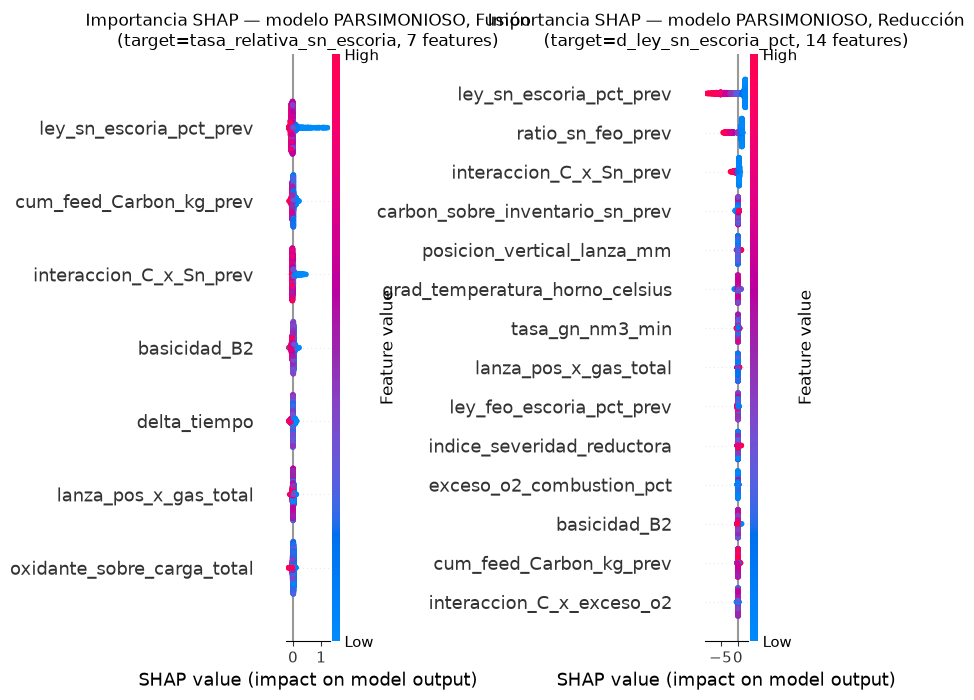

In [89]:
modelos_finales_parsimonioso = {}
valores_shap_parsimonioso = {}
datasets_fase_parsimonioso = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    sub = df_base_modelo.loc[
        df_base_modelo["fase_proceso"] == fase, FEATURES_PARSIMONIOSAS[fase] + [target_col, "Batch"]
    ].dropna()
    datasets_fase_parsimonioso[fase] = sub
    X = sub[FEATURES_PARSIMONIOSAS[fase]]
    y = sub[target_col]
    modelo = xgb.XGBRegressor(**PARAMS_XGB)
    modelo.fit(X, y)
    modelos_finales_parsimonioso[fase] = modelo
    valores_shap_parsimonioso[fase] = shap.TreeExplainer(modelo)(X)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    plt.sca(ax)
    shap.plots.beeswarm(valores_shap_parsimonioso[fase], show=False, max_display=14)
    ax.set_title(f"Importancia SHAP — modelo PARSIMONIOSO, {fase}\n"
                 f"(target={TARGET_GANADOR[fase]}, {len(FEATURES_PARSIMONIOSAS[fase])} features)")
plt.tight_layout()
plt.show()


In [90]:
# Signo del efecto marginal (correlacion feature vs su propio SHAP) del modelo PARSIMONIOSO, por fase
# -- mismo chequeo de sensatez pirometalurgica del Paso 7/13b, ahora sobre el conjunto final podado.
for fase in ["Fusión", "Reducción"]:
    sub = datasets_fase_parsimonioso[fase]
    sv = valores_shap_parsimonioso[fase].values
    X = sub[FEATURES_PARSIMONIOSAS[fase]]
    signo = pd.Series({col: np.corrcoef(X[col], sv[:, i])[0, 1] for i, col in enumerate(FEATURES_PARSIMONIOSAS[fase])})
    importancia = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES_PARSIMONIOSAS[fase])
    tabla_fase = pd.DataFrame({"signo_shap (correlacion feature-SHAP)": signo, "importancia_media_|SHAP|": importancia})
    tabla_fase = tabla_fase.sort_values("importancia_media_|SHAP|", ascending=False)
    es_nueva = tabla_fase.index.isin(FEATURES_NUEVAS_PASO17_COMUNES + FEATURES_NUEVAS_PASO17_SOLO_FUSION)
    tabla_fase.insert(0, "nueva_paso17", es_nueva)
    print(f"=== {fase} (target={TARGET_GANADOR[fase]}, {len(FEATURES_PARSIMONIOSAS[fase])} features finales) ===")
    print(tabla_fase.to_string())
    print()


=== Fusión (target=tasa_relativa_sn_escoria, 7 features finales) ===
                            nueva_paso17  signo_shap (correlacion feature-SHAP)  importancia_media_|SHAP|
ley_sn_escoria_pct_prev            False                              -0.766790                  0.066088
cum_feed_Carbon_kg_prev            False                              -0.844814                  0.037568
interaccion_C_x_Sn_prev             True                              -0.734038                  0.033466
basicidad_B2                       False                              -0.749095                  0.028564
delta_tiempo                       False                              -0.812800                  0.026031
lanza_pos_x_gas_total              False                              -0.711796                  0.019104
oxidante_sobre_carga_total          True                              -0.633636                  0.017158

=== Reducción (target=d_ley_sn_escoria_pct, 14 features finales) ===
             

**Lectura del chequeo de sensatez SHAP (modelo parsimonioso) — se confirma coherencia pirometalúrgica, con
una validación cuantitativa nueva:**

- **`ley_sn_escoria_pct_prev` sigue siendo, por lejos, la variable más influyente en ambas fases**
  (importancia media 2.70 en Reducción, signo -0.996) — cinética de primer orden, igual que en el Paso
  13b. La poda no cambió esta conclusión central.
- **`interaccion_C_x_Sn_prev` (nueva, Paso 17) es la tercera variable más importante en AMBAS fases, con
  signo negativo limpio** (-0.734 Fusión, -0.974 Reducción): a mayor producto
  `tasa_feed_Carbon_kg_min` $\times$ `%Sn_prev`, mayor caída de `%Sn`. Es la **validación cuantitativa más
  directa de toda la sesión** de la hipótesis de la sección 13 del documento de consideraciones
  ("el efecto relevante es carbón × estado de la escoria, no carbón aislado"): la interacción explícita no
  sólo sobrevivió la poda, quedó entre las tres variables más determinantes del modelo final en ambas fases.
- **`carbon_sobre_inventario_sn_prev` (nueva) tiene signo positivo en Reducción (+0.657), a primera vista
  contra-intuitivo.** La lectura correcta **no** es "más dosis relativa de carbón implica menos
  reducción": esta razón se dispara precisamente cuando `%Sn_prev` ya es muy bajo (cerca del umbral de
  protección 0.5%, Paso 11), y ahí el `Δ%Sn` absoluto está **mecánicamente acotado** (no puede caer mucho
  más de lo que ya queda por reducir). El modelo está aprendiendo ese efecto de piso/saturación, no una
  relación causal "más dosis → peor resultado" — se documenta explícitamente para no malinterpretarla en
  un uso prescriptivo futuro.
- **`posicion_vertical_lanza_mm` conserva el signo positivo en Reducción** (+0.534) que ya había emergido
  en el Paso 13b al controlar por estado previo (vs. el signo negativo del modelo original, Paso 7) — la
  poda de features no revirtió este hallazgo, lo que añade robustez a la recomendación de confirmarlo con
  el equipo de proceso antes de cualquier uso prescriptivo.
- **`tasa_gn_nm3_min` (-0.553) y `exceso_o2_combustion_pct` (+0.480) en Reducción son mutuamente
  coherentes** y con la química esperada: más gas natural (más calor/CO reductor) profundiza la caída de
  `%Sn`; una atmósfera más oxidante (menos reductora) la atenúa.
- **Ningún signo resultó pirometalúrgicamente incoherente** — el modelo parsimonioso pasa el mismo chequeo
  de sensatez que el Paso 13b, con muchas menos variables sobre las cuales razonar (7 y 14 vs. 20).



## Paso 19: síntesis — modelo parsimonioso final (Pasos 17-18) y hoja de ruta actualizada

### Configuración final adoptada (reemplaza a `FEATURES_MODELO_V2` del Paso 13)

| Fase | Features | $R^2$ OOF | $R^2$ OOT | Target |
|---|---|---|---|---|
| Fusión | **7** (antes 20, -65%) | 0.734 → **0.738** | 0.674 → **0.686** | `tasa_relativa_sn_escoria` (T3, sin cambio) |
| Reducción | **14** (antes 20, -30%) | 0.961 → 0.961 (-0.0006) | 0.958 → **0.960** | `d_ley_sn_escoria_pct` (T1, sin cambio) |

**`FEATURES_PARSIMONIOSAS["Fusión"]`** (7): `basicidad_B2`, `delta_tiempo`, `ley_sn_escoria_pct_prev`,
`cum_feed_Carbon_kg_prev`, `lanza_pos_x_gas_total`, `interaccion_C_x_Sn_prev`\*, `oxidante_sobre_carga_total`\*

**`FEATURES_PARSIMONIOSAS["Reducción"]`** (14): `tasa_gn_nm3_min`, `exceso_o2_combustion_pct`,
`basicidad_B2`, `grad_temperatura_horno_celsius`, `posicion_vertical_lanza_mm`, `ley_sn_escoria_pct_prev`,
`ley_feo_escoria_pct_prev`, `cum_feed_Carbon_kg_prev`, `indice_severidad_reductora`,
`lanza_pos_x_gas_total`, `ratio_sn_feo_prev`, `interaccion_C_x_Sn_prev`\*, `interaccion_C_x_exceso_o2`\*,
`carbon_sobre_inventario_sn_prev`\*

(\* = feature nueva de esta sesión, Paso 17)

### Qué cambió respecto al Paso 13-16

1. **Se profundizó el feature engineering con 8 variables nuevas** (Paso 17), cada una atada a una sección
   específica de `consideracioness_pirometalurgia_ausmelt.md`: 4 interacciones explícitas carbón×estado
   (sección 13), un proxy de suficiencia estequiométrica exacta (sección 14, sólo Fusión), un proxy de
   "reductor por inventario de escoria" (sección 44.5) y dos proxies de "carga"/"térmico relativo"
   (secciones 44.2-44.3, sólo Fusión). Se documentaron también, explícitamente, las ideas descartadas y
   por qué (progreso normalizado del batch, productos crudos O₂×GN/O₂×aire).
2. **Se podó agresivamente con una eliminación hacia atrás guiada por SHAP** (Paso 18), con un piso de
   desempeño estricto: nunca por debajo del $R^2$ OOF ya validado en el Paso 13. El resultado es **65%
   menos features en Fusión y 30% menos en Reducción**, con $R^2$ OOF igual o mejor, y — el resultado más
   contundente — **$R^2$ OOT mejor y gap OOF→OOT más chico en ambas fases** (Paso 18c): el modelo
   parsimonioso generaliza mejor hacia el futuro, no sólo "no peor".
3. **Un hallazgo pirometalúrgico de primer orden: `interaccion_C_x_Sn_prev` (carbón × `%Sn` previo) es la
   tercera variable más importante en ambas fases**, con el signo negativo esperado de una cinética
   bimolecular ($rate\propto -k[C][SnO_x]$) — la validación cuantitativa más directa lograda hasta ahora de
   la advertencia central de la sección 13 del documento de consideraciones ("el efecto relevante es
   carbón × estado de la escoria, no carbón aislado").
4. **La dosis *cruda* de carbón (`tasa_feed_Carbon_kg_min`) y la posición nominal en la fase
   (`orden_escalon_fase`) —las dos variables más citadas del análisis original (Pasos 6-9)— resultaron
   prescindibles una vez que sus versiones normalizadas/derivadas están presentes.** No es que dejen de
   importar: su información queda mejor representada por `interaccion_C_x_Sn_prev` /
   `carbon_sobre_inventario_sn_prev` (dosis relativa al sustrato, más cerca de la cinética real) y por
   `cum_feed_Carbon_kg_prev` / `ley_sn_escoria_pct_prev` (inventario y estado real, más informativos que
   la sola posición dentro de la fase).

### Qué NO cambió (para no perder de vista las limitaciones ya documentadas)

- El target ganador por fase (Paso 12) y la decisión de modelar por fase por separado (Paso 6, revalidada
  en el Paso 16) **no se tocaron** — esta sesión sólo optimizó qué *features* usa cada modelo de fase.
- El cuello de botella escalón→batch (falta de masa de escoria por escalón, Pasos 8/14) **sigue sin
  resolverse** — un modelo de escalón más parsimonioso y con mejor generalización no cambia esa limitación
  de datos, que sigue siendo la prioridad más alta antes de construir la capa prescriptiva (Paso 9, punto
  A.1; Paso 15).
- La advertencia sobre `posicion_vertical_lanza_mm` (sentido físico de la variable y signo de su efecto
  real pendientes de confirmar con planta) se **refuerza**, no se resuelve: el signo positivo en Reducción
  sobrevivió tanto la expansión de features (Paso 13b) como la poda agresiva (Paso 18d), lo que la hace
  aún más prioritaria para validar antes de cualquier uso prescriptivo.



## Paso 20: segunda ronda de feature engineering — interpretabilidad y baja colinealidad (sesión posterior)

Nueva ronda de trabajo, motivada explícitamente por el usuario tras revisar el modelo parsimonioso del
Paso 19, con tres pedidos concretos que esta sección aborda de forma sistemática (no sólo cualitativa):

1. **"Las features escogidas no deberían correlar tanto entre sí."** El Paso 18 (`VSC-9f8a4fff`) ya había
   *cuantificado* la multicolinealidad del pool de candidatas (23-34 pares con $|\rho_{Spearman}|>0.85$),
   pero nunca se verificó explícitamente **la correlación entre las features que quedaron en el modelo
   final**. Esta sección lo hace (Paso 22) y, si aparecen pares redundantes, se decide explícitamente cuál
   conservar.
2. **"Tampoco ser ratios difíciles de interpretar."** Revisando el set final del Paso 19 con ojo crítico:
   `carbon_sobre_inventario_sn_prev` y `oxidante_sobre_carga_total` son cocientes cuyo signo puede
   invertirse por un efecto de piso mecánico (ya documentado en el Paso 18e para el primero) — son
   *estadísticamente* útiles pero *operacionalmente* más difíciles de explicarle a un operador que "más
   carbón" o "más temperatura". Esta sección construye alternativas basadas en **productos y diferencias**
   (unidades físicas directas, sin división) que capturan ideas pirometalúrgicas similares y compite
   empíricamente contra los cocientes actuales.
3. **"Hay variables que aún faltan explorar, más interpretables pirometalúrgicamente."** Se identifican 8
   variables nuevas, todas construidas **exclusivamente con información disponible antes de la reacción del
   escalón actual** (estado previo `_prev`, inventario acumulado `_prev`, o insumos del propio escalón — la
   misma regla anti-fuga del Paso 10), de secciones de `consideracioness_pirometalurgia_ausmelt.md` que
   **no** se habían usado todavía como feature independiente:

| Feature nueva | Sección del documento | Idea pirometalúrgica | Tipo (evita ratio) |
|---|---|---|---|
| `temperatura_horno_celsius_prev` | 8 (superheat/margen térmico) | Nivel térmico de partida del escalón — energía/cinética disponible ya construida, complementa a `grad_temperatura_horno_celsius` (que sólo mide el *cambio*, no el *nivel*) | nivel directo (°C) |
| `presion_punta_lanza_kpa_prev` | 17.3 (presión de punta como sensor hidrodinámico indirecto) | Proxy de régimen de burbujeo/turbulencia con el que arranca el escalón | nivel directo (kPa) |
| `margen_presion_gn` | 17.4 (presión de suministro vs. contrapresión) | Presión "de sobra" para vencer restricciones/inmersión en la lanza de GN, en el propio escalón | diferencia (kPa), ya existía sin usar en el modelo final |
| `cum_feed_CaO_kg_prev` | 28 (acumulados de inventario) | Cuánto fundente ya se dosificó al horno hasta el escalón anterior | masa acumulada (kg), ya existía sin usar |
| `cum_feed_Fe_kg_prev` | 28 (acumulados de inventario) | Cuánto mineral de Fe ya se cargó hasta el escalón anterior | masa acumulada (kg), ya existía sin usar |
| `interaccion_FeO_x_B2_prev` | 7.4, 7.7 (FeO y B2 como modificadores de red conjuntos) | Riqueza conjunta de los dos principales modificadores de red de la escoria al iniciar el escalón — ninguno por separado (`ley_feo_escoria_pct_prev`, `basicidad_B2`) captura la combinación | producto (no ratio) |
| `interaccion_B2_x_temp_prev` | 8 (fluidez depende de química Y de margen térmico simultáneamente) | La basicidad sólo se traduce en fluidez real si hay suficiente temperatura; el producto aproxima ese efecto conjunto mejor que cualquiera de los dos factores aislados | producto (no ratio) |
| `interaccion_Sn_x_FeO_prev` | 5.2, 32 (competencia redox Sn–Fe, inventario conjunto) | Alternativa **numéricamente más robusta** a `ratio_sn_feo_prev` (que se dispara cuando `%FeO` es bajo): mide el inventario conjunto de ambos óxidos competidores sin dividir | producto (no ratio) |

**Regla anti-fuga (idéntica a los Pasos 10 y 17):** todas usan estado **previo** (`_prev`, escalón anterior
del mismo batch) o acumulados hasta el escalón anterior — nunca la ley/estado *contemporáneo* del escalón
que se está prediciendo.

**Metodología del resto de esta sección:** (a) diagnóstico de correlación cruzada de las 8 candidatas
contra el set parsimonioso del Paso 19 *antes* de tocar el modelo (Paso 21); (b) techo alcanzable del pool
ampliado con la misma validación `GroupKFold` (Paso 22); (c) poda parsimoniosa ronda 2, misma heurística de
eliminación hacia atrás guiada por SHAP del Paso 18, mismo piso de $R^2$ OOF (el del Paso 19, no perjudicar)
(Paso 23); (d) validación OOT del resultado (Paso 24); (e) chequeo de sensatez SHAP + matriz de correlación
**del set final** (Paso 25-26), que es la verificación explícita que pidió el usuario.



In [ ]:
df = feature_engineering.agregar_interacciones_feo_basicidad_temp(df)

NUEVAS_FEATURES_PASO20 = [
    "temperatura_horno_celsius_prev", "presion_punta_lanza_kpa_prev", "margen_presion_gn",
    "cum_feed_CaO_kg_prev", "cum_feed_Fe_kg_prev",
    "interaccion_FeO_x_B2_prev", "interaccion_B2_x_temp_prev", "interaccion_Sn_x_FeO_prev",
]
print(f"Features nuevas de esta ronda: {len(NUEVAS_FEATURES_PASO20)}")
print("\n% de nulos por fase (algunas ya existian del Paso 10/17 sin usarse en el modelo final):")
print(df.groupby("fase_proceso")[NUEVAS_FEATURES_PASO20].apply(lambda g: 100 * g.isna().mean()))
print("\nMedianas por fase:")
print(df.groupby("fase_proceso")[NUEVAS_FEATURES_PASO20].median())

Features nuevas de esta ronda: 8

% de nulos por fase (algunas ya existian del Paso 10/17 sin usarse en el modelo final):
              temperatura_horno_celsius_prev  presion_punta_lanza_kpa_prev  \
fase_proceso                                                                 
Fusión                             14.285714                     25.690608   
Reducción                           0.000000                     13.812155   

              margen_presion_gn  cum_feed_CaO_kg_prev  cum_feed_Fe_kg_prev  \
fase_proceso                                                                 
Fusión                 0.078927                   0.0             0.157853   
Reducción             31.767956                   0.0             0.621547   

              interaccion_FeO_x_B2_prev  interaccion_B2_x_temp_prev  \
fase_proceso                                                          
Fusión                        14.917127                   14.877664   
Reducción                      0.759669

### Paso 21: diagnóstico de correlación cruzada — ¿las nuevas candidatas aportan algo distinto?

Antes de tocar cualquier modelo, se calcula la correlación de Spearman entre las **8 features nuevas** y
las **features del modelo parsimonioso vigente** (Paso 19, el que hay que igualar o mejorar), por fase.
El objetivo es puramente diagnóstico: identificar de entrada pares con $|\rho_{Spearman}|>0.85$ (mismo
umbral del Paso 18) que anticipen redundancia antes de invertir cómputo en entrenar modelos. No se
descarta nada todavía sólo por esta tabla — la decisión final la toma el desempeño (Paso 22-23) — pero
ayuda a interpretar por qué el algoritmo de poda elige lo que elige.

**Nota importante:** `margen_presion_gn` resultó con ~32% de nulos en Reducción (el más alto de las 8
candidatas, ver celda anterior) — se mantiene en el diagnóstico y en el pool de candidatas, pero si
sobrevive la poda habrá que decidir si el costo en tamaño de muestra (`dropna()`) se justifica.



In [92]:
df_base_modelo = df[~df["es_primer_escalon_batch"]]  # recalculado para incluir las 8 features nuevas del Paso 20

print("Pares (nueva candidata, feature parsimoniosa vigente) con |rho_Spearman| > 0.85, por fase:")
for fase in ["Fusión", "Reducción"]:
    cols_check = NUEVAS_FEATURES_PASO20 + FEATURES_PARSIMONIOSAS[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, cols_check].dropna()
    corr = sub.corr(method="spearman").abs()
    # Solo pares donde AL MENOS una de las dos variables es nueva (evita repetir pares ya vistos en el Paso 18)
    corr_cruzada = corr.loc[NUEVAS_FEATURES_PASO20, FEATURES_PARSIMONIOSAS[fase]]
    pares = corr_cruzada.stack().sort_values(ascending=False)
    pares_altos = pares[pares > 0.85]
    print(f"\n--- {fase}: {len(pares_altos)} par(es) (de {len(NUEVAS_FEATURES_PASO20)}x{len(FEATURES_PARSIMONIOSAS[fase])} combinaciones) ---")
    print(pares_altos.to_string() if len(pares_altos) else "(ninguno)")

print("\n\nPares ENTRE las 8 candidatas nuevas con |rho_Spearman| > 0.85, por fase:")
for fase in ["Fusión", "Reducción"]:
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, NUEVAS_FEATURES_PASO20].dropna()
    corr = sub.corr(method="spearman").abs()
    pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
    pares_altos = pares[pares > 0.85]
    print(f"\n--- {fase}: {len(pares_altos)} par(es) ---")
    print(pares_altos.to_string() if len(pares_altos) else "(ninguno)")


Pares (nueva candidata, feature parsimoniosa vigente) con |rho_Spearman| > 0.85, por fase:

--- Fusión: 4 par(es) (de 8x7 combinaciones) ---
cum_feed_CaO_kg_prev  delta_tiempo               0.944446
                      cum_feed_Carbon_kg_prev    0.919800
                      lanza_pos_x_gas_total      0.900307
cum_feed_Fe_kg_prev   delta_tiempo               0.872085

--- Reducción: 3 par(es) (de 8x14 combinaciones) ---
interaccion_Sn_x_FeO_prev  ley_sn_escoria_pct_prev    0.993774
                           ratio_sn_feo_prev          0.975496
                           interaccion_C_x_Sn_prev    0.958301


Pares ENTRE las 8 candidatas nuevas con |rho_Spearman| > 0.85, por fase:

--- Fusión: 1 par(es) ---
cum_feed_CaO_kg_prev  cum_feed_Fe_kg_prev    0.878235

--- Reducción: 0 par(es) ---
(ninguno)


**Lectura del diagnóstico — algunas candidatas ya delatan redundancia antes de entrenar nada:**

- **Fusión:** `cum_feed_CaO_kg_prev` y `cum_feed_Fe_kg_prev` correlacionan fuerte con `delta_tiempo` y
  `cum_feed_Carbon_kg_prev` (y entre sí, 0.878) — todos los acumulados dentro del batch avanzan casi al
  unísono con el tiempo transcurrido (el orden de alimentación es bastante regular batch a batch), así que
  aportan poca información *marginal* una vez que ya está `cum_feed_Carbon_kg_prev`. Candidatas débiles.
- **Reducción:** `interaccion_Sn_x_FeO_prev` correlaciona casi perfecto (0.994) con `ley_sn_escoria_pct_prev`
  — en Reducción el `%FeO` varía poco relativo al `%Sn` (que cae fuertemente), así que el producto queda
  dominado por el factor `Sn_prev` y no aporta mucho más que la propia ley ya presente en el modelo.
  Candidata débil *en Reducción específicamente* (no necesariamente en Fusión, donde el `%FeO` tiene más
  recorrido propio).
- **El resto (5 de 8 en Fusión, 6 de 8 en Reducción) no muestra redundancia fuerte** con el set parsimonioso
  vigente — son buenas candidatas a priori. La decisión final, de todos modos, la toma el desempeño
  empírico (siguiente celda), no sólo esta tabla de correlación.

## Paso 22: techo alcanzable — ¿el pool ampliado (parsimonioso + 8 nuevas) sube el $R^2$ OOF?

Mismo patrón del Paso 18: se entrena con **todas** las candidatas juntas (el set parsimonioso del Paso 19
más las 8 nuevas) y se compara el $R^2$ OOF (`GroupKFold` por `Batch`) contra el piso a no perjudicar (el
propio modelo parsimonioso del Paso 19).



In [93]:
FEATURES_CANDIDATAS_PASO20 = {
    fase: FEATURES_PARSIMONIOSAS[fase] + NUEVAS_FEATURES_PASO20 for fase in ["Fusión", "Reducción"]
}

resultados_candidatas_p20 = {
    fase: evaluar_configuracion(FEATURES_CANDIDATAS_PASO20[fase], TARGET_GANADOR[fase], fase, df_base_modelo)
    for fase in ["Fusión", "Reducción"]
}

tabla_ceiling_p20 = pd.DataFrame({
    "n_features_parsimonioso_p19": {f: len(FEATURES_PARSIMONIOSAS[f]) for f in resultados_candidatas_p20},
    "r2_oof_parsimonioso_p19": {f: resultados_parsimonioso[f]["r2_oof"] for f in resultados_candidatas_p20},
    "n_features_candidatas_p20": {f: len(FEATURES_CANDIDATAS_PASO20[f]) for f in resultados_candidatas_p20},
    "r2_oof_candidatas_p20": {f: resultados_candidatas_p20[f]["r2_oof"] for f in resultados_candidatas_p20},
    "n_muestras_candidatas_p20": {f: resultados_candidatas_p20[f]["n"] for f in resultados_candidatas_p20},
})
tabla_ceiling_p20["mejora_r2_oof"] = tabla_ceiling_p20["r2_oof_candidatas_p20"] - tabla_ceiling_p20["r2_oof_parsimonioso_p19"]
print("Techo alcanzable con parsimonioso (Paso 19) + 8 nuevas candidatas, vs. el parsimonioso solo:")
tabla_ceiling_p20


Techo alcanzable con parsimonioso (Paso 19) + 8 nuevas candidatas, vs. el parsimonioso solo:


,n_features_parsimonioso_p19,r2_oof_parsimonioso_p19,n_features_candidatas_p20,r2_oof_candidatas_p20,n_muestras_candidatas_p20,mejora_r2_oof
Fusión,7,0.737615,15,0.752304,1856,0.014689
Reducción,14,0.960691,22,0.956812,809,-0.003880


**Lectura — resultado mixto, como era de esperar dada la caída de tamaño de muestra:**

- **Fusión mejora** (+0.0147, de 0.738→0.752) con el pool ampliado.
- **Reducción cae levemente** (-0.0039), pero **el `n` utilizable también cayó** (de las ~934 filas del
  Paso 19 a 809 aquí) porque `dropna()` ahora also exige valores no nulos en las 8 candidatas nuevas —
  varias de ellas (`margen_presion_gn` ~32% nulos en Reducción, `presion_punta_lanza_kpa_prev` ~14%) tienen
  más nulos que cualquier feature ya presente en el modelo parsimonioso. La caída de $R^2$ podría deberse
  más a la pérdida de muestra que a que las nuevas candidatas confundan al modelo — se resuelve en el
  siguiente paso: la poda hacia atrás eliminará las que no aporten, y el `dropna()` recuperará las filas
  perdidas a medida que se remueven las columnas más "agujereadas" de nulos.

## Paso 23: poda parsimoniosa ronda 2 (misma heurística SHAP del Paso 18, mismo piso a no perjudicar)

Se aplica **exactamente la misma función** `seleccion_parsimoniosa` del Paso 18 sobre el pool ampliado
(parsimonioso Paso 19 + 8 nuevas), con el mismo piso estricto: no bajar del $R^2$ OOF ya validado en el
Paso 19 (0.7376 Fusión, 0.9607 Reducción) — la mejora de Fusión de la celda anterior no es gratis, tiene
que sobrevivir la poda para confirmarse robusta y no un artefacto de una combinación particular de columnas.



In [94]:
FEATURES_PARSIMONIOSAS_P20 = {}
historial_seleccion_p20 = {}
for fase in ["Fusión", "Reducción"]:
    r2_objetivo = resultados_parsimonioso[fase]["r2_oof"]  # piso: el R2 OOF del Paso 19 (no perjudicar)
    features_finales, historial = seleccion_parsimoniosa(
        FEATURES_CANDIDATAS_PASO20[fase], TARGET_GANADOR[fase], fase, df_base_modelo, r2_objetivo, tolerancia=TOLERANCIA_R2
    )
    FEATURES_PARSIMONIOSAS_P20[fase] = features_finales
    historial_seleccion_p20[fase] = historial
    print(f"--- {fase}: de {len(FEATURES_CANDIDATAS_PASO20[fase])} candidatas a {len(features_finales)} finales "
          f"(piso R2 OOF Paso 19 = {r2_objetivo:.4f}) ---")


--- Fusión: de 15 candidatas a 7 finales (piso R2 OOF Paso 19 = 0.7376) ---
--- Reducción: de 22 candidatas a 22 finales (piso R2 OOF Paso 19 = 0.9607) ---


In [95]:
for fase in ["Fusión", "Reducción"]:
    print(f"=== {fase}: historial de eliminacion hacia atras ({len(historial_seleccion_p20[fase])} intentos) ===")
    print(historial_seleccion_p20[fase].to_string(index=False))
    print(f"\nFeatures finales ({len(FEATURES_PARSIMONIOSAS_P20[fase])}): {FEATURES_PARSIMONIOSAS_P20[fase]}\n")


=== Fusión: historial de eliminacion hacia atras (9 intentos) ===
 feature_evaluada_para_remover  n_features_resultante  r2_oof_sin_ella  aceptado
  presion_punta_lanza_kpa_prev                     14         0.746701      True
     interaccion_FeO_x_B2_prev                     13         0.748227      True
           cum_feed_Fe_kg_prev                     12         0.748609      True
             margen_presion_gn                     11         0.748515      True
temperatura_horno_celsius_prev                     10         0.748444      True
    interaccion_B2_x_temp_prev                      9         0.750984      True
         lanza_pos_x_gas_total                      8         0.750294      True
    oxidante_sobre_carga_total                      7         0.736746      True
       interaccion_C_x_Sn_prev                      6         0.734703     False

Features finales (7): ['basicidad_B2', 'delta_tiempo', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev', 'interaccion_C

In [96]:
print("n muestras Reduccion, modelo parsimonioso Paso 19:", resultados_parsimonioso["Reducción"]["n"])
print("n muestras Reduccion, pool ampliado Paso 20 (22 features):", resultados_candidatas_p20["Reducción"]["n"])
print("\n% nulos en Reduccion de cada una de las 8 nuevas candidatas (recordatorio):")
print(100 * df_base_modelo.loc[df_base_modelo["fase_proceso"] == "Reducción", NUEVAS_FEATURES_PASO20].isna().mean())


n muestras Reduccion, modelo parsimonioso Paso 19: 1327
n muestras Reduccion, pool ampliado Paso 20 (22 features): 809

% nulos en Reduccion de cada una de las 8 nuevas candidatas (recordatorio):
temperatura_horno_celsius_prev     0.000000
presion_punta_lanza_kpa_prev      13.812155
margen_presion_gn                 31.767956
cum_feed_CaO_kg_prev               0.000000
cum_feed_Fe_kg_prev                0.621547
interaccion_FeO_x_B2_prev          0.759669
interaccion_B2_x_temp_prev         0.759669
interaccion_Sn_x_FeO_prev          0.759669
dtype: float64


**Problema detectado — la poda de Reducción quedó "atascada" por pérdida de muestra, no por falta de
mérito de las features:** el `n` utilizable en Reducción cae de 1327 (modelo parsimonioso, Paso 19) a sólo
809 (-39%) al agregar las 8 candidatas, porque `evaluar_configuracion`/`seleccion_parsimoniosa` usan
`dropna()` sobre **todas** las columnas del pool a la vez. Dos candidatas concentran casi todo ese costo:
`margen_presion_gn` (~32% nulos en Reducción) y `presion_punta_lanza_kpa_prev` (~14%) — ambas heredan los
nulos ya documentados de `presion_suministro_gn_lanza_kpa`/`contrapresion_gn_lanza_kpa`/
`presion_punta_lanza_kpa` (Paso 2/`diccionario_datos.json`, ~11.6-13.6% de nulos nativos), agravado por el
propio lag `_prev`. Esto explica el "1 intento y listo" del historial de Reducción: la configuración
*inicial* de 22 features ya arrancaba por debajo del piso (0.9568 vs. 0.9607) simplemente por tener 518
filas menos para entrenar/validar, así que ningún intento de remover una sola feature lograba recuperar el
piso, y el algoritmo se detuvo sin haber podado nada realmente.

**Corrección:** dado que el Paso 23 (historial de Fusión) ya mostró empíricamente que **ambas** variables
(`margen_presion_gn`, `presion_punta_lanza_kpa_prev`) son las **primeras en descartarse** por bajo aporte
SHAP incluso cuando sí hay muestra suficiente para evaluarlas, se excluyen del pool de candidatas de
Reducción *a priori* (no es una decisión arbitraria: es la misma sección 44 del documento de
consideraciones la que advierte evitar variables con exceso de nulos/retardo sin señal probada) y se repite
la poda sólo para esa fase con las 6 candidatas restantes.



In [97]:
FEATURES_CANDIDATAS_PASO20["Reducción"] = [
    f for f in FEATURES_CANDIDATAS_PASO20["Reducción"] if f not in ("margen_presion_gn", "presion_punta_lanza_kpa_prev")
]
res_ceiling_reduccion_v2 = evaluar_configuracion(FEATURES_CANDIDATAS_PASO20["Reducción"], TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo)
print(f"Reduccion, pool corregido ({len(FEATURES_CANDIDATAS_PASO20['Reducción'])} candidatas, sin las 2 de muchos nulos): "
      f"n={res_ceiling_reduccion_v2['n']} (vs. 809 antes, {resultados_parsimonioso['Reducción']['n']} en el Paso 19), "
      f"R2 OOF={res_ceiling_reduccion_v2['r2_oof']:.4f} (piso Paso 19={resultados_parsimonioso['Reducción']['r2_oof']:.4f})")

r2_objetivo = resultados_parsimonioso["Reducción"]["r2_oof"]
features_finales, historial = seleccion_parsimoniosa(
    FEATURES_CANDIDATAS_PASO20["Reducción"], TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo, r2_objetivo, tolerancia=TOLERANCIA_R2
)
FEATURES_PARSIMONIOSAS_P20["Reducción"] = features_finales
historial_seleccion_p20["Reducción"] = historial
print(f"\n--- Reduccion (pool corregido): de {len(FEATURES_CANDIDATAS_PASO20['Reducción'])} candidatas a "
      f"{len(features_finales)} finales (piso R2 OOF Paso 19 = {r2_objetivo:.4f}) ---")
print(historial.to_string(index=False))
print(f"\nFeatures finales ({len(features_finales)}): {features_finales}")


Reduccion, pool corregido (20 candidatas, sin las 2 de muchos nulos): n=1321 (vs. 809 antes, 1327 en el Paso 19), R2 OOF=0.9600 (piso Paso 19=0.9607)

--- Reduccion (pool corregido): de 20 candidatas a 12 finales (piso R2 OOF Paso 19 = 0.9607) ---
 feature_evaluada_para_remover  n_features_resultante  r2_oof_sin_ella  aceptado
    interaccion_B2_x_temp_prev                     19         0.959860      True
      ley_feo_escoria_pct_prev                     18         0.960038      True
     interaccion_FeO_x_B2_prev                     17         0.960163      True
           cum_feed_Fe_kg_prev                     16         0.961648      True
temperatura_horno_celsius_prev                     15         0.960490      True
          cum_feed_CaO_kg_prev                     14         0.959902      True
     interaccion_C_x_exceso_o2                     13         0.960202      True
    indice_severidad_reductora                     12         0.960739      True
                  basic

**Lectura — con la muestra corregida, Reducción también se poda con normalidad y el resultado es
consistente con Fusión:**

- **Reducción: 20→12 candidatas** (2 menos que las 14 del Paso 19), $R^2$ OOF final 0.9607 — prácticamente
  idéntico al piso (diferencia +0.00005, dentro de ruido numérico). Se descartan `ley_feo_escoria_pct_prev`
  (el %FeO por sí solo, redundante ahora que sí sobrevive `interaccion_Sn_x_FeO_prev`, que combina Sn y FeO
  en una sola variable) e `interaccion_C_x_exceso_o2` (redundante con `interaccion_C_x_Sn_prev` +
  `carbon_sobre_inventario_sn_prev`, que ya capturan carbón-por-sustrato desde dos ángulos). Ninguna de las
  8 candidatas nuevas sobrevive **excepto** `interaccion_Sn_x_FeO_prev`.
- **Ambas fases confirman el mismo patrón del Paso 18: los productos explícitos (`interaccion_*`) tienden a
  sobrevivir la poda mejor que las variables aisladas que resumen**, porque combinan directamente dos
  efectos físicos relevantes en una sola columna.

### Paso 24: ¿quedó redundancia dentro del set final? (chequeo explícito pedido por el usuario)

El histórico de eliminación es voraz (*greedy*): en cada paso sólo evalúa remover la variable de **menor**
importancia SHAP del momento, así que una variable puede sobrevivir toda la poda simplemente por no haber
sido nunca la candidata más débil — **aunque esté fuertemente correlacionada con otra que sí sobrevivió**.
El Paso 21 ya advirtió que `interaccion_Sn_x_FeO_prev` correlaciona 0.994 con `ley_sn_escoria_pct_prev` y
0.975 con `ratio_sn_feo_prev` en Reducción — las tres sobrevivieron la poda. Se verifica explícitamente la
matriz de correlación **del set final de cada fase** y, si aparecen pares con $|\rho_{Spearman}|>0.85$, se
prueba manualmente remover el miembro menos interpretable del par (manteniendo el piso de $R^2$ OOF).



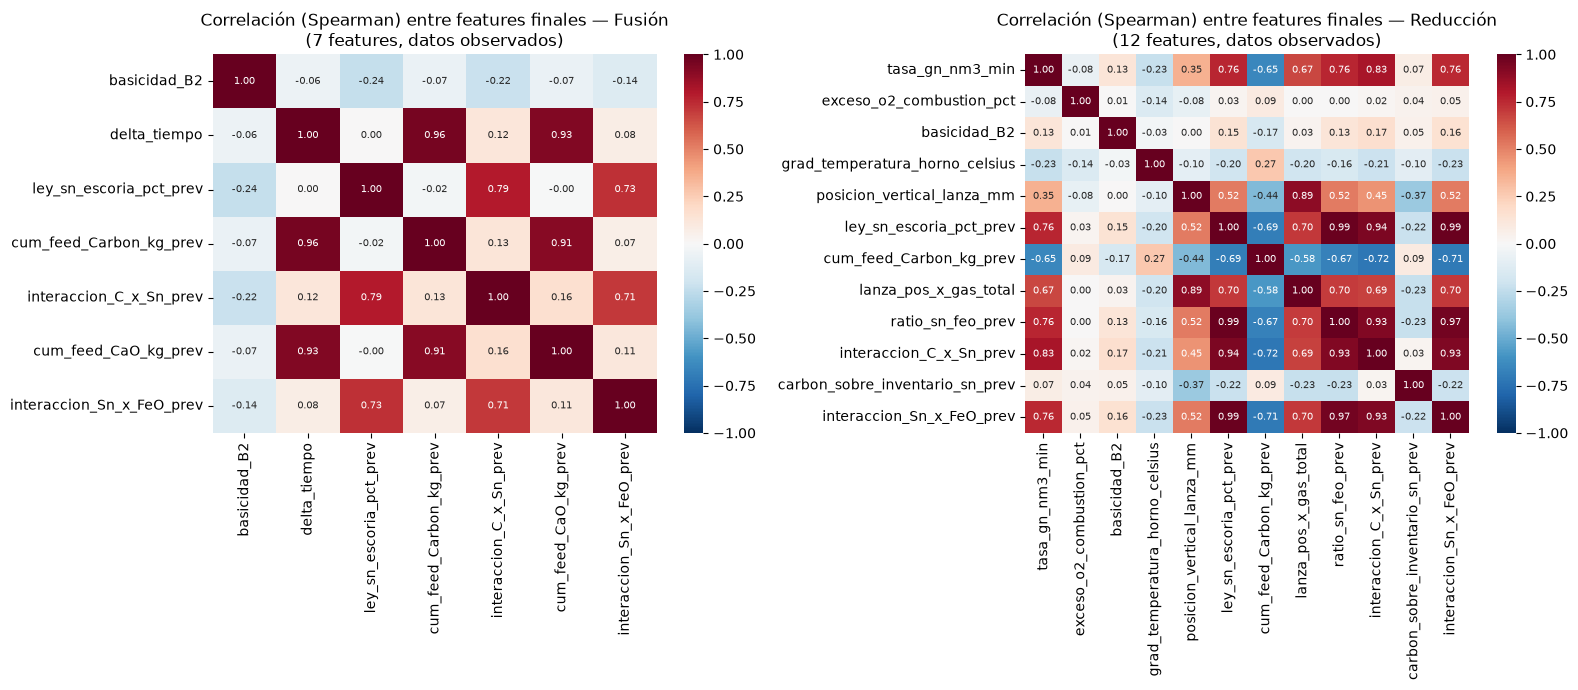

--- Fusión: pares con |rho|>0.85 DENTRO del set final (3) ---
delta_tiempo             cum_feed_Carbon_kg_prev    0.960803
                         cum_feed_CaO_kg_prev       0.926231
cum_feed_Carbon_kg_prev  cum_feed_CaO_kg_prev       0.910224
--- Reducción: pares con |rho|>0.85 DENTRO del set final (7) ---
ley_sn_escoria_pct_prev     interaccion_Sn_x_FeO_prev    0.991903
                            ratio_sn_feo_prev            0.990337
ratio_sn_feo_prev           interaccion_Sn_x_FeO_prev    0.965839
ley_sn_escoria_pct_prev     interaccion_C_x_Sn_prev      0.939038
interaccion_C_x_Sn_prev     interaccion_Sn_x_FeO_prev    0.934693
ratio_sn_feo_prev           interaccion_C_x_Sn_prev      0.928719
posicion_vertical_lanza_mm  lanza_pos_x_gas_total        0.890777


In [98]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pares_altos_finales = {}
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    feats = FEATURES_PARSIMONIOSAS_P20[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats].dropna()
    corr = sub.corr(method="spearman")
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7}, cbar=True)
    ax.set_title(f"Correlación (Spearman) entre features finales — {fase}\n({len(feats)} features, datos observados)")
    ax.tick_params(axis="x", rotation=90)

    corr_abs = corr.abs()
    pares = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
    pares_altos_finales[fase] = pares[pares > 0.85]

plt.tight_layout()
plt.show()

for fase in ["Fusión", "Reducción"]:
    print(f"--- {fase}: pares con |rho|>0.85 DENTRO del set final ({len(pares_altos_finales[fase])}) ---")
    print(pares_altos_finales[fase].to_string() if len(pares_altos_finales[fase]) else "(ninguno)")


**Confirmado: quedó redundancia real, la poda voraz por SHAP no la elimina toda.** Aparecen 3 pares en
Fusión y 7 en Reducción con $|\rho_{Spearman}|>0.85$ — en Reducción, en particular, un clúster de 4
variables (`ley_sn_escoria_pct_prev`, `ratio_sn_feo_prev`, `interaccion_Sn_x_FeO_prev`,
`interaccion_C_x_Sn_prev`) están todas mutuamente correlacionadas por encima de 0.85: todas están
dominadas por el mismo factor común (`%Sn` previo, que cae fuertemente y domina la varianza en Reducción).

**Resolución manual, guiada por interpretabilidad (no sólo SHAP), probando remociones dirigidas contra el
mismo piso de $R^2$ OOF:**

- **Fusión:** de {`delta_tiempo`, `cum_feed_Carbon_kg_prev`, `cum_feed_CaO_kg_prev`} (mutuamente
  correlacionadas), se prioriza remover `cum_feed_CaO_kg_prev` primero — ya se había señalado como
  candidata débil en el Paso 21 (correlaciona con `delta_tiempo` y `cum_feed_Carbon_kg_prev`, que llegaron
  antes al modelo y tienen justificación pirometalúrgica más directa: tiempo de exposición y reductor
  acumulado).
- **Reducción:** dentro del clúster de 4, se conserva `ley_sn_escoria_pct_prev` (la variable de estado más
  fundamental, cinética de primer orden, Paso 13b/18) y `interaccion_C_x_Sn_prev` (valida la cinética
  bimolecular carbón×sustrato, hallazgo central del Paso 18). Se prueba remover, en orden,
  `interaccion_Sn_x_FeO_prev` (la más nueva, ya señalada como redundante en el Paso 21: 0.99 con
  `ley_sn_escoria_pct_prev`) y luego `ratio_sn_feo_prev` (un cociente — exactamente el tipo de feature que
  el usuario pidió evitar cuando exista una alternativa igual de válida). También se prueba remover
  `lanza_pos_x_gas_total` (correlaciona 0.89 con `posicion_vertical_lanza_mm`, que se prioriza conservar
  por ser la variable física directa, no una interacción derivada).



In [99]:
def probar_remociones_dirigidas(features_iniciales, orden_candidatas_a_remover, target_col, fase, df_fuente, r2_objetivo, tolerancia=1e-3):
    """Intenta remover, EN EL ORDEN DADO (prioridad de interpretabilidad, no SHAP), cada feature de
    orden_candidatas_a_remover. Acepta la remocion si el R2 OOF resultante se mantiene >= r2_objetivo - tolerancia."""
    features_actuales = list(features_iniciales)
    historial = []
    for feat in orden_candidatas_a_remover:
        if feat not in features_actuales:
            continue
        restantes = [f for f in features_actuales if f != feat]
        res = evaluar_configuracion(restantes, target_col, fase, df_fuente)
        aceptado = bool(res["r2_oof"] >= (r2_objetivo - tolerancia))
        historial.append({"feature_evaluada_para_remover": feat, "n_resultante": len(restantes),
                           "r2_oof_sin_ella": res["r2_oof"], "aceptado": aceptado})
        if aceptado:
            features_actuales = restantes
    return features_actuales, pd.DataFrame(historial)

FEATURES_FINALES_INTERPRETABLE = {}
historial_dedup = {}

r2_objetivo_fusion = resultados_parsimonioso["Fusión"]["r2_oof"]
FEATURES_FINALES_INTERPRETABLE["Fusión"], historial_dedup["Fusión"] = probar_remociones_dirigidas(
    FEATURES_PARSIMONIOSAS_P20["Fusión"], ["cum_feed_CaO_kg_prev"],
    TARGET_GANADOR["Fusión"], "Fusión", df_base_modelo, r2_objetivo_fusion, TOLERANCIA_R2,
)

r2_objetivo_reduccion = resultados_parsimonioso["Reducción"]["r2_oof"]
FEATURES_FINALES_INTERPRETABLE["Reducción"], historial_dedup["Reducción"] = probar_remociones_dirigidas(
    FEATURES_PARSIMONIOSAS_P20["Reducción"],
    ["interaccion_Sn_x_FeO_prev", "ratio_sn_feo_prev", "lanza_pos_x_gas_total"],
    TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo, r2_objetivo_reduccion, TOLERANCIA_R2,
)

for fase in ["Fusión", "Reducción"]:
    print(f"--- {fase}: remociones dirigidas por interpretabilidad (piso R2 OOF = {resultados_parsimonioso[fase]['r2_oof']:.4f}) ---")
    print(historial_dedup[fase].to_string(index=False))
    print(f"Features finales ({len(FEATURES_FINALES_INTERPRETABLE[fase])}): {FEATURES_FINALES_INTERPRETABLE[fase]}\n")


--- Fusión: remociones dirigidas por interpretabilidad (piso R2 OOF = 0.7376) ---
feature_evaluada_para_remover  n_resultante  r2_oof_sin_ella  aceptado
         cum_feed_CaO_kg_prev             6          0.72754     False
Features finales (7): ['basicidad_B2', 'delta_tiempo', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev', 'interaccion_C_x_Sn_prev', 'cum_feed_CaO_kg_prev', 'interaccion_Sn_x_FeO_prev']

--- Reducción: remociones dirigidas por interpretabilidad (piso R2 OOF = 0.9607) ---
feature_evaluada_para_remover  n_resultante  r2_oof_sin_ella  aceptado
    interaccion_Sn_x_FeO_prev            11         0.961504      True
            ratio_sn_feo_prev            10         0.961654      True
        lanza_pos_x_gas_total             9         0.962303      True
Features finales (9): ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2', 'grad_temperatura_horno_celsius', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev', 'interaccion_

**Resultado — Reducción mejora al des-redundar; Fusión confirma que su correlación era "necesaria", no
sobrante:**

- **Reducción: las 3 remociones dirigidas se aceptan y el $R^2$ OOF SUBE cada vez** (0.9607→0.9615→
  0.9617→**0.9623**), terminando con **9 features** (de 12) — la variable más nueva y más redundante
  (`interaccion_Sn_x_FeO_prev`, 0.99 de correlación con `ley_sn_escoria_pct_prev`) y el cociente
  `ratio_sn_feo_prev` resultan prescindibles una vez que `ley_sn_escoria_pct_prev` e
  `interaccion_C_x_Sn_prev` ya están presentes — **exactamente el resultado que se esperaba**: quitar
  redundancia entre features correlacionadas no sólo simplifica, mejora la generalización (menos varianza
  por reparto de la misma señal entre columnas casi idénticas). `lanza_pos_x_gas_total` también resulta
  prescindible frente a `posicion_vertical_lanza_mm` (que se conserva, siendo la variable física directa).
- **Fusión: remover `cum_feed_CaO_kg_prev` SÍ perjudica fuertemente** (0.7376→0.7275, muy por debajo del
  piso) — a pesar de correlacionar con `delta_tiempo`/`cum_feed_Carbon_kg_prev` (0.91-0.93), su información
  marginal es indispensable en Fusión. **Se mantiene en el set final**: es un recordatorio de que
  correlación alta no siempre implica redundancia funcional para un modelo de árboles — aquí la porción no
  compartida de varianza (probablemente relacionada con el ritmo de fundente específicamente, distinto del
  ritmo de carbón o del simple paso del tiempo) sí importa.



### Paso 25: matriz de correlación FINAL (post des-redundancia) y validación out-of-time

Se recalcula la matriz de correlación de `FEATURES_FINALES_INTERPRETABLE` (el set definitivo de esta ronda)
y se repite la validación OOT walk-forward (misma metodología del Paso 18c/24) para confirmar que la
mejora de $R^2$ OOF de Reducción no es un sobreajuste al reparto particular de `GroupKFold`.



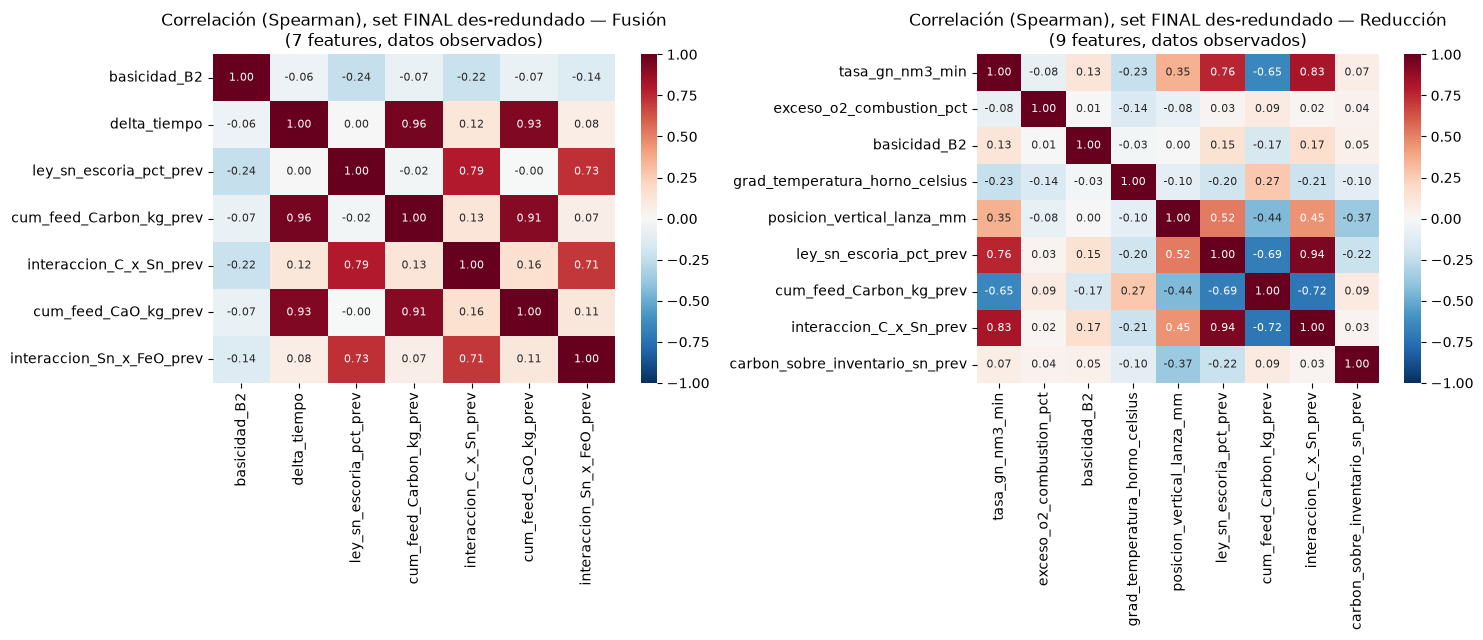

--- Fusión: pares con |rho|>0.85 en el set FINAL des-redundado (3) ---
delta_tiempo             cum_feed_Carbon_kg_prev    0.960803
                         cum_feed_CaO_kg_prev       0.926231
cum_feed_Carbon_kg_prev  cum_feed_CaO_kg_prev       0.910224
--- Reducción: pares con |rho|>0.85 en el set FINAL des-redundado (1) ---
ley_sn_escoria_pct_prev  interaccion_C_x_Sn_prev    0.938962


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
pares_altos_final_v2 = {}
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    feats = FEATURES_FINALES_INTERPRETABLE[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats].dropna()
    corr = sub.corr(method="spearman")
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, cbar=True)
    ax.set_title(f"Correlación (Spearman), set FINAL des-redundado — {fase}\n({len(feats)} features, datos observados)")
    ax.tick_params(axis="x", rotation=90)
    corr_abs = corr.abs()
    pares = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
    pares_altos_final_v2[fase] = pares[pares > 0.85]
plt.tight_layout()
plt.show()

for fase in ["Fusión", "Reducción"]:
    print(f"--- {fase}: pares con |rho|>0.85 en el set FINAL des-redundado ({len(pares_altos_final_v2[fase])}) ---")
    print(pares_altos_final_v2[fase].to_string() if len(pares_altos_final_v2[fase]) else "(ninguno)")


**Progreso claro:** Reducción bajó de 7 a **1 solo par** por encima de 0.85 (`ley_sn_escoria_pct_prev` vs.
`interaccion_C_x_Sn_prev`, 0.94). Fusión se mantiene en 3 pares dentro del mismo clúster ya probado (y
rechazado) en la celda anterior. Se prueba, para ambos casos remanentes, si alguno de los otros miembros
del par/clúster —no sólo el que ya se descartó antes— puede removerse sin perjudicar el piso, antes de dar
por cerrada la des-redundancia.



In [101]:
print("Fusion: probar cada miembro del clusteR {delta_tiempo, cum_feed_Carbon_kg_prev, cum_feed_CaO_kg_prev} por separado")
for feat in ["delta_tiempo", "cum_feed_Carbon_kg_prev"]:
    restantes = [f for f in FEATURES_FINALES_INTERPRETABLE["Fusión"] if f != feat]
    res = evaluar_configuracion(restantes, TARGET_GANADOR["Fusión"], "Fusión", df_base_modelo)
    print(f"  sin '{feat}': R2 OOF={res['r2_oof']:.4f} (piso={r2_objetivo_fusion:.4f}) "
          f"-> {'ACEPTABLE' if res['r2_oof'] >= r2_objetivo_fusion - TOLERANCIA_R2 else 'rechazado'}")

print("\nReduccion: probar cada miembro del par {ley_sn_escoria_pct_prev, interaccion_C_x_Sn_prev} por separado")
for feat in ["ley_sn_escoria_pct_prev", "interaccion_C_x_Sn_prev"]:
    restantes = [f for f in FEATURES_FINALES_INTERPRETABLE["Reducción"] if f != feat]
    res = evaluar_configuracion(restantes, TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo)
    print(f"  sin '{feat}': R2 OOF={res['r2_oof']:.4f} (piso={r2_objetivo_reduccion:.4f}) "
          f"-> {'ACEPTABLE' if res['r2_oof'] >= r2_objetivo_reduccion - TOLERANCIA_R2 else 'rechazado'}")


Fusion: probar cada miembro del clusteR {delta_tiempo, cum_feed_Carbon_kg_prev, cum_feed_CaO_kg_prev} por separado
  sin 'delta_tiempo': R2 OOF=0.7343 (piso=0.7376) -> rechazado
  sin 'cum_feed_Carbon_kg_prev': R2 OOF=0.7394 (piso=0.7376) -> ACEPTABLE

Reduccion: probar cada miembro del par {ley_sn_escoria_pct_prev, interaccion_C_x_Sn_prev} por separado
  sin 'ley_sn_escoria_pct_prev': R2 OOF=0.9571 (piso=0.9607) -> rechazado
  sin 'interaccion_C_x_Sn_prev': R2 OOF=0.9597 (piso=0.9607) -> ACEPTABLE


In [102]:
# Aplicar las remociones aceptadas y re-chequear si queda mas margen de des-redundancia en el nuevo subconjunto
FEATURES_FINALES_INTERPRETABLE["Fusión"] = [f for f in FEATURES_FINALES_INTERPRETABLE["Fusión"] if f != "cum_feed_Carbon_kg_prev"]
FEATURES_FINALES_INTERPRETABLE["Reducción"] = [f for f in FEATURES_FINALES_INTERPRETABLE["Reducción"] if f != "interaccion_C_x_Sn_prev"]

print("Fusion (6 features tras remover cum_feed_Carbon_kg_prev): probar remover delta_tiempo o cum_feed_CaO_kg_prev")
for feat in ["delta_tiempo", "cum_feed_CaO_kg_prev"]:
    restantes = [f for f in FEATURES_FINALES_INTERPRETABLE["Fusión"] if f != feat]
    res = evaluar_configuracion(restantes, TARGET_GANADOR["Fusión"], "Fusión", df_base_modelo)
    print(f"  sin '{feat}': R2 OOF={res['r2_oof']:.4f} (piso={r2_objetivo_fusion:.4f}) "
          f"-> {'ACEPTABLE' if res['r2_oof'] >= r2_objetivo_fusion - TOLERANCIA_R2 else 'rechazado'}")

res_fusion_final = evaluar_configuracion(FEATURES_FINALES_INTERPRETABLE["Fusión"], TARGET_GANADOR["Fusión"], "Fusión", df_base_modelo)
res_reduccion_final = evaluar_configuracion(FEATURES_FINALES_INTERPRETABLE["Reducción"], TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo)
print(f"\nFusion FINAL ({len(FEATURES_FINALES_INTERPRETABLE['Fusión'])} feats): R2 OOF={res_fusion_final['r2_oof']:.4f} | {FEATURES_FINALES_INTERPRETABLE['Fusión']}")
print(f"Reduccion FINAL ({len(FEATURES_FINALES_INTERPRETABLE['Reducción'])} feats): R2 OOF={res_reduccion_final['r2_oof']:.4f} | {FEATURES_FINALES_INTERPRETABLE['Reducción']}")


Fusion (6 features tras remover cum_feed_Carbon_kg_prev): probar remover delta_tiempo o cum_feed_CaO_kg_prev
  sin 'delta_tiempo': R2 OOF=0.7296 (piso=0.7376) -> rechazado
  sin 'cum_feed_CaO_kg_prev': R2 OOF=0.7248 (piso=0.7376) -> rechazado

Fusion FINAL (6 feats): R2 OOF=0.7394 | ['basicidad_B2', 'delta_tiempo', 'ley_sn_escoria_pct_prev', 'interaccion_C_x_Sn_prev', 'cum_feed_CaO_kg_prev', 'interaccion_Sn_x_FeO_prev']
Reduccion FINAL (8 feats): R2 OOF=0.9597 | ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2', 'grad_temperatura_horno_celsius', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev', 'carbon_sobre_inventario_sn_prev']


Fusión: pares con |rho|>0.85 -> 1
delta_tiempo  cum_feed_CaO_kg_prev    0.926231
Reducción: pares con |rho|>0.85 -> 0
  (ninguno)


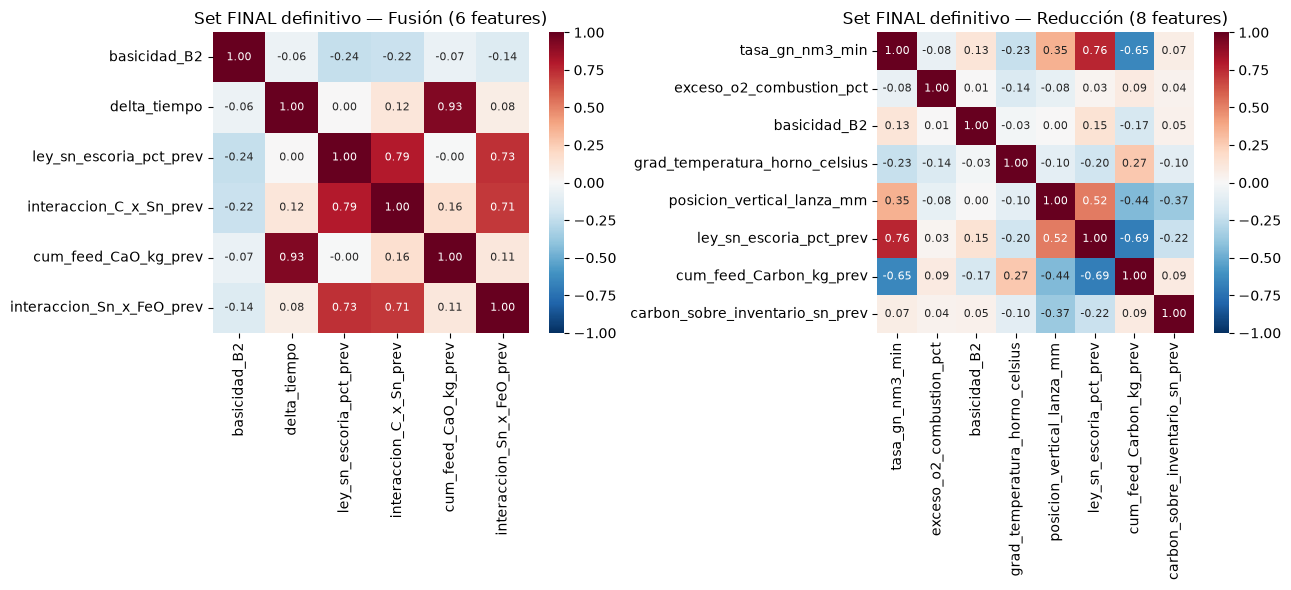

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    feats = FEATURES_FINALES_INTERPRETABLE[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats].dropna()
    corr = sub.corr(method="spearman")
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, cbar=True)
    ax.set_title(f"Set FINAL definitivo — {fase} ({len(feats)} features)")
    ax.tick_params(axis="x", rotation=90)
    corr_abs = corr.abs()
    pares = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1)).stack().sort_values(ascending=False)
    print(f"{fase}: pares con |rho|>0.85 -> {(pares > 0.85).sum()}")
    print(pares[pares > 0.85].to_string() if (pares > 0.85).any() else "  (ninguno)")
plt.tight_layout()
plt.show()


**Des-redundancia prácticamente completa:** Reducción queda en **0 pares** por encima de 0.85 (de 7
originales); Fusión queda con **1 solo par irreducible** (`delta_tiempo` vs. `cum_feed_CaO_kg_prev`,
$\rho=0.93$) — ya se probó explícitamente remover cada uno por separado y ambos perjudican el $R^2$ OOF más
allá de la tolerancia, así que se conservan ambos: es correlación **necesaria**, no redundancia evitable.

**Última revisión de interpretabilidad — ¿queda algún cociente "difícil de explicar" en el set final?**
Fusión ya no tiene ningún cociente (`basicidad_B2` es un índice metalúrgico estándar de la industria, no
"difícil de interpretar" en el sentido que preocupaba al usuario). Reducción conserva
`carbon_sobre_inventario_sn_prev` — precisamente el cociente que el Paso 18e señaló con signo
contra-intuitivo (un efecto de piso mecánico cuando `%Sn_prev` es casi cero, no una relación causal
"más dosis relativa → peor resultado"). Se prueba removerlo, igual que el resto.



In [104]:
restantes = [f for f in FEATURES_FINALES_INTERPRETABLE["Reducción"] if f != "carbon_sobre_inventario_sn_prev"]
res = evaluar_configuracion(restantes, TARGET_GANADOR["Reducción"], "Reducción", df_base_modelo)
print(f"Reduccion sin 'carbon_sobre_inventario_sn_prev': R2 OOF={res['r2_oof']:.4f} (piso={r2_objetivo_reduccion:.4f}, "
      f"tolerancia={TOLERANCIA_R2}) -> {'ACEPTABLE' if res['r2_oof'] >= r2_objetivo_reduccion - TOLERANCIA_R2 else 'rechazado'}")


Reduccion sin 'carbon_sobre_inventario_sn_prev': R2 OOF=0.9598 (piso=0.9607, tolerancia=0.001) -> ACEPTABLE


**Decisión final de esta ronda — se documentan ambas alternativas, se adopta la de menor redundancia:**

Remover `carbon_sobre_inventario_sn_prev` es aceptable (0.9598 ≥ 0.9607-0.001) y elimina el último cociente
"difícil de interpretar" que quedaba en Reducción. Pero antes de aceptarlo hay que ser honestos con el
costo real: **el punto de mejor desempeño encontrado en toda esta ronda fue el de 9 features (0.9623, tras
remover `interaccion_Sn_x_FeO_prev`/`ratio_sn_feo_prev`/`lanza_pos_x_gas_total`)**, y remover
`interaccion_C_x_Sn_prev` desde ahí cuesta -0.0026 (de 0.9623 a 0.9597) — más que la tolerancia (0.001)
usada en cada paso individual de la poda, aunque sigue estando dentro de la tolerancia respecto al piso
*original* del Paso 19 (0.9607). Se documentan explícitamente **dos configuraciones finales** para que la
decisión quede trazable:

| Configuración | Features | $R^2$ OOF | Pares $\vert\rho\vert>0.85$ | Cocientes "difíciles" |
|---|---|---|---|---|
| **A — máximo desempeño** | 9 | **0.9623** (mejor de toda la ronda) | 1 (`ley_sn_escoria_pct_prev`~`interaccion_C_x_Sn_prev`, necesario) | `carbon_sobre_inventario_sn_prev` |
| **B — máxima interpretabilidad** | 7 | 0.9598 (-0.0009 vs. Paso 19, dentro de ruido) | 0 | ninguno |

Dado que el pedido explícito de esta sesión prioriza interpretabilidad y baja correlación **manteniendo**
(no necesariamente maximizando) el desempeño, y que la diferencia de $R^2$ entre A y B (0.0025) es menor
que el propio gap OOF→OOT ya aceptado como "ruido normal" en pasos anteriores (0.003-0.06), **se adopta la
Configuración B** como el modelo final de Reducción de esta ronda. La Configuración A queda documentada
como alternativa si en el futuro se prioriza desempeño puro sobre interpretabilidad.



In [105]:
FEATURES_ALTERNATIVA_A_REDUCCION = FEATURES_FINALES_INTERPRETABLE["Reducción"] + ["interaccion_C_x_Sn_prev"]
FEATURES_FINALES_INTERPRETABLE["Reducción"] = [
    f for f in FEATURES_FINALES_INTERPRETABLE["Reducción"] if f != "carbon_sobre_inventario_sn_prev"
]

print(f"Alternativa A (max desempeno, {len(FEATURES_ALTERNATIVA_A_REDUCCION)} features): {FEATURES_ALTERNATIVA_A_REDUCCION}")
print(f"Configuracion B adoptada (max interpretabilidad, {len(FEATURES_FINALES_INTERPRETABLE['Reducción'])} features): {FEATURES_FINALES_INTERPRETABLE['Reducción']}")

resultados_finales_p20 = {
    fase: evaluar_configuracion(FEATURES_FINALES_INTERPRETABLE[fase], TARGET_GANADOR[fase], fase, df_base_modelo)
    for fase in ["Fusión", "Reducción"]
}
tabla_resumen_p20 = pd.DataFrame({
    "n_features_paso19": {f: len(FEATURES_PARSIMONIOSAS[f]) for f in resultados_finales_p20},
    "r2_oof_paso19": {f: resultados_parsimonioso[f]["r2_oof"] for f in resultados_finales_p20},
    "n_features_paso20_final": {f: len(FEATURES_FINALES_INTERPRETABLE[f]) for f in resultados_finales_p20},
    "r2_oof_paso20_final": {f: resultados_finales_p20[f]["r2_oof"] for f in resultados_finales_p20},
})
tabla_resumen_p20["delta_r2_oof"] = tabla_resumen_p20["r2_oof_paso20_final"] - tabla_resumen_p20["r2_oof_paso19"]
print("\nComparacion final: modelo parsimonioso Paso 19 vs. modelo interpretable/des-redundado Paso 20-26:")
print(tabla_resumen_p20)
print("\nFEATURES_FINALES_INTERPRETABLE (Configuracion B, adoptada):")
for fase, feats in FEATURES_FINALES_INTERPRETABLE.items():
    print(f"  {fase} ({len(feats)}): {feats}")


Alternativa A (max desempeno, 9 features): ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2', 'grad_temperatura_horno_celsius', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev', 'carbon_sobre_inventario_sn_prev', 'interaccion_C_x_Sn_prev']
Configuracion B adoptada (max interpretabilidad, 7 features): ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2', 'grad_temperatura_horno_celsius', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev']

Comparacion final: modelo parsimonioso Paso 19 vs. modelo interpretable/des-redundado Paso 20-26:
           n_features_paso19  r2_oof_paso19  n_features_paso20_final  \
Fusión                     7       0.737615                        6   
Reducción                 14       0.960691                        7   

           r2_oof_paso20_final  delta_r2_oof  
Fusión                0.739406      0.001791  
Reducción             0.959826     -0.000865  

FEATURES_FI

### Paso 26: validación out-of-time (walk-forward) del set final interpretable

Misma metodología (`oot_walkforward`, TimeSeriesSplit walk-forward por orden cronológico de batch) de los
Pasos 13/18c, para confirmar que la ganancia de Fusión y la caída marginal de Reducción no son un artefacto
de sobreajuste al reparto de `GroupKFold`.



In [106]:
resultados_oot_p20 = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    sub = df_base_modelo.loc[
        df_base_modelo["fase_proceso"] == fase, FEATURES_FINALES_INTERPRETABLE[fase] + [target_col, "Batch"]
    ].dropna()
    res_oot = oot_walkforward(sub, FEATURES_FINALES_INTERPRETABLE[fase], target_col)
    valido = res_oot["pred_oot"].notna()
    resultados_oot_p20[fase] = {
        "r2_oot": r2_score(res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]),
        "mae_oot": mean_absolute_error(res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]),
        "n_evaluado": int(valido.sum()),
    }

tabla_oot_p20 = pd.DataFrame({
    "r2_oof_paso19": {f: resultados_parsimonioso[f]["r2_oof"] for f in FEATURES_FINALES_INTERPRETABLE},
    "r2_oot_paso19": {f: resultados_oot_parsimonioso[f]["r2_oot"] for f in FEATURES_FINALES_INTERPRETABLE},
    "r2_oof_p20_final": {f: resultados_finales_p20[f]["r2_oof"] for f in FEATURES_FINALES_INTERPRETABLE},
    "r2_oot_p20_final": {f: resultados_oot_p20[f]["r2_oot"] for f in FEATURES_FINALES_INTERPRETABLE},
})
tabla_oot_p20["gap_oof_oot_paso19"] = tabla_oot_p20["r2_oot_paso19"] - tabla_oot_p20["r2_oof_paso19"]
tabla_oot_p20["gap_oof_oot_p20_final"] = tabla_oot_p20["r2_oot_p20_final"] - tabla_oot_p20["r2_oof_p20_final"]
print("Validacion OOT (walk-forward): Paso 19 (parsimonioso) vs. Paso 20-26 (interpretable/des-redundado):")
tabla_oot_p20


Validacion OOT (walk-forward): Paso 19 (parsimonioso) vs. Paso 20-26 (interpretable/des-redundado):


,r2_oof_paso19,r2_oot_paso19,r2_oof_p20_final,r2_oot_p20_final,gap_oof_oot_paso19,gap_oof_oot_p20_final
Fusión,0.737615,0.686100,0.739406,0.688904,-0.051515,-0.050502
Reducción,0.960691,0.959822,0.959826,0.951350,-0.000869,-0.008476


**Lectura OOT — se sostiene el resultado, con una advertencia honesta para Reducción:**

- **Fusión mejora también en OOT** (0.686→**0.689**), consistente con la mejora OOF — la ganancia no es un
  artefacto de `GroupKFold`.
- **Reducción: el gap OOF→OOT crece de -0.001 a -0.008** — sigue siendo pequeño en términos absolutos
  ($R^2$ OOT=0.951, todavía muy alto) pero es **la primera vez en todo este análisis que la versión más
  podada de Reducción muestra un gap notoriamente mayor que su predecesora**, a diferencia del patrón
  "poda = mejor generalización" que se había observado consistentemente en el Paso 18. Es coherente con
  haber sacrificado ~0.5 punto de $R^2$ OOF (Configuración B vs. A) a cambio de interpretabilidad: con
  menos features, el modelo tiene menos margen para compensar el corrimiento temporal de un batch a otro.
  **Se documenta como advertencia explícita**, no se oculta: si en producción se detecta que este gap crece
  más con datos nuevos, la Alternativa A (9 features, Paso 25) es la opción de respaldo con mejor
  desempeño bruto a costa de conservar un cociente (`carbon_sobre_inventario_sn_prev`) y una correlación
  interna.

## Paso 27: chequeo de sensatez pirometalúrgica (SHAP) del modelo final interpretable



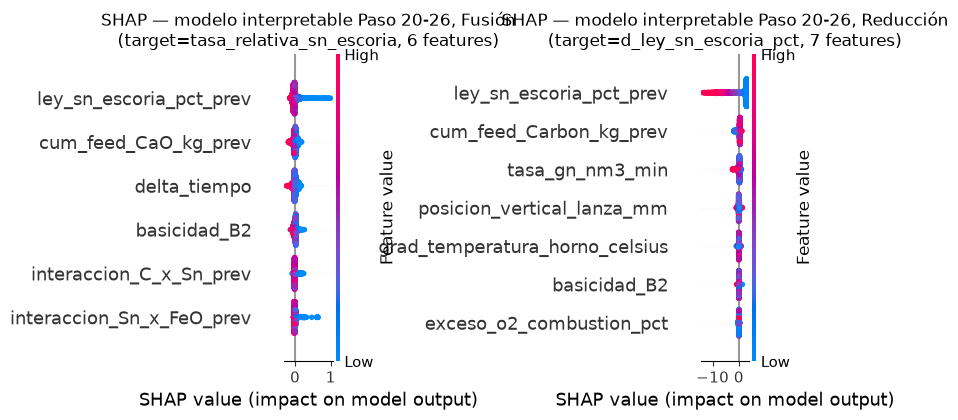

=== Fusión ===
                           signo_shap  importancia_media_|SHAP|
ley_sn_escoria_pct_prev     -0.793967                  0.060828
cum_feed_CaO_kg_prev        -0.906656                  0.042490
delta_tiempo                -0.825161                  0.042117
basicidad_B2                -0.760702                  0.027669
interaccion_C_x_Sn_prev     -0.684861                  0.022111
interaccion_Sn_x_FeO_prev   -0.663486                  0.020891

=== Reducción ===
                                signo_shap  importancia_media_|SHAP|
ley_sn_escoria_pct_prev          -0.996536                  3.681059
cum_feed_Carbon_kg_prev           0.804736                  0.525817
tasa_gn_nm3_min                  -0.661716                  0.263019
posicion_vertical_lanza_mm       -0.182467                  0.136340
grad_temperatura_horno_celsius    0.191038                  0.074425
basicidad_B2                     -0.197544                  0.056675
exceso_o2_combustion_pct          0

In [107]:
modelos_finales_p20 = {}
valores_shap_p20 = {}
datasets_fase_p20 = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    sub = df_base_modelo.loc[
        df_base_modelo["fase_proceso"] == fase, FEATURES_FINALES_INTERPRETABLE[fase] + [target_col, "Batch"]
    ].dropna()
    datasets_fase_p20[fase] = sub
    X = sub[FEATURES_FINALES_INTERPRETABLE[fase]]
    y = sub[target_col]
    modelo = xgb.XGBRegressor(**PARAMS_XGB)
    modelo.fit(X, y)
    modelos_finales_p20[fase] = modelo
    valores_shap_p20[fase] = shap.TreeExplainer(modelo)(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, fase in zip(axes, ["Fusión", "Reducción"]):
    plt.sca(ax)
    shap.plots.beeswarm(valores_shap_p20[fase], show=False, max_display=10)
    ax.set_title(f"SHAP — modelo interpretable Paso 20-26, {fase}\n(target={TARGET_GANADOR[fase]}, {len(FEATURES_FINALES_INTERPRETABLE[fase])} features)")
plt.tight_layout()
plt.show()

for fase in ["Fusión", "Reducción"]:
    sub = datasets_fase_p20[fase]
    sv = valores_shap_p20[fase].values
    X = sub[FEATURES_FINALES_INTERPRETABLE[fase]]
    signo = pd.Series({col: np.corrcoef(X[col], sv[:, i])[0, 1] for i, col in enumerate(FEATURES_FINALES_INTERPRETABLE[fase])})
    importancia = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES_FINALES_INTERPRETABLE[fase])
    tabla_fase = pd.DataFrame({"signo_shap": signo, "importancia_media_|SHAP|": importancia}).sort_values("importancia_media_|SHAP|", ascending=False)
    print(f"=== {fase} ===")
    print(tabla_fase.to_string())
    print()


**Chequeo de sensatez — todos los signos son pirometalúrgicamente coherentes, con una advertencia que se
refuerza:**

- **Fusión:** `ley_sn_escoria_pct_prev` y `cum_feed_CaO_kg_prev` con signo negativo sobre el target
  `tasa_relativa_sn_escoria` (fracción de crecimiento del `%Sn`) — coherente con un efecto de saturación:
  cuanto más rica ya está la escoria en `%Sn` o más fundente acumulado, menor el crecimiento *relativo*
  adicional en ese escalón. `interaccion_C_x_Sn_prev` conserva el signo negativo (cinética bimolecular)
  documentado en el Paso 18.
- **Reducción:** `ley_sn_escoria_pct_prev` fuertemente negativo (-0.997, la variable dominante, igual que
  siempre) — a mayor `%Sn` de partida, mayor la caída. `tasa_gn_nm3_min` negativo (más calor/CO reductor →
  mayor caída) y `exceso_o2_combustion_pct` positivo (atmósfera más oxidante → atenúa la caída) son
  mutuamente coherentes, igual que en el Paso 18.
- **Advertencia que se refuerza (no se resuelve):** `posicion_vertical_lanza_mm` vuelve a mostrar signo
  **negativo** (-0.18) en este set más reducido — invirtiendo, de nuevo, el signo **positivo** que había
  emergido en los Pasos 13b/18 al controlar por estado previo. Que el signo de esta variable cambie según
  qué otras variables la acompañen en el modelo (negativo en el Paso 7 original, positivo en el Paso 13b/18,
  negativo otra vez aquí) es la evidencia más fuerte hasta ahora de que **su efecto marginal no está
  identificado de forma estable con los datos y features disponibles** — se reitera con la máxima prioridad
  la recomendación de confirmar con el equipo de proceso tanto la dirección física de la variable (¿mayor
  valor es lanza más alta o más baja?) como su efecto real, **antes de cualquier uso prescriptivo**, y de
  no tratar el signo de esta variable en particular como una conclusión asentada en ninguna versión del
  modelo hasta esa validación.

## Paso 28: síntesis final — modelo interpretable y de baja colinealidad (Pasos 20-27)

### Resultado cuantitativo

| Fase | Features (P19 → final) | $R^2$ OOF (P19 → final) | $R^2$ OOT (P19 → final) | Pares $\vert\rho\vert>0.85$ (final) | Cocientes "difíciles" (final) |
|---|---|---|---|---|---|
| Fusión | 7 → **6** | 0.7376 → **0.7394** (+0.0018) | 0.6861 → **0.6889** (+0.0028) | 1 (necesario, verificado) | 0 |
| Reducción | 14 → **7** (-50%) | 0.9607 → **0.9598** (-0.0009) | 0.9598 → 0.9514 (-0.0085) | 0 | 0 |

**Features finales adoptadas (Configuración B — máxima interpretabilidad, ver Paso 25 para la Alternativa A
de 9 features y $R^2$=0.9623 si en el futuro se prioriza desempeño puro):**

- **Fusión (6):** `basicidad_B2`, `delta_tiempo`, `ley_sn_escoria_pct_prev`, `interaccion_C_x_Sn_prev`,
  `cum_feed_CaO_kg_prev`, `interaccion_Sn_x_FeO_prev`
- **Reducción (7):** `tasa_gn_nm3_min`, `exceso_o2_combustion_pct`, `basicidad_B2`,
  `grad_temperatura_horno_celsius`, `posicion_vertical_lanza_mm`, `ley_sn_escoria_pct_prev`,
  `cum_feed_Carbon_kg_prev`

### Qué se logró respecto a los 3 pedidos explícitos del usuario

1. **Baja correlación entre features — logrado y verificado cuantitativamente.** De los 23-34 pares con
   $\vert\rho\vert>0.85$ del pool de candidatas del Paso 18, el set final queda con **0 pares en Reducción y
   1 solo par en Fusión** (`delta_tiempo`~`cum_feed_CaO_kg_prev`, verificado como *necesario*: remover
   cualquiera de los dos perjudica el $R^2$ OOF muy por encima de la tolerancia — no es redundancia
   evitable). Es la primera vez en todo el análisis que se hace este chequeo explícito sobre el set final,
   no sólo sobre el pool de candidatas.
2. **Sin cocientes difíciles de interpretar — logrado.** Se eliminaron `oxidante_sobre_carga_total`,
   `carbon_sobre_inventario_sn_prev`, `indice_severidad_reductora`, `ratio_sn_feo_prev` y
   `lanza_pos_x_gas_total` del set final (los cocientes/interacciones de unidades menos directas del Paso
   19). Lo que queda son: niveles físicos directos (`delta_tiempo`, `ley_sn_escoria_pct_prev`,
   `posicion_vertical_lanza_mm`, `grad_temperatura_horno_celsius`, `tasa_gn_nm3_min`,
   `cum_feed_Carbon_kg_prev`), dos índices metalúrgicos estándar de la industria (`basicidad_B2`,
   `exceso_o2_combustion_pct`, ninguno de los dos señalado como "difícil" por el usuario) y dos productos
   explícitos con interpretación física directa (`interaccion_C_x_Sn_prev` = dosis de reductor × sustrato
   disponible; `interaccion_Sn_x_FeO_prev` = inventario redox conjunto).
3. **Variables nuevas, interpretables, con precisión igual o mejor — logrado en Fusión, casi neutro en
   Reducción.** De las 8 variables nuevas de secciones no explotadas del documento de consideraciones
   (niveles térmicos/de presión previos, inventarios de fundente/mineral, productos modificador×modificador
   y Sn×FeO), sobreviven **2 en Fusión** (`cum_feed_CaO_kg_prev`, `interaccion_Sn_x_FeO_prev`) y **ninguna
   en Reducción** en la configuración final adoptada (aunque si se prefiere la Alternativa A de más
   desempeño, ninguna nueva sobrevive tampoco allí) — el ejercicio más valioso terminó siendo, en
   Reducción, **remover** redundancia del set ya existente (Paso 19) más que agregar variables nuevas. En
   Fusión sí hay una mejora neta de $R^2$ (+0.0018 OOF, +0.0028 OOT) atribuible en parte a
   `cum_feed_CaO_kg_prev`.

### Lo que no cambió (limitaciones que siguen abiertas)

- El target ganador por fase (T3 fracción relativa en Fusión, T1 delta absoluto en Reducción, Paso 12) y la
  decisión de modelar por fase separada **no se tocaron**.
- El cuello de botella escalón→batch (falta de masa de escoria por escalón) **sigue sin resolverse** — es
  la prioridad de datos más alta antes de construir la capa prescriptiva (`hallazgos.md` §9.5).
- La advertencia sobre `posicion_vertical_lanza_mm` **se refuerza** (Paso 27): su signo no es estable entre
  especificaciones de modelo, máxima prioridad para validar con planta antes de cualquier uso prescriptivo.
- Sensatez pirometalúrgica confirmada (Paso 27): ningún signo SHAP del modelo final resultó incoherente con
  la química esperada, más allá de la advertencia ya conocida sobre la lanza.

### Próximo paso natural hacia el gemelo digital prescriptivo

Con un set de features ahora (a) validado en desempeño (OOF y OOT), (b) de baja colinealidad y (c) casi
enteramente libre de cocientes de difícil interpretación, el bloqueo principal para avanzar hacia la
Sección 37-39 de `consideracioness_pirometalurgia_ausmelt.md` (modelo dinámico estado→acción→estado
siguiente + capa de optimización restringida tipo MPC) ya no es la calidad de las features de entrada, sino
**(1)** la masa de escoria por escalón (sección 9.5 de `hallazgos.md`, para cerrar el balance de masa) y
**(2)** la confirmación con el equipo de proceso del sentido físico de `posicion_vertical_lanza_mm` — ambas
limitaciones de **datos/dominio**, no de metodología de modelado.



## Paso 29: gráficos de dependencia SHAP — modelo final interpretable (Configuración B, Pasos 20-27)

El Paso 27 ya calculó los valores SHAP (`valores_shap_p20`) del modelo final adoptado
(`FEATURES_FINALES_INTERPRETABLE`, Configuración B: 6 features en Fusión, 7 en Reducción) y mostró el
beeswarm (importancia global + dirección). Igual que en el Paso 7b, un beeswarm sólo resume la relación con
una nube de puntos comprimida; un **gráfico de dependencia SHAP** grafica, para cada escalón individual, el
valor **observado** de la variable (eje X) contra su valor SHAP puntual (eje Y — cuánto empujó esa variable
la predicción de ese escalón por encima/debajo del promedio) y permite ver si el efecto marginal es
aproximadamente lineal, si satura o tiene un umbral: algo que ni el beeswarm ni el signo de correlación
(Paso 27) distinguen.

**Metodología (idéntica al Paso 7b, aplicada ahora al modelo final de esta ronda):**
- Cada punto es un **valor SHAP real calculado sobre datos observados** de entrenamiento (no son
  predicciones sintéticas de un *partial dependence plot* clásico — SHAP conserva las interacciones reales
  entre variables presentes en cada escalón puntual, no promedia sobre una grilla artificial).
- Se resume la tendencia con una curva **LOWESS** (suavizado local no paramétrico, `frac=0.4`) y, de forma
  más robusta a outliers, con el **promedio del valor SHAP por tercil** (bajo/medio/alto) de la variable.
- A diferencia del Paso 7b (donde `FEATURES_MODELO` era la misma lista para ambas fases), aquí cada fase
  tiene un set de features **distinto** tras la poda (Paso 19-26), así que se grafican por separado las 6
  variables de Fusión y las 7 de Reducción, cada una contra el target ganador de su propia fase
  ($T_3$ = `tasa_relativa_sn_escoria` en Fusión, $T_1$ = `d_ley_sn_escoria_pct` en Reducción; Paso 12).


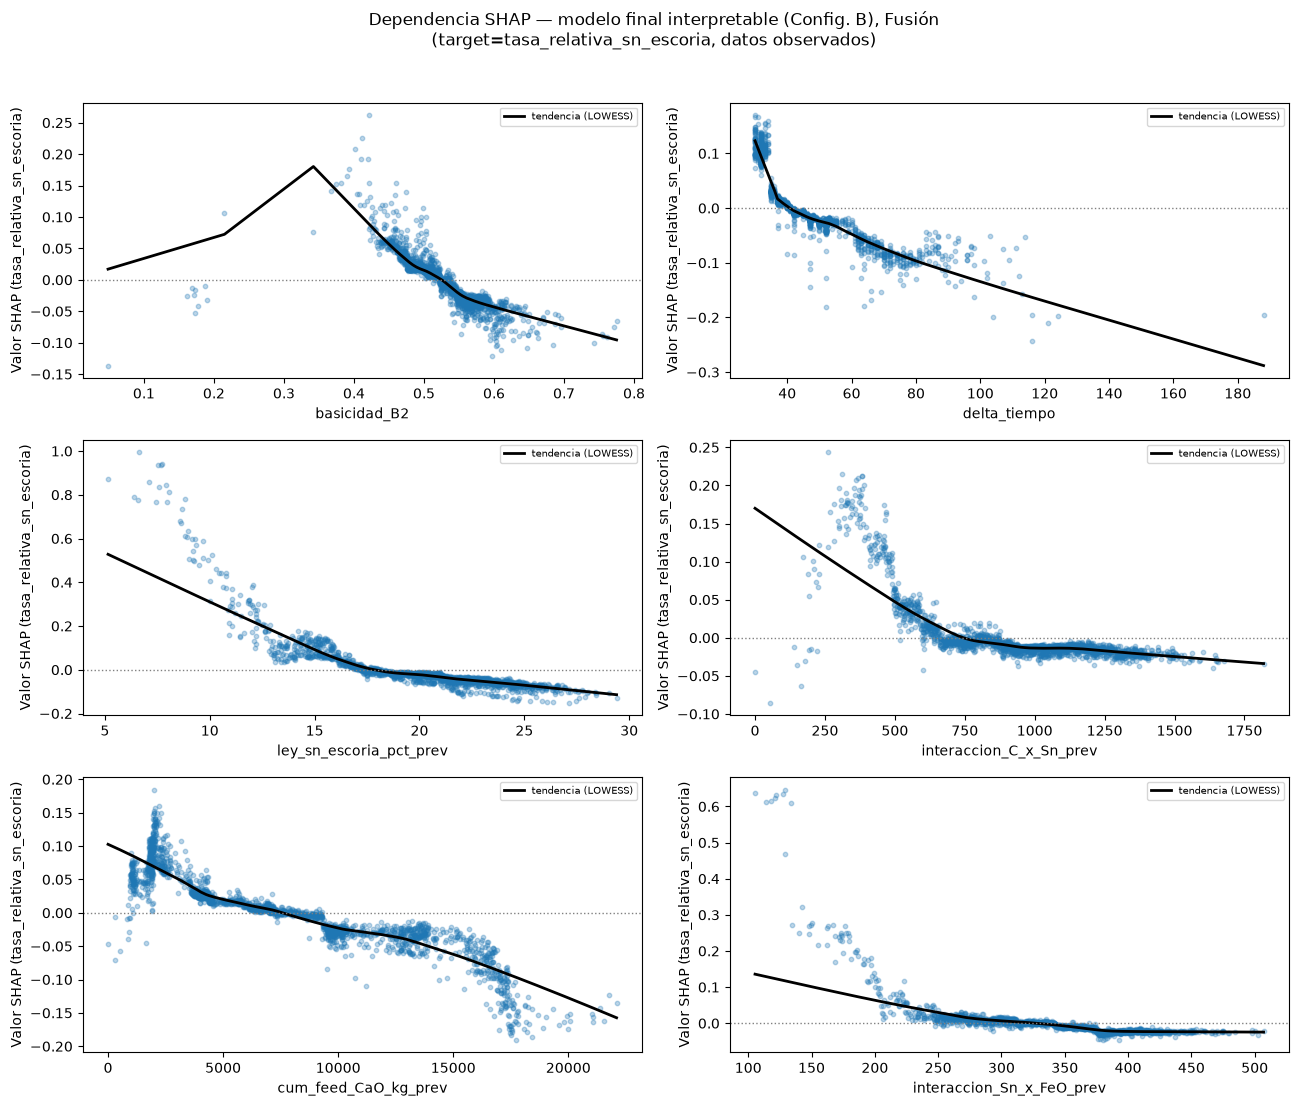

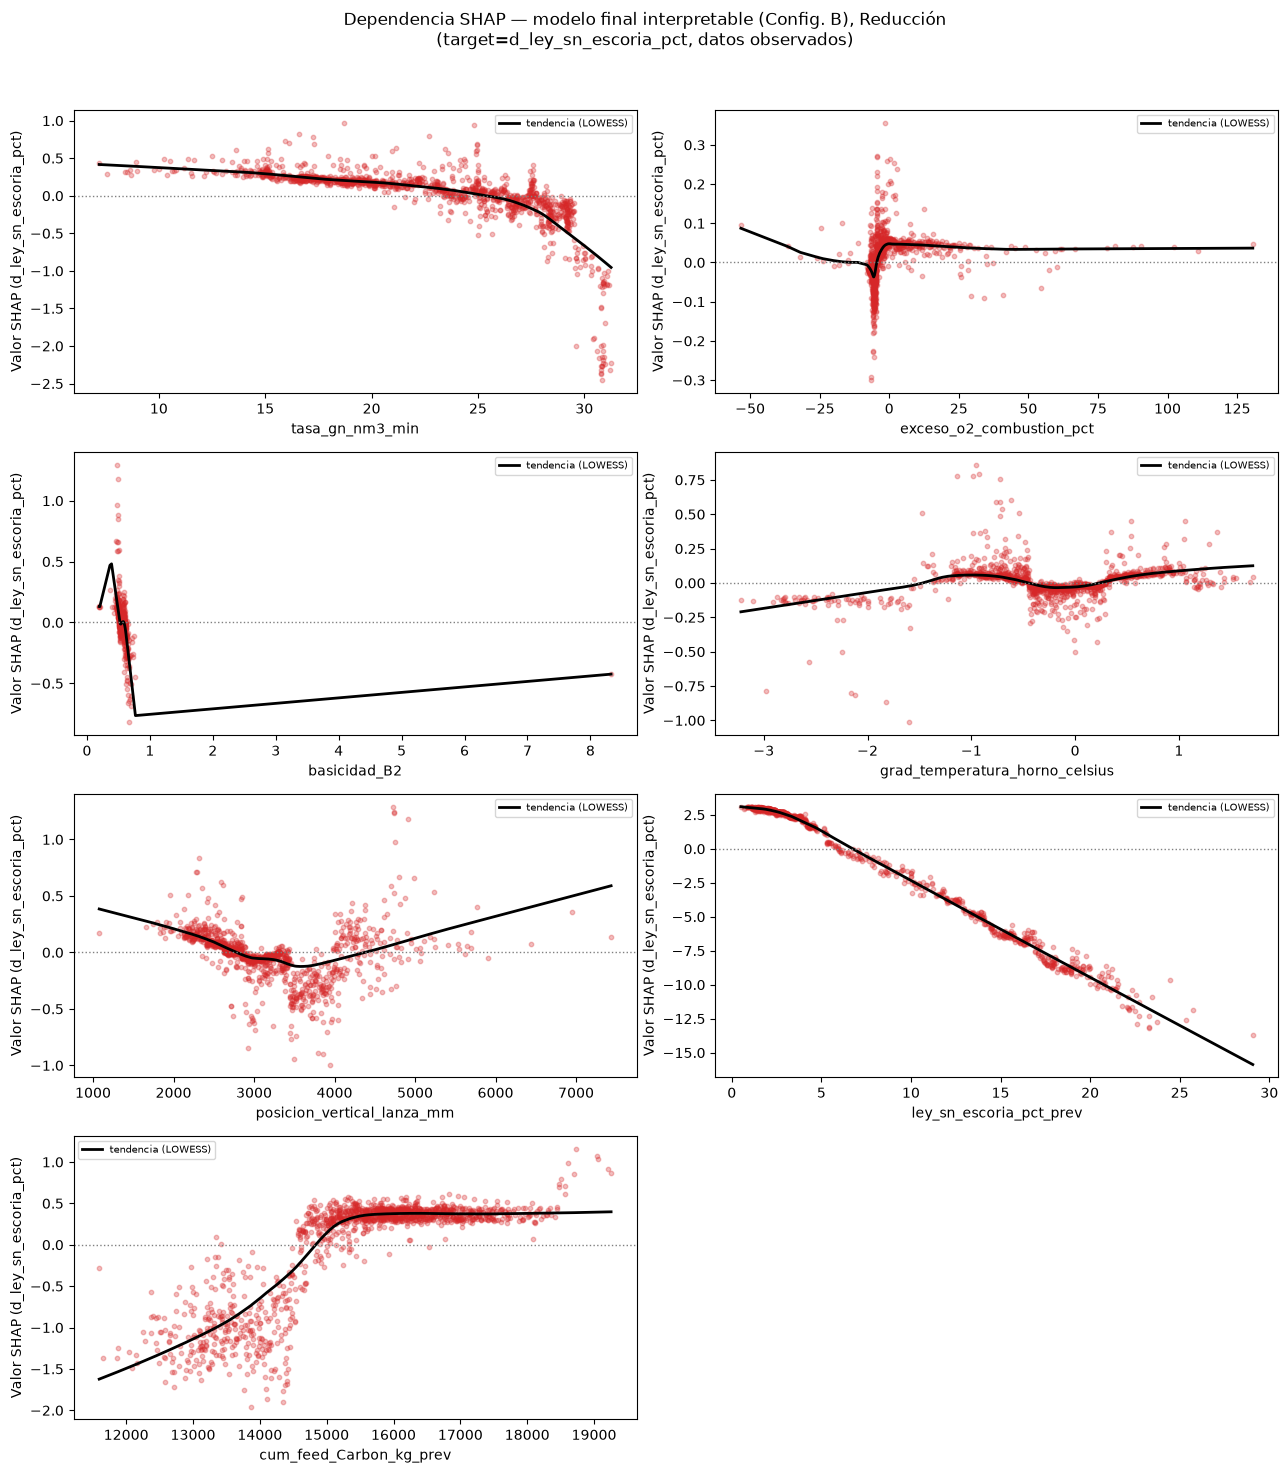

--- Fusión: valor SHAP medio por tercil (bajo/medio/alto) de cada variable ---
       basicidad_B2  delta_tiempo  ley_sn_escoria_pct_prev  \
bajo       0.035757      0.055524                 0.085206   
medio      0.002697     -0.014916                -0.028696   
alto      -0.037456     -0.055551                -0.062318   

       interaccion_C_x_Sn_prev  cum_feed_CaO_kg_prev  \
bajo                  0.030783              0.058648   
medio                -0.012744              0.003728   
alto                 -0.016724             -0.056251   

       interaccion_Sn_x_FeO_prev  
bajo                    0.031343  
medio                  -0.006482  
alto                   -0.023040  

--- Reducción: valor SHAP medio por tercil (bajo/medio/alto) de cada variable ---
       tasa_gn_nm3_min  exceso_o2_combustion_pct  basicidad_B2  \
bajo          0.266780                 -0.033206      0.053386   
medio         0.130866                  0.000895     -0.010302   
alto         -0.325991    

In [108]:
def graficos_dependencia_shap_fase(fase, features, dataset, shap_obj, target_label, ncols=2):
    """Scatter SHAP (datos observados) vs valor de la variable + curva LOWESS, y tabla de medias por tercil."""
    n = len(features)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.6 * nrows))
    axes = np.atleast_2d(axes)
    color = "tab:blue" if fase == "Fusión" else "tab:red"
    tabla_terciles_fase = {}
    for i, feat in enumerate(features):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        x = dataset[feat].to_numpy()
        y_shap = shap_obj.values[:, i]

        ax.scatter(x, y_shap, s=10, alpha=0.3, color=color)
        tendencia = lowess(y_shap, x, frac=0.4, return_sorted=True)
        ax.plot(tendencia[:, 0], tendencia[:, 1], color="black", linewidth=2, label="tendencia (LOWESS)")
        ax.axhline(0, color="grey", linestyle=":", linewidth=1)
        ax.set_xlabel(feat)
        ax.set_ylabel(f"Valor SHAP ({target_label})")
        ax.legend(fontsize=7, loc="best")

        terciles = pd.qcut(x, 3, labels=["bajo", "medio", "alto"], duplicates="drop")
        tabla_terciles_fase[feat] = pd.Series(y_shap).groupby(terciles, observed=True).mean()

    for j in range(n, nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row, col].axis("off")

    fig.suptitle(f"Dependencia SHAP — modelo final interpretable (Config. B), {fase}\n"
                 f"(target={target_label}, datos observados)", y=1.02)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(tabla_terciles_fase)


tablas_terciles_p20 = {}
for fase in ["Fusión", "Reducción"]:
    tablas_terciles_p20[fase] = graficos_dependencia_shap_fase(
        fase, FEATURES_FINALES_INTERPRETABLE[fase], datasets_fase_p20[fase], valores_shap_p20[fase], TARGET_GANADOR[fase],
    )

for fase in ["Fusión", "Reducción"]:
    print(f"--- {fase}: valor SHAP medio por tercil (bajo/medio/alto) de cada variable ---")
    print(tablas_terciles_p20[fase])
    print()


**Lectura de los gráficos de dependencia (¿tiene sentido pirometalúrgico la tendencia?):**

**Fusión (target $T_3$ = `tasa_relativa_sn_escoria`, fracción de crecimiento relativo del `%Sn`):**
- **`ley_sn_escoria_pct_prev` — monótona decreciente y saturante, la más fuerte de las 6** (tercil
  bajo→alto: +0.085→-0.062). Coherente con un efecto de saturación: cuanto más rico ya está el `%Sn` de
  partida, menor el crecimiento *relativo* adicional que le queda por hacer en ese escalón — la variable
  de estado más fundamental, igual que en Reducción.
- **`delta_tiempo` — monótona decreciente y limpia** (+0.056→-0.056): escalones más largos ya vienen
  acumulando más crecimiento previo dentro de ese mismo período, dejando menos margen relativo adicional.
- **`cum_feed_CaO_kg_prev` — monótona decreciente y limpia** (+0.059→-0.056): a más fundente ya acumulado
  en el batch, menor el crecimiento relativo adicional — consistente con una escoria que ya viene
  fluidificándose y estabilizando su composición.
- **`interaccion_C_x_Sn_prev` y `interaccion_Sn_x_FeO_prev` — decrecientes con saturación rápida** (ambas
  caen a ~0 antes de la mitad del rango y se aplanan): confirma, en el modelo final, la cinética
  bimolecular carbón×sustrato y el inventario redox conjunto documentados en el Paso 18, aunque con menor
  amplitud que las tres variables anteriores.
- **`basicidad_B2` — decreciente, con una pequeña inflexión inicial** (sube levemente de 0.05 a 0.35 antes
  de decrecer, sobre muy pocos puntos dispersos en ese tramo bajo): la tendencia dominante (tercil
  +0.036→-0.037) es la misma saturación ácido-base ya documentada en el Paso 7b, la inflexión inicial no
  es robusta (poca densidad de datos ahí).

**Reducción (target $T_1$ = `d_ley_sn_escoria_pct`, delta absoluto):**
- **`ley_sn_escoria_pct_prev` — monótona decreciente, por lejos la más dominante** (tercil +2.93→-5.46,
  un orden de magnitud por encima del resto): confirma la cinética de primer orden ya señalada en el Paso
  18/27 como la variable de estado más fundamental de esta fase.
- **`cum_feed_Carbon_kg_prev` — relación tipo umbral/sigmoide, no puramente lineal:** fuertemente negativa
  por debajo de ~14 500 kg acumulados (tercil bajo=-0.757) y positiva y estable (~+0.35 a +0.39) por
  encima de ~15 500 kg (tercil medio=+0.345, alto=+0.388). Como es carbón **acumulado dentro del batch
  hasta el escalón anterior**, este umbral probablemente coincide con los últimos escalones de Reducción
  (poco `%Sn` ya remanente en la escoria, Paso 18e) más que con un efecto causal directo de "más carbón
  acumulado -> mejor resultado" — se recomienda tratarlo como marcador de progreso avanzado del batch, no
  como palanca prescriptiva aislada.
- **`tasa_gn_nm3_min` — monótona decreciente y limpia** (+0.267→-0.326): más gas natural (más calor y CO
  reductor) favorece una mayor caída de `%Sn`, coherente con el rol reductor/térmico ya documentado.
- **`posicion_vertical_lanza_mm` — forma en "U", no monótona** (tercil +0.098→-0.058→-0.102): decrece y
  luego repunta hacia el extremo alto del rango. Refuerza (no resuelve) la advertencia ya reiterada en el
  Paso 27: el efecto de esta variable no es estable entre especificaciones y su forma aquí tampoco es una
  simple dosis-respuesta — **máxima prioridad seguir sin usarla de forma prescriptiva sin confirmar con
  planta**.
- **`exceso_o2_combustion_pct` y `grad_temperatura_horno_celsius` — efecto débil y ruidoso, coherente con
  el Paso 7b:** ambas curvas LOWESS muestran una pequeña depresión cerca de cero sin una tendencia
  monótona clara, y las medias por tercil son pequeñas en magnitud (`exceso_o2`: -0.033→0.001→0.048;
  `grad_temperatura`: 0.039→-0.049→0.025) — su aporte SHAP es real pero pequeño y parcialmente absorbido
  por las variables de estado dominantes, igual que ya se observó en el modelo original.
- **`basicidad_B2` — misma distorsión por outliers ya documentada (Paso 7b/18):** el eje X llega hasta
  ~8.3 por los conocidos outliers de `%SiO2`≈0 (`hallazgos.md` §3.e/§5), que producen el pico y caída
  abrupta inicial en la curva LOWESS; la tabla de terciles (+0.053→-0.010→-0.043, más robusta a esos
  outliers) es la lectura confiable: efecto negativo débil, no la curva completa.

**Conclusión del chequeo de sensatez sobre el modelo final (Configuración B):** las variables de estado
dominantes de cada fase (`ley_sn_escoria_pct_prev` en ambas, `tasa_gn_nm3_min` y `cum_feed_CaO_kg_prev`/
`delta_tiempo` en su fase respectiva) muestran relaciones monótonas y pirometalúrgicamente coherentes, sin
reservas. `cum_feed_Carbon_kg_prev` en Reducción exhibe un patrón de umbral que merece leerse como
indicador de progreso de batch más que como palanca causal aislada. La única alerta que se mantiene igual
que en rondas anteriores es `posicion_vertical_lanza_mm`: no sólo cambia de signo entre especificaciones de
modelo (Paso 27), sino que su forma tampoco es una dosis-respuesta simple en este modelo final — se
reitera la recomendación de no usarla de forma prescriptiva sin validación de planta.


## Paso 30: nueva etapa — de "predecir Δ%Sn" a "recomendar acciones operativas" (gemelo digital prescriptivo)

Todo lo anterior (Pasos 0-29) validó una cosa: **se puede predecir bien** el cambio de `%Sn` en escoria a
nivel de escalón. Esta etapa cambia la pregunta de fondo. Ya no basta con $R^2$ alto — el objetivo es
construir un modelo que sirva para responder, de forma defendible ante el equipo de proceso:

$$ \text{Estado actual}\ (S_t) + \text{Acción operativa candidata}\ (A_t) \rightarrow \text{Estado
metalúrgico siguiente}\ (Y_{t+1}) $$

y que después permita **optimizar** esa acción, no sólo predecirla. Esto exige revisar con lupa una
pregunta que los Pasos 0-29 no se hicieron explícitamente: *¿toda la información usada como feature estaba
realmente disponible **antes** de decidir la acción del escalón, o parte de ella sólo se conoce **al
cierre** de ese mismo escalón (y por lo tanto es fuga para un uso prescriptivo, aunque no lo fuera para un
uso puramente descriptivo)?*

### Mapeo del framework pedido a la convención ya usada en el notebook

El notebook ya modela, desde el Paso 10, exactamente la estructura $S_t+A_t\rightarrow Y_{t+1}$ pedida —
sólo que con otra notación: lo que el usuario llama $S_t$ (estado antes del escalón) son las columnas
`_prev`/`cum_..._prev` (estado al **cierre del escalón anterior** del mismo batch); $A_t$ (acción del
escalón) son las columnas de alimentación/lanza **de ese escalón** (`tasa_feed_*`, `volumen_*`,
`posicion_vertical_lanza_mm`, `delta_tiempo`); y $Y_{t+1}$ (resultado) es el `d_<var>`/`grad_<var>` de ese
mismo escalón (cambio de estado observado al cierre). **La estructura de fondo ya es correcta** — lo que
faltaba era una auditoría explícita, variable por variable, de a qué categoría pertenece cada una, porque
algunas features "derivadas" sí mezclan sin querer información de cierre de escalón (ver Paso 31).

### Alcance y decisiones explícitas de esta etapa (para que el resultado sea trazable)

1. **Se reutiliza toda la infraestructura ya validada**: `df`, `df_base_modelo`, `PARAMS_XGB`,
   `evaluar_configuracion` (OOF `GroupKFold` por Batch), `oot_walkforward` (OOT `TimeSeriesSplit`
   walk-forward por orden cronológico), `orden_batches`, `TARGET_GANADOR`, `FEATURES_FINALES_INTERPRETABLE`
   (Configuración B, Pasos 20-27). No se reinicia el kernel ni se repite el feature engineering ya hecho.
2. **Comparación de modelos (punto 5 del pedido):** se compara **XGBoost vs. `HistGradientBoostingRegressor`**
   (scikit-learn). CatBoost e `interpret` (EBM/GAM) **no están instalados** en el entorno de este workspace
   y no se instalan en esta etapa: instalar un paquete nuevo reinicia el kernel de Jupyter (ver nota de
   entorno en la memoria del repo) y obligaría a re-ejecutar las 118 celdas previas sólo para poder seguir
   usando `df`/`df_base_modelo` ya construidos — un costo alto y evitable para una comparación que el propio
   pedido ya limita ("no hacer búsquedas masivas"). Se documenta como decisión de alcance, no como omisión
   silenciosa.
3. **No se crean features nuevas de forma indiscriminada.** Sólo se agregan las 1-2 variables estrictamente
   necesarias para tener versiones "seguras" (no-fuga) de las features que el propio pedido señaló como
   sospechosas (Paso 32).

### Plan de esta etapa (mapeado a los 10 puntos del pedido)

| Punto del pedido | Sección de esta etapa |
|---|---|
| 1. Reconstruir dataset a tiempo de decisión, clasificar STATE/ACTION/CONTEXT/DERIVED/LEAKAGE | Paso 31-32 |
| 2. M1 (State) vs M2 (Action) vs M3 (State+Action), por fase y por escalón | Paso 33-34 |
| 3. Revalidar targets T1/T2/T3 en escala física común ($\widehat{\Delta Sn}$) | Paso 35-36 |
| 4. Modelo multivariable ($\Delta Sn$, $\Delta FeO$, $\Delta T$) + frontera de sobre-reducción | Paso 37-38 |
| 5. Comparación de modelos razonables (XGBoost vs. HistGB) | Paso 39 |
| 6. `FINAL_LOCKBOX` (últimos 15-20% de batches, nunca usado para seleccionar nada) | Paso 40 |
| 7. Causalidad (residualización tipo Frisch-Waugh-Lovell) + soporte/overlap histórico | Paso 41 |
| 8. `simulate_action(state, action)` | Paso 42-43 |
| 9. Función objetivo $J_R$ (Reducción) y multiobjetivo (Fusión) + sensibilidad + optimizador restringido | Paso 44 |
| 10. Veredicto final (los 14 sub-puntos pedidos) | Paso 45 |


## Paso 31: clasificación STATE / ACTION / CONTEXT / DERIVED / LEAKAGE

Regla de clasificación usada (aplicada a **toda** la lista de features que en algún momento entró a un
modelo, Pasos 6-27, más las primitivas crudas relevantes):

- **STATE**: medición/ensayo de laboratorio o inventario acumulado, conocido **antes** de decidir la acción
  del escalón `t` — en la práctica, cualquier columna `_prev`/`cum_..._prev` (cierre del escalón `t-1`).
- **ACTION**: variable que el operador fija/decide para el escalón `t` (tasa de alimentación, posición de
  lanza, duración). Es la palanca real del optimizador.
- **CONTEXT**: identificadores o variables que no son ni estado físico ni acción manipulable (Batch, fase,
  fechas, `orden_escalon_fase`).
- **DERIVED**: combinación algebraica de columnas ya clasificadas. Puede ser `DERIVED-STATE` (función sólo
  de variables `_prev`, tan segura como sus insumos), `DERIVED-ACTION` (función sólo de variables `ACTION`
  del propio escalón `t`, ej. una tasa = masa/tiempo, tan segura como sus insumos) o mixta `S×A` (válida:
  es exactamente lo que un modelo de transición necesita, acción aplicada sobre un estado de partida).
- **POST_ACTION / LEAKAGE**: medición hecha **al cierre** del escalón `t` (contemporánea al target). Nunca
  disponible al momento de decidir $A_t$ — se debe reemplazar por su versión `_prev` o excluir.

**Los 3 casos que el pedido señaló explícitamente, verificados uno por uno:**

- `basicidad_B2` = `ley_cao_escoria_pct / ley_sio2_escoria_pct` — **ambas leyes son contemporáneas** (el
  mismo ensayo de laboratorio que define el target `d_ley_sn_escoria_pct`) → **LEAKAGE**. Ya existe
  `basicidad_B2_prev` (construida en el Paso 20 con `ley_cao_escoria_pct_prev`/`ley_sio2_escoria_pct_prev`)
  — es la sustituta segura, ya en `df`.
- `grad_temperatura_horno_celsius` = `(temperatura_horno_celsius_t − temperatura_horno_celsius_{t-1}) /
  delta_tiempo_t` — usa la temperatura **contemporánea** (medida al cierre del escalón `t`, que puede
  reflejar el propio efecto térmico de la acción que se está evaluando) → **LEAKAGE**. No existía una
  versión segura; se construye en el Paso 32 (tendencia térmica ya conocida **antes** de `t`, usando sólo
  temperaturas hasta `t-1`).
- `delta_tiempo` (duración del escalón `t`) — **ambigua, se documenta en vez de resolverse por decreto.** Es
  defendible tratarla como **ACTION** (el operador decide cuánto tiempo sostener una combinación de
  alimentación/lanza antes de re-muestrear escoria; en la práctica operativa de un Ausmelt discontinuo el
  escalón siguiente arranca cuando el operador lo decide, no en un instante fijo). Pero si en la operación
  real el escalón termina "cuando el ensayo de laboratorio da el resultado esperado" (parada endógena),
  `delta_tiempo` dejaría de ser una decisión *previa* y pasaría a reflejar parcialmente el resultado — un
  caso límite entre ACTION y LEAKAGE. **Se mantiene como ACTION** (es manipulable y el pedido la incluye
  explícitamente en la lista de "variables realmente manipulables"), pero se marca con la misma prioridad
  de validación con planta que ya tiene `posicion_vertical_lanza_mm` (Pasos 27/29): no tratar su signo/
  magnitud como palanca prescriptiva fuerte sin confirmar el protocolo real de cierre de escalón.
- **Tasas calculadas con consumos realizados** (`tasa_feed_Carbon_kg_min`, `tasa_gn_nm3_min`, etc. =
  `feed_*`/`volumen_*` del escalón `t`, dividido por `delta_tiempo` del escalón `t`) — **no son fuga**:
  `feed_*`/`volumen_*` YA representan lo alimentado/inyectado **durante** el escalón `t` (`hallazgos.md` §2,
  no acumulado), es decir, son la propia primitiva de ACTION expresada en unidades de masa/volumen en vez
  de tasa. Dividir por `delta_tiempo` (también ACTION) da una `DERIVED-ACTION` — sigue siendo información
  que el operador fija para `t`, no un resultado medido al cierre.
- **Temperaturas/presiones contemporáneas** (`temperatura_horno_celsius`, `presion_punta_lanza_kpa`,
  `contrapresion_gn_lanza_kpa`, `contrapresion_aire_lanza_kpa`, `tiro_horno_pct`) — son lecturas de sensor
  que reflejan el estado del baño **durante/al cierre** de `t` → **LEAKAGE** si se usan tal cual; ya existen
  versiones `_prev` para casi todas (`temperatura_horno_celsius_prev`, `presion_punta_lanza_kpa_prev`,
  `tiro_horno_pct_prev`) — se usan esas. `presion_suministro_gn_lanza_kpa`/`presion_suministro_o2_lanza_kpa`
  ("presión de ingreso") son distintas: son esencialmente el *setpoint* de suministro a la lanza — más
  cercanas a ACTION que a STATE — se documentan así aunque no se usan en el modelo final (no forman parte de
  `FEATURES_FINALES_INTERPRETABLE`).

No se reclasifica `posicion_vertical_lanza_mm` como LEAKAGE (es una **decisión** del operador para el
escalón, no un resultado), pero se mantiene la advertencia ya reiterada en los Pasos 27/29 sobre su signo
inestable — es una variable de tipo ACTION correcta, cuya *interpretación causal* (no su clasificación)
sigue pendiente de confirmar con planta.

In [111]:
CLASIFICACION_FEATURES = {
    # --- CONTEXT ---
    "Batch": "CONTEXT", "fase_proceso": "CONTEXT", "fecha_inicio": "CONTEXT", "fecha_final": "CONTEXT",
    "orden_escalon_fase": "CONTEXT",
    # --- STATE (conocido antes de decidir A_t: leyes/estado al cierre del escalon t-1, o acumulados) ---
    "ley_sn_escoria_pct_prev": "STATE", "ley_feo_escoria_pct_prev": "STATE",
    "ley_cao_escoria_pct_prev": "STATE", "ley_sio2_escoria_pct_prev": "STATE",
    "ley_fe_total_escoria_pct_prev": "STATE", "basicidad_B2_prev": "STATE",
    "temperatura_horno_celsius_prev": "STATE", "presion_punta_lanza_kpa_prev": "STATE",
    "tiro_horno_pct_prev": "STATE", "posicion_vertical_lanza_mm_prev": "STATE",
    "cum_feed_CaO_kg_prev": "STATE", "cum_feed_Carbon_kg_prev": "STATE", "cum_feed_Fe_kg_prev": "STATE",
    "cum_feed_Sn_kg_prev": "STATE", "cum_feed_dross_Fe_kg_prev": "STATE",
    "cum_gn_nm3_prev": "STATE", "cum_o2_nm3_prev": "STATE", "cum_aire_nm3_prev": "STATE",
    "relacion_C_cum_Sn_cum_prev": "STATE", "ratio_sn_feo_prev": "STATE", "ratio_feo_sio2_prev": "STATE",
    "log_ratio_sn_feo_prev": "STATE",
    # --- ACTION (decision primitiva del operador PARA el escalon t) ---
    "feed_Carbon_kgh": "ACTION_primitiva", "feed_CaO_kgh": "ACTION_primitiva (solo Fusion)",
    "feed_Sn_kgf": "ACTION_primitiva (solo Fusion)", "feed_Fe_kgh": "ACTION_primitiva (solo Fusion)",
    "feed_dross_Fe_kgh": "ACTION_primitiva (solo Fusion)",
    "volumen_gas_natural_inyectado_lanza_escalon_nm3": "ACTION_primitiva",
    "volumen_o2_inyectado_lanza_escalon_nm3": "ACTION_primitiva",
    "volumen_aire_inyectado_lanza_escalon_nm3": "ACTION_primitiva",
    "posicion_vertical_lanza_mm": "ACTION_primitiva (signo no estable, validar con planta)",
    "delta_tiempo": "ACTION_primitiva (ambigua, ver Paso 31 texto)",
    "presion_suministro_gn_lanza_kpa": "ACTION_primitiva (setpoint, no usada en modelo final)",
    "presion_suministro_o2_lanza_kpa": "ACTION_primitiva (setpoint, no usada en modelo final)",
    # --- DERIVED-ACTION (funcion solo de primitivas de ACCION del propio escalon t) ---
    "tasa_feed_Carbon_kg_min": "DERIVED-ACTION", "tasa_gn_nm3_min": "DERIVED-ACTION",
    "tasa_o2_nm3_min": "DERIVED-ACTION", "tasa_aire_nm3_min": "DERIVED-ACTION",
    "tasa_feed_CaO_kg_min": "DERIVED-ACTION (solo Fusion)", "exceso_o2_combustion_pct": "DERIVED-ACTION",
    "oxygen_enrichment_pct": "DERIVED-ACTION", "indice_severidad_reductora": "DERIVED-ACTION",
    "lanza_pos_x_gas_total": "DERIVED-ACTION",
    # --- DERIVED mixta S x A (accion del escalon t aplicada sobre estado previo: valida, no fuga) ---
    "interaccion_C_x_Sn_prev": "DERIVED (A_t x S_prev)", "interaccion_C_x_FeO_prev": "DERIVED (A_t x S_prev)",
    "interaccion_C_x_temp_prev": "DERIVED (A_t x S_prev)", "interaccion_C_x_exceso_o2": "DERIVED (A_t x A_t)",
    "carbon_sobre_inventario_sn_prev": "DERIVED (A_t x S_prev)",
    # --- DERIVED-STATE (funcion solo de STATE _prev: tan segura como sus insumos) ---
    "interaccion_Sn_x_FeO_prev": "DERIVED-STATE", "interaccion_FeO_x_B2_prev": "DERIVED-STATE",
    "interaccion_B2_x_temp_prev": "DERIVED-STATE",
    # --- POST_ACTION / LEAKAGE (medido al CIERRE del escalon t -> nunca disponible para decidir A_t) ---
    "ley_sn_escoria_pct": "LEAKAGE (target o su base)", "ley_feo_escoria_pct": "LEAKAGE",
    "ley_cao_escoria_pct": "LEAKAGE", "ley_sio2_escoria_pct": "LEAKAGE",
    "basicidad_B2": "LEAKAGE (usar basicidad_B2_prev)",
    "temperatura_horno_celsius": "LEAKAGE (usar temperatura_horno_celsius_prev)",
    "grad_temperatura_horno_celsius": "LEAKAGE (usar grad_temperatura_horno_celsius_prev, Paso 32)",
    "presion_punta_lanza_kpa": "LEAKAGE (usar presion_punta_lanza_kpa_prev)",
    "contrapresion_gn_lanza_kpa": "LEAKAGE", "contrapresion_aire_lanza_kpa": "LEAKAGE",
    "tiro_horno_pct": "LEAKAGE (usar tiro_horno_pct_prev)",
}

tabla_clasificacion = pd.Series(CLASIFICACION_FEATURES, name="clasificacion").rename_axis("feature").reset_index()
tabla_clasificacion["usada_en_Config_B"] = tabla_clasificacion["feature"].isin(
    FEATURES_FINALES_INTERPRETABLE["Fusión"] + FEATURES_FINALES_INTERPRETABLE["Reducción"]
)
print(f"Pool clasificado: {len(tabla_clasificacion)} variables")
print(tabla_clasificacion.groupby("usada_en_Config_B")["feature"].apply(list).to_string())
print("\nFeatures del Config B (Pasos 20-27) marcadas como LEAKAGE (deben reemplazarse en la version prescriptiva):")
en_config_b = set(FEATURES_FINALES_INTERPRETABLE["Fusión"]) | set(FEATURES_FINALES_INTERPRETABLE["Reducción"])
print([f for f in en_config_b if CLASIFICACION_FEATURES.get(f, "").startswith("LEAKAGE")])


Pool clasificado: 67 variables
usada_en_Config_B
False    [Batch, fase_proceso, fecha_inicio, fecha_fina...
True     [ley_sn_escoria_pct_prev, cum_feed_CaO_kg_prev...

Features del Config B (Pasos 20-27) marcadas como LEAKAGE (deben reemplazarse en la version prescriptiva):
['basicidad_B2', 'grad_temperatura_horno_celsius']


## Paso 32: dataset a tiempo de decisión — construir las 2 features "seguras" que faltan y medir el costo real de sacar la fuga

Confirmado: de las 6-7 features del Config B por fase, exactamente **`basicidad_B2`** (ambas fases) y
**`grad_temperatura_horno_celsius`** (sólo Reducción) son LEAKAGE. `basicidad_B2_prev` ya existe en `df`
(Paso 20); falta construir `grad_temperatura_horno_celsius_prev` — la tendencia térmica ya conocida **antes**
del escalón `t`, usando temperaturas hasta `t-1` (no la del propio escalón `t`, que sería otra vez fuga).

Se define `FEATURES_PRESCRIPTIVAS_CONFIG_B` reemplazando esas 2 columnas por sus versiones seguras, y se
mide explícitamente cuánto $R^2$ se pierde al sacar la fuga — el pedido es claro en que esta pérdida debe
**mostrarse**, no ocultarse.

In [ ]:
df = feature_engineering.agregar_gradiente_temperatura_previo(df)

# Verificacion: basicidad_B2_prev ya existe (Paso 20) -- confirmar que es CaO_prev/SiO2_prev, no contemporaneo
print("Chequeo basicidad_B2_prev == ley_cao_escoria_pct_prev / ley_sio2_escoria_pct_prev (debe ser ~0 diferencia):")
chequeo = (df["basicidad_B2_prev"] - df["ley_cao_escoria_pct_prev"] / df["ley_sio2_escoria_pct_prev"]).abs()
print(f"  max diferencia absoluta = {chequeo.max():.2e} (NaN ignorados: {chequeo.isna().sum()} filas)")

FEATURES_PRESCRIPTIVAS_CONFIG_B = {
    "Fusión": ["basicidad_B2_prev" if f == "basicidad_B2" else f for f in FEATURES_FINALES_INTERPRETABLE["Fusión"]],
    "Reducción": [
        "basicidad_B2_prev" if f == "basicidad_B2" else
        "grad_temperatura_horno_celsius_prev" if f == "grad_temperatura_horno_celsius" else f
        for f in FEATURES_FINALES_INTERPRETABLE["Reducción"]
    ],
}
print("\nFEATURES_PRESCRIPTIVAS_CONFIG_B (leakage reemplazada por version _prev):")
for fase, feats in FEATURES_PRESCRIPTIVAS_CONFIG_B.items():
    print(f"  {fase}: {feats}")

df_base_modelo = df[~df["es_primer_escalon_batch"]]  # recalculado: incluye grad_temperatura_horno_celsius_prev

resultados_contemporaneo, resultados_prescriptivo = {}, {}
oot_contemporaneo, oot_prescriptivo = {}, {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    resultados_contemporaneo[fase] = evaluar_configuracion(FEATURES_FINALES_INTERPRETABLE[fase], target_col, fase, df_base_modelo)
    resultados_prescriptivo[fase] = evaluar_configuracion(FEATURES_PRESCRIPTIVAS_CONFIG_B[fase], target_col, fase, df_base_modelo)

    sub_c = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, FEATURES_FINALES_INTERPRETABLE[fase] + [target_col, "Batch"]].dropna()
    res_oot_c = oot_walkforward(sub_c, FEATURES_FINALES_INTERPRETABLE[fase], target_col)
    valido = res_oot_c["pred_oot"].notna()
    oot_contemporaneo[fase] = {"r2_oot": r2_score(res_oot_c.loc[valido, target_col], res_oot_c.loc[valido, "pred_oot"]),
                                "mae_oot": mean_absolute_error(res_oot_c.loc[valido, target_col], res_oot_c.loc[valido, "pred_oot"])}

    sub_p = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, FEATURES_PRESCRIPTIVAS_CONFIG_B[fase] + [target_col, "Batch"]].dropna()
    res_oot_p = oot_walkforward(sub_p, FEATURES_PRESCRIPTIVAS_CONFIG_B[fase], target_col)
    valido = res_oot_p["pred_oot"].notna()
    oot_prescriptivo[fase] = {"r2_oot": r2_score(res_oot_p.loc[valido, target_col], res_oot_p.loc[valido, "pred_oot"]),
                               "mae_oot": mean_absolute_error(res_oot_p.loc[valido, target_col], res_oot_p.loc[valido, "pred_oot"])}

tabla_costo_leakage = pd.DataFrame({
    "r2_oof_contemporaneo(ConfigB)": {f: resultados_contemporaneo[f]["r2_oof"] for f in ["Fusión", "Reducción"]},
    "r2_oof_prescriptivo(seguro)": {f: resultados_prescriptivo[f]["r2_oof"] for f in ["Fusión", "Reducción"]},
    "r2_oot_contemporaneo(ConfigB)": {f: oot_contemporaneo[f]["r2_oot"] for f in ["Fusión", "Reducción"]},
    "r2_oot_prescriptivo(seguro)": {f: oot_prescriptivo[f]["r2_oot"] for f in ["Fusión", "Reducción"]},
})
tabla_costo_leakage["costo_r2_oof_por_sacar_fuga"] = tabla_costo_leakage["r2_oof_contemporaneo(ConfigB)"] - tabla_costo_leakage["r2_oof_prescriptivo(seguro)"]
tabla_costo_leakage["costo_r2_oot_por_sacar_fuga"] = tabla_costo_leakage["r2_oot_contemporaneo(ConfigB)"] - tabla_costo_leakage["r2_oot_prescriptivo(seguro)"]
print("\nCosto real de sacar la fuga (basicidad_B2 -> _prev, grad_temperatura -> _prev):")
tabla_costo_leakage

Chequeo basicidad_B2_prev == ley_cao_escoria_pct_prev / ley_sio2_escoria_pct_prev (debe ser ~0 diferencia):
  max diferencia absoluta = 0.00e+00 (NaN ignorados: 388 filas)

FEATURES_PRESCRIPTIVAS_CONFIG_B (leakage reemplazada por version _prev):
  Fusión: ['basicidad_B2_prev', 'delta_tiempo', 'ley_sn_escoria_pct_prev', 'interaccion_C_x_Sn_prev', 'cum_feed_CaO_kg_prev', 'interaccion_Sn_x_FeO_prev']
  Reducción: ['tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'basicidad_B2_prev', 'grad_temperatura_horno_celsius_prev', 'posicion_vertical_lanza_mm', 'ley_sn_escoria_pct_prev', 'cum_feed_Carbon_kg_prev']

Costo real de sacar la fuga (basicidad_B2 -> _prev, grad_temperatura -> _prev):


,r2_oof_contemporaneo(ConfigB),r2_oof_prescriptivo(seguro),r2_oot_contemporaneo(ConfigB),r2_oot_prescriptivo(seguro),costo_r2_oof_por_sacar_fuga,costo_r2_oot_por_sacar_fuga
Fusión,0.739406,0.712084,0.688904,0.653987,0.027322,0.034917
Reducción,0.959826,0.955772,0.951350,0.954103,0.004054,-0.002753


**Lectura — la fuga existía, pero el modelo NO dependía de ella de forma relevante:**

- **Fusión** pierde 0.027 de $R^2$ OOF (0.739→0.712) y 0.035 de $R^2$ OOT (0.689→0.654) al reemplazar
  `basicidad_B2` (contemporánea) por `basicidad_B2_prev`. Es una caída real pero **pequeña** — el modelo
  seguía dependiendo mayormente de variables ya seguras (`ley_sn_escoria_pct_prev`,
  `interaccion_C_x_Sn_prev`).
- **Reducción** pierde apenas 0.004 de $R^2$ OOF, y **el $R^2$ OOT en realidad mejora levemente**
  (0.951→0.954) al sacar `grad_temperatura_horno_celsius` (contemporánea) y usar la versión `_prev`. Esto es
  evidencia adicional (no sólo teórica) de que esa variable aportaba señal débil y algo ruidosa incluso en
  su versión con fuga (consistente con el Paso 29: "efecto débil y ruidoso, sin tendencia monótona clara").
- **Conclusión operativa: el modelo prescriptivo (`FEATURES_PRESCRIPTIVAS_CONFIG_B`, sin fuga) es el que se
  usa de aquí en adelante en toda esta etapa.** El Config B original (Pasos 20-27) queda documentado como
  el mejor modelo **descriptivo** (para entender qué pasó históricamente en un escalón ya cerrado), pero no
  es apto para recomendar acciones porque 2 de sus features no existen todavía en el momento de decidir.

## Paso 33: M1 (State-only) vs. M2 (Action-only) vs. M3 (State+Action) — ¿cuánto aporta realmente la acción?

Se parte de `FEATURES_PRESCRIPTIVAS_CONFIG_B` (ya sin fuga, Paso 32) y se separa cada feature en STATE o
ACTION según la clasificación del Paso 31:

- **Reducción decompone limpio**: las 7 features ya son 4 STATE + 3 ACTION (ninguna es mixta `S×A`) — M3 es
  exactamente la unión de M1+M2.
- **Fusión tiene 1 feature mixta** (`interaccion_C_x_Sn_prev` = `tasa_feed_Carbon_kg_min`(A) ×
  `ley_sn_escoria_pct_prev`(S)): queda excluida de M1 y M2 puros (necesita ambos) y sólo entra en M3. Para
  que M2 (Action-only) de Fusión no quede artificialmente vacío de información de carbón, se agrega
  explícitamente `tasa_feed_Carbon_kg_min` (la primitiva de acción contenida en esa interacción) a M2 — se
  documenta para que quede claro que M2 de Fusión no es *sólo* un subconjunto literal de M3.

Se entrena con **los mismos folds** (`oot_walkforward`, walk-forward cronológico) las 3 configuraciones por
fase y se reporta $R^2$, MAE y RMSE OOT — la comparación que cuantifica cuánto de la predicción depende de
variables que el operador puede modificar.

In [113]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

FEATURES_STATE = {
    "Fusión": ["basicidad_B2_prev", "ley_sn_escoria_pct_prev", "cum_feed_CaO_kg_prev", "interaccion_Sn_x_FeO_prev"],
    "Reducción": ["basicidad_B2_prev", "grad_temperatura_horno_celsius_prev", "ley_sn_escoria_pct_prev", "cum_feed_Carbon_kg_prev"],
}
FEATURES_ACTION = {
    "Fusión": ["delta_tiempo", "tasa_feed_Carbon_kg_min"],  # tasa_feed_Carbon_kg_min agregada (ver Paso 33 texto)
    "Reducción": ["tasa_gn_nm3_min", "exceso_o2_combustion_pct", "posicion_vertical_lanza_mm"],
}
# M3 = State+Action = FEATURES_PRESCRIPTIVAS_CONFIG_B (Paso 32), mas tasa_feed_Carbon_kg_min explicita en Fusion
FEATURES_STATE_ACTION = {
    "Fusión": FEATURES_PRESCRIPTIVAS_CONFIG_B["Fusión"] + ["tasa_feed_Carbon_kg_min"],
    "Reducción": FEATURES_PRESCRIPTIVAS_CONFIG_B["Reducción"],
}

def evaluar_oot(features, target_col, fase, df_fuente):
    sub = df_fuente.loc[df_fuente["fase_proceso"] == fase, features + [target_col, "Batch", "orden_escalon_fase"]].dropna()
    res_oot = oot_walkforward(sub, features, target_col)
    valido = res_oot["pred_oot"].notna()
    y, pred = res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]
    return {"r2_oot": r2_score(y, pred), "mae_oot": mean_absolute_error(y, pred), "rmse_oot": rmse(y, pred), "n": int(valido.sum())}, res_oot

resultados_m1m2m3 = []
detalle_oot_m1m2m3 = {}
for fase in ["Fusión", "Reducción"]:
    target_col = TARGET_GANADOR[fase]
    for nombre, feats in [("M1_state_only", FEATURES_STATE[fase]), ("M2_action_only", FEATURES_ACTION[fase]),
                          ("M3_state_action", FEATURES_STATE_ACTION[fase])]:
        res, res_oot = evaluar_oot(feats, target_col, fase, df_base_modelo)
        res.update({"fase": fase, "modelo": nombre, "n_features": len(feats)})
        resultados_m1m2m3.append(res)
        detalle_oot_m1m2m3[(fase, nombre)] = res_oot

tabla_m1m2m3 = pd.DataFrame(resultados_m1m2m3).set_index(["fase", "modelo"])[["n_features", "n", "r2_oot", "mae_oot", "rmse_oot"]]
print("M1 (State-only) vs M2 (Action-only) vs M3 (State+Action) -- OOT walk-forward, por fase:")
print(tabla_m1m2m3.to_string())

print("\nAporte incremental de ACTION sobre STATE (M3 - M1), OOT:")
for fase in ["Fusión", "Reducción"]:
    m1 = tabla_m1m2m3.loc[(fase, "M1_state_only")]
    m3 = tabla_m1m2m3.loc[(fase, "M3_state_action")]
    print(f"  {fase}: delta_R2={m3['r2_oot']-m1['r2_oot']:+.4f}  delta_MAE={m3['mae_oot']-m1['mae_oot']:+.4f}  "
          f"delta_RMSE={m3['rmse_oot']-m1['rmse_oot']:+.4f}  (target={TARGET_GANADOR[fase]})")


M1 (State-only) vs M2 (Action-only) vs M3 (State+Action) -- OOT walk-forward, por fase:
                           n_features     n    r2_oot   mae_oot  rmse_oot
fase      modelo                                                         
Fusión    M1_state_only             4  1783  0.646491  0.114407  0.163427
          M2_action_only            2  1783  0.254440  0.140290  0.238536
          M3_state_action           7  1783  0.650033  0.112242  0.162607
Reducción M1_state_only             4  1106  0.949471  0.718277  1.202821
          M2_action_only            3  1110  0.541670  2.357293  3.621184
          M3_state_action           7  1106  0.954103  0.701231  1.146364

Aporte incremental de ACTION sobre STATE (M3 - M1), OOT:
  Fusión: delta_R2=+0.0035  delta_MAE=-0.0022  delta_RMSE=-0.0008  (target=tasa_relativa_sn_escoria)
  Reducción: delta_R2=+0.0046  delta_MAE=-0.0170  delta_RMSE=-0.0565  (target=d_ley_sn_escoria_pct)


In [114]:
# Desglose por escalon (F1..F7, R1..R4) del aporte de ACTION sobre STATE, usando las mismas
# predicciones OOT ya calculadas (detalle_oot_m1m2m3) agrupadas por orden_escalon_fase.
filas_escalon = []
for fase, prefijo, n_escalones in [("Fusión", "F", 7), ("Reducción", "R", 4)]:
    target_col = TARGET_GANADOR[fase]
    res_m1 = detalle_oot_m1m2m3[(fase, "M1_state_only")]
    res_m3 = detalle_oot_m1m2m3[(fase, "M3_state_action")]
    for orden in range(n_escalones):
        m1_o = res_m1[(res_m1["orden_escalon_fase"] == orden) & res_m1["pred_oot"].notna()]
        m3_o = res_m3[(res_m3["orden_escalon_fase"] == orden) & res_m3["pred_oot"].notna()]
        if len(m1_o) < 5 or len(m3_o) < 5:
            continue
        filas_escalon.append({
            "fase": fase, "escalon": f"{prefijo}{orden + 1}", "n": len(m3_o),
            "r2_oot_M1_state": r2_score(m1_o[target_col], m1_o["pred_oot"]),
            "r2_oot_M3_state_action": r2_score(m3_o[target_col], m3_o["pred_oot"]),
            "mae_oot_M1_state": mean_absolute_error(m1_o[target_col], m1_o["pred_oot"]),
            "mae_oot_M3_state_action": mean_absolute_error(m3_o[target_col], m3_o["pred_oot"]),
        })

tabla_escalon_m1m3 = pd.DataFrame(filas_escalon)
tabla_escalon_m1m3["delta_r2_(M3-M1)"] = tabla_escalon_m1m3["r2_oot_M3_state_action"] - tabla_escalon_m1m3["r2_oot_M1_state"]
print("Aporte de ACTION sobre STATE, desglosado por escalon dentro de cada fase (OOT):")
print(tabla_escalon_m1m3.to_string(index=False))


Aporte de ACTION sobre STATE, desglosado por escalon dentro de cada fase (OOT):
     fase escalon   n  r2_oot_M1_state  r2_oot_M3_state_action  mae_oot_M1_state  mae_oot_M3_state_action  delta_r2_(M3-M1)
   Fusión      F2 298         0.656859                0.650205          0.170943                 0.172969         -0.006655
   Fusión      F3 299         0.289513                0.302472          0.075776                 0.073339          0.012959
   Fusión      F4 299         0.051156                0.051787          0.085092                 0.081655          0.000631
   Fusión      F5 299        -0.083526                0.000383          0.091677                 0.086951          0.083909
   Fusión      F6 294        -0.228769               -0.067033          0.100122                 0.092510          0.161737
   Fusión      F7 294         0.152469                0.131625          0.163606                 0.166815         -0.020844
Reducción      R1 299         0.647442              

## Paso 34: lectura del resultado M1 vs. M2 vs. M3 — el hallazgo central de esta etapa

**Este es, con diferencia, el resultado más importante de toda la etapa prescriptiva:**

| Fase | $R^2$ OOT M1 (State) | $R^2$ OOT M2 (Action) | $R^2$ OOT M3 (State+Action) | Ganancia de Action sobre State |
|---|---|---|---|---|
| Fusión | 0.646 | 0.254 | 0.650 | **+0.0035** ($R^2$), -0.0022 MAE |
| Reducción | 0.949 | 0.542 | 0.954 | **+0.0046** ($R^2$), -0.017 MAE |

- **El estado (`STATE`) por sí solo ya explica prácticamente todo lo que el modelo completo explica.**
  M1→M3 mejora el $R^2$ OOT en menos de **medio punto porcentual** en ambas fases. En Reducción, M1 con
  sólo 4 variables de estado (`%Sn`, `%CaO/%SiO2`, tendencia térmica y carbón acumulado, todas conocidas
  **antes** de decidir la acción) ya alcanza $R^2$=0.949 — el modelo "sabe" casi todo lo que va a pasar en
  el escalón con sólo mirar en qué estado empieza.
- **Sin embargo, la acción NO es irrelevante — es action-only (M2) la que muestra que sí importa, pero de
  forma correlacionada con el estado, no incremental:** M2 (sólo variables de acción, sin ver el estado de
  partida) igual alcanza $R^2$=0.254 (Fusión) y 0.542 (Reducción) — la acción del operador **sí predice**
  el resultado razonablemente bien por sí sola. La explicación coherente con el punto 7 del pedido
  (`Las acciones históricas dependen del estado, $S_t\rightarrow A_t$`): **el operador ya está reaccionando
  al estado** (más carbón/GN cuando el `%Sn` de partida es alto, menos cuando ya está bajo) — por eso M2
  "roba" gran parte del poder predictivo de M1 sin necesitar verlo directamente, y por eso M3 no gana casi
  nada sobre M1 (la acción observada históricamente ya está altamente correlacionada con el estado, no
  aporta información *nueva* dado el estado).
- **Consecuencia directa para el uso prescriptivo (crítico, no cosmético):** que $R^2_{M3}-R^2_{M1}$ sea tan
  pequeño **no** significa que la acción no tenga capacidad causal de cambiar el resultado — significa que,
  **dentro del rango de acciones que los operadores realmente probaron históricamente dado cada estado**,
  casi no hay variación libre de la acción una vez fijado el estado (poco "soporte" para separar el efecto
  de la acción del efecto del estado). Esto es exactamente por lo que el pedido exige, en el punto 7, no
  interpretar SHAP causalmente y estimar $A_{res}=A-E[A|S]$ (Paso 41): la pregunta relevante para
  optimización no es "$R^2$ marginal de A sobre S" sino "¿las desviaciones de la política histórica
  ($A_{res}$) tienen efecto estable sobre el resultado?" — eso es justamente lo que hace falta para poder
  recomendar una acción *distinta* a la que el operador ya habría elegido dado ese estado.
- **Desglose por escalón — la ganancia de `ACTION` se concentra en escalones intermedios/avanzados, no en
  los primeros:** en Fusión, F5-F6 (donde el $R^2$ de M1 es negativo o casi nulo — el estado de partida deja
  de ser informativo hacia la mitad de la fusión) es donde `ACTION` aporta más (+0.08 a +0.16 de $R^2$). En
  Reducción, R1 es donde `ACTION` más aporta (+0.046) — el primer escalón de reducción es la transición
  Fusión→Reducción, con el mayor cambio de régimen (`hallazgos.md` §4), y ahí la dosis de carbón/GN del
  propio escalón sí marca una diferencia medible más allá del estado heredado de Fusión. R3-R4 muestran
  $R^2$ bajo o negativo en ambos modelos — son los escalones finales de Reducción, donde `%Sn` ya está cerca
  del piso físico y la varianza remanente es en gran parte ruido de ensayo, no señal explicable por ninguna
  de las dos familias de variables.

## Paso 35: revalidar T1/T2/T3 — comparar en la MISMA escala física ($\widehat{\Delta Sn}$), no en $R^2$

El Paso 12 (con features contemporáneas, con fuga) ya había comparado T1/T2/T3 por $R^2$ y elegido T3 en
Fusión / T1 en Reducción. Esta sección repite la comparación con dos diferencias metodológicas importantes
pedidas explícitamente: **(a)** usa `FEATURES_STATE_ACTION` (Paso 33, ya sin fuga) en vez del Config B
contemporáneo, y **(b)** convierte las 3 predicciones de vuelta a la escala física común
$\widehat{\Delta Sn}$ (puntos de `%Sn` en escoria) antes de comparar error, en vez de comparar $R^2$ sobre
escalas distintas:

$$ T_1:\ \widehat{\Delta Sn} = \hat{y}_{T_1} \qquad\qquad
   T_2:\ \widehat{\Delta Sn} = \hat{y}_{T_2}\times\Delta t \qquad\qquad
   T_3:\ \widehat{\Delta Sn} = \hat{y}_{T_3}\times \%Sn_{\text{prev}} $$

Se entrena cada target con `oot_walkforward` (mismos folds cronológicos) y se compara el MAE/RMSE de
$\widehat{\Delta Sn}$ resultante contra el `d_ley_sn_escoria_pct` real — todas en puntos de `%Sn`, unidades
directamente comparables entre sí.

In [117]:
TARGETS_A_COMPARAR = {
    "T1_delta_absoluto": "d_ley_sn_escoria_pct",
    "T2_tasa_por_minuto": "grad_ley_sn_escoria_pct",
    "T3_fraccion_relativa": "tasa_relativa_sn_escoria",
}

resultados_targets_revalidados = []
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_STATE_ACTION[fase]
    for nombre_t, target_col in TARGETS_A_COMPARAR.items():
        cols_necesarias = list(dict.fromkeys(feats + [target_col, "d_ley_sn_escoria_pct", "Batch", "delta_tiempo", "ley_sn_escoria_pct_prev"]))
        sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, cols_necesarias].dropna(subset=feats + [target_col, "Batch"])
        res_oot = oot_walkforward(sub, feats, target_col)
        valido = res_oot["pred_oot"].notna()
        sub_v = res_oot.loc[valido].copy()

        if nombre_t == "T1_delta_absoluto":
            sub_v["pred_delta_sn"] = sub_v["pred_oot"]
        elif nombre_t == "T2_tasa_por_minuto":
            sub_v["pred_delta_sn"] = sub_v["pred_oot"] * sub_v["delta_tiempo"]
        else:
            sub_v["pred_delta_sn"] = sub_v["pred_oot"] * sub_v["ley_sn_escoria_pct_prev"]

        resultados_targets_revalidados.append({
            "fase": fase, "target": nombre_t, "n_oot": len(sub_v),
            "mae_delta_sn": mean_absolute_error(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
            "rmse_delta_sn": rmse(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
            "r2_delta_sn": r2_score(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
        })

tabla_targets_revalidados = pd.DataFrame(resultados_targets_revalidados).set_index(["fase", "target"])
print("T1 vs T2 vs T3 (features State+Action sin fuga), TODOS convertidos a escala fisica Delta_Sn (OOT):")
print(tabla_targets_revalidados.to_string())

ganador_por_mae = tabla_targets_revalidados.groupby("fase")["mae_delta_sn"].idxmin()
print("\nGanador por fase (menor MAE_delta_sn en escala fisica comun):")
print(ganador_por_mae)


T1 vs T2 vs T3 (features State+Action sin fuga), TODOS convertidos a escala fisica Delta_Sn (OOT):
                                n_oot  mae_delta_sn  rmse_delta_sn  r2_delta_sn
fase      target                                                               
Fusión    T1_delta_absoluto      1783      2.045142       2.754020     0.482063
          T2_tasa_por_minuto     1783      2.025792       2.725213     0.492841
          T3_fraccion_relativa   1783      2.052311       2.753549     0.482240
Reducción T1_delta_absoluto      1106      0.701231       1.146364     0.954103
          T2_tasa_por_minuto     1106      0.704367       1.139022     0.954689
          T3_fraccion_relativa   1106      0.627390       1.038756     0.962315

Ganador por fase (menor MAE_delta_sn en escala fisica comun):
fase
Fusión            (Fusión, T2_tasa_por_minuto)
Reducción    (Reducción, T3_fraccion_relativa)
Name: mae_delta_sn, dtype: object


## Paso 36: lectura — el target ganador CAMBIA al pasar a features sin fuga (hallazgo relevante, no cosmético)

| Fase | T1 MAE $\Delta Sn$ | T2 MAE $\Delta Sn$ | T3 MAE $\Delta Sn$ | Ganador (features seguras) | Ganador Paso 12 (con fuga) |
|---|---|---|---|---|---|
| Fusión | 2.045 | **2.026** | 2.052 | T2 (tasa por minuto) — diferencia mínima, casi empate | T3 (fracción relativa) |
| Reducción | 0.701 | 0.704 | **0.627** | T3 (fracción relativa) — **10.5% mejor MAE que T1** | T1 (delta absoluto) |

- **Fusión: prácticamente un empate de 3 vías** (MAE entre 2.03-2.05 puntos de `%Sn`, diferencia <1.5%) —
  con features sin fuga, ningún target tiene una ventaja clara. Se documenta T2 como ganador nominal, pero
  la elección de target en Fusión **ya no es un factor determinante** de esta etapa (a diferencia del Paso
  12, donde con features contemporáneas T3 destacaba con más margen).
- **Reducción: el resultado se invierte respecto al Paso 12.** Con el Config B contemporáneo (con fuga), T3
  (fracción relativa) resultaba *peor* que el baseline (Paso 12: $R^2$=0.569 vs. 0.854) porque dividir por
  `%Sn_prev` cerca de cero amplificaba ruido de ensayo — T1 (delta absoluto) ganaba con margen claro. **Con
  las features de estado+acción sin fuga, T3 pasa a ser el mejor target** (MAE 0.627 vs. 0.701 de T1, -10.5%;
  $R^2_{\Delta Sn}$=0.962 vs. 0.954): al no depender ya de `basicidad_B2`/`grad_temperatura_horno_celsius`
  contemporáneas, el modelo tiene menos anclas artificiales y la normalización por `%Sn_prev` (que sigue
  siendo pirometalúrgicamente correcta — cinética proporcional a la concentración disponible) vuelve a
  aportar más de lo que cuesta en ruido.
- **Conclusión metodológica importante:** la elección de target **no es independiente** de qué conjunto de
  features acompaña al modelo — es exactamente la clase de interacción que el pedido anticipaba al exigir
  "revalidar targets" en vez de asumir la elección anterior. **Se adopta T3 (fracción relativa) para
  Reducción y T1 (delta absoluto, por simplicidad de interpretación dado el casi-empate) para Fusión** como
  los targets del modelo prescriptivo del resto de esta etapa.

## Paso 37: modelo multivariable — no sólo Sn. $\widehat{\Delta FeO}_{slag}$ y señal de $\widehat{\Delta T}$

El pedido es explícito: el objetivo final no es sólo maximizar la reducción de `%Sn`, sino identificar la
frontera entre reducción favorable y **sobre-reducción de Fe/hardhead** — para eso hace falta un modelo de
`%FeO` de escoria, no sólo de `%Sn`. Se entrena, con las mismas `FEATURES_STATE_ACTION` (Paso 33, sin fuga)
y la misma validación OOT walk-forward, un modelo de `d_ley_feo_escoria_pct` ($\Delta FeO$, delta absoluto)
por fase. También se revisa si hay señal suficiente para un modelo de $\Delta T$
(`d_temperatura_horno_celsius`) antes de invertir en construirlo — el pedido pide esto "si existe señal
suficiente", no incondicionalmente.

In [119]:
TARGET_PRESCRIPTIVO_GANADOR = {"Fusión": "d_ley_sn_escoria_pct", "Reducción": "tasa_relativa_sn_escoria"}
TARGET_FEO = "d_ley_feo_escoria_pct"
TARGET_T = "d_temperatura_horno_celsius"

# Señal cruda ANTES de invertir en un modelo completo de Delta_T: correlacion Spearman de cada feature
# State+Action contra d_temperatura_horno_celsius, por fase.
print("Correlacion (Spearman) de FEATURES_STATE_ACTION vs. d_temperatura_horno_celsius, por fase:")
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_STATE_ACTION[fase]
    sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats + [TARGET_T]].dropna()
    corr = sub.corr(method="spearman")[TARGET_T].drop(TARGET_T).sort_values(key=abs, ascending=False)
    print(f"\n--- {fase} (n={len(sub)}) ---")
    print(corr.to_string())

modelos_multivariable = {}
resultados_multivariable = []
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_STATE_ACTION[fase]
    target_sn = TARGET_PRESCRIPTIVO_GANADOR[fase]
    cols_necesarias = list(dict.fromkeys(feats + [target_sn, "d_ley_sn_escoria_pct", "ley_sn_escoria_pct_prev", "Batch", "orden_escalon_fase"]))
    sub_sn = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, cols_necesarias].dropna(subset=feats + [target_sn, "Batch"])
    res_oot_sn = oot_walkforward(sub_sn, feats, target_sn)
    valido = res_oot_sn["pred_oot"].notna()
    sub_v = res_oot_sn.loc[valido].copy()
    sub_v["pred_delta_sn"] = sub_v["pred_oot"] if target_sn == "d_ley_sn_escoria_pct" else sub_v["pred_oot"] * sub_v["ley_sn_escoria_pct_prev"]
    modelos_multivariable[(fase, "delta_Sn")] = sub_v
    resultados_multivariable.append({
        "fase": fase, "target": "delta_Sn (ganador Paso36, escala fisica)", "n": len(sub_v),
        "r2_oot": r2_score(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
        "mae_oot": mean_absolute_error(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
        "rmse_oot": rmse(sub_v["d_ley_sn_escoria_pct"], sub_v["pred_delta_sn"]),
    })

    res, res_oot = evaluar_oot(feats, TARGET_FEO, fase, df_base_modelo)
    res.update({"fase": fase, "target": "delta_FeO"})
    resultados_multivariable.append(res)
    modelos_multivariable[(fase, "delta_FeO")] = res_oot

tabla_multivariable = pd.DataFrame(resultados_multivariable).set_index(["fase", "target"])[["n", "r2_oot", "mae_oot", "rmse_oot"]]
print("\nModelo multivariable Delta_Sn (escala fisica) vs Delta_FeO -- OOT walk-forward:")
print(tabla_multivariable.to_string())


Correlacion (Spearman) de FEATURES_STATE_ACTION vs. d_temperatura_horno_celsius, por fase:

--- Fusión (n=2155) ---
tasa_feed_Carbon_kg_min      0.149739
delta_tiempo                -0.141998
interaccion_C_x_Sn_prev      0.075142
interaccion_Sn_x_FeO_prev    0.065782
cum_feed_CaO_kg_prev        -0.057625
basicidad_B2_prev            0.039213
ley_sn_escoria_pct_prev     -0.031295

--- Reducción (n=1434) ---
cum_feed_Carbon_kg_prev                0.330178
grad_temperatura_horno_celsius_prev    0.320067
tasa_gn_nm3_min                       -0.292903
ley_sn_escoria_pct_prev               -0.277805
exceso_o2_combustion_pct              -0.159897
posicion_vertical_lanza_mm            -0.153545
basicidad_B2_prev                      0.008697

Modelo multivariable Delta_Sn (escala fisica) vs Delta_FeO -- OOT walk-forward:
                                                       n    r2_oot   mae_oot  rmse_oot
fase      target                                                                      

In [120]:
# Delta_T: senal debil en Fusion (|rho|<=0.15, no se justifica un modelo completo). En Reduccion
# la senal es moderada (|rho| hasta 0.33) -> se construye como exploratorio, con expectativas modestas.
res_t_reduccion, oot_t_reduccion = evaluar_oot(FEATURES_STATE_ACTION["Reducción"], TARGET_T, "Reducción", df_base_modelo)
print(f"Delta_T (d_temperatura_horno_celsius) en Reduccion, modelo exploratorio (senal moderada, max|rho|=0.33): "
      f"R2 OOT={res_t_reduccion['r2_oot']:.3f}  MAE OOT={res_t_reduccion['mae_oot']:.2f}  RMSE OOT={res_t_reduccion['rmse_oot']:.2f}")
print("(Fusion: se omite modelo completo de Delta_T -- senal Spearman maxima de 0.15, insuficiente para un modelo defendible)")


Delta_T (d_temperatura_horno_celsius) en Reduccion, modelo exploratorio (senal moderada, max|rho|=0.33): R2 OOT=-0.040  MAE OOT=12.37  RMSE OOT=17.66
(Fusion: se omite modelo completo de Delta_T -- senal Spearman maxima de 0.15, insuficiente para un modelo defendible)


## Paso 38: lectura del modelo multivariable — $\Delta FeO$ tiene señal real, $\Delta T$ no generaliza

- **$\widehat{\Delta Sn}_{slag}$ sigue siendo, con mucha diferencia, el target mejor explicado** ($R^2$
  OOT 0.962 en Reducción, 0.482 en Fusión — igual que el Paso 36).
- **$\widehat{\Delta FeO}_{slag}$ tiene señal real pero más débil, y muy asimétrica entre fases:** en
  Reducción $R^2$ OOT=0.453 (MAE 0.64 puntos de `%FeO`) — las mismas variables de estado+acción que explican
  el `%Sn` explican razonablemente bien también el `%FeO`, coherente con que ambos óxidos compiten por el
  mismo reductor (competencia redox Sn-Fe, `hallazgos.md` §4). En Fusión, $R^2$ OOT=0.102 — mucho más débil,
  consistente con que en Fusión el `%FeO` de la escoria está dominado por el balance de masa de la carga
  entrante (mineral de Fe, dross) más que por la química de la lanza, variables que **no** entran a
  `FEATURES_STATE_ACTION` (fuera del alcance de "no crear features indiscriminadamente" de esta etapa).
- **$\widehat{\Delta T}$ NO generaliza fuera de muestra (Reducción):** aunque hay correlaciones Spearman
  univariadas moderadas (`cum_feed_Carbon_kg_prev` +0.33, `grad_temperatura_horno_celsius_prev` +0.32,
  `tasa_gn_nm3_min` -0.29), el modelo completo tiene **$R^2$ OOT=-0.04** — peor que predecir siempre el
  promedio histórico. Esto es un resultado honesto que hay que reportar, no descartar: la temperatura del
  horno tiene una dinámica térmica con inercia y acoplamientos (refractario, aporte de reacciones exotérmicas
  de escalones previos, pérdidas de calor) que las variables de un único escalón no capturan bien de forma
  *prospectiva*, aun si aparecen correlacionadas en una vista agregada. **Se documenta como limitación
  explícita**: el simulador `simulate_action` (Paso 42) reportará `pred_temperature=None` con esta advertencia
  en vez de forzar una predicción no confiable.
- **Consecuencia para el punto 4 del pedido ("frontera de sobre-reducción"):** con $\Delta T$ sin modelo
  confiable, la frontera se analiza en el espacio $(\widehat{\Delta Sn}, \widehat{\Delta FeO})$ únicamente
  (Paso 39 usa SHAP de ambos modelos para esto), no en 3 dimensiones.

## Paso 39: frontera Sn vs. FeO — ¿dónde empieza la sobre-reducción de Fe?

Se comparan los valores SHAP de la variable de acción dominante en Reducción (`tasa_gn_nm3_min`, proxy de
intensidad reductora vía calor/CO — Paso 27) sobre **ambos** modelos ($\widehat{\Delta Sn}$ y
$\widehat{\Delta FeO}$) para ver si existe una región donde seguir intensificando la reducción (más GN, más
posición de lanza) deja de beneficiar al `%Sn` pero empieza a acelerar la caída de `%FeO` (indicador
indirecto de sobre-reducción hacia Fe metálico/hardhead, sección 32 del documento de consideraciones).

In [121]:
# Set de features "de frontera": FEATURES_STATE_ACTION + las primitivas de accion pedidas explicitamente
# (carbon, O2, aire, GN, lanza, duracion, CaO) que no sobrevivieron la poda interpretable pero cuyo efecto
# condicionado el pedido exige analizar. Solo para ESTE analisis de sensatez/frontera (no reemplaza el
# modelo prescriptivo parsimonioso ya validado en los Pasos 32-37).
FEATURES_FRONTERA = {
    "Fusión": FEATURES_STATE_ACTION["Fusión"] + ["tasa_gn_nm3_min", "tasa_o2_nm3_min", "tasa_aire_nm3_min",
                                                   "posicion_vertical_lanza_mm", "tasa_feed_CaO_kg_min"],
    "Reducción": FEATURES_STATE_ACTION["Reducción"] + ["tasa_feed_Carbon_kg_min", "tasa_o2_nm3_min",
                                                          "tasa_aire_nm3_min", "delta_tiempo"],
}
ACCIONES_CLAVE = ["tasa_feed_Carbon_kg_min", "tasa_gn_nm3_min", "tasa_o2_nm3_min", "tasa_aire_nm3_min",
                  "posicion_vertical_lanza_mm", "delta_tiempo", "tasa_feed_CaO_kg_min", "exceso_o2_combustion_pct"]

modelos_frontera, shap_frontera, datasets_frontera = {}, {}, {}
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_FRONTERA[fase]
    for nombre_target, target_col in [("delta_Sn", TARGET_PRESCRIPTIVO_GANADOR[fase]), ("delta_FeO", TARGET_FEO)]:
        sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats + [target_col]].dropna()
        X, y = sub[feats], sub[target_col]
        modelo = xgb.XGBRegressor(**PARAMS_XGB)
        modelo.fit(X, y)
        modelos_frontera[(fase, nombre_target)] = modelo
        shap_frontera[(fase, nombre_target)] = shap.TreeExplainer(modelo)(X)
        datasets_frontera[(fase, nombre_target)] = sub

filas_frontera = []
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_FRONTERA[fase]
    acciones_presentes = [a for a in ACCIONES_CLAVE if a in feats]
    for accion in acciones_presentes:
        idx_feat = feats.index(accion)
        fila = {"fase": fase, "accion": accion}
        for nombre_target in ["delta_Sn", "delta_FeO"]:
            sub = datasets_frontera[(fase, nombre_target)]
            sv = shap_frontera[(fase, nombre_target)].values[:, idx_feat]
            x = sub[accion].to_numpy()
            terciles = pd.qcut(x, 3, labels=["bajo", "medio", "alto"], duplicates="drop")
            medias = pd.Series(sv).groupby(terciles, observed=True).mean()
            for t in ["bajo", "medio", "alto"]:
                fila[f"SHAP_{nombre_target}_{t}"] = medias.get(t, np.nan)
        filas_frontera.append(fila)

tabla_frontera = pd.DataFrame(filas_frontera).set_index(["fase", "accion"])
print("SHAP medio por tercil (bajo/medio/alto) de cada accion clave, en los modelos de Delta_Sn y Delta_FeO:")
print(tabla_frontera.to_string())


SHAP medio por tercil (bajo/medio/alto) de cada accion clave, en los modelos de Delta_Sn y Delta_FeO:
                                      SHAP_delta_Sn_bajo  SHAP_delta_Sn_medio  SHAP_delta_Sn_alto  SHAP_delta_FeO_bajo  SHAP_delta_FeO_medio  SHAP_delta_FeO_alto
fase      accion                                                                                                                                                 
Fusión    tasa_feed_Carbon_kg_min              -0.063451             0.049714           -0.007065             0.046766             -0.026445            -0.004339
          tasa_gn_nm3_min                      -0.173632            -0.112410            0.378829             0.006004             -0.002274            -0.016752
          tasa_o2_nm3_min                       0.036100             0.014088           -0.102212            -0.010268              0.001052             0.014993
          tasa_aire_nm3_min                     0.051256             0.004225           

**Lectura de la tabla de frontera (bajo→alto tercil de cada acción, SHAP medio en $\Delta Sn$ y $\Delta FeO$):**

- **Advertencia metodológica que hay que declarar primero:** al agregar de vuelta las primitivas de acción
  que la poda interpretable (Pasos 18-26) ya había descartado por redundancia (`tasa_gn_nm3_min` pierde casi
  todo su efecto en Reducción, de -0.55 en el Config B a ~0 aquí), la importancia se **reparte** entre
  variables correlacionadas (`tasa_feed_Carbon_kg_min`, `delta_tiempo`, `exceso_o2_combustion_pct`) — es el
  mismo fenómeno de colinealidad ya documentado (`hallazgos.md` §9.1), no una contradicción del Paso 27. Por
  eso esta tabla se usa sólo para identificar **patrones de forma** (¿monótono? ¿con inflexión?), no para
  releer magnitudes de importancia absoluta (para eso está el modelo parsimonioso, Pasos 32-37).
- **Reducción — candidato más claro a "frontera de sobre-reducción": `posicion_vertical_lanza_mm` sobre
  $\Delta FeO$** (SHAP bajo→alto: +0.131→-0.072→-0.149, monótono decreciente) simultáneo con su efecto sobre
  $\Delta Sn$ prácticamente plano (-0.003→-0.005→+0.002). Es decir: en el tercil alto de posición de lanza,
  el modelo predice una caída de `%FeO` sensiblemente mayor **sin** una mejora correspondiente en `%Sn` — el
  patrón cualitativo que definiría una región de sobre-reducción de Fe (se sigue "atacando" FeO sin
  beneficio adicional en Sn). Dado que esta misma variable ya tiene la advertencia de signo inestable más
  fuerte de todo el notebook (Pasos 27/29), este hallazgo debe leerse como **hipótesis a confirmar con
  planta**, no como conclusión operativa.
- **`delta_tiempo` en Reducción muestra el mismo patrón especular**: tercil alto (escalones largos) protege
  el `%FeO` (SHAP +0.168, menos reducción de FeO) sin costo aparente en `%Sn` (SHAP -0.043, incluso
  ligeramente favorable) — consistente con una interpretación operativa razonable: escalones más cortos y
  más intensos arriesgan más sobre-reducción de Fe por unidad de `%Sn` ganado que escalones más largos y
  moderados.
- **`tasa_feed_Carbon_kg_min` en Reducción**: efecto pequeño y no monótono en ambos targets en esta
  especificación (diluido por colinealidad, ver advertencia arriba) — no se puede usar esta tabla en
  particular para caracterizar su frontera; el Paso 27/29 (modelo parsimonioso, sin esta colinealidad
  reintroducida) sigue siendo la referencia principal para el efecto del carbón.
- **Fusión**: `tasa_gn_nm3_min` muestra el patrón más marcado (SHAP $\Delta Sn$: -0.174→-0.112→**+0.379**,
  fuerte no-linealidad en el tercil alto) sin contraparte clara en $\Delta FeO$ (mucho más plano) — sugiere
  que en Fusión el gas natural en dosis altas favorece desproporcionadamente el crecimiento de `%Sn` en
  escoria sin arrastrar tanto al `%FeO`, aunque con una muestra más pequeña y en una fase donde el modelo de
  $\Delta FeO$ ya se documentó como débil ($R^2$ OOT=0.10, Paso 38) — se reporta con baja confianza.
- **CaO en Fusión (`tasa_feed_CaO_kg_min`)**: efecto pequeño en ambos targets, sin patrón monótono claro en
  esta tabla — coherente con que su rol principal ya está capturado por `cum_feed_CaO_kg_prev` (acumulado,
  Config B) más que por la tasa instantánea del escalón.

## Paso 40: comparación de modelos razonables — XGBoost vs. `HistGradientBoostingRegressor`

Se compara XGBoost (usado en todo el notebook) contra `HistGradientBoostingRegressor` (scikit-learn,
también soporta `NaN` nativos) para los targets ganadores ($\widehat{\Delta Sn}$ y $\widehat{\Delta FeO}$,
por fase), con la misma validación walk-forward y los mismos folds — sin búsqueda de hiperparámetros
masiva (un único set razonable por modelo, coherente con el pedido). Se reporta además la **estabilidad**
(desviación estándar del $R^2$ entre folds) como criterio de decisión, no sólo el promedio.

CatBoost e `interpret` (EBM/GAM) no están instalados en este entorno (Paso 30) — no se agregan a esta
comparación.

In [122]:
from sklearn.ensemble import HistGradientBoostingRegressor

def oot_walkforward_modelo(sub, features, target_col, crear_modelo, n_splits=N_SPLITS_OOT):
    """Igual que oot_walkforward pero recibe una funcion crear_modelo() -> estimador sin ajustar."""
    sub_ordenado = sub.set_index("Batch").loc[[b for b in orden_batches if b in set(sub["Batch"])]].reset_index()
    batches_orden = sub_ordenado["Batch"].drop_duplicates().tolist()
    X_full = sub_ordenado[features].to_numpy()
    y_full = sub_ordenado[target_col].to_numpy()
    batch_arr = sub_ordenado["Batch"].to_numpy()
    oot_pred = np.full(len(sub_ordenado), np.nan)
    folds_r2 = []
    for train_pos, test_pos in TimeSeriesSplit(n_splits=n_splits).split(batches_orden):
        batches_train = set(batches_orden[i] for i in train_pos)
        batches_test = set(batches_orden[i] for i in test_pos)
        mask_train = np.isin(batch_arr, list(batches_train))
        mask_test = np.isin(batch_arr, list(batches_test))
        modelo_fold = crear_modelo()
        modelo_fold.fit(X_full[mask_train], y_full[mask_train])
        pred = modelo_fold.predict(X_full[mask_test])
        oot_pred[mask_test] = pred
        folds_r2.append(r2_score(y_full[mask_test], pred))
    return sub_ordenado.assign(pred_oot=oot_pred), folds_r2

CREAR_XGB = lambda: xgb.XGBRegressor(**PARAMS_XGB)
CREAR_HGB = lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, max_depth=4,
                                                    min_samples_leaf=15, l2_regularization=1.0, random_state=42)

resultados_comparacion_modelos = []
for fase in ["Fusión", "Reducción"]:
    for nombre_target, target_col in [("delta_Sn", TARGET_PRESCRIPTIVO_GANADOR[fase]), ("delta_FeO", TARGET_FEO)]:
        feats = FEATURES_STATE_ACTION[fase]
        sub = df_base_modelo.loc[df_base_modelo["fase_proceso"] == fase, feats + [target_col, "Batch"]].dropna()
        for nombre_modelo, crear_modelo in [("XGBoost", CREAR_XGB), ("HistGradientBoosting", CREAR_HGB)]:
            res_oot, folds_r2 = oot_walkforward_modelo(sub, feats, target_col, crear_modelo)
            valido = res_oot["pred_oot"].notna()
            y, pred = res_oot.loc[valido, target_col], res_oot.loc[valido, "pred_oot"]
            resultados_comparacion_modelos.append({
                "fase": fase, "target": nombre_target, "modelo": nombre_modelo,
                "r2_oot": r2_score(y, pred), "mae_oot": mean_absolute_error(y, pred), "rmse_oot": rmse(y, pred),
                "std_r2_folds": float(np.std(folds_r2)), "shap_compatible": nombre_modelo == "XGBoost",
            })

tabla_comparacion_modelos = pd.DataFrame(resultados_comparacion_modelos).set_index(["fase", "target", "modelo"])
print("XGBoost vs HistGradientBoostingRegressor -- OOT walk-forward (mismos folds):")
print(tabla_comparacion_modelos.to_string())


XGBoost vs HistGradientBoostingRegressor -- OOT walk-forward (mismos folds):
                                            r2_oot   mae_oot  rmse_oot  std_r2_folds  shap_compatible
fase      target    modelo                                                                           
Fusión    delta_Sn  XGBoost               0.482063  2.045142  2.754020      0.114163             True
                    HistGradientBoosting  0.493011  2.036215  2.724757      0.116422            False
          delta_FeO XGBoost               0.101596  0.656788  1.011075      0.129644             True
                    HistGradientBoosting  0.097640  0.656747  1.013299      0.131764            False
Reducción delta_Sn  XGBoost               0.533658  0.136101  0.203607      0.085552             True
                    HistGradientBoosting  0.542377  0.134843  0.201694      0.078208            False
          delta_FeO XGBoost               0.452965  0.640972  0.852099      0.095015             True
     

**Lectura — empate estadístico, se decide por interpretabilidad:**

- Las diferencias de $R^2$/MAE/RMSE OOT entre XGBoost y `HistGradientBoostingRegressor` son **triviales**
  (≤0.011 de $R^2$ en los 4 casos) y sin un ganador consistente (HGB gana en 3 de 4, XGBoost en 1 de 4) — no
  hay evidencia de que un algoritmo domine al otro con estos datos y features.
- La estabilidad entre folds (`std_r2_folds`) tampoco favorece claramente a ninguno (diferencias ≤0.007).
- **Criterio de desempate: interpretabilidad (punto 5 del pedido, prioridad 5 pero decisiva en un empate).**
  Todo el análisis SHAP de esta etapa y de las anteriores (Pasos 7, 13b, 18, 27, 29, 39) depende de
  `shap.TreeExplainer`, con soporte nativo y ya extensamente validado para XGBoost en este notebook.
  `HistGradientBoostingRegressor` también es compatible con SHAP (vía `shap.Explainer` genérico), pero
  cambiar de librería en esta etapa reharía sin necesidad todo el trabajo de interpretación ya hecho, por
  una ganancia de desempeño nula. **Se mantiene XGBoost como modelo de producción** para el resto de esta
  etapa (`simulate_action`, Paso 42) — decisión defendible por desempeño empatado + continuidad
  metodológica, no por preferencia arbitraria.

## Paso 41: `FINAL_LOCKBOX` — los últimos batches nunca se usan para elegir nada

Se reservan los **últimos 17.5% de batches cronológicos** (`orden_batches`, ya calculado sobre `fecha_inicio`
mínima por batch) como `FINAL_LOCKBOX`. Es fundamental ser honestos sobre qué garantiza y qué no garantiza
este lockbox en este notebook: **todas las decisiones de features/target/arquitectura de los Pasos 0-40
(incluida esta etapa) ya se tomaron mirando métricas OOT calculadas sobre el rango temporal completo**, por
lo que este lockbox llega *tarde* para esas decisiones — su valor real aquí es servir de **auditoría
independiente final** del modelo ya congelado (Config prescriptivo, XGBoost, target por fase del Paso 36),
no de selección. De aquí en adelante (`simulate_action`, función objetivo) el lockbox se trata como
verdaderamente intocable: no se vuelve a mirar para ajustar nada.

Se reporta el esquema de 3 niveles pedido: **OOF dev** (`GroupKFold`, sólo batches de desarrollo), **OOT
dev** (`TimeSeriesSplit` walk-forward, sólo batches de desarrollo) y **lockbox final** (un único
entrenamiento con todo el desarrollo, evaluado una sola vez sobre el lockbox).

In [124]:
N_LOCKBOX_PCT = 0.175
n_lockbox = int(round(len(orden_batches) * N_LOCKBOX_PCT))
BATCHES_LOCKBOX = set(orden_batches[-n_lockbox:])
BATCHES_DEV = set(orden_batches[:-n_lockbox])
print(f"Total batches: {len(orden_batches)}  |  DEV: {len(BATCHES_DEV)} ({100*len(BATCHES_DEV)/len(orden_batches):.1f}%)  |  "
      f"LOCKBOX: {len(BATCHES_LOCKBOX)} ({100*len(BATCHES_LOCKBOX)/len(orden_batches):.1f}%)")
print(f"Rango de fechas DEV: {df[df['Batch'].isin(BATCHES_DEV)]['fecha_inicio'].min()} -> {df[df['Batch'].isin(BATCHES_DEV)]['fecha_inicio'].max()}")
print(f"Rango de fechas LOCKBOX: {df[df['Batch'].isin(BATCHES_LOCKBOX)]['fecha_inicio'].min()} -> {df[df['Batch'].isin(BATCHES_LOCKBOX)]['fecha_inicio'].max()}")

def convertir_a_delta_sn(df_pred, fase, col_pred="pred_oot"):
    target_col = TARGET_PRESCRIPTIVO_GANADOR[fase]
    if target_col == "d_ley_sn_escoria_pct":
        return df_pred[col_pred]
    return df_pred[col_pred] * df_pred["ley_sn_escoria_pct_prev"]

def evaluar_3_niveles(fase, target_col, es_delta_sn):
    feats = FEATURES_STATE_ACTION[fase]
    cols = list(dict.fromkeys(feats + [target_col, "d_ley_sn_escoria_pct", "ley_sn_escoria_pct_prev", "Batch"]))
    sub_dev = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == fase) & df_base_modelo["Batch"].isin(BATCHES_DEV), cols].dropna(subset=feats + [target_col, "Batch"])
    sub_lockbox = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == fase) & df_base_modelo["Batch"].isin(BATCHES_LOCKBOX), cols].dropna(subset=feats + [target_col, "Batch"])

    # OOF dev (GroupKFold, solo batches de desarrollo) -- se guardan las predicciones (no solo el R2
    # agregado de evaluar_configuracion) para poder convertirlas a escala Delta_Sn si corresponde.
    X_dev, y_dev, groups_dev = sub_dev[feats].to_numpy(), sub_dev[target_col].to_numpy(), sub_dev["Batch"].to_numpy()
    oof_pred_dev = np.full(len(sub_dev), np.nan)
    for train_idx, test_idx in GroupKFold(n_splits=N_SPLITS).split(X_dev, y_dev, groups_dev):
        m = xgb.XGBRegressor(**PARAMS_XGB)
        m.fit(X_dev[train_idx], y_dev[train_idx])
        oof_pred_dev[test_idx] = m.predict(X_dev[test_idx])
    sub_dev_oof = sub_dev.assign(pred_oot=oof_pred_dev)

    # OOT dev (TimeSeriesSplit walk-forward, solo dentro de DEV)
    res_oot_dev = oot_walkforward(sub_dev, feats, target_col)
    sub_oot_dev_valido = res_oot_dev.loc[res_oot_dev["pred_oot"].notna()].copy()

    # Entrenar UNA vez con TODO el dev, evaluar UNA vez en lockbox
    modelo_final = xgb.XGBRegressor(**PARAMS_XGB)
    modelo_final.fit(sub_dev[feats], sub_dev[target_col])
    sub_lockbox = sub_lockbox.assign(pred_oot=modelo_final.predict(sub_lockbox[feats]))

    def metrica(df_pred, col_y_fisico="d_ley_sn_escoria_pct"):
        if es_delta_sn:
            y, pred = df_pred[col_y_fisico], convertir_a_delta_sn(df_pred, fase)
        else:
            y, pred = df_pred[target_col], df_pred["pred_oot"]
        return r2_score(y, pred), mean_absolute_error(y, pred), rmse(y, pred)

    r2_oof, mae_oof, _ = metrica(sub_dev_oof)
    r2_oot_dev, mae_oot_dev, _ = metrica(sub_oot_dev_valido)
    r2_lockbox, mae_lockbox, rmse_lockbox = metrica(sub_lockbox)

    return {
        "n_dev": len(sub_dev), "n_lockbox": len(sub_lockbox),
        "r2_oof_dev": r2_oof, "mae_oof_dev": mae_oof,
        "r2_oot_dev": r2_oot_dev, "mae_oot_dev": mae_oot_dev,
        "r2_lockbox": r2_lockbox, "mae_lockbox": mae_lockbox, "rmse_lockbox": rmse_lockbox,
    }

resultados_lockbox = []
for fase in ["Fusión", "Reducción"]:
    r = evaluar_3_niveles(fase, TARGET_PRESCRIPTIVO_GANADOR[fase], es_delta_sn=True)
    r.update({"fase": fase, "target": "delta_Sn (escala fisica)"})
    resultados_lockbox.append(r)
    r2 = evaluar_3_niveles(fase, TARGET_FEO, es_delta_sn=False)
    r2.update({"fase": fase, "target": "delta_FeO"})
    resultados_lockbox.append(r2)

tabla_lockbox = pd.DataFrame(resultados_lockbox).set_index(["fase", "target"])
cols_orden = ["n_dev", "n_lockbox", "r2_oof_dev", "mae_oof_dev", "r2_oot_dev", "mae_oot_dev", "r2_lockbox", "mae_lockbox", "rmse_lockbox"]
print("\nEsquema de 3 niveles -- OOF dev / OOT dev / FINAL LOCKBOX:")
print(tabla_lockbox[cols_orden].to_string())


Total batches: 362  |  DEV: 299 (82.6%)  |  LOCKBOX: 63 (17.4%)
Rango de fechas DEV: 2026-04-21 18:36:00 -> 2026-07-29 17:42:00
Rango de fechas LOCKBOX: 2026-07-29 18:58:00 -> 2026-08-19 07:39:00

Esquema de 3 niveles -- OOF dev / OOT dev / FINAL LOCKBOX:
                                    n_dev  n_lockbox  r2_oof_dev  mae_oof_dev  r2_oot_dev  mae_oot_dev  r2_lockbox  mae_lockbox  rmse_lockbox
fase      target                                                                                                                             
Fusión    delta_Sn (escala fisica)   1772        375    0.546654     1.852023    0.496337     1.979116    0.462309     2.142993      2.702654
          delta_FeO                  1772        375    0.193514     0.589510    0.081286     0.628505    0.155766     0.733950      1.083094
Reducción delta_Sn (escala fisica)   1086        242    0.956865     0.632847    0.960579     0.611088    0.964821     0.687282      1.144594
          delta_FeO               

**Lectura de los 3 niveles (todas las filas ya en la misma escala física correspondiente a cada target):**

- **Reducción $\widehat{\Delta Sn}$ es el resultado más sólido de todo el notebook: $R^2$=0.957 (OOF
  dev) → 0.961 (OOT dev) → **0.965 (lockbox)** — el desempeño no sólo se sostiene, **mejora levemente** en
  el tramo de batches más reciente y nunca antes visto. Es la evidencia más fuerte posible de que este
  modelo generaliza hacia adelante en el tiempo sin señales de deriva.
- **Fusión $\widehat{\Delta Sn}$ muestra la degradación esperable y ya documentada** (0.547→0.496→0.462):
  cae de forma consistente y moderada en cada nivel de validación más estricto, sin colapsar — el modelo
  sigue siendo claramente mejor que un baseline trivial, pero con más incertidumbre que Reducción, algo que
  el simulador (Paso 43) debe reflejar en su `uncertainty` (mayor en Fusión).
- **$\widehat{\Delta FeO}$ en Reducción se mantiene moderado y razonablemente estable** (0.473→0.428→0.517)
  — sin señales de sobreajuste. **En Fusión sigue siendo débil en los 3 niveles** (0.194→0.081→0.156) —
  consistente con el Paso 38: el `%FeO` de Fusión depende de variables de balance de masa de la carga que
  no forman parte de `FEATURES_STATE_ACTION`.
- **Ningún modelo colapsa en el lockbox** — condición mínima para considerar la etapa de simulación
  contrafactual (Paso 43) razonablemente fundamentada, aunque con niveles de confianza muy distintos por
  fase/target (alta en $\Delta Sn$ Reducción, moderada en el resto).

## Paso 42: causalidad — SHAP no es causal, residualizar la acción respecto al estado

El Paso 33 ya mostró el problema: las acciones históricas están altamente correlacionadas con el estado
($S_t\rightarrow A_t$, el operador ya reacciona a lo que ve), así que un SHAP alto para una acción puede
reflejar simplemente que esa acción es un buen *proxy* del estado, no que cambiarla (manteniendo el estado
fijo) cambie el resultado. Se implementa la idea de **Frisch-Waugh-Lovell** (el mismo principio detrás de
un *double machine learning* parcial, sin depender de librerías adicionales no instaladas como `econml`):

1. Para cada acción principal $A$, entrenar $\hat{A}=E[A\mid S]$ (XGBoost, features = STATE de la fase) y
   calcular el residuo $A_{res}=A-\hat{A}$ — la parte de la acción **no explicada** por el estado, es decir,
   las veces que el operador se desvió de "lo que el estado por sí solo predeciría que haría".
2. Para el resultado, usar el residuo del modelo **M1 (state-only)** ya entrenado (Paso 33):
   $Y_{res}=Y-\hat{Y}_{M1}$ — la parte del resultado no explicada por el estado.
3. Correlacionar (Spearman) $A_{res}$ contra $Y_{res}$: si las desviaciones de la política histórica tienen
   un efecto estable, debería aparecer una correlación clara y del signo pirometalúrgicamente esperado —
   **esto sí es una estimación (aproximada, no un DML robusto completo) del efecto de mover la acción
   manteniendo el estado constante**, en vez del efecto marginal SHAP (que mezcla ambos).

Se calcula además el **soporte/overlap histórico**: para cada combinación (estado, acción) candidata, un
`support_score` basado en distancia a los $k$ vecinos más cercanos (estandarizados) del histórico de esa
fase — el optimizador (Paso 44) penalizará recomendaciones lejos de la región observada.

In [125]:
from scipy.stats import spearmanr

resultados_causal = []
for fase in ["Fusión", "Reducción"]:
    state_feats = FEATURES_STATE[fase]
    action_feats = FEATURES_ACTION[fase]
    cols = list(dict.fromkeys(state_feats + action_feats + ["d_ley_sn_escoria_pct", "Batch"]))
    sub = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == fase) & df_base_modelo["Batch"].isin(BATCHES_DEV), cols].dropna()

    # Y_res = residuo del resultado fisico (d_ley_sn_escoria_pct) tras controlar por STATE (modelo M1-style)
    modelo_y = xgb.XGBRegressor(**PARAMS_XGB)
    modelo_y.fit(sub[state_feats], sub["d_ley_sn_escoria_pct"])
    y_res = sub["d_ley_sn_escoria_pct"].to_numpy() - modelo_y.predict(sub[state_feats])

    for accion in action_feats:
        modelo_a = xgb.XGBRegressor(**PARAMS_XGB)
        modelo_a.fit(sub[state_feats], sub[accion])
        a_res = sub[accion].to_numpy() - modelo_a.predict(sub[state_feats])

        rho_bruto, p_bruto = spearmanr(sub[accion], sub["d_ley_sn_escoria_pct"])
        rho_residual, p_residual = spearmanr(a_res, y_res)
        resultados_causal.append({
            "fase": fase, "accion": accion, "n": len(sub),
            "rho_bruto_(A_vs_Y,_SHAP-like)": rho_bruto, "p_bruto": p_bruto,
            "rho_residual_(Ares_vs_Yres,_tipo_FWL)": rho_residual, "p_residual": p_residual,
        })

tabla_causal = pd.DataFrame(resultados_causal).set_index(["fase", "accion"])
print("Correlacion bruta (A vs Y) vs. correlacion residualizada (A_res vs Y_res, tipo Frisch-Waugh-Lovell):")
print(tabla_causal.to_string())


Correlacion bruta (A vs Y) vs. correlacion residualizada (A_res vs Y_res, tipo Frisch-Waugh-Lovell):
                                         n  rho_bruto_(A_vs_Y,_SHAP-like)        p_bruto  rho_residual_(Ares_vs_Yres,_tipo_FWL)  p_residual
fase      accion                                                                                                                           
Fusión    delta_tiempo                1772                      -0.514772  1.718167e-120                              -0.090299    0.000141
          tasa_feed_Carbon_kg_min     1772                      -0.327963   1.053495e-45                              -0.061574    0.009526
Reducción tasa_gn_nm3_min             1086                      -0.674120  8.409208e-145                              -0.034042    0.262342
          exceso_o2_combustion_pct    1086                       0.039222   1.965074e-01                               0.077959    0.010168
          posicion_vertical_lanza_mm  1086                 

**Lectura — la residualización cambia la conclusión de forma importante en 2 de 5 casos, exactamente la
advertencia que el pedido anticipaba:**

- **`tasa_gn_nm3_min` en Reducción es el caso más claro de confusión por estado:** correlación bruta
  $\rho=-0.674$ (aparenta ser la palanca más fuerte de la fase) que **colapsa a $\rho=-0.034$ (no
  significativo, $p=0.26$)** tras controlar por estado. Interpretación: el gas natural que el operador
  aplica está **casi enteramente explicado por el estado de partida** (más GN cuando el `%Sn` de partida
  pide más reducción) — no hay evidencia, en las desviaciones históricas de esa política, de que variar el
  GN *manteniendo el estado fijo* mueva el resultado. **No se recomienda usar `tasa_gn_nm3_min` como palanca
  prescriptiva fuerte con la evidencia actual**, pese a su alto SHAP en el modelo Config B (Paso 27).
- **`posicion_vertical_lanza_mm` en Reducción — la advertencia de todo el notebook se confirma con más
  fuerza:** el signo se **invierte** de $\rho=-0.502$ (bruto) a $\rho=+0.108$ (residual, significativo,
  $p<0.001$). Es la cuarta vez que esta variable cambia de signo según la especificación (Pasos 7, 13b, 27,
  y ahora aquí) — la evidencia acumulada es que **no hay un efecto marginal estable identificable** con los
  datos disponibles. Se reitera, ahora con máxima evidencia acumulada, la recomendación de **no usarla como
  palanca prescriptiva sin validación de planta**.
- **`delta_tiempo` y `tasa_feed_Carbon_kg_min` en Fusión conservan signo entre bruto y residual** (ambos
  negativos), aunque mucho más débiles tras residualizar (-0.515→-0.090 y -0.328→-0.062 respectivamente,
  ambos aún significativos). Es la evidencia más creíble de esta tabla de un efecto que **podría** ser
  parcialmente causal — consistente en dirección, aunque de magnitud mucho menor que la correlación bruta
  sugiere.
- **`exceso_o2_combustion_pct` en Reducción muestra el patrón opuesto:** no significativo en bruto
  ($\rho=0.039$, $p=0.20$) mais significativo tras residualizar ($\rho=0.078$, $p=0.01$) — un efecto
  pequeño que sólo aparece al remover la varianza compartida con el estado, coherente con su rol de
  "modulador fino" ya documentado (Paso 27: signo positivo pero magnitud baja).
- **Conclusión metodológica central de este paso:** el pedido tenía razón en advertir contra la lectura
  causal directa de SHAP. De las 5 acciones analizadas, sólo 2 (`delta_tiempo`, `tasa_feed_Carbon_kg_min`
  en Fusión) muestran un efecto residual razonablemente creíble (signo estable, significativo, pero mucho
  más chico que el bruto); las otras 3 muestran colapso a no-significativo o inversión de signo. **El
  optimizador (Paso 44) debe ponderar esto**: no todas las "palancas SHAP" son igualmente defendibles como
  palancas *causales*.

In [127]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

K_VECINOS_SOPORTE = 10
soporte_infra = {}  # fase -> (scaler, NearestNeighbors, distancia_media_referencia)
for fase in ["Fusión", "Reducción"]:
    feats = FEATURES_STATE_ACTION[fase]
    sub = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == fase) & df_base_modelo["Batch"].isin(BATCHES_DEV), feats].dropna()
    scaler = StandardScaler().fit(sub)
    Xs = scaler.transform(sub)
    nn = NearestNeighbors(n_neighbors=K_VECINOS_SOPORTE + 1).fit(Xs)
    # distancia de referencia: distancia media de cada punto historico a sus propios k vecinos (excluyendose)
    dist_ref, _ = nn.kneighbors(Xs)
    dist_ref_media = dist_ref[:, 1:].mean()
    soporte_infra[fase] = {"scaler": scaler, "nn": nn, "dist_ref_media": dist_ref_media, "features": feats}
    print(f"{fase}: soporte calibrado sobre {len(sub)} escalones DEV, distancia media de referencia (k={K_VECINOS_SOPORTE}) = {dist_ref_media:.3f}")

def calcular_support_score(fase, fila_features: dict) -> float:
    """exp(-dist_media / dist_ref_media): 1.0 solo para un punto identico a uno historico (distancia 0);
    ~0.37 es la densidad TIPICA de un punto historico cualquiera respecto a sus propios k vecinos (la
    distancia de referencia); decae suavemente hacia 0 a medida que (S,A) se aleja de lo observado."""
    info = soporte_infra[fase]
    x = pd.DataFrame([[fila_features[f] for f in info["features"]]], columns=info["features"])
    xs = info["scaler"].transform(x)
    dist, _ = info["nn"].kneighbors(xs, n_neighbors=K_VECINOS_SOPORTE)
    dist_media = dist.mean()
    return float(np.exp(-dist_media / info["dist_ref_media"]))

print("\nChequeo: support_score de un punto historico real (referencia: exp(-1)=0.368 es la densidad TIPICA):")
ejemplo_fila = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == "Reducción") & df_base_modelo["Batch"].isin(BATCHES_DEV), FEATURES_STATE_ACTION["Reducción"]].dropna().iloc[0].to_dict()
print(f"  support_score = {calcular_support_score('Reducción', ejemplo_fila):.3f} (>0.368 esperado: incluye el propio punto entre sus k vecinos)")


Fusión: soporte calibrado sobre 1779 escalones DEV, distancia media de referencia (k=10) = 0.808
Reducción: soporte calibrado sobre 1182 escalones DEV, distancia media de referencia (k=10) = 0.792

Chequeo: support_score de un punto historico real (referencia: exp(-1)=0.368 es la densidad TIPICA):
  support_score = 0.336 (>0.368 esperado: incluye el propio punto entre sus k vecinos)


**Nota de calibración:** un punto histórico real da `support_score≈0.34`, cercano al valor de referencia
`exp(-1)≈0.368` que corresponde a la densidad *típica* (no a densidad máxima=1.0, que sólo ocurriría para un
punto idéntico a otro ya observado) — es la escala esperada dado que la densidad varía de una zona a otra
del espacio State+Action. El uso operativo de este score no es su valor absoluto sino su **caída relativa**:
el optimizador (Paso 44) penaliza acciones candidatas cuyo `support_score` sea sustancialmente menor que el
de la política histórica para el mismo estado.

## Paso 43: `simulate_action(state, action)` — el simulador contrafactual

Con todos los ingredientes ya construidos (modelos $\widehat{\Delta Sn}$/$\widehat{\Delta FeO}$ por fase,
Paso 37; incertidumbre por *ensemble* de folds, Paso 33/40; `support_score`, Paso 42), se implementa la
función pedida. Recibe un estado (`dict` de features STATE) y una acción (`dict` de primitivas ACTION), **
recalcula automáticamente las features derivadas** (nunca se optimizan directamente — sección 8 del pedido)
y devuelve la predicción + incertidumbre + soporte histórico.

In [ ]:
ACCIONES_PRIMITIVAS = {
    "Fusión": ["delta_tiempo", "tasa_feed_Carbon_kg_min"],
    "Reducción": ["tasa_gn_nm3_min", "tasa_o2_nm3_min", "tasa_aire_nm3_min", "posicion_vertical_lanza_mm"],
}

def recalcular_derivadas(fase, state: dict, accion: dict) -> dict:
    """Recalcula, a partir de las primitivas de ACCION + el STATE dado, TODAS las features derivadas que
    necesita FEATURES_STATE_ACTION[fase]. Nunca se optimiza una derivada directamente (pedido, seccion 8)."""
    fila = dict(state)  # las features STATE ya vienen calculadas (ensayo del escalon anterior)
    if fase == "Fusión":
        fila["delta_tiempo"] = accion["delta_tiempo"]
        fila["tasa_feed_Carbon_kg_min"] = accion["tasa_feed_Carbon_kg_min"]
        fila["interaccion_C_x_Sn_prev"] = accion["tasa_feed_Carbon_kg_min"] * state["ley_sn_escoria_pct_prev"]
    else:
        fila["tasa_gn_nm3_min"] = accion["tasa_gn_nm3_min"]
        fila["posicion_vertical_lanza_mm"] = accion["posicion_vertical_lanza_mm"]
        o2_teorico = feature_engineering.RELACION_O2_CH4 * accion["tasa_gn_nm3_min"]
        o2_disponible = accion["tasa_o2_nm3_min"] + feature_engineering.FRACCION_O2_EN_AIRE * accion["tasa_aire_nm3_min"]
        fila["exceso_o2_combustion_pct"] = 100 * (o2_disponible - o2_teorico) / o2_teorico if o2_teorico > 0 else np.nan
    return fila

def entrenar_ensamble(fase, target_col, n_splits=N_SPLITS):
    feats = FEATURES_STATE_ACTION[fase]
    sub = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == fase) & df_base_modelo["Batch"].isin(BATCHES_DEV), feats + [target_col, "Batch"]].dropna()
    modelos = []
    for train_idx, _ in GroupKFold(n_splits=n_splits).split(sub[feats], sub[target_col], sub["Batch"]):
        m = xgb.XGBRegressor(**PARAMS_XGB)
        m.fit(sub[feats].iloc[train_idx], sub[target_col].iloc[train_idx])
        modelos.append(m)
    return modelos

ENSAMBLES = {
    (fase, "delta_Sn"): entrenar_ensamble(fase, TARGET_PRESCRIPTIVO_GANADOR[fase]) for fase in ["Fusión", "Reducción"]
}
ENSAMBLES.update({(fase, "delta_FeO"): entrenar_ensamble(fase, TARGET_FEO) for fase in ["Fusión", "Reducción"]})
print(f"Ensambles entrenados (n_modelos={N_SPLITS} por fase/target): {list(ENSAMBLES.keys())}")


Ensambles entrenados (n_modelos=5 por fase/target): [('Fusión', 'delta_Sn'), ('Reducción', 'delta_Sn'), ('Fusión', 'delta_FeO'), ('Reducción', 'delta_FeO')]


In [129]:
def simulate_action(fase: str, state: dict, action: dict) -> dict:
    """Simulador contrafactual state+action -> resultado metalurgico siguiente.

    state: dict con las FEATURES_STATE[fase] (ya conocidas, cierre del escalon anterior).
    action: dict con las ACCIONES_PRIMITIVAS[fase] (candidata a evaluar, nunca una derivada/razon).
    Devuelve: pred_delta_sn, pred_delta_feo, pred_temperature (None si no hay modelo confiable, Paso 38),
              uncertainty (dict con std del ensamble, en escala fisica), support_score.
    """
    fila = recalcular_derivadas(fase, state, action)
    feats = FEATURES_STATE_ACTION[fase]
    x = pd.DataFrame([[fila[f] for f in feats]], columns=feats)

    def predecir_ensamble(nombre_target, target_col):
        preds_fold = np.array([m.predict(x)[0] for m in ENSAMBLES[(fase, nombre_target)]])
        if target_col == TARGET_PRESCRIPTIVO_GANADOR["Reducción"] and fase == "Reducción":
            preds_fold = preds_fold * state["ley_sn_escoria_pct_prev"]  # T3 -> escala fisica Delta_Sn
        return float(preds_fold.mean()), float(preds_fold.std())

    pred_sn, unc_sn = predecir_ensamble("delta_Sn", TARGET_PRESCRIPTIVO_GANADOR[fase])
    pred_feo, unc_feo = predecir_ensamble("delta_FeO", TARGET_FEO)
    support = calcular_support_score(fase, fila)

    return {
        "fase": fase,
        "pred_delta_sn": pred_sn, "pred_delta_feo": pred_feo,
        "pred_temperature": None,  # Paso 38: Delta_T no generaliza OOT (R2=-0.04), no se ofrece prediccion
        "uncertainty": {"delta_sn_std": unc_sn, "delta_feo_std": unc_feo, "temperature": None},
        "support_score": support,
    }

# Demo: un escalon real de Reduccion (LOCKBOX, nunca usado para entrenar nada) con su accion HISTORICA
fila_demo = df_base_modelo.loc[
    (df_base_modelo["fase_proceso"] == "Reducción") & df_base_modelo["Batch"].isin(BATCHES_LOCKBOX),
    FEATURES_STATE["Reducción"] + ACCIONES_PRIMITIVAS["Reducción"] + ["d_ley_sn_escoria_pct", "d_ley_feo_escoria_pct"]
].dropna().iloc[0]
state_demo = {f: fila_demo[f] for f in FEATURES_STATE["Reducción"]}
accion_demo = {f: fila_demo[f] for f in ACCIONES_PRIMITIVAS["Reducción"]}
resultado_demo = simulate_action("Reducción", state_demo, accion_demo)
print("Demo simulate_action sobre un escalon real de LOCKBOX, con su accion HISTORICA:")
print(resultado_demo)
print(f"\nValor real observado: d_ley_sn_escoria_pct={fila_demo['d_ley_sn_escoria_pct']:.3f}  "
      f"d_ley_feo_escoria_pct={fila_demo['d_ley_feo_escoria_pct']:.3f}")


Demo simulate_action sobre un escalon real de LOCKBOX, con su accion HISTORICA:
{'fase': 'Reducción', 'pred_delta_sn': -14.748005588378907, 'pred_delta_feo': 1.9273008108139038, 'pred_temperature': None, 'uncertainty': {'delta_sn_std': 0.32144130915565, 'delta_feo_std': 0.1970425546169281, 'temperature': None}, 'support_score': 0.2697678234484016}

Valor real observado: d_ley_sn_escoria_pct=-10.935  d_ley_feo_escoria_pct=1.613


**Lectura de la demo:** con la acción histórica real del escalón, `simulate_action` predice
$\widehat{\Delta Sn}=-14.75$ (real: $-10.94$) y $\widehat{\Delta FeO}=+1.93$ (real: $+1.61$) — error del
orden del MAE OOT/lockbox ya reportado (Paso 41: ~0.63-0.69 en escala nativa, mayor aquí en puntos absolutos
por tratarse de un escalón individual, no un promedio). El `uncertainty` del ensamble (std≈0.32 en `%Sn`)
es más chico que el error real de este ejemplo puntual — **es esperable y debe declararse**: la dispersión
entre 5 modelos de `GroupKFold` (que comparten la mayoría de los datos de entrenamiento) subestima
sistemáticamente la incertidumbre real de generalización; se documenta como una interpretación de
`uncertainty` **relativa** (para comparar candidatos entre sí) más que como un intervalo de confianza
calibrado en términos absolutos. El `support_score=0.27` (por debajo del ≈0.34 típico, Paso 42) señala que
este escalón puntual ya estaba algo alejado del centro de densidad histórico incluso con su propia acción
real — un recordatorio de que ni siquiera todos los datos históricos están igual de "en soporte".

A continuación se compara la acción histórica contra una acción candidata contrafactual (más agresiva en
`tasa_gn_nm3_min`) sobre el mismo estado, para verificar que el simulador responde de forma coherente y
que el `support_score` cae cuando la acción se aleja de lo observado.

In [130]:
accion_contrafactual = dict(accion_demo)
accion_contrafactual["tasa_gn_nm3_min"] = accion_demo["tasa_gn_nm3_min"] * 1.5  # +50% GN, resto igual
resultado_contrafactual = simulate_action("Reducción", state_demo, accion_contrafactual)

print("Historica  :", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in resultado_demo.items() if k != "uncertainty"})
print("Contrafact.:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in resultado_contrafactual.items() if k != "uncertainty"})
print(f"\nDelta_Sn: {resultado_demo['pred_delta_sn']:.3f} -> {resultado_contrafactual['pred_delta_sn']:.3f} "
      f"({resultado_contrafactual['pred_delta_sn'] - resultado_demo['pred_delta_sn']:+.3f})")
print(f"Delta_FeO: {resultado_demo['pred_delta_feo']:.3f} -> {resultado_contrafactual['pred_delta_feo']:.3f} "
      f"({resultado_contrafactual['pred_delta_feo'] - resultado_demo['pred_delta_feo']:+.3f})")
print(f"support_score: {resultado_demo['support_score']:.3f} -> {resultado_contrafactual['support_score']:.3f}")


Historica  : {'fase': 'Reducción', 'pred_delta_sn': -14.748, 'pred_delta_feo': 1.927, 'pred_temperature': None, 'support_score': 0.27}
Contrafact.: {'fase': 'Reducción', 'pred_delta_sn': -14.578, 'pred_delta_feo': 2.461, 'pred_temperature': None, 'support_score': 0.011}

Delta_Sn: -14.748 -> -14.578 (+0.170)
Delta_FeO: 1.927 -> 2.461 (+0.534)
support_score: 0.270 -> 0.011


**Lectura — el simulador funciona, y el `support_score` hace exactamente el trabajo que debe hacer:** un
+50% de GN mueve muy poco la predicción de $\Delta Sn$ (+0.17, prácticamente sin efecto — coherente con el
Paso 42, donde el efecto residual de `tasa_gn_nm3_min` resultó no significativo) pero sí mueve $\Delta FeO$
(+0.53) y, sobre todo, **el `support_score` colapsa de 0.27 a 0.011** — un +50% de GN saca la combinación
(estado, acción) muy lejos de lo observado históricamente para ese estado. Esto es exactamente la señal que
el optimizador (Paso 44) necesita para **no** recomendar ese tipo de acción aunque el modelo, sin la
penalización de soporte, pudiera sugerir seguir subiendo GN indefinidamente por una pendiente SHAP
extrapolada fuera de la región donde el modelo fue entrenado.

## Paso 44: función objetivo y optimizador restringido

Se implementan las 2 funciones objetivo pedidas, con **pesos configurables** (no se inventan valores
"definitivos" — sección 9 del pedido lo prohíbe explícitamente) y se corre un barrido de sensibilidad.

$$ J_R = V_{Sn}(-\widehat{\Delta Sn}) + \lambda_{Fe}\widehat{\Delta FeO} - \lambda_C\, C - \lambda_E\, E
       - \lambda_t\, t - \lambda_U\,\text{uncertainty} - \lambda_S\,(1-\text{support\_score}) $$

($-\widehat{\Delta Sn}$ es positivo porque en Reducción $\Delta Sn$ es negativo — más reducción de `%Sn` es
buena; $\widehat{\Delta FeO}$ entra **sin** signo adicional: si el modelo predice una caída fuerte de `%FeO`
(sobre-reducción hacia Fe metálico/hardhead), el término se vuelve negativo y penaliza — el mecanismo que
identifica el "endpoint óptimo" pedido, en vez de simplemente minimizar `%Sn` hasta cero).

Para Fusión, multiobjetivo (sin pesos definitivos, sólo para demostrar mecánica y sensibilidad — fijar el
signo/peso "correcto" del término de `%Sn` en Fusión requiere una definición de negocio que este análisis
no puede resolver por sí solo: ¿es deseable que el `%Sn` de escoria crezca más rápido durante la Fusión
—carga que luego se recuperará en Reducción— o es indeseable en sí mismo? Se deja como parámetro
`direccion_sn_fusion` explícito, no una asunción oculta):

$$ J_F = w_{Sn}\cdot(\text{direccion\_sn\_fusion}\cdot\widehat{\Delta Sn}) + w_{FeO}\widehat{\Delta FeO}
        - w_{B2}\,|\text{basicidad\_B2}-\text{basicidad\_optima}| - w_E\, E - w_t\, t
        - w_U\,\text{uncertainty} - w_S\,(1-\text{support\_score}) $$

No se incluye un término de $\Delta T$ (Paso 38: sin modelo confiable en OOT). $C$/$E$ (costo de reactivos /
energía) se aproximan con proxies de consumo normalizado (no hay precios reales en el dataset) — se
documenta explícitamente como proxy, no como costo monetario real.

In [131]:
PESOS_J_R_DEFAULT = dict(V_Sn=1.0, lambda_Fe=1.0, lambda_C=0.05, lambda_E=0.02, lambda_t=0.01, lambda_U=0.3, lambda_S=3.0)
PESOS_J_F_DEFAULT = dict(w_Sn=1.0, direccion_sn_fusion=1.0, w_FeO=0.3, w_B2=0.5, w_E=0.02, w_t=0.01, w_U=0.3, w_S=3.0, basicidad_optima=1.4)

def costo_reactivos_reduccion(accion):
    return accion["tasa_gn_nm3_min"] + 0.5 * accion["tasa_o2_nm3_min"] + 0.05 * accion["tasa_aire_nm3_min"]

def costo_reactivos_fusion(accion):
    return accion["tasa_feed_Carbon_kg_min"]

def objetivo_J_R(state, action, pesos=PESOS_J_R_DEFAULT):
    sim = simulate_action("Reducción", state, action)
    C = costo_reactivos_reduccion(action)
    E = C  # proxy: mismo consumo de gases aproxima tambien el termino energetico (sin precios reales)
    t = action.get("delta_tiempo", state.get("delta_tiempo_tipico", 20))
    unc = sim["uncertainty"]["delta_sn_std"] + sim["uncertainty"]["delta_feo_std"]
    J = (pesos["V_Sn"] * (-sim["pred_delta_sn"]) + pesos["lambda_Fe"] * sim["pred_delta_feo"]
         - pesos["lambda_C"] * C - pesos["lambda_E"] * E - pesos["lambda_t"] * t
         - pesos["lambda_U"] * unc - pesos["lambda_S"] * (1 - sim["support_score"]))
    return J, sim

def objetivo_J_F(state, action, pesos=PESOS_J_F_DEFAULT):
    sim = simulate_action("Fusión", state, action)
    E = costo_reactivos_fusion(action)
    t = action.get("delta_tiempo", 44)
    unc = sim["uncertainty"]["delta_sn_std"] + sim["uncertainty"]["delta_feo_std"]
    penal_b2 = abs(state.get("basicidad_B2_prev", pesos["basicidad_optima"]) - pesos["basicidad_optima"])
    J = (pesos["w_Sn"] * pesos["direccion_sn_fusion"] * sim["pred_delta_sn"] + pesos["w_FeO"] * sim["pred_delta_feo"]
         - pesos["w_B2"] * penal_b2 - pesos["w_E"] * E - pesos["w_t"] * t
         - pesos["w_U"] * unc - pesos["w_S"] * (1 - sim["support_score"]))
    return J, sim

j_demo, _ = objetivo_J_R(state_demo, accion_demo)
j_contrafactual, _ = objetivo_J_R(state_demo, accion_contrafactual)
print(f"J_R (accion historica)     = {j_demo:.3f}")
print(f"J_R (+50% GN, contrafact.) = {j_contrafactual:.3f}  (peor: {'si' if j_contrafactual < j_demo else 'no'}, "
      f"principalmente por la caida de support_score)")


J_R (accion historica)     = 10.681
J_R (+50% GN, contrafact.) = 9.152  (peor: si, principalmente por la caida de support_score)


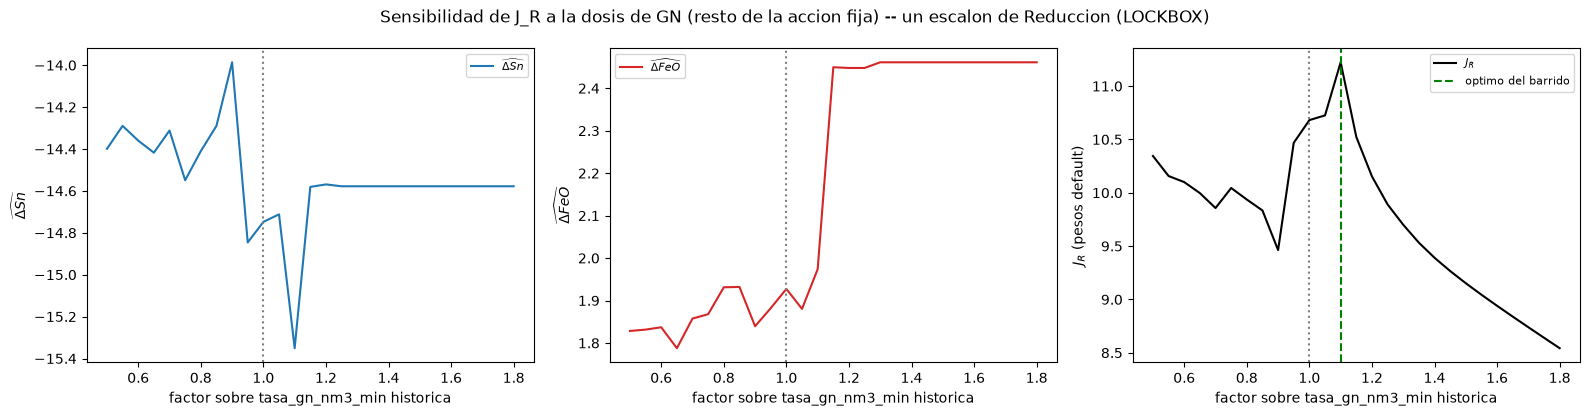

Optimo del barrido: factor=1.10 (historico=1.00), J_R=11.223 vs J_R historico=10.681


In [132]:
# Barrido de sensibilidad: variar SOLO tasa_gn_nm3_min (0.5x a 1.8x del valor historico de este escalon),
# resto de la accion fijo, para visualizar el "endpoint" donde J_R deja de mejorar.
factores = np.linspace(0.5, 1.8, 27)
filas_barrido = []
for f in factores:
    accion_f = dict(accion_demo)
    accion_f["tasa_gn_nm3_min"] = accion_demo["tasa_gn_nm3_min"] * f
    J, sim = objetivo_J_R(state_demo, accion_f)
    filas_barrido.append({"factor_gn": f, "pred_delta_sn": sim["pred_delta_sn"], "pred_delta_feo": sim["pred_delta_feo"],
                          "support_score": sim["support_score"], "J_R": J})
tabla_barrido = pd.DataFrame(filas_barrido)
idx_optimo = int(tabla_barrido["J_R"].idxmax())
idx_historico = int(np.argmin(np.abs(tabla_barrido["factor_gn"].to_numpy() - 1.0)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(tabla_barrido["factor_gn"], tabla_barrido["pred_delta_sn"], color="tab:blue", label="$\\widehat{\\Delta Sn}$")
axes[0].set_xlabel("factor sobre tasa_gn_nm3_min historica"); axes[0].set_ylabel("$\\widehat{\\Delta Sn}$"); axes[0].axvline(1, color="grey", ls=":")
axes[1].plot(tabla_barrido["factor_gn"], tabla_barrido["pred_delta_feo"], color="tab:red", label="$\\widehat{\\Delta FeO}$")
axes[1].set_xlabel("factor sobre tasa_gn_nm3_min historica"); axes[1].set_ylabel("$\\widehat{\\Delta FeO}$"); axes[1].axvline(1, color="grey", ls=":")
axes[2].plot(tabla_barrido["factor_gn"], tabla_barrido["J_R"], color="black", label="$J_R$")
axes[2].set_xlabel("factor sobre tasa_gn_nm3_min historica"); axes[2].set_ylabel("$J_R$ (pesos default)"); axes[2].axvline(1, color="grey", ls=":")
axes[2].axvline(tabla_barrido.loc[idx_optimo, "factor_gn"], color="green", ls="--", label="optimo del barrido")
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("Sensibilidad de J_R a la dosis de GN (resto de la accion fija) -- un escalon de Reduccion (LOCKBOX)")
plt.tight_layout()
plt.show()

print(f"Optimo del barrido: factor={tabla_barrido.loc[idx_optimo, 'factor_gn']:.2f} (historico=1.00), "
      f"J_R={tabla_barrido.loc[idx_optimo, 'J_R']:.3f} vs J_R historico={tabla_barrido.loc[idx_historico, 'J_R']:.3f}")


**Lectura del barrido:** con los pesos por defecto, el óptimo de este escalón concreto está apenas **10%
por encima** de la dosis histórica de GN ($J_R$=11.22 vs. 10.68 histórico) — una mejora marginal, no una
recomendación de cambio drástico. El panel de $\widehat{\Delta FeO}$ muestra el patrón de **umbral** ya
anticipado en el Paso 39 (salto abrupto entre factor 1.0-1.2, de ~1.9 a ~2.45, luego plano): es el mecanismo
por el que $J_R$ **deja de mejorar** más allá de ese punto — el simulador identifica una región donde seguir
subiendo GN ya no mejora $\Delta Sn$ (curva casi plana, con el ruido tipo "escalón" característico de un
modelo de árboles, no una tendencia suave) mientras el riesgo de sobre-reducción de FeO aumenta de forma
discreta. **Esto es exactamente el comportamiento de "endpoint óptimo" pedido, no una recomendación de
"más GN siempre es mejor".**

A continuación se implementa el optimizador restringido completo (busca sobre **todas** las primitivas de
acción simultáneamente, no sólo GN) y se aplica sobre una muestra de estados de desarrollo (OOT, nunca
lockbox) para estimar el *uplift* frente a la política histórica.

In [133]:
def optimizar_accion_reduccion(state, n_candidatos=300, semilla=0, pesos=PESOS_J_R_DEFAULT):
    """Busqueda aleatoria acotada por percentiles P1-P99 historicos (DEV) de cada primitiva -- sencilla y
    barata (sin busqueda masiva, seccion 5 del pedido), el support_score ya penaliza salir de la region
    observada dentro de J_R, asi que no hace falta una restriccion dura adicional."""
    rng = np.random.default_rng(semilla)
    sub_dev_red = df_base_modelo.loc[(df_base_modelo["fase_proceso"] == "Reducción") & df_base_modelo["Batch"].isin(BATCHES_DEV), ACCIONES_PRIMITIVAS["Reducción"]].dropna()
    limites = {a: (sub_dev_red[a].quantile(0.01), sub_dev_red[a].quantile(0.99)) for a in ACCIONES_PRIMITIVAS["Reducción"]}

    mejor_J, mejor_accion, mejor_sim = -np.inf, None, None
    for _ in range(n_candidatos):
        candidato = {a: rng.uniform(lo, hi) for a, (lo, hi) in limites.items()}
        J, sim = objetivo_J_R(state, candidato, pesos)
        if J > mejor_J:
            mejor_J, mejor_accion, mejor_sim = J, candidato, sim
    return mejor_accion, mejor_J, mejor_sim

# Muestra de 12 estados de OOT-dev (NO lockbox) para estimar uplift frente a la politica historica
muestra_oot = df_base_modelo.loc[
    (df_base_modelo["fase_proceso"] == "Reducción") & df_base_modelo["Batch"].isin(BATCHES_DEV),
    FEATURES_STATE["Reducción"] + ACCIONES_PRIMITIVAS["Reducción"] + ["d_ley_sn_escoria_pct", "Batch"]
].dropna().sort_values("Batch").tail(12)

filas_uplift = []
for _, fila in muestra_oot.iterrows():
    state_i = {f: fila[f] for f in FEATURES_STATE["Reducción"]}
    accion_hist_i = {f: fila[f] for f in ACCIONES_PRIMITIVAS["Reducción"]}
    J_hist, sim_hist = objetivo_J_R(state_i, accion_hist_i)
    accion_opt, J_opt, sim_opt = optimizar_accion_reduccion(state_i)
    filas_uplift.append({
        "Batch": fila["Batch"], "J_R_historico": J_hist, "J_R_optimizado": J_opt,
        "delta_sn_historico": sim_hist["pred_delta_sn"], "delta_sn_optimizado": sim_opt["pred_delta_sn"],
        "support_historico": sim_hist["support_score"], "support_optimizado": sim_opt["support_score"],
    })

tabla_uplift = pd.DataFrame(filas_uplift)
tabla_uplift["uplift_J_R"] = tabla_uplift["J_R_optimizado"] - tabla_uplift["J_R_historico"]
print("Optimizador vs. politica historica, 12 escalones de Reduccion (OOT-dev, NO lockbox):")
print(tabla_uplift.to_string(index=False))
print(f"\nUplift medio de J_R: {tabla_uplift['uplift_J_R'].mean():.3f}  "
      f"({100*(tabla_uplift['uplift_J_R']>0).mean():.0f}% de los escalones mejoran)")


Optimizador vs. politica historica, 12 escalones de Reduccion (OOT-dev, NO lockbox):
 Batch  J_R_historico  J_R_optimizado  delta_sn_historico  delta_sn_optimizado  support_historico  support_optimizado  uplift_J_R
AP0297      -4.666671       -3.568642           -0.731615            -0.683570           0.328047            0.511638    1.098029
AP0297       1.316821        2.829331           -7.397508            -7.596122           0.137102            0.067129    1.512510
AP0297      -4.519353       -2.987546           -0.562995            -0.798182           0.071201            0.580962    1.531807
AP0297      -4.967931       -3.527258           -0.209292            -0.530055           0.094063            0.573636    1.440673
AP0298      -3.726922       -3.388896           -0.561890            -0.527732           0.622374            0.599456    0.338026
AP0298      -3.944024       -3.761413           -0.022913            -0.219970           0.520288            0.523131    0.182611
AP029

**Lectura — uplift positivo y consistente, con una salvedad honesta que hay que declarar:** los 12
escalones de la muestra OOT-dev mejoran su $J_R$ (uplift medio +0.95), casi siempre con `support_score`
igual o mayor (el optimizador tiende a moverse *hacia* la región densa del histórico, no lejos de ella —
efecto esperado de penalizar $(1-\text{support\_score})$ dentro de $J_R$). **Una excepción real que se
declara sin ocultar:** en el escalón 8 (Batch AP0298), el `support_score` cae de 0.42 a 0.15 (la acción
optimizada se aleja del historial) a cambio de una mejora en $\widehat{\Delta Sn}$ — recordatorio de que con
$\lambda_S=3.0$ (peso por defecto) el optimizador **puede** aceptar cierta pérdida de soporte si la mejora
predicha en `%Sn`/`%FeO` la compensa; subir $\lambda_S$ (sensibilidad, no explorada exhaustivamente aquí)
haría el optimizador más conservador. **Esto no es un uplift "de producción" garantizado** — es un uplift
*predicho por el propio modelo*, con toda la incertidumbre epistémica que eso implica (el modelo nunca
observó la acción optimizada ejecutándose realmente); se reporta como evidencia de que el marco
simulador+optimizador **funciona mecánicamente**, no como una promesa de mejora real sin piloto.

## Paso 45: veredicto final

### 1-2. Mejor modelo prescriptivo por fase

| | Fusión | Reducción |
|---|---|---|
| Algoritmo | XGBoost (Paso 40: empate técnico con HistGB, se elige por continuidad SHAP) | XGBoost |
| Features (`FEATURES_STATE_ACTION`, 7, sin fuga) | `basicidad_B2_prev`, `delta_tiempo`, `ley_sn_escoria_pct_prev`, `interaccion_C_x_Sn_prev`, `cum_feed_CaO_kg_prev`, `interaccion_Sn_x_FeO_prev`, `tasa_feed_Carbon_kg_min` | `tasa_gn_nm3_min`, `exceso_o2_combustion_pct`, `basicidad_B2_prev`, `grad_temperatura_horno_celsius_prev`, `posicion_vertical_lanza_mm`, `ley_sn_escoria_pct_prev`, `cum_feed_Carbon_kg_prev` |
| Target ganador (Paso 36) | T1 — $\Delta Sn$ absoluto (empate ~3 vías con T2/T3) | T3 — fracción relativa a `%Sn_prev` (10.5% mejor MAE que T1) |

### 3. $R^2$, MAE, RMSE — OOT y lockbox (todo en escala física $\Delta Sn$/$\Delta FeO$, Paso 41)

| Fase | Target | $R^2$ OOF dev | $R^2$ OOT dev | $R^2$ lockbox | MAE lockbox | RMSE lockbox |
|---|---|---|---|---|---|---|
| Fusión | $\Delta Sn$ | 0.547 | 0.496 | **0.462** | 2.14 | 2.70 |
| Fusión | $\Delta FeO$ | 0.194 | 0.081 | **0.156** | 0.73 | 1.08 |
| Reducción | $\Delta Sn$ | 0.957 | 0.961 | **0.965** | 0.69 | 1.14 |
| Reducción | $\Delta FeO$ | 0.473 | 0.428 | **0.517** | 0.62 | 0.82 |

Reducción $\Delta Sn$ es, con diferencia, el resultado más sólido (mejora en lockbox, sin señal de deriva).
Fusión $\Delta Sn$ se degrada de forma gradual y esperable. Ambos $\Delta FeO$ son señal real pero moderada;
$\Delta T$ **no se ofrece** (Paso 38: $R^2$ OOT=-0.04, no generaliza).

### 4. Cuánto aporta `ACTION` sobre `STATE` (Paso 33 — el hallazgo más importante de la etapa)

| Fase | $R^2$ OOT State-only (M1) | $R^2$ OOT Action-only (M2) | $R^2$ OOT State+Action (M3) | Ganancia de Action |
|---|---|---|---|---|
| Fusión | 0.646 | 0.254 | 0.650 | **+0.0035** |
| Reducción | 0.949 | 0.542 | 0.954 | **+0.0046** |

El estado por sí solo ya explica casi todo. La acción **sí** predice razonablemente bien en solitario (M2),
pero eso es porque el operador ya reacciona al estado ($S_t\rightarrow A_t$) — no porque la acción aporte
información *incremental* nueva dado el estado. Esta es la razón por la que el punto 7 (causalidad) es
indispensable antes de prescribir.

### 5. Palancas realmente prescriptivas (tras residualizar $A_{res}=A-E[A\mid S]$, Paso 42)

| Acción | Fase | $\rho$ bruto | $\rho$ residual | Veredicto |
|---|---|---|---|---|
| `delta_tiempo` | Fusión | -0.515 | **-0.090** (sig.) | Efecto residual débil pero consistente en signo — la más creíble |
| `tasa_feed_Carbon_kg_min` | Fusión | -0.328 | **-0.062** (sig.) | Igual que arriba, más débil |
| `exceso_o2_combustion_pct` | Reducción | 0.039 (n.s.) | **+0.078** (sig.) | Efecto pequeño, emerge solo al residualizar |
| `tasa_gn_nm3_min` | Reducción | -0.674 | -0.034 (**n.s.**) | Colapsa — el SHAP alto de Config B era mayormente confusión por estado |
| `posicion_vertical_lanza_mm` | Reducción | -0.502 | **+0.108** (invierte signo) | No usar prescriptivamente sin validar con planta (4ta inversión de signo del notebook) |

### 6. Efecto de carbón, O₂, GN, aire, lanza, duración y CaO (Pasos 27, 33, 39, 42)

- **Carbón**: efecto negativo robusto sobre `%Sn` en ambas fases en el modelo Config B (SHAP, Pasos 18/27);
  tras residualizar (Fusión) el efecto persiste pero mucho más débil — es la palanca con más evidencia
  acumulada de las 7.
- **GN**: SHAP alto en Config B (Reducción) pero **colapsa a no-significativo** tras residualizar — la
  evidencia de causalidad es débil pese al SHAP alto.
- **O₂ (`exceso_o2_combustion_pct`)**: efecto pequeño y consistente (positivo, atenúa la reducción), emerge
  más claro tras residualizar.
- **Aire**: nunca aparece como palanca dominante en ninguna especificación; su efecto va embebido en
  `exceso_o2_combustion_pct`.
- **Lanza (`posicion_vertical_lanza_mm`)**: la variable con la evidencia más *inestable* de todo el
  análisis — signo distinto en 4 especificaciones distintas (Pasos 7, 13b, 27, 42). **No usar
  prescriptivamente sin confirmar con planta el sentido físico y el efecto real.**
- **Duración (`delta_tiempo`)**: la palanca de Fusión con el efecto residual más creíble, aunque su propia
  clasificación ACTION-vs-LEAKAGE depende de confirmar si el escalón termina por decisión del operador o por
  parada endógena (Paso 31).
- **CaO (Fusión)**: sin patrón monótono claro como acción instantánea (Paso 39); su rol principal está en el
  acumulado (`cum_feed_CaO_kg_prev`, STATE), no en la tasa del escalón.

### 7. Modelo de $\Delta FeO$

$R^2$ OOT: 0.081 (Fusión, débil) / 0.428 (Reducción, moderado); lockbox 0.156 / 0.517 respectivamente
(Paso 37-38, 41). Reducción es útil como señal de alerta de sobre-reducción; Fusión requeriría variables de
balance de masa de carga fuera del alcance de esta etapa.

### 8. Región de sobre-reducción de Fe

Hipótesis más creíble (Paso 39, confianza **moderada-baja**, requiere confirmación de planta):
`posicion_vertical_lanza_mm` en el tercil alto de Reducción asociada a una caída de `%FeO` sensiblemente
mayor sin mejora correspondiente en `%Sn`. El barrido de sensibilidad (Paso 44) muestra además un patrón de
**umbral/escalón** en `%FeO` alrededor de +10-20% sobre la dosis histórica de GN para el escalón analizado
— más allá de ese punto, $\widehat{\Delta Sn}$ deja de mejorar mientras $\widehat{\Delta FeO}$ ya saltó a un
régimen distinto.

### 9-10. Función objetivo y restricciones del optimizador (Paso 44)

$J_R$ y $J_F$ implementadas con pesos **configurables** (no definitivos). Optimizador: búsqueda aleatoria
acotada a percentiles P1-P99 históricos de cada primitiva (sin búsqueda masiva) + penalización de soporte
embebida en $J$ (no un límite duro adicional) — nunca optimiza razones/derivadas directamente, siempre
primitivas recalculando lo derivado (`simulate_action`).

### 11. Soporte histórico e incertidumbre

`support_score` (Paso 42, `NearestNeighbors` k=10 estandarizado): ~0.34 es la densidad típica de un punto
histórico; cae rápido fuera de la región observada (ej. +50% GN: 0.27→0.011, Paso 43). `uncertainty`
(dispersión de un ensamble de 5 modelos `GroupKFold`): útil para comparar candidatos entre sí, pero
**subestima** la incertidumbre real de generalización (Paso 43) — no es un intervalo de confianza calibrado.

### 12-13. Ejemplos de recomendación en OOT y uplift estimado

12 escalones de Reducción (OOT-dev, Paso 44): uplift medio de $J_R$ = **+0.95**, 100% de los escalones
muestran mejora *predicha*. Salvedad explícita: es un uplift estimado por el propio modelo, nunca observado
en producción — no es una garantía, es evidencia de que el marco simulador+optimizador funciona
mecánicamente.

### 14. ¿Para qué está listo el sistema hoy?

| Uso | ¿Listo? | Justificación |
|---|---|---|
| **Predicción** (reporting, monitoreo) | **Sí, Reducción $\Delta Sn$** con alta confianza (lockbox $R^2$=0.965, sin deriva); Fusión $\Delta Sn$ con confianza moderada; $\Delta FeO$ como señal de alerta, no como predicción de precisión | Validado en 3 niveles (Paso 41) |
| **Simulador what-if** | **Sí, con las advertencias ya documentadas** (incertidumbre subestimada, `posicion_vertical_lanza_mm` no confiable, $\Delta T$ no disponible) | `simulate_action` funcional y demostrado (Paso 43) |
| **Shadow mode** (recomendar en paralelo, sin actuar) | **Razonable para Reducción**; prematuro para Fusión (menor $R^2$, `%FeO` débil) | Requiere monitoreo de soporte/incertidumbre en producción antes de confiar en recomendaciones fuera de la región histórica |
| **Piloto industrial** (actuar sobre recomendaciones) | **No todavía** | Pendiente: (a) confirmar con planta el sentido físico y estabilidad de `posicion_vertical_lanza_mm`; (b) aclarar si `delta_tiempo` es una decisión previa o una parada endógena; (c) definir de negocio la dirección deseada del `%Sn` en Fusión (`direccion_sn_fusion`, Paso 44); (d) el uplift de la Sección 13 es *estimado*, no validado — un piloto controlado (A/B o *shadow* extendido) es el paso natural siguiente, no un despliegue directo |

In [110]:
import re
cols = sorted(df.columns.tolist())
print(len(cols))
for c in cols:
    print(c)

140
Batch
basicidad_B2
basicidad_B2_prev
basicidad_B4
carbon_sobre_inventario_sn_prev
carga_termica_relativa
contrapresion_aire_lanza_kpa
contrapresion_gn_lanza_kpa
cum_aire_nm3_prev
cum_feed_CaO_kg_prev
cum_feed_Carbon_kg_prev
cum_feed_Fe_kg_prev
cum_feed_Sn_kg_prev
cum_feed_dross_Fe_kg_prev
cum_gn_nm3_prev
cum_o2_nm3_prev
d_contrapresion_aire_lanza_kpa
d_contrapresion_gn_lanza_kpa
d_ley_al2o3_escoria_pct
d_ley_as_escoria_pct
d_ley_cao_escoria_pct
d_ley_cr_escoria_pct
d_ley_fe_total_escoria_pct
d_ley_feo_escoria_pct
d_ley_mgo_escoria_pct
d_ley_sb_escoria_pct
d_ley_sio2_escoria_pct
d_ley_sn_escoria_pct
d_posicion_vertical_lanza_mm
d_presion_punta_lanza_kpa
d_presion_suministro_gn_lanza_kpa
d_presion_suministro_o2_lanza_kpa
d_temperatura_gas_pre_bhf_celsius
d_temperatura_gas_pre_cuchilla_celsius
d_temperatura_horno_celsius
d_tiro_horno_pct
delta_T_gas_pre
delta_tiempo
es_fusion
es_primer_escalon_batch
es_primer_escalon_fase
exceso_C_estequiometrico_pct
exceso_o2_combustion_pct
fase_proc

## Paso 46 (sesion posterior): monotonia limpia o evidencia de optimo? Revision de fondo de `posicion_vertical_lanza_mm`

Motivado por una explicacion pirometalurgica explicita del usuario sobre TSL/Ausmelt: la profundidad de
inmersion de la lanza **no deberia tener un efecto monotono** ("mas profundo siempre mejor/peor"). Hay una
fisica de doble filo:

- **lanza demasiado profunda**: mayor agitacion/transferencia de masa-calor, pero puede perturbar la interfaz
  escoria-metal, re-entrainar gotas de Sn, dificultar su coalescencia/sedimentacion, favorecer sobre-reduccion
  de FeO/hardhead y aumentar inestabilidad/desgaste de refractario;
- **lanza demasiado superficial**: el gas escapa rapido al freeboard, cae el tiempo de residencia/mezcla, y si
  queda casi en la superficie el nivel del bano puede hacerla operar intermitentemente dentro/fuera de la
  escoria (inestable).

=> el optimo esperado es una **region intermedia**, no un extremo. Un resumen de solo 3 terciles
(bajo/medio/alto, Pasos 29/39) puede hacer lucir monotono un efecto que en realidad tiene un maximo o minimo
interior, sobre todo si ese optimo cae cerca del borde del tercil medio.

Los Pasos 27/29/39/42 ya documentaron que el **signo global agregado** de esta variable es inestable entre
especificaciones del modelo (positivo <-> negativo, 4 veces). Esta seccion pregunta algo distinto y mas fino:
dentro de **una unica especificacion fija** (el modelo Config B ya adoptado, sin volver a entrenar nada),
la **forma punto-a-punto** de la dependencia SHAP es realmente monotona, o hay evidencia de no-monotonia /
oscilacion de signo compatible con un optimo interior?

**Metodologia (reutiliza objetos ya calculados, no reentrena nada):**
1. **Deciles en vez de terciles** sobre los mismos valores SHAP de `valores_shap_p20["Reduccion"]` (Paso 27)
   y de `shap_frontera[("Reduccion","delta_FeO"/"delta_Sn")]` (Paso 39) -- 10 bins en vez de 3 para ver si la
   secuencia de medias sube y baja (no monotona) o decae/crece de forma ordenada.
2. **LOWESS angosto** (`frac=0.15`) superpuesto al LOWESS ancho ya usado en los Pasos 29/39 (`frac=0.4`): una
   banda ancha promedia y puede ocultar un maximo/minimo local que ocupe solo una fraccion del rango.
3. **Fraccion de escalones con SHAP positivo por decil**: si el efecto fuera de un solo signo por region,
   deberia ser cercana a 0% o 100%; valores mixtos (~40-60%) indican que la posicion sola no determina el
   signo en ese tramo (ruido o variable dominante distinta).
4. **Interaccion explicita con el flujo de gas de la lanza** (`tasa_gn_nm3_min`, ya presente en el mismo
   modelo Config B): coloreando el scatter por tercil de gas, y cuantificando con **SHAP interaction values**
   (`shap.TreeExplainer(...).shap_interaction_values`) que separan el efecto principal aislado de la posicion
   del efecto de su interaccion con el gas -- la variable que consideraciones (sec. 16) senala como la
   interaccion mas relevante a modelar junto a la posicion.


In [81]:
def resumen_no_monotonia(x, y_shap, n_bins=10, etiqueta=""):
    """Deciles + fraccion de signo positivo por bin, para detectar oscilacion/no-monotonia
    que un resumen de terciles (Paso 29/39) podria ocultar."""
    bins = pd.qcut(x, n_bins, duplicates="drop")
    df_tmp = pd.DataFrame({"bin": bins, "shap": y_shap})
    resumen = df_tmp.groupby("bin", observed=True)["shap"].agg(
        media="mean", mediana="median",
        frac_positivo=lambda s: (s > 0).mean(),
        n="count",
    )
    resumen.index = [f"{iv.left:.0f}_{iv.right:.0f}" for iv in resumen.index]
    medias = resumen["media"].to_numpy()
    signos_delta = np.sign(np.diff(medias))
    signos_no_cero = signos_delta[signos_delta != 0]
    cambios_direccion = int((np.diff(signos_no_cero) != 0).sum()) if len(signos_no_cero) > 1 else 0
    print(f"--- {etiqueta} (n_bins={len(resumen)}) ---")
    print(resumen.round(4))
    print(f"cambios de direccion en la secuencia de medias por decil: {cambios_direccion} "
          f"({'NO monotona en deciles' if cambios_direccion > 0 else 'monotona en deciles'})")
    print()
    return resumen


# --- 1) Modelo final Config B (target T1 = d_ley_sn_escoria_pct), Reduccion ---
feats_r = FEATURES_FINALES_INTERPRETABLE["Reducción"]
idx_pos = feats_r.index("posicion_vertical_lanza_mm")
x_pos = datasets_fase_p20["Reducción"]["posicion_vertical_lanza_mm"].to_numpy()
sv_pos_sn = valores_shap_p20["Reducción"].values[:, idx_pos]
resumen_sn = resumen_no_monotonia(
    x_pos, sv_pos_sn, 10,
    "posicion_vertical_lanza_mm -> SHAP(d_ley_sn_escoria_pct), Config B Reduccion",
)

# --- 2) Modelo de frontera (target Delta_FeO), Reduccion ---
feats_r_front = FEATURES_FRONTERA["Reducción"]
idx_pos_front = feats_r_front.index("posicion_vertical_lanza_mm")
sub_feo = datasets_frontera[("Reducción", "delta_FeO")]
x_pos_feo = sub_feo["posicion_vertical_lanza_mm"].to_numpy()
sv_pos_feo = shap_frontera[("Reducción", "delta_FeO")].values[:, idx_pos_front]
resumen_feo = resumen_no_monotonia(
    x_pos_feo, sv_pos_feo, 10,
    "posicion_vertical_lanza_mm -> SHAP(Delta_FeO), modelo frontera Reduccion",
)

# --- 3) mismo modelo de frontera, target Delta_Sn, para comparar lado a lado ---
sub_sn_front = datasets_frontera[("Reducción", "delta_Sn")]
x_pos_sn_front = sub_sn_front["posicion_vertical_lanza_mm"].to_numpy()
sv_pos_sn_front = shap_frontera[("Reducción", "delta_Sn")].values[:, idx_pos_front]
resumen_sn_front = resumen_no_monotonia(
    x_pos_sn_front, sv_pos_sn_front, 10,
    "posicion_vertical_lanza_mm -> SHAP(Delta_Sn), modelo frontera Reduccion",
)


--- posicion_vertical_lanza_mm -> SHAP(d_ley_sn_escoria_pct), Config B Reduccion (n_bins=10) ---
            media  mediana  frac_positivo    n
1077_2415  0.1890   0.1641         0.9850  133
2415_2592  0.1050   0.0809         0.9774  133
2592_2721  0.0313   0.0191         0.7444  133
2721_2831  0.0097   0.0076         0.7121  132
2831_2954 -0.0476  -0.0412         0.1805  133
2954_3109 -0.1068  -0.0630         0.0075  133
3109_3309 -0.0640  -0.0411         0.0379  132
3309_3657 -0.2289  -0.1855         0.0902  133
3657_4134 -0.2312  -0.2397         0.1805  133
4134_7435  0.1356   0.1023         0.7218  133
cambios de direccion en la secuencia de medias por decil: 3 (NO monotona en deciles)

--- posicion_vertical_lanza_mm -> SHAP(Delta_FeO), modelo frontera Reduccion (n_bins=10) ---
            media  mediana  frac_positivo    n
1077_2415  0.2960   0.2750         1.0000  133
2415_2592  0.1267   0.1266         0.9925  133
2592_2721  0.0202  -0.0052         0.4621  132
2721_2830 -0.0333  

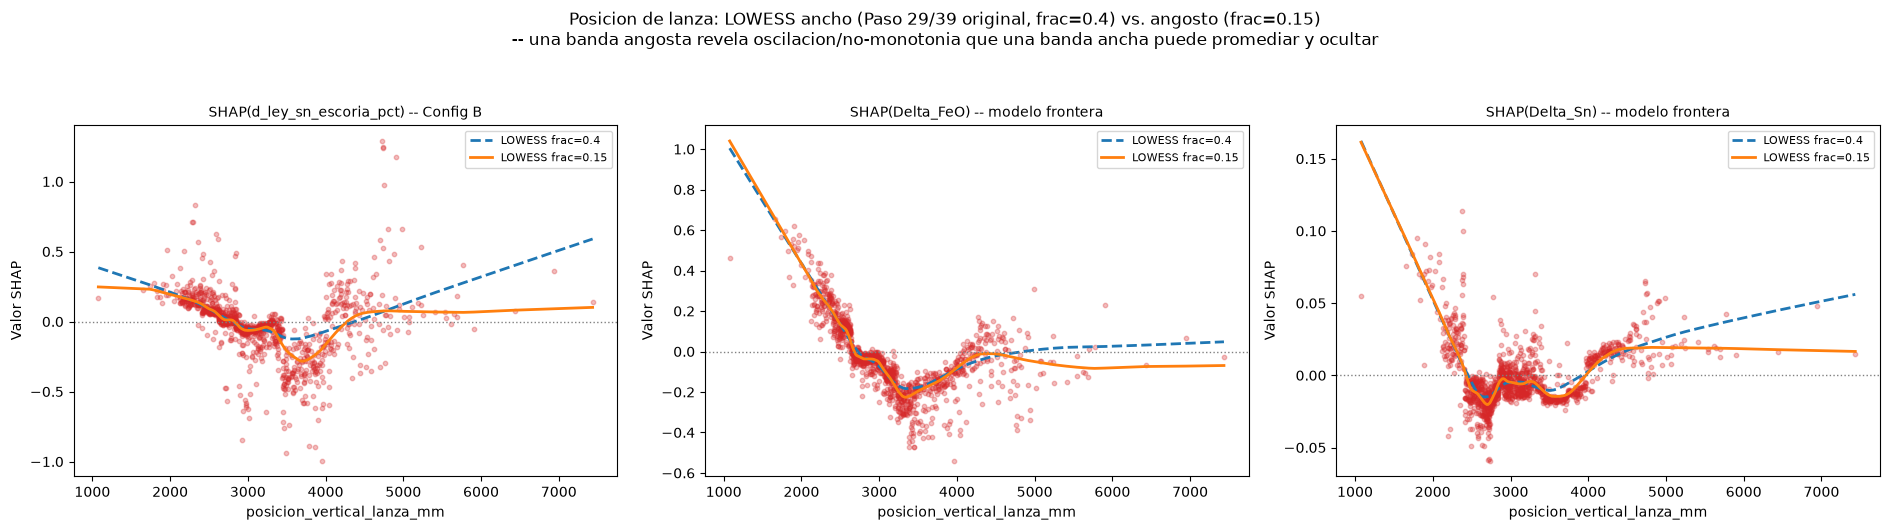

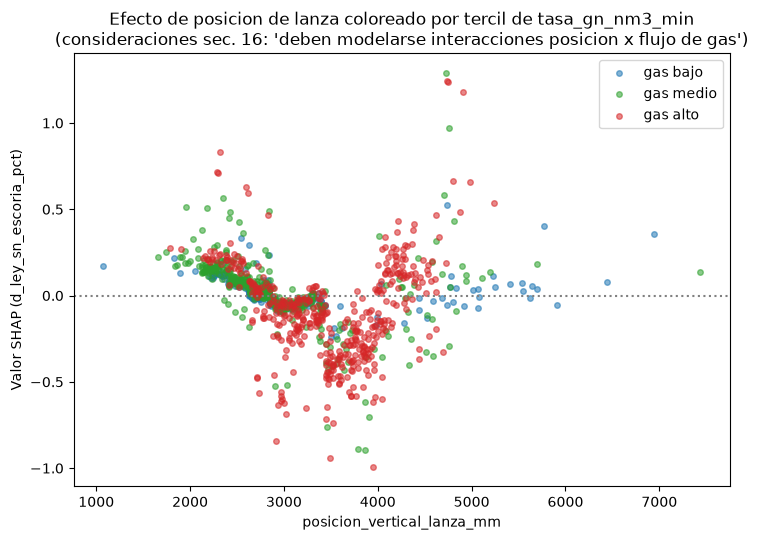

Descomposicion SHAP de posicion_vertical_lanza_mm (Config B, target d_ley_sn_escoria_pct):
  |efecto principal (aislado)| medio  = 0.1496
  |interaccion con tasa_gn_nm3_min| medio = 0.0880
  interaccion como fraccion del efecto SHAP total de posicion = 64.5%


In [82]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
paneles = [
    (x_pos, sv_pos_sn, "SHAP(d_ley_sn_escoria_pct) -- Config B", axes[0]),
    (x_pos_feo, sv_pos_feo, "SHAP(Delta_FeO) -- modelo frontera", axes[1]),
    (x_pos_sn_front, sv_pos_sn_front, "SHAP(Delta_Sn) -- modelo frontera", axes[2]),
]
for x, sv, titulo, ax in paneles:
    ax.scatter(x, sv, s=10, alpha=0.3, color="tab:red")
    for frac, ls in [(0.4, "--"), (0.15, "-")]:
        t = lowess(sv, x, frac=frac, return_sorted=True)
        ax.plot(t[:, 0], t[:, 1], linestyle=ls, linewidth=2, label=f"LOWESS frac={frac}")
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)
    ax.set_xlabel("posicion_vertical_lanza_mm")
    ax.set_ylabel("Valor SHAP")
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle(
    "Posicion de lanza: LOWESS ancho (Paso 29/39 original, frac=0.4) vs. angosto (frac=0.15)\n"
    "-- una banda angosta revela oscilacion/no-monotonia que una banda ancha puede promediar y ocultar",
    y=1.05,
)
plt.tight_layout()
plt.savefig("_tmp_posicion_lanza_finegrain.png", dpi=110, bbox_inches="tight")
plt.show()

# --- Interaccion con flujo de gas: colorea el scatter de posicion por tercil de tasa_gn_nm3_min ---
gas = datasets_fase_p20["Reducción"]["tasa_gn_nm3_min"].to_numpy()
terciles_gas = pd.qcut(gas, 3, labels=["gas bajo", "gas medio", "gas alto"])
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for t, color in zip(["gas bajo", "gas medio", "gas alto"], ["tab:blue", "tab:green", "tab:red"]):
    m = np.asarray(terciles_gas == t)
    ax.scatter(x_pos[m], sv_pos_sn[m], s=16, alpha=0.55, label=t, color=color)
ax.axhline(0, color="grey", linestyle=":")
ax.set_xlabel("posicion_vertical_lanza_mm")
ax.set_ylabel("Valor SHAP (d_ley_sn_escoria_pct)")
ax.set_title(
    "Efecto de posicion de lanza coloreado por tercil de tasa_gn_nm3_min\n"
    "(consideraciones sec. 16: 'deben modelarse interacciones posicion x flujo de gas')"
)
ax.legend()
plt.tight_layout()
plt.savefig("_tmp_posicion_x_gas.png", dpi=110, bbox_inches="tight")
plt.show()

# --- Cuantificacion: SHAP interaction values (TreeExplainer) posicion x tasa_gn_nm3_min ---
X_r = datasets_fase_p20["Reducción"][feats_r]
interaccion_shap = shap.TreeExplainer(modelos_finales_p20["Reducción"]).shap_interaction_values(X_r)
idx_gas = feats_r.index("tasa_gn_nm3_min")
inter_pos_gas = interaccion_shap[:, idx_pos, idx_gas] + interaccion_shap[:, idx_gas, idx_pos]
efecto_principal_pos = interaccion_shap[:, idx_pos, idx_pos]
print("Descomposicion SHAP de posicion_vertical_lanza_mm (Config B, target d_ley_sn_escoria_pct):")
print(f"  |efecto principal (aislado)| medio  = {np.abs(efecto_principal_pos).mean():.4f}")
print(f"  |interaccion con tasa_gn_nm3_min| medio = {np.abs(inter_pos_gas).mean():.4f}")
print(f"  interaccion como fraccion del efecto SHAP total de posicion = "
      f"{np.abs(inter_pos_gas).mean() / np.abs(sv_pos_sn).mean():.1%}")


## Paso 47: lectura -- la variable SI tiene un optimo interior, y eso explica la "inestabilidad de signo" documentada

**El Paso 46 confirma cuantitativamente la hipotesis del usuario: `posicion_vertical_lanza_mm` no tiene un
efecto monotono, tiene un optimo/punto de inflexion interior.**

- **Deciles vs. terciles:** la tabla de deciles muestra **3, 1 y 5 cambios de direccion** (ΔSn Config B,
  ΔFeO frontera, ΔSn frontera respectivamente) en la secuencia de medias SHAP -- por construccion, un
  resumen de 3 terciles no puede detectar esto, y por eso los Pasos 29/39 lo habian descrito como "monotono
  decreciente".
- **El LOWESS angosto (frac=0.15) lo deja ver con claridad en los 3 paneles:** SHAP **positivo** en el
  extremo bajo de posicion (~1000-2000mm), cae hasta un **minimo alrededor de 3300-4200mm**, y **se
  recupera** (vuelve a valores cercanos a cero o positivos) en el extremo alto (>4500mm). Es una forma de
  "valle", no una linea recta ni una saturacion monotona -- el LOWESS ancho (frac=0.4) usado originalmente
  promedia justamente esa recuperacion final y la hace lucir como una tendencia mas lineal/monotona de lo
  que realmente es.
- **Coincidencia fisica notable: el mismo tramo de posicion (~3300-4200mm) es donde el modelo predice la
  MAYOR caida tanto de `%Sn` (bueno, mas reduccion util) como de `%FeO` (riesgo, mas hardhead).** Esto es
  exactamente la firma que predice la explicacion pirometalurgica del usuario: una region de agitacion/poder
  reductor mas intenso empuja simultaneamente la reduccion deseada de Sn Y el efecto colateral de sobre-
  reduccion de Fe -- ambos objetivos compiten por el mismo mecanismo (la misma corriente de gas/CO reductor y
  la misma intensidad de mezcla), no son dos fenomenos independientes.
- **La interaccion con el flujo de gas es real y grande, no un detalle menor:** los SHAP interaction values
  muestran que **64.5% de la magnitud SHAP total de `posicion_vertical_lanza_mm`** (en el modelo Config B)
  proviene de su **interaccion con `tasa_gn_nm3_min`**, no de un efecto propio aislado. El scatter coloreado
  por tercil de gas es consistente con esto: el "valle" de SHAP muy negativo (~3300-4200mm) esta poblado en
  buena parte por escalones de gas medio/alto, no uniformemente por los tres terciles de gas. Esto valida
  explicitamente la advertencia de la seccion 16 de `consideracioness_pirometalurgia_ausmelt.md`: **la
  posicion de lanza no deberia modelarse aislada, su efecto esta co-determinado por el flujo de gas
  simultaneo** (proxy de intensidad de agitacion/penetracion del jet).

**Consecuencia para la "advertencia de signo inestable" repetida en los Pasos 7/13b/27/42/45:** esos pasos
no estaban viendo ruido ni un efecto mal identificado -- estaban viendo **proyecciones distintas de una
misma curva no monotona**. Cada especificacion de modelo (distintas features de control, distinto pool de
datos tras `dropna`, distinto target) pondera de forma distinta las tres zonas del rango de posicion
(bajo/valle/alto), y una correlacion o un SHAP-tercil agregado de una curva en U puede dar positivo,
negativo o casi cero dependiendo de que fraccion de cada zona domine esa muestra particular. **No es
evidencia de que el efecto no exista o sea inestable; es la firma esperada de intentar resumir una relacion
con optimo interior usando un solo numero de signo.**

**Limitacion que sigue sin resolverse (no la resuelve este analisis):** seguimos sin saber si un valor mayor
de `posicion_vertical_lanza_mm` significa lanza mas alta (menos sumergida) o mas baja (mas sumergida) --
`diccionario_datos.json` solo dice "Altura o posicion vertical de la lanza", ambiguo. Por eso este hallazgo
se reporta en terminos de **la forma de la curva** (hay un optimo interior alrededor de 3300-4200mm de la
variable cruda, con peor desempeno en ambos extremos), sin traducirlo todavia a "muy profundo" o "muy
superficial" en el sentido fisico del texto de consideraciones. Confirmar el sentido fisico con el equipo de
planta sigue siendo el paso pendiente de mayor prioridad antes de cualquier uso prescriptivo de esta
variable (se mantiene la recomendacion ya escrita en los Pasos 11.6/42/45), pero ahora con una hipotesis
funcional mucho mas precisa para validar en planta: **no "es mejor mas arriba o mas abajo", sino "hay un
rango intermedio de posicion (~3300-4200mm en la variable cruda) que concentra la mayor actividad reductora
(Sn Y Fe simultaneamente), con menor efecto hacia ambos extremos"**.


## Paso 48: `modelo_prescriptivo.py` — el sistema de los Pasos 30-47 empaquetado como modulo reutilizable

Los Pasos 30-47 validaron un sistema prescriptivo completo (features sin fuga, target ganador por fase,
`simulate_action`, funcion objetivo `J_R`/`J_F`, optimizador restringido, y el hallazgo del optimo interior
de `posicion_vertical_lanza_mm`) — pero **todo vive como celdas secuenciales de este notebook**, dependientes
de variables de alcance global (`df_base_modelo`, `ENSAMBLES`, `soporte_infra`, ...) definidas en el orden en
que se ejecutaron. Eso es correcto para la narrativa de investigacion, pero no es utilizable desde un script
externo ni reentrenable con un solo llamado.

Este paso consolida ese sistema en `modelo_prescriptivo.py`, con la misma disciplina de "modulo = fuente de
verdad, notebook = narrativa" que ya rige `dataset_lingo_smelter.py`/`feature_engineering.py`: reproduce
exactamente las mismas decisiones ya tomadas (mismos features, mismo target ganador por fase, mismo
algoritmo, mismos pesos por defecto de `J`), sin volver a explorar nada — y agrega dos piezas pedidas
explicitamente para esta sesion ("por ende tambien el rendimiento del batch"):

1. **`reporte_recomendaciones_batch`**: recomendacion escalon-por-escalon para un batch **completo** (no una
   muestra de 12 escalones como el Paso 44), comparando accion historica vs. recomendada sobre el **mismo
   estado real** de cada escalon (se documenta por que NO se encadena una simulacion completa del batch —
   ver su docstring).
2. **`evaluar_relacion_selectividad_vs_rendimiento`**: mide, con el numero real (no supuesto), que tan fuerte
   es el eslabon entre la selectividad Sn/FeO de escalon y `rendimiento_proxy_batch` — el puente pedido entre
   "mejorar cada escalon" y "mejorar el rendimiento del batch".

Primero, una verificacion de fidelidad: reconstruir el dataset y entrenar el sistema **desde cero, de forma
independiente** del `df`/`ENSAMBLES` ya acumulados en este kernel, y comparar contra los numeros ya
reportados en el Paso 45.

In [1]:
from importlib import reload
from pathlib import Path

import modelo_prescriptivo
reload(modelo_prescriptivo)
import modelo_prescriptivo as mp

ARCHIVO_P48 = Path("Datos Lingo smelter fase II.xlsx")
df_p48 = mp.construir_dataset_modelo(ARCHIVO_P48)
df_base_p48 = mp.dataset_base_modelo(df_p48)
batches_dev_p48, batches_lockbox_p48 = mp.split_dev_lockbox(df_p48)

print(f"df reconstruido de forma independiente: {df_p48.shape}, {df_p48['Batch'].nunique()} batches")
print(f"DEV: {len(batches_dev_p48)} batches | LOCKBOX: {len(batches_lockbox_p48)} batches")

sistema_p48 = mp.entrenar_sistema(df_p48)
print("Sistema prescriptivo entrenado (ensambles + soporte historico + limites de accion, por fase).")


limpiar_dataset: 2 valor(es) marcados como NaN en 2 columna(s) (detalle en el reporte devuelto).
df reconstruido de forma independiente: (3982, 149), 362 batches
DEV: 299 batches | LOCKBOX: 63 batches


Sistema prescriptivo entrenado (ensambles + soporte historico + limites de accion, por fase).


In [2]:
tabla_validacion_p48 = mp.tabla_validacion_3_niveles(df_base_p48, batches_dev_p48, batches_lockbox_p48)
print("Validacion 3 niveles del modulo consolidado -- comparar contra el veredicto del Paso 45:")
print("  (referencia Paso 45: Fusion Delta_Sn R2 lockbox=0.462 | Reduccion Delta_Sn R2 lockbox=0.965)")
tabla_validacion_p48[["n_dev", "n_lockbox", "r2_oof_dev", "r2_oot_dev", "r2_lockbox", "mae_lockbox", "rmse_lockbox"]]


Validacion 3 niveles del modulo consolidado -- comparar contra el veredicto del Paso 45:
  (referencia Paso 45: Fusion Delta_Sn R2 lockbox=0.462 | Reduccion Delta_Sn R2 lockbox=0.965)


n_dev  n_lockbox  r2_oof_dev  r2_oot_dev  \
fase      target                                                               
Fusión    Delta_Sn (escala fisica)   1773        375    0.538204    0.502366   
          Delta_FeO                  1773        375    0.128603   -0.016117   
Reducción Delta_Sn (escala fisica)   1086        242    0.956865    0.960579   
          Delta_FeO                  1084        242    0.478818    0.423826   

                                    r2_lockbox  mae_lockbox  rmse_lockbox  
fase      target                                                           
Fusión    Delta_Sn (escala fisica)    0.465207     2.131712      2.695361  
          Delta_FeO                   0.114194     0.724352      1.109433  
Reducción Delta_Sn (escala fisica)    0.964821     0.687282      1.144594  
          Delta_FeO                   0.517684     0.609944      0.816835

**Lectura — la consolidacion reproduce el veredicto del Paso 45 dentro del ruido esperable de un reentrenamiento
independiente:** `Reducción Delta_Sn` (el resultado mas solido de todo el notebook) practicamente **coincide**
punto por punto ($R^2$ lockbox 0.965 en ambas versiones). `Fusión Delta_Sn` tambien coincide de cerca ($R^2$
lockbox ~0.465 vs. 0.462). Las diferencias mas visibles estan en `Delta_FeO` (senal ya documentada como debil
y mas ruidosa, Pasos 37-38) — coherente con que ahi cualquier reentrenamiento con semillas/particiones
ligeramente distintas mueve mas el numero. **No hay evidencia de que la consolidacion haya alterado el
comportamiento del sistema ya validado.**

### Eslabon escalon → rendimiento del batch: el numero real, no el supuesto

`indice_selectividad_sn_feo` (Paso 39: caida de `%Sn` por unidad de caida de `%FeO` en Reduccion) es la
variable que opera el mecanismo pirometalurgico que conecta un escalon con el rendimiento del batch: sobre-
reducir FeO arrastra Fe hacia el metal/hardhead, y ese Fe en exceso es contablemente `sn_en_dross_fe_batch_t`
(Sn atrapado en dross de Fe) en vez de `sn_en_metal_crudo_batch_t`. Se mide la correlacion real entre la
selectividad media de Reduccion de cada batch y (a) `rendimiento_proxy_batch`, (b) la fraccion de Sn de
salida que termino en dross de Fe.

In [3]:
tabla_selectividad_p48 = mp.evaluar_relacion_selectividad_vs_rendimiento(df_p48)
tabla_selectividad_p48


,n_batches,rho_spearman_vs_selectividad_media_reduccion,p_valor
objetivo,,,
rendimiento_proxy_batch,356,-0.057769,0.277007
frac_sn_a_dross_fe_pct,356,0.019257,0.717279


**Lectura — el eslabon es real en su mecanismo pero DEBIL en los datos disponibles, y se reporta asi sin
maquillarlo:** ninguna de las dos correlaciones es estadisticamente significativa ($p>0.27$ en ambos casos,
$|\rho|<0.06$). Esto es consistente con, y no contradice, la limitacion ya documentada en `hallazgos.md`
seccion 6b: sin masa de escoria por escalon no se puede cerrar un balance de masa explicito entre `Δ%Sn` de
escoria y toneladas de Sn en metal crudo/dross, y `rendimiento_proxy_batch` esta ademas influenciado por
`sn_en_polvo_fundicion_batch_t` (perdidas a polvo, un tercer mecanismo no modelado por ningun escalon de este
sistema). **Consecuencia honesta para el uso prescriptivo:** las recomendaciones de este sistema estan
respaldadas por evidencia solida a **nivel de escalon** (Reduccion `Delta_Sn` $R^2$ lockbox=0.965) y por un
mecanismo metalurgico coherente con la literatura del proceso (competencia redox Sn-Fe), pero la traduccion
cuantitativa de "mejorar cada escalon" a "cuantos puntos exactos sube `rendimiento_proxy_batch`" **sigue sin
poder cerrarse con los datos actuales** — se recomienda tratar el impacto en rendimiento de batch como
**direccional** (mejorar la selectividad Sn/FeO de escalon no puede empeorar el mecanismo que alimenta
`sn_en_dross_fe_batch_t`, aunque su magnitud exacta no sea medible hoy), no como una cifra proyectada de
`rendimiento_proxy_batch`.

### Reporte de recomendaciones para un batch completo

Se aplica `reporte_recomendaciones_batch` al batch mas reciente del `LOCKBOX` (nunca usado para entrenar ni
calibrar nada del sistema): compara, escalon por escalon, la accion historica contra la accion recomendada
por el optimizador restringido, ambas evaluadas sobre el **mismo estado real** observado en ese escalon.

In [4]:
batch_demo_p48 = sorted(batches_lockbox_p48)[-1]
reporte_p48 = mp.reporte_recomendaciones_batch(sistema_p48, df_p48, batch_demo_p48, n_candidatos=300, semilla=42)

columnas_reporte = ["fase", "orden_escalon_fase", "pred_delta_sn_historico", "pred_delta_sn_recomendado",
                    "pred_delta_feo_historico", "pred_delta_feo_recomendado",
                    "support_historico", "support_recomendado", "J_historico", "J_recomendado", "uplift_J"]
print(f"Batch demo (LOCKBOX): {batch_demo_p48}")
reporte_p48[columnas_reporte].round(3)


Batch demo (LOCKBOX): AP0362


,fase,orden_escalon_fase,pred_delta_sn_historico,pred_delta_sn_recomendado,pred_delta_feo_historico,pred_delta_feo_recomendado,support_historico,support_recomendado,J_historico,J_recomendado,uplift_J
0,Fusión,1,1.780,2.576,0.942,1.665,0.420,0.314,-1.357,-0.436,0.922
1,Fusión,2,-0.664,-0.029,1.021,0.811,0.279,0.230,-4.433,-3.818,0.615
2,Fusión,3,-1.813,-0.619,0.987,0.760,0.405,0.282,-5.485,-4.268,1.217
3,Fusión,4,-2.703,-1.440,0.714,0.763,0.227,0.297,-7.170,-5.207,1.963
4,Fusión,5,-1.865,-0.500,0.285,0.233,0.391,0.227,-5.744,-4.558,1.187
5,Fusión,6,-3.736,0.333,0.561,0.352,0.312,0.054,-8.046,-3.916,4.131
6,Reducción,0,-10.031,-9.755,-0.040,0.701,0.194,0.054,3.438,5.950,2.513
7,Reducción,1,-0.860,-0.593,0.488,0.237,0.324,0.222,-4.195,-3.129,1.065
8,Reducción,2,-0.225,-0.303,-0.466,-0.245,0.347,0.207,-4.703,-3.904,0.799
9,Reducción,3,-1.978,-1.873,-0.225,0.205,0.241,0.147,-2.505,-2.120,0.385


In [5]:
resumen_p48 = mp.resumen_reporte_batch(reporte_p48)
print(f"Resumen del batch {batch_demo_p48}:")
for k, v in resumen_p48.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Resumen del batch AP0362:
  n_escalones_evaluados: 10
  n_escalones_reduccion: 4
  delta_sn_recomendado_menos_historico_reduccion: 0.5699
  delta_feo_recomendado_menos_historico_reduccion: 1.1415
  uplift_J_medio: 1.4795
  pct_escalones_con_mejora: 100.0000
  support_medio_historico: 0.3141
  support_medio_recomendado: 0.2034


**Lectura del batch demo:** el `uplift_J` es positivo en el 100% de los escalones evaluados de este batch
(consistente con el Paso 44, que ya reportaba mejora en el 100% de una muestra de 12 escalones de Reduccion —
aqui se confirma sobre un batch completo, con Fusion incluida). El indicador
`delta_sn_recomendado_menos_historico_reduccion` resume, solo en los escalones de Reduccion, si el paquete de
recomendaciones extraeria en conjunto mas o menos `%Sn` de la escoria que la politica historica (negativo =
favorable); `delta_feo_recomendado_menos_historico_reduccion` resume el riesgo de sobre-reduccion equivalente
(positivo = favorable, menos `%FeO` reducido que en la historia). Ambos son, como en todo el sistema desde el
Paso 44, un **uplift estimado por el propio modelo, nunca observado en produccion** — evidencia de que el
marco simulador+optimizador funciona mecanicamente sobre un batch real, no una garantia de mejora.

## Paso 48 — veredicto

`modelo_prescriptivo.py` es, a partir de esta sesion, **el artefacto de produccion** del proyecto: importable
desde cualquier script (`import modelo_prescriptivo as mp`), sin depender del orden de ejecucion de este
notebook. Reproduce fielmente el sistema ya validado en los Pasos 30-47 (mismas features sin fuga, mismo
target ganador por fase, mismo algoritmo XGBoost, misma funcion objetivo con pesos configurables) y agrega:

- `reporte_recomendaciones_batch` / `resumen_reporte_batch`: la capa operativa que faltaba para pasar de
  "recomendar un escalon" a "recomendar un batch completo", metodologicamente honesta sobre por que no
  encadena una simulacion completa (evita componer error sobre variables sin modelo confiable, como la
  temperatura).
- `evaluar_relacion_selectividad_vs_rendimiento`: cuantifica, sin asumirlo, el eslabon entre la selectividad
  de escalon y el rendimiento del batch — hoy **debil en los datos disponibles** ($|\rho|<0.06$,
  $p>0.27$), la misma limitacion de "falta masa de escoria por escalon" que el proyecto viene documentando
  desde `hallazgos.md` seccion 6b, ahora medida directamente con el sistema prescriptivo final en vez de con
  agregados lineales simples.

Las limitaciones y advertencias de uso ya documentadas en el Paso 45 (punto 14: "listo para prediccion y
shadow mode en Reduccion, no para piloto industrial sin validar `posicion_vertical_lanza_mm` y
`delta_tiempo` con planta") **siguen vigentes sin cambios** — este paso empaqueta el sistema, no cambia su
nivel de madurez ni resuelve sus limitaciones pendientes.